# Modelli interpretabili su KANDY Easy

## Obiettivo

L'obiettivo di questo notebook è andare a verificare quanto i task appartenenti al dataset di KANDY-Easy possano essere affrontati utilizzando una rappresentazione interpretabile costruita direttamente dalle immagini.

Il flusso sperimentale è:

immagine -> percezione oggetti -> feature interpretabili -> classificatore -> predizione task

Nella fase di percezione quello che vogliamo fare è andare a riconoscere gli oggetti all'interno delle immagini, in termini di forma, colore, dimensione e posizione. A questa rappresentazione aggiungiamo anche alcune relazioni spaziali generiche tra coppie di oggetti.

## Regola metodologica

 `symbol`, che è la descrizione, appunto simbolica, a partire dalla quale vengono generate le immagini non viene utilizzata per costruire le feature e non viene utilizzata come target dei classificatori, questo perché altrimenti il modello potrebbe "barare", imparando semplicemente a leggere le descrizioni simboliche e restituendo la rispettiva risposta. Tale descrizione viene quindi consultata soltanto nella diagnostica a posteriori della percezione, al fine di misurare quanto essa sia affidabile.

In questo modo possiamo distinguere due possibili fonti di errore:

1. errori della percezione
2. errori del classificatore


In [3]:
from pathlib import Path
#per una gestione migliore dei percorsi
import ast
#traduzione stringhe -> strutture python
import math
#funzioni matematiche di base
import random
#per generare numeri casuali
from sklearn.cluster import KMeans
#k-means ci torna utile per distinguere
#forme grandi da forme piccole
import warnings
#gestione dei warnings
import os
#interazione col sistema operativo
import re
#
import yaml
#lettura del file di configurazione yaml
import numpy as np
#per lavorare con
import pandas as pd
#per lavorare con i dataframes
import matplotlib.pyplot as plt
#per i plot
from PIL import Image
#pillow per una gestione migliore delle immagini
from scipy import ndimage
#fornisce operazioni di elaborazione delle immagini
#e analisi di array, come componenti connesse e filtri
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
#per utilizzare DecisionTree come metodo interpretabile (e visualizzarlo)
import cv2
#libreria che contiene alcuni metodi per operazioni di computer vision
from sklearn.pipeline import Pipeline
#pipeline permette di concatenare più passaggi 
#su di un unico oggetto sklearn.
from sklearn.preprocessing import StandardScaler
#serve per standardizzare le feature, media 0 deviazione std. 1
from sklearn.linear_model import LogisticRegression
#metodo per utilizzare la regressione logistica
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
)
#metriche per valutare i modelli che andiamo ad utilizzare
from interpret.glassbox import ExplainableBoostingClassifier
#metodo per l'ebm


In [4]:
ROOT = Path.cwd().parent
#root della repository

CONFIG_PATH = (
    ROOT
    / "configs"
    / "config-notebook2.yaml"
)
#percorso del file di configurazione

with CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    CONFIG = yaml.safe_load(file)
#leggiamo il file yaml

SEED = int(CONFIG["seed"])
#imposto il seed per riproducibilità

TASK_NAMES = {
    int(task_id): name
    for task_id, name in CONFIG["task_names"].items()
}
#nomi dei singoli task

SHAPES = list(CONFIG["shapes"])
#concetti riguardanti le forme presenti all'interno delle immagini

COLORS = list(CONFIG["colors"])
#concetti riguardanti i colori presenti all'interno delle immagini

SIZES = list(CONFIG["sizes"])
#concetti riguardanti le dimensioni presenti all'interno delle immagini

EXPLAIN_TASKS = list(
    CONFIG["experiment"]["explain_tasks"]
)
#task selezionati per le visualizzazioni interpretabili

TOP_N = int(
    CONFIG["experiment"]["top_n"]
)
#numero massimo di feature mostrate nei grafici delle importanze

SPLITS = list(
    CONFIG["paths"]["splits"]
)
#split utilizzati nell'esperimento

DATA_DIR = (
    ROOT
    / CONFIG["paths"]["data_dir"]
)
#root dei dati

SPLIT_DIRS = {
    split: DATA_DIR / split
    for split in SPLITS
}
#costruisco un dizionario contenente i percorsi
#delle varie cartelle train, val, test

PLOT_DIR = (
    ROOT
    / CONFIG["paths"]["plots_dir"]
)
PLOT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Salvataggio grafici in:")
print(PLOT_DIR.resolve())


def load_split(split):
    #funzione che ci permette di andare a lavorare su di un dataframe di pandas
    #anziché sul file originale delle annotazioni

    frame = pd.read_csv(
        SPLIT_DIRS[split] / "annotations.csv"
    ).copy()
    #andiamo a leggere il csv con le annotazioni dello split scelto
    #e lo copiamo in un nuovo dataframe

    frame["task_id"] = pd.to_numeric(
        frame["task_id"],
        errors="raise",
    ).astype(int)

    frame["label"] = pd.to_numeric(
        frame["label"],
        errors="raise",
    ).astype(int)
    #trasformiamo le stringhe che indicano il task_id e la label in interi

    if "supervised" not in frame.columns:
        frame["supervised"] = 1
    #se è supervisionato mettiamo 1 
    #(nel nostro caso tutti i task sono supervisionati)

    frame["supervised"] = (
        pd.to_numeric(
            frame["supervised"],
            errors="coerce",
        )
        .fillna(1)
        .astype(int)
    )

    frame["split"] = split
    return frame


splits = {
    split: load_split(split)
    for split in SPLITS
}
#andiamo a creare un dizionario che contiene
#i tre dataframe, uno per split

print("ROOT:", ROOT)
for split, frame in splits.items():
    print(f"{split:>5}: {len(frame)} immagini")


Salvataggio grafici in:
/home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots
ROOT: /home/cosimo/Downloads/kandy-xai
train: 1000 immagini
  val: 500 immagini
 test: 500 immagini


In [5]:
def resolve_image_path(filename, split):
    
    base = SPLIT_DIRS[split]
    #partiamo dalla cartella dello split corrente

    path = base / Path(str(filename))
    #il filename contenuto nelle annotazioni indica il percorso
    #relativo dell'immagine all'interno dello split

    
    if path.is_file():
        return path
    #controllo che il file esista realmente

for split, frame in splits.items():
    print(
        split,
        resolve_image_path(frame.iloc[0]["filename"], split)
    )
    #verifichiamo che il percorso della prima immagine
    #sia corretto per ciascuno dei tre split

train /home/cosimo/Downloads/kandy-xai/data/samples/sets/train/0/0000.png
val /home/cosimo/Downloads/kandy-xai/data/samples/sets/val/0/0000.png
test /home/cosimo/Downloads/kandy-xai/data/samples/sets/test/0/0000.png


## Percezione degli oggetti

Dunque, la prima fase consiste nel cercare di ottenere, dall'immagine in analisi, una descrizione strutturata degli oggetti al suo interno;
l'obiettivo è quello di andare a creare delle feature percettive che verranno poi sfruttate dai modelli interpretabili usati.
In questo modo, andiamo a dotare questi modelli di "occhi" e cerchiamo di avvicinare il linguaggio delle loro previsioni al nostro.

Ora, KANDY Easy utilizza:

- sei colori discreti. ciò che andiamo a fare è segmentare l'immagine per colore e andare a individuare le componenti connesse,
ovvero quei nodi/pixel abbastanza vicini tra di loro da essere considerati come appartenenti al medesimo oggetto.

- tre forme distinte: triangolo, cerchi, quadrato. per riconoscerle utilizziamo alcune caratteristiche geometriche della componente, ricavate dalla sua area, dal rettangolo che la contiene, dal perimetro e dalla sua circolarità.


In [6]:
#PER I COLORI

COLOR_RGB = {
    name: np.array(
        value,
        dtype=np.float32,
    )
    for name, value in CONFIG["color_rgb"].items()
}
#andiamo a definire quelli che sono i sei colori
#utilizzati all'interno del dataset, tramite il file di configurazione

TEMPLATE_SIZE = int(
    CONFIG["perception"]["template_size"]
)
#definiamo quella che è la dimensione standard
#a cui uniformeremo le immagini o le regioni analizzate

COLOR_DISTANCE_THRESHOLD = float(
    CONFIG["perception"]["color_distance_threshold"]
)
#definiamo la soglia usata per associare ogni pixel al colore più vicino

BINARY_CLOSING_KERNEL_SIZE = int(
    CONFIG["perception"]["binary_closing_kernel_size"]
)
#dimensione della struttura usata per il binary closing

COMPONENT_MIN_AREA = int(
    CONFIG["perception"]["component_min_area"]
)
#area minima per considerare una componente

CONTOUR_MIN_AREA = float(
    CONFIG["perception"]["contour_min_area"]
)
#area minima per considerare affidabile il contorno

def load_rgb(path):
    #funzione che ci permette di aprire l'immagine, 
    #convertirla in formato rgb
    #e trasformarla in un array numpy di valori interi 0-255
    return np.asarray(
        Image.open(path).convert("RGB"),
        dtype=np.uint8,
    )

def color_label_image(
    image,
    threshold=COLOR_DISTANCE_THRESHOLD,
):
    #questo metodo ci permette di, data un'immagine,
    #andare ad associare a ciascun pixel l'etichetta
    #del colore, tra i sei utilizzati nel dataset, più vicino

    values = image.astype(np.float32)
    #trasformiamo l'immagine in float
    #per gestire meglio le operazioni

    names = list(COLOR_RGB)
    #andiamo per comodità a estrarre le chiavi dei colori

    distances = np.stack(
        [
            np.linalg.norm(
                values - COLOR_RGB[name],
                axis=2,
            )
            for name in names
        ],
        axis=2,
    )

    nearest = distances.argmin(axis=2)
    minimum = distances.min(axis=2)

    labels = np.full(
        nearest.shape,
        -1,
        dtype=np.int16,
    )

    for index in range(len(names)):
        labels[
            (nearest == index)
            & (minimum <= threshold)
        ] = index

    return labels, names


In [7]:
#PER LE FORME

SHAPE_TEMPLATE_CONFIG = CONFIG["shape_templates"]
#impostazioni utilizzate per costruire i template delle forme

def make_shape_templates(size=TEMPLATE_SIZE):
    #andiamo a creare tre sagome di riferimento (triangolo, cerchio, quadrato),
    #per confrontare le forme presenti nelle immagini

    templates = {}

    canvas = np.zeros(
        (size, size),
        dtype=np.uint8,
    )

    circle = canvas.copy()

    cv2.circle(
        circle,
        (size // 2, size // 2),
        int(
            SHAPE_TEMPLATE_CONFIG["circle_radius_fraction"]
            * size
        ),
        255,
        thickness=-1,
    )


    circle_contours, _ = cv2.findContours(
        circle,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )
    templates["circle"] = max(
        circle_contours,
        key=cv2.contourArea,
    )

    square = canvas.copy()
    margin = int(
        SHAPE_TEMPLATE_CONFIG["square_margin_fraction"]
        * size
    )

    cv2.rectangle(
        square,
        (margin, margin),
        (
            size - margin - 1,
            size - margin - 1,
        ),
        255,
        thickness=-1,
    )

    square_contours, _ = cv2.findContours(
        square,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    templates["square"] = max(
        square_contours,
        key=cv2.contourArea,
    )

    triangle = canvas.copy()

    points = np.array(
        [
            [
                size // 2,
                int(
                    SHAPE_TEMPLATE_CONFIG[
                        "triangle_top_y_fraction"
                    ]
                    * size
                ),
            ],
            [
                int(
                    SHAPE_TEMPLATE_CONFIG[
                        "triangle_left_x_fraction"
                    ]
                    * size
                ),
                int(
                    SHAPE_TEMPLATE_CONFIG[
                        "triangle_base_y_fraction"
                    ]
                    * size
                ),
            ],
            [
                int(
                    SHAPE_TEMPLATE_CONFIG[
                        "triangle_right_x_fraction"
                    ]
                    * size
                ),
                int(
                    SHAPE_TEMPLATE_CONFIG[
                        "triangle_base_y_fraction"
                    ]
                    * size
                ),
            ],
        ],
        dtype=np.int32,
    )

    cv2.fillPoly(
        triangle,
        [points],
        255,
    )

    triangle_contours, _ = cv2.findContours(
        triangle,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    templates["triangle"] = max(
        triangle_contours,
        key=cv2.contourArea,
    )

    return templates


SHAPE_TEMPLATES = make_shape_templates()


def crop_and_normalize_mask(
    mask,
    size=TEMPLATE_SIZE,
):
    ys, xs = np.where(mask)

    if len(xs) == 0:
        return None

    crop = mask[
        ys.min():ys.max() + 1,
        xs.min():xs.max() + 1,
    ].astype(np.uint8) * 255

    h, w = crop.shape
    side = max(h, w)

    canvas_padding = int(
        SHAPE_TEMPLATE_CONFIG["crop_canvas_padding"]
    )

    canvas = np.zeros(
        (
            side + canvas_padding,
            side + canvas_padding,
        ),
        dtype=np.uint8,
    )

    y0 = (canvas.shape[0] - h) // 2
    x0 = (canvas.shape[1] - w) // 2

    canvas[
        y0:y0 + h,
        x0:x0 + w,
    ] = crop

    resized = cv2.resize(
        canvas,
        (size, size),
        interpolation=cv2.INTER_NEAREST,
    )

    contours, _ = cv2.findContours(
        resized,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    if not contours:
        return None

    return max(
        contours,
        key=cv2.contourArea,
    )


def classify_shape(component):
    contour = crop_and_normalize_mask(component)

    if (
        contour is None
        or cv2.contourArea(contour) < CONTOUR_MIN_AREA
    ):
        return "unknown"

    distances = {
        shape: cv2.matchShapes(
            contour,
            template,
            cv2.CONTOURS_MATCH_I1,
            0.0,
        )
        for shape, template in SHAPE_TEMPLATES.items()
    }

    return min(
        distances,
        key=distances.get,
    )


def detect_objects(image):
    labels, names = color_label_image(image)

    height, width = image.shape[:2]
    objects = []

    closing_size = BINARY_CLOSING_KERNEL_SIZE

    for color_index, color in enumerate(names):

        mask = labels == color_index

        mask = ndimage.binary_closing(
            mask,
            structure=np.ones(
                (
                    closing_size,
                    closing_size,
                ),
                dtype=bool,
            ),
        )

        component_labels, n_components = ndimage.label(mask)

        for component_id in range(
            1,
            n_components + 1,
        ):

            component = component_labels == component_id

            area = int(
                component.sum()
            )

            if area < COMPONENT_MIN_AREA:
                continue

            ys, xs = np.where(component)

            objects.append({
                "shape": classify_shape(component),
                "color": color,
                "size": None,
                "area": area,
                "area_fraction": (
                    area
                    / float(height * width)
                ),
                "cx": float(xs.mean()) / width,
                "cy": float(ys.mean()) / height,
            })

    return objects


def fit_size_threshold(paths):

    areas = []

    for path in paths:
        image = load_rgb(path)

        for obj in detect_objects(image):
            areas.append(
                obj["area_fraction"]
            )

    areas = np.asarray(
        areas,
        dtype=float,
    )

    areas = areas[areas > 0]

    size_config = CONFIG["perception"]["size_threshold"]

    if len(areas) < int(
        size_config["min_area_values"]
    ):
        return (
            float(np.median(areas))
            if len(areas)
            else float(size_config["fallback"])
        )

    model = KMeans(
        n_clusters=int(
            size_config["kmeans"]["n_clusters"]
        ),
        n_init=int(
            size_config["kmeans"]["n_init"]
        ),
        random_state=SEED,
    )

    model.fit(
        np.log(areas).reshape(-1, 1)
    )

    centers = np.sort(
        model.cluster_centers_.ravel()
    )

    return float(
        np.exp(centers.mean())
    )


TRAIN_PATHS = [
    resolve_image_path(
        row["filename"],
        "train",
    )
    for _, row in splits["train"].iterrows()
]

SIZE_THRESHOLD = fit_size_threshold(
    TRAIN_PATHS
)

print(
    "Soglia automatica small/large:",
    round(
        SIZE_THRESHOLD,
        6,
    ),
)

EMPTY_COORDINATE_VALUE = float(
    CONFIG["perception"]["empty_coordinate_value"]
)
#valore usato per le coordinate quando la forma non è presente

EMPTY_STD_VALUE = float(
    CONFIG["perception"]["empty_std_value"]
)
#valore usato per la deviazione standard quando non ci sono oggetti

def extract_objects(image):

    objects = detect_objects(image)

    for obj in objects:
        obj["size"] = (
            "large"
            if obj["area_fraction"] >= SIZE_THRESHOLD
            else "small"
        )

        obj.pop(
            "area_fraction",
            None,
        )

    objects.sort(
        key=lambda obj: (
            obj["cy"],
            obj["cx"],
        )
    )

    return objects


Soglia automatica small/large: 0.001921


### Controllo visivo

Prima di andare a costruire i vari modelli, visualizziamo direttamente ciò che il piccolo sistema di computer vision che abbiamo impostato sta producendo; questo passaggio ci serve perché una rappresentazione errata renderebbe difficile interpretare correttamente le performance dei modelli successivi: non sapremmo se l'errore fosse del modello o del sistema di percezione


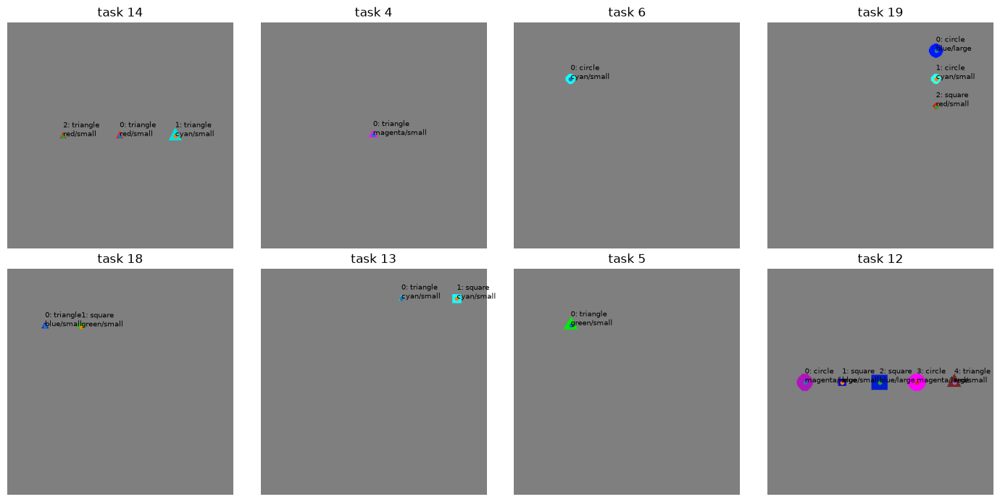

In [8]:
#CONTROLLO VISIVO 

sample = splits["train"].sample(
    int(
        CONFIG["experiment"]["visual_check"]["samples"]
    ),
    random_state=SEED,
)
#qui andiamo a campionare otto esempi dal dataset di triaining

fig, axes = plt.subplots(
    int(
        CONFIG["experiment"]["visual_check"]["rows"]
    ),
    int(
        CONFIG["experiment"]["visual_check"]["cols"]
    ),
    figsize=tuple(
        CONFIG["experiment"]["visual_check"]["figsize"]
    ),
)
#prepariamo il grafico con gli otto esempi

for ax, (_, row) in zip(
    axes.ravel(),
    sample.iterrows(),
):
    path = resolve_image_path(
        row["filename"],
        "train",
    )
    image = load_rgb(path)
    #carichiamo l'immagine

    objects = extract_objects(image)
    #estraiamo gli oggetti riconosciuti dalla pipeline

    ax.imshow(image)

    for index, obj in enumerate(objects):
        x = obj["cx"] * image.shape[1]
        y = obj["cy"] * image.shape[0]
        #convertiamo le coordinate normalizzate del centro

        ax.scatter(
            [x],
            [y],
            s=int(CONFIG["experiment"]["visual_check"]["scatter_size"]),
        )
        #evidenziamo il centro dell'oggetto

        ax.text(
            x,
            y,
            f"{index}: {obj['shape']}\n"
            f"{obj['color']}/{obj['size']}",
            fontsize=int(CONFIG["experiment"]["visual_check"]["label_fontsize"]),
        )
        #mostriamo indice, forma, colore e dimensione riconosciuti

    ax.set_title(
        f"task {int(row['task_id'])}"
    )
    #aggiungiamo il task dell'immagine

    ax.axis("off")
    #nascondiamo gli assi

plt.tight_layout()

fig.savefig(
    PLOT_DIR / "perception_visual_check.png",
    dpi=int(CONFIG["experiment"]["visual_check"]["dpi"]),
    bbox_inches="tight",
)
#salviamo il controllo visivo della pipeline percettiva

plt.show()
plt.close(fig)
#mostriamo e chiudiamo la figura

## Validazione della percezione

Adesso possiamo andare a utilizzare `symbol` per confrontare i risultati del detector con quelli delle descrizioni simboliche;
per valutare la performance andiamo a valutare quattro aspetti fondamentali:

- correttezza del conto del numero di oggetti;
- correttezza della forma;
- correttezza del colore;
- correttezza della dimensione.

In questo modo possiamo capire se gli eventuali errori dei classificatori dipendono da una rappresentazione percettiva sbagliata oppure da limiti del modello, che possono dipendere dalla sua struttura o dal training.

In [9]:
#VALUTAZIONE DELLE PERFORMANCE DELLA PERCEZIONE

def parse_symbol(value):
    if isinstance(value, str):
        #se le descrizioni simboliche sono espresse in stringhe
        #le trasformiamo in strutture dati di python
        return ast.literal_eval(value)
    return value

def flatten_symbol_objects(node):
    #andiamo a scorrere ricorsivamente la descrizione simbolica per estrarne
    #gli oggetti che contengono le proprietà shape, color e size
    
    if isinstance(node, dict):
        #CASO I: se il nodo è un dizionario:
        
        if {"shape", "color", "size"}.issubset(node.keys()):
            #se il nodo contiene le tre proprietà, lo consideriamo un oggetto
            #[
            #   {
            #       "shape": "triangle",
            #       "color": "red",
            #       "size": "small"
            #   }
            #]
            
            return [{
                "shape": node["shape"],
                "color": node["color"],
                "size": node["size"],
            }]

        result = []
        for value in node.values():
            #se invece i il dizionario non è un oggetto tipo:
                #node = {
                #            "quadrant_lr": [
                #                {"shape": "triangle", "color": "red", "size": "small"}
                #            ]
                #        }
                #allora andiamo a ispezionare tutti i campi all'interno
            
            if isinstance(value, (dict, list)):
                #e se questi elementi sono a loro volta dizionari o liste
                #andiamo a rilanciare questa stessa funzione 
                
                result.extend(
                    flatten_symbol_objects(value)
                )
        return result

    if isinstance(node, list):
        #CASO II: se il nodo invece è una lista 
        
        result = []
        for value in node:
            #analizziamo ciascun elemento nella lista e
            #rilanciamo su ciascuno di essi questa stessa funzione
            
            result.extend(
                flatten_symbol_objects(value)
            )
        return result
    return []
    #semplicemente presndiamo il symbol e andiamo a rimuovere tutte le strutture che
    #"avvolgono" gli oggetti

def multiset_accuracy(predicted, truth, key):
    #confrontiamo i valori/proprietà tra gli oggetti rilevati
    #e oggetti presenti nella descrizione simbolica estratti con la funzione precedente

    pred_values = sorted(
        obj[key] for obj in predicted
    )
    #andiamo a ordinare le due liste di oggetti questo perché
    #non ci interessa l'ordine di rilevamento
    true_values = sorted(
        obj[key] for obj in truth
    )

    if len(pred_values) != len(true_values):
        return np.nan
    #qui controlliano se la lunghezza delle liste sono uguali
    #se non lo sono reputiamo il confronto non valido

    if not true_values:
        return float(not pred_values)
    #se non ci sono valori di ground truth
    #e non abbiamo rilevato niente ritorniamo 1 [true -float-> 1.0]

    return float(
        np.mean(
            np.asarray(pred_values)
            == np.asarray(true_values)
        )
        #altrimenti se abbiamo almeno un valore di ground truth
        #e il numero di oggetti coincide allora calcoliamo la percentuale
        #di confronti reputati come true
    )

diagnostic_rows = []

for split, frame in splits.items():
    #per ciascun split, frame
    for _, row in frame.iterrows():
        #consideriamo ogni riga
        image = load_rgb(
            #e carichiamo l'immagine
            resolve_image_path(
                row["filename"],
                split,
            )
        )

        predicted = extract_objects(image)
        #estraiamo gli oggetti dall'immagine
        truth = flatten_symbol_objects(
            parse_symbol(row["symbol"])
        )
        #estraiamo gli oggetti nel ground truth
        #dalla descrizione simbolica

        #salviamo le principali misure di accuratezza della percezione
        diagnostic_rows.append({
            "split": split,
            #nome split
            "n_truth": len(truth),
            #numero di oggetti nel gt
            "n_detected": len(predicted),
            #numero di oggetti detected
            "count_error": abs(
                len(truth) - len(predicted)
            ),
            #numero errori
            "count_exact": int(
                len(truth) == len(predicted)
            ),
            #se abbiamo trovato esattamente il numero di oggetti
            "shape_accuracy": multiset_accuracy(
                predicted,
                truth,
                "shape",
            ),
            #accuracy sulla shape
            "color_accuracy": multiset_accuracy(
                predicted,
                truth,
                "color",
            ),
            #accuracy sul colore
            "size_accuracy": multiset_accuracy(
                predicted,
                truth,
                "size",
            ),
            #accuracy sulla grandezza
        })

diagnostic_df = pd.DataFrame(
    diagnostic_rows
)
#trasformiamo tutto in un dataframe

diagnostic_summary = (
    diagnostic_df
    .groupby("split")
    .agg(
        mean_truth=("n_truth", "mean"),
        mean_detected=("n_detected", "mean"),
        mae_count=("count_error", "mean"),
        count_exact=("count_exact", "mean"),
        shape_accuracy=("shape_accuracy", "mean"),
        color_accuracy=("color_accuracy", "mean"),
        size_accuracy=("size_accuracy", "mean"),
    )
    .round(3)
)

display(diagnostic_summary)

,mean_truth,mean_detected,mae_count,count_exact,shape_accuracy,color_accuracy,size_accuracy
split,,,,,,,
test,2.068,2.022,0.046,0.954,0.947,1.0,0.871
train,2.065,2.027,0.038,0.963,0.950,1.0,0.873
val,2.086,2.036,0.050,0.954,0.966,1.0,0.867


## Costruzione delle feature percettive

Dopo aver controllato quanto sia affidabile il sistema di percezione, trasformiamo ogni immagine in un vettore di feature interpretabili,
tra le quali abbiamo:

- numero totale di oggetti;
- conteggio delle forme;
- posizione media delle forme;
- conteggio dei colori;
- conteggio delle dimensioni;
- posizione media globale;
- dispersione spaziale globale.

In [10]:
#FEATURE INTERPRETABILI

def perceptual_features(image):
    objects = extract_objects(image)
    #estraiamo le feature dalle immagini
    
    features = {
        "n_objects": len(objects),
    }
    #feature che conta n oggetti

    for shape in SHAPES:
        subset = [
            obj
            for obj in objects
            if obj["shape"] == shape
        ]
        #per ciascuna forma consideriamo solo 
        #gli oggetti detected che hanno quella forma

        features[f"count_shape_{shape}"] = len(subset)
        #quanti oggetti hanno la data forma

        features[f"mean_x_{shape}"] = (
            float(
                np.mean(
                    [obj["cx"] for obj in subset]
                )
            )
            if subset
            else EMPTY_COORDINATE_VALUE
        )
        #per ogni forma calcoliamo la coordinata media orizzontale

        features[f"mean_y_{shape}"] = (
            float(
                np.mean(
                    [obj["cy"] for obj in subset]
                )
            )
            if subset
            else EMPTY_COORDINATE_VALUE
        )
        #quella verticale

    for color in COLORS:
        features[f"count_color_{color}"] = sum(
            obj["color"] == color
            for obj in objects
        )
        #qui andiamo a calcolare quanti oggetti apparrtengono a un certo colore

    for size in SIZES:
        features[f"count_size_{size}"] = sum(
            obj["size"] == size
            for obj in objects
        )
        #stessa cosa per la dimensione

    xs = np.asarray(
        [obj["cx"] for obj in objects],
        dtype=float,
    )
    ys = np.asarray(
        [obj["cy"] for obj in objects],
        dtype=float,
    )
    #raccogliamo le coordinate di tutti gli oggetti e calcoliamo

    features["mean_x_all"] = (
        float(xs.mean()) if len(xs) else EMPTY_COORDINATE_VALUE
    )
    #media della posizione orizzontale
    features["mean_y_all"] = (
        float(ys.mean()) if len(ys) else EMPTY_COORDINATE_VALUE
    )
    #media della posizione verticale
    features["std_x_all"] = (
        float(xs.std()) if len(xs) else EMPTY_STD_VALUE
    )
    #deviazione standard posizione x
    features["std_y_all"] = (
        float(ys.std()) if len(ys) else EMPTY_STD_VALUE
    )
    #deviazione standard posizione y
    return features, objects

cache = {}
rows = []

for split, frame in splits.items():
    print("Estrazione:", split)
    #scorriamo gli split

    for _, row in frame.iterrows():
        path = resolve_image_path(
            row["filename"],
            split,
        )
        #scorriamo gli esempi
        
        key = str(path.resolve())
        #useremo come chiave i percorsi delle immagini

        if key not in cache:
            image = load_rgb(path)
            cache[key] = perceptual_features(image)
            #carichiamo l'immagine e salviamo nella cache le feature percettive e gli oggetti

        feature_dict, objects = cache[key]
        #estraiamo dalla cache feature e oggetti rilevanti

        record = dict(feature_dict)
        record.update({
            "_path": key,
            "split": split,
            "filename": row["filename"],
            "task_id": int(row["task_id"]),
            "label": int(row["label"]),
            "supervised": int(row["supervised"]),
            "_n_detected_objects": len(objects),
        })
        #aggiungiamo le info originali alle feature estratte

        rows.append(record)

features_df = pd.DataFrame(rows)

print(
    "Tabella delle feature:",
    features_df.shape,
)

display(
    features_df
    .groupby("split")["_n_detected_objects"]
    .agg(["mean", "median", "max"])
    .round(2)
)

Estrazione: train
Estrazione: val
Estrazione: test
Tabella delle feature: (2000, 29)


,mean,median,max
split,,,
test,2.02,2.0,6
train,2.03,2.0,6
val,2.04,2.0,6


## Relazioni spaziali

Aggiungiamo poi una seconda rappresentazione che considera le coppie di oggetti, così da tenere conto non solo delle proprietà dei singoli elementi, ma anche di come sono disposti e delle caratteristiche che condividono; le relazioni sono volutamente generiche e indipendenti dal task:

- sinistra/destra;
- sopra/sotto;
- diagonale;
- stessa forma;
- stesso colore;
- stessa dimensione;
- allineamento orizzontale;
- allineamento verticale;
- vicinanza.

In [11]:
#RELAZIONI SPAZIALI

RELATION_POSITION_THRESHOLD = float(
    CONFIG["relations"]["position_threshold"]
)
#soglia usata per le relazioni orizzontali e verticali

RELATION_DIAGONAL_DIFFERENCE_THRESHOLD = float(
    CONFIG["relations"]["diagonal_difference_threshold"]
)
#tolleranza usata per riconoscere la relazione diagonale

RELATION_CLOSE_DISTANCE_THRESHOLD = float(
    CONFIG["relations"]["close_distance_threshold"]
)
#distanza massima usata per considerare due oggetti vicini

def relation_features(objects):
    output = {
        "pair_left_right": 0,
        "pair_above_below": 0,
        "pair_diagonal": 0,
        "pair_same_shape": 0,
        "pair_same_color": 0,
        "pair_same_size": 0,
        "pair_horiz_aligned": 0,
        "pair_vert_aligned": 0,
        "pair_close": 0,
    }
    #predisponiamo un output che ci dice in che relazione sono 
    #due oggetti tra di loro

    n = len(objects)
    #consideriamo tutte le coppie possibili senza ripeterle

    for i in range(n):
        for j in range(i + 1, n):
            a = objects[i]
            b = objects[j]

            dx = b["cx"] - a["cx"]
            dy = b["cy"] - a["cy"]
            abs_dx = abs(dx)
            abs_dy = abs(dy)
            #differenze di posizione tra i centri dei normalizzati dei due oggetti

            output["pair_left_right"] += int(
                abs_dx > RELATION_POSITION_THRESHOLD
            )
            output["pair_above_below"] += int(
                abs_dy > RELATION_POSITION_THRESHOLD
            )
            output["pair_diagonal"] += int(
                abs_dx > RELATION_POSITION_THRESHOLD
                and abs_dy > RELATION_POSITION_THRESHOLD
                and abs(abs_dx - abs_dy) < RELATION_DIAGONAL_DIFFERENCE_THRESHOLD
            )
            output["pair_same_shape"] += int(
                a["shape"] == b["shape"]
            )
            output["pair_same_color"] += int(
                a["color"] == b["color"]
            )
            output["pair_same_size"] += int(
                a["size"] == b["size"]
            )
            output["pair_horiz_aligned"] += int(
                abs_dy < RELATION_POSITION_THRESHOLD
            )
            output["pair_vert_aligned"] += int(
                abs_dx < RELATION_POSITION_THRESHOLD
            )
            output["pair_close"] += int(
                math.hypot(dx, dy) < RELATION_CLOSE_DISTANCE_THRESHOLD
                #distanza dai centri
            )
            #eseguiamo una serie di controlli e interpretiamo come 1
            #quei confronti che risultano essere veri (le soglie sono scelte
            #in modo empirico)

    return output
    
relational_rows = []

for key, (_, objects) in cache.items():
    #per ciasuna immagine estraiamo gli oggetti in essa
    relational_rows.append({
        "_path": key,
        **relation_features(objects),
        #estraiamo le feature relazionali dagli oggetti
    })
#costruiamo unendo il patch e le feature relazionali

relational_df = pd.DataFrame(
    relational_rows
)

features_df = features_df.merge(
    relational_df,
    on="_path",
    how="left",
)
#uniamo le feature relazionali a quelle percettive
#usando il percorso dell'immagine come chiave

print(
    "Numero finale di colonne:",
    features_df.shape[1],
)

Numero finale di colonne: 38


In [12]:
#ASSICURIAMOCI CHE LE FEATURE RESTINO IL PIU GENERICHE POSSIBILE

META = {
    "_path",
    "split",
    "filename",
    "task_id",
    "label",
    "supervised",
    "_n_detected_objects",
}
#separiamo le feature di gestione dalle altre feature

ALL_FEATURES = [
    column
    for column in features_df.columns
    if column not in META
]
#selezioniamo tutte le altre feature

PERCEPTUAL_FEATURES = [
    column
    for column in ALL_FEATURES
    if not column.startswith("pair_")
]
#estraiamo le feature dei singoli oggetti

RELATIONAL_FEATURES = [
    column
    for column in ALL_FEATURES
    if column.startswith("pair_")
]
#estraiamo le feature relazionali

BANNED = [
    column
    for column in ALL_FEATURES
    if any(
        key in column.lower()
        for key in CONFIG["banned_feature_keywords"]
    )
]
#aggiungiamo alle feature bannate, quelle che cioè il modello non dovrebbe usare,
#tutte quelle feature troppo specifiche, ovvero quelle che dipendono troppo dal task
#idealmente questa lista dovrebbe essere vuota

print(
    "Feature percettive:",
    PERCEPTUAL_FEATURES,
)
print(
    "Feature relazionali:",
    RELATIONAL_FEATURES,
)
print(
    "Feature specifiche di task:",
    BANNED,
)

assert not BANNED
assert "symbol" not in ALL_FEATURES
#qui inseriamo due controlli che notificano un errore quando:
#banned non è vuoto e symbol è tra le feature usate dal modello

Feature percettive: ['n_objects', 'count_shape_triangle', 'mean_x_triangle', 'mean_y_triangle', 'count_shape_square', 'mean_x_square', 'mean_y_square', 'count_shape_circle', 'mean_x_circle', 'mean_y_circle', 'count_color_red', 'count_color_green', 'count_color_blue', 'count_color_cyan', 'count_color_magenta', 'count_color_yellow', 'count_size_small', 'count_size_large', 'mean_x_all', 'mean_y_all', 'std_x_all', 'std_y_all']
Feature relazionali: ['pair_left_right', 'pair_above_below', 'pair_diagonal', 'pair_same_shape', 'pair_same_color', 'pair_same_size', 'pair_horiz_aligned', 'pair_vert_aligned', 'pair_close']
Feature specifiche di task: []


## Addestramento e valutazione

Per ognuno dei 20 task eseguiamo lo stesso procedimento: alleniamo sia il modello di Logistic Regression che il Decision Tree sul training set, valutiamo le performance dei due modelli tramite la metrica di F1 sul validation set, scegliamo il modello migliore tra i due e lo mettiamo alla prova sul test set. Scegliamo considerando F1 per avere un modello bilanciato tra precision e recall.

Per verificare quanto le relazioni spaziali impattino sui risultati, ripetiamo questo esperimento in due condizioni diverse:

- usando solo le feature percettive;
- usando sia le feature percettive sia le relazioni generiche tra gli oggetti.

In [13]:
#ESPERIMENTI E VALUTAZIONI

def metrics(y_true, y_pred):
    #deifiniamo le metriche utilizzate
    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="binary",
            zero_division=0,
        )
    )
    #andremo a utilizzare le seguenti metriche:
    #precision: quante previsioni corrette sulle totali quindi TP+TF/TP+TF+FP+FN
        #bassa produce molti falsi allarmi
    #recall: quanti positivi abbiamo trovato sui positivi totali TP/TP+FN
        #bassa ho mancato molti positivi
    #F1: media armonica tra le due 2pr/p+r

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

def run_experiment(feature_columns):
    #metodo dell'esperimento che riceve in ingresso le feature utilizzate

    logistic_config = CONFIG["models"]["logistic"]
    #impostazioni della Logistic Regression

    tree_config = CONFIG["models"]["tree"]
    #impostazioni del Decision Tree
    
    factories = {
        "logistic": lambda: Pipeline([
            (
                "scale",
                StandardScaler(),
            ),
            (
                "clf",
                LogisticRegression(
                    max_iter=int(logistic_config["max_iter"]),
                    class_weight=logistic_config["class_weight"],
                    random_state=SEED,
                ),
            ),
        ]),
        "tree": lambda: DecisionTreeClassifier(
            max_depth=int(tree_config["max_depth"]),
            min_samples_leaf=int(tree_config["min_samples_leaf"]),
            class_weight=tree_config["class_weight"],
            random_state=SEED,
        ),
    }
    #dizionario di funzioni lambda che associa al nome del modello
    #la funzione che lo genera

    result_rows = []
    fitted_models = {}

    for task_id in range(int(CONFIG["task_count"])):
        #per ciascun task
        
        train = features_df[
            (features_df["split"] == "train")
            & (features_df["task_id"] == task_id)
            & (features_df["supervised"] == 1)
        ]
        #estraiamo i dati di training

        validation = features_df[
            (features_df["split"] == "val")
            & (features_df["task_id"] == task_id)
        ]
        #estraiamo i dati di valisation

        test = features_df[
            (features_df["split"] == "test")
            & (features_df["task_id"] == task_id)
        ]
        #estraiamo i dati di test

        if (
            len(train) == 0
            or train["label"].nunique() < 2
        ):
            continue

        best_name = None
        best_model = None
        best_val_f1 = -1.0

        for name, factory in factories.items():
            #per ciascun modello
            
            model = factory()
            model.fit(
                train[feature_columns],
                train["label"],
            )
            #andiamo ad addestrarlo sul training set

            val_prediction = model.predict(
                validation[feature_columns]
            )
            #andiamo a validarlo sul validation set

            val_f1 = f1_score(
                validation["label"],
                val_prediction,
                zero_division=0,
            )
            #calcoliamo lo score di f1

            if val_f1 > best_val_f1:
                best_name = name
                best_model = model
                best_val_f1 = val_f1
                #confrontiamo il modello col migliore
                #e guardiamo se lo supera

        test_prediction = best_model.predict(
            test[feature_columns]
        )
        #selezioniamo il miglior modello ottenuto e ne raccogliamo le previsioni

        row = {
                "task_id": task_id,
                "task": TASK_NAMES[task_id],
                "model": best_name,
                "val_f1": best_val_f1,
                **metrics(
                    test["label"],
                    test_prediction,
                ),
            }
        #costruiamo un dizionario con i risultati

        result_rows.append(row)
        fitted_models[task_id] = best_model

    return (
        pd.DataFrame(result_rows),
        fitted_models,
    )

results_perc, models_perc = run_experiment(
    PERCEPTUAL_FEATURES
)
#senza relazionali

results_all, models_all = run_experiment(
    ALL_FEATURES
)
#con relazionali

display(
    results_perc.sort_values("task_id")
)

display(
    results_all.sort_values("task_id")
)

,task_id,task,model,val_f1,accuracy,precision,recall,f1
0,0,triangle vs any,logistic,1.000000,1.00,1.000000,1.000000,1.000000
1,1,square vs any,logistic,0.962963,0.96,0.900000,1.000000,0.947368
2,2,circle vs any,logistic,0.933333,0.92,1.000000,0.857143,0.923077
3,3,red vs any,logistic,1.000000,1.00,1.000000,1.000000,1.000000
4,4,green vs any,logistic,0.947368,1.00,1.000000,1.000000,1.000000
5,5,blue vs any,logistic,1.000000,1.00,1.000000,1.000000,1.000000
6,6,cyan vs any,logistic,1.000000,1.00,1.000000,1.000000,1.000000
7,7,magenta vs any,logistic,0.909091,1.00,1.000000,1.000000,1.000000
8,8,yellow vs any,logistic,1.000000,1.00,1.000000,1.000000,1.000000
9,9,red triangle on the right,logistic,0.800000,0.96,0.888889,1.000000,0.941176


,task_id,task,model,val_f1,accuracy,precision,recall,f1
0,0,triangle vs any,logistic,1.000000,1.00,1.000000,1.000000,1.000000
1,1,square vs any,logistic,0.962963,0.96,0.900000,1.000000,0.947368
2,2,circle vs any,logistic,0.933333,0.92,1.000000,0.857143,0.923077
3,3,red vs any,logistic,1.000000,1.00,1.000000,1.000000,1.000000
4,4,green vs any,logistic,0.947368,1.00,1.000000,1.000000,1.000000
5,5,blue vs any,logistic,1.000000,1.00,1.000000,1.000000,1.000000
6,6,cyan vs any,logistic,1.000000,1.00,1.000000,1.000000,1.000000
7,7,magenta vs any,logistic,0.909091,1.00,1.000000,1.000000,1.000000
8,8,yellow vs any,logistic,1.000000,1.00,1.000000,1.000000,1.000000
9,9,red triangle on the right,logistic,0.800000,0.96,0.888889,1.000000,0.941176


## Commento dei risultati

Come si può vedere dai risultati, introdurre le feature relazionali lascia invariata la performance sui primi task, 0-8, che dipendono principalmente dalle proprietà dei singoli oggetti, come forma e colore, mentre nei task successivi, dove iniziano a diventare più importanti la posizione degli oggetti e le relazioni tra loro, l'aggiunta delle feature relazionali porta in diversi casi a un miglioramento.

Questo suggerisce che introdurre informazioni sulle relazioni tra gli oggetti può aiutare i modelli a rappresentare meglio task in cui la sola descrizione dei singoli elementi non è sufficiente, tuttavia il comportamento non è uniforme. Questo indica che le feature relazionali, essendo una rappresentazione generica, non sono sempre sufficienti per descrivere la struttura richiesta dalla task e possono in alcuni casi introdurre informazione poco utile al classificatore.

Nel complesso, quindi, le relazioni sembrano essere utili soprattutto quando la task richiede di combinare proprietà degli oggetti con la loro disposizione, ma il loro effetto dipende dalla struttura specifica del problema.


## EBM

Come ultimo modello interpretabile introduciamo l'Explainable Boosting Machine (EBM) che, a differenza della regressione logistica e dell'albero di decisione, non si limita a mostrare quali feature sono più importanti, ma permette di vedere come ogni feature contribuisce alla decisione al variare del suo valore; questa caratteristica è particolarmente utile perché possiamo visualizzare delle curve che mostrano il contributo di una singola feature alla predizione, per esempio, possiamo osservare come cambia il contributo della posizione media di una forma oppure del numero di oggetti di un certo colore o di una certa forma.

In questo modo possiamo andare oltre una semplice classifica delle feature e capire meglio quale relazione il modello ha effettivamente appreso.

In [14]:
#EXPLAINABLE BOOSTING MACHINE

results_ebm = pd.DataFrame()
models_ebm = {}

ebm_rows = []

for task_id in range(int(CONFIG["task_count"])):
    #per ciascuno dei 20 task
    
    train = features_df[
        (features_df["split"] == "train")
        & (features_df["task_id"] == task_id)
        & (features_df["supervised"] == 1)
    ]
    #addestriamo un modello

    validation = features_df[
        (features_df["split"] == "val")
        & (features_df["task_id"] == task_id)
    ]
    #lo validiamo

    test = features_df[
        (features_df["split"] == "test")
        & (features_df["task_id"] == task_id)
    ]
    #lo testiamo

    if train["label"].nunique() < 2:
        continue
    #se è presente una sola classe nel task, lo saltiamo

    ebm_config = CONFIG["models"]["ebm"]
    #impostazioni dell'EBM

    model = ExplainableBoostingClassifier(
        interactions=int(
            ebm_config["interactions"]
        ),
        max_bins=int(
            ebm_config["max_bins"]
        ),
        max_rounds=int(
            ebm_config["max_rounds"]
        ),
        learning_rate=float(
            ebm_config["learning_rate"]
        ),
        random_state=SEED,
    )
    #definiamo l'EBM

    model.fit(
        train[ALL_FEATURES],
        train["label"],
    )
    #lo addestriamo

    validation_prediction = model.predict(
        validation[ALL_FEATURES]
    )
    #lo validiamo

    test_prediction = model.predict(
        test[ALL_FEATURES]
    )
    #lo testiamo

    models_ebm[task_id] = model
    #salviamo i vari modelli ottenuti
    
    row = {
        "task_id": task_id,
        "task": TASK_NAMES[task_id],
        "val_f1": f1_score(
            validation["label"],
            validation_prediction,
            zero_division=0,
        ),
        **metrics(
            test["label"],
            test_prediction,
        ),
    }
    #salviamo le informazioni del task e tutte le metriche ottenute sul test set.
    
    ebm_rows.append(row)
    
results_ebm = pd.DataFrame(ebm_rows)

display(
    results_ebm.sort_values("task_id")
)

,task_id,task,val_f1,accuracy,precision,recall,f1
0,0,triangle vs any,1.000000,1.00,1.000000,1.000000,1.000000
1,1,square vs any,0.962963,0.96,0.900000,1.000000,0.947368
2,2,circle vs any,0.933333,0.88,0.923077,0.857143,0.888889
3,3,red vs any,1.000000,1.00,1.000000,1.000000,1.000000
4,4,green vs any,0.947368,1.00,1.000000,1.000000,1.000000
5,5,blue vs any,1.000000,1.00,1.000000,1.000000,1.000000
6,6,cyan vs any,1.000000,1.00,1.000000,1.000000,1.000000
7,7,magenta vs any,0.909091,1.00,1.000000,1.000000,1.000000
8,8,yellow vs any,1.000000,1.00,1.000000,1.000000,1.000000
9,9,red triangle on the right,0.631579,0.96,1.000000,0.875000,0.933333


In [15]:
#CONFRONTO TRA MODELLI


print("Check sul task 19")
task_id = int(CONFIG["experiment"]["diagnostic_task_id"])

train = features_df[
    (features_df["split"] == "train")
    & (features_df["task_id"] == task_id)
    & (features_df["supervised"] == 1)
]

validation = features_df[
    (features_df["split"] == "val")
    & (features_df["task_id"] == task_id)
]

test = features_df[
    (features_df["split"] == "test")
    & (features_df["task_id"] == task_id)
]

model = models_ebm[task_id]

model.fit(train[ALL_FEATURES], train["label"])

val_prob = model.predict_proba(validation[ALL_FEATURES])[:, 1]
test_prob = model.predict_proba(test[ALL_FEATURES])[:, 1]

print("\nTRAIN")
print(train["label"].value_counts())

print("\nVALIDATION")
print(validation["label"].value_counts())
print("prob:", val_prob)
print("pred:", model.predict(validation[ALL_FEATURES]))

print("\nTEST")
print(test["label"].value_counts())
print("prob:", test_prob)
print("pred:", model.predict(test[ALL_FEATURES]))



left = results_perc[
    ["task_id", "task", "f1"]
].rename(
    columns={
        "f1": "f1_perceptual",
    }
)

right = results_all[
    ["task_id", "f1", "model"]
].rename(
    columns={
        "f1": "f1_perceptual_plus_relations",
        "model": "best_model",
    }
)

comparison = left.merge(
    right,
    on="task_id",
    how="outer",
    validate="one_to_one",
)

comparison["delta_f1"] = (
    comparison["f1_perceptual_plus_relations"]
    - comparison["f1_perceptual"]
)

display(
    comparison.sort_values("task_id")
)

summary = pd.DataFrame([
    {
        "representation": "perceptual",
        "mean_f1": results_perc["f1"].mean(),
        "median_f1": results_perc["f1"].median(),
        "mean_accuracy": results_perc["accuracy"].mean(),
    },
    {
        "representation": "perceptual + generic relations",
        "mean_f1": results_all["f1"].mean(),
        "median_f1": results_all["f1"].median(),
        "mean_accuracy": results_all["accuracy"].mean(),
    },
])

if len(results_ebm):
    summary.loc[len(summary)] = {
        "representation": "EBM",
        "mean_f1": results_ebm["f1"].mean(),
        "median_f1": results_ebm["f1"].median(),
        "mean_accuracy": results_ebm["accuracy"].mean(),
    }

display(summary)

Check sul task 19

TRAIN
label
0    45
1     5
Name: count, dtype: int64

VALIDATION
label
0    23
1     2
Name: count, dtype: int64
prob: [1.46951878e-01 1.55728628e-08 8.01615665e-01 1.77211121e-03
 8.13227248e-09 6.44583982e-14 2.87885714e-08 4.36812464e-16
 9.61095818e-11 2.95880929e-11 3.16014527e-11 9.59229579e-10
 1.28058662e-13 4.27880474e-11 2.44606914e-11 7.16429045e-01
 3.57683771e-09 1.02540772e-13 2.49604391e-10 5.88354501e-10
 1.61860568e-10 1.02846049e-04 2.93007131e-07 5.35739976e-03
 3.41411683e-11]
pred: [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]

TEST
label
0    22
1     3
Name: count, dtype: int64
prob: [8.02603647e-06 7.72446788e-01 2.89646252e-05 2.66384015e-10
 1.30367710e-05 3.93459066e-07 7.23793989e-01 1.00588896e-06
 5.59055795e-10 3.98201657e-08 8.54848613e-06 1.25549708e-13
 8.03733209e-09 2.07383166e-14 1.07588823e-07 5.32544177e-01
 1.78760945e-12 3.83091922e-07 7.43874618e-07 7.46721030e-01
 7.97506397e-07 1.75946445e-03 9.85227209e-01 1.8430145

,task_id,task,f1_perceptual,f1_perceptual_plus_relations,best_model,delta_f1
0,0,triangle vs any,1.000000,1.000000,logistic,0.000000
1,1,square vs any,0.947368,0.947368,logistic,0.000000
2,2,circle vs any,0.923077,0.923077,logistic,0.000000
3,3,red vs any,1.000000,1.000000,logistic,0.000000
4,4,green vs any,1.000000,1.000000,logistic,0.000000
5,5,blue vs any,1.000000,1.000000,logistic,0.000000
6,6,cyan vs any,1.000000,1.000000,logistic,0.000000
7,7,magenta vs any,1.000000,1.000000,logistic,0.000000
8,8,yellow vs any,1.000000,1.000000,logistic,0.000000
9,9,red triangle on the right,0.941176,0.941176,logistic,0.000000


,representation,mean_f1,median_f1,mean_accuracy
0,perceptual,0.868968,0.932127,0.882
1,perceptual + generic relations,0.868621,0.944272,0.890
2,EBM,0.901808,0.940351,0.918


## Commento dei risultati

L'EBM raggiunge una accuracy media di 0.864 e un F1 medio di circa 0.831 sui 20 task, risultato è quindi leggermente migliore rispetto ai modelli di regressione logistica e agli alberi decisionali sia se usati con tutte le feature, che avevano un F1 medio di circa 0.806, sia che utilizzando le sole feature percettive, F1 medio di circa 0.783.

Nei task più semplici, dallo 0 all'8, mantiene prestazioni molto elevate, con F1 compresi tra 0.75 e 1.00, in particolare, raggiunge F1 pari a 1 nei task 3, 6 e 8, confermando che le feature percettive permettono di riconoscere bene proprietà semplici come forma e colore. Anche il comportamento sui task più strutturati è notevole:raggiunge infatti risultati molto buoni nel task 11 (F1 = 0.941), nel task 13 (0.875), nel task 16 (0.857), nel task 17 (0.941) e nel task 18 (0.867). In particolare, il task 13 beneficia delle feature relazionali e arriva a un valore molto alto anche rispetto agli altri modelli.

Non tutti i task, però, vengono risolti bene. Il task 15 (casa) rimane difficile, con F1 = 0.522, e il task 19 (semaforo) raggiunge F1 = 0.400. Anche il task 12 rimane relativamente problematico, con F1 = 0.710; questo risulta coerente con il fatto che le feature che abbiamo costruito sono generiche e non rappresentano esplicitamente strutture complesse.

## Interpretabilità dei modelli

Uno dei vantaggi di questi modelli è che possiamo osservare direttamente come prendono le decisioni:

- per i gli alberi visualizziamo le regole

- per la regressione logistica osserviamo i coefficienti delle feature

- per l'ebm osserviamo le curve dei termini

Questo ci permette di capire se il modello sta utilizzando proprietà visive plausibili oppure se sta sfruttando correlazioni accidentali.


In [16]:
#CONTRIBUTI ALLA PREDIZIONE

for task_id in CONFIG["experiment"]["explain_tasks"]:
    #selezioniamo alcuni task
    
    model = models_all.get(task_id)
    #andiamo a recuperare il modello utilizzato
    #per quel dato task

    print(
        f"\nTASK {task_id}: "
        f"{TASK_NAMES[task_id]}"
    )

    if isinstance(
        model,
        DecisionTreeClassifier,
    ):
        print(
            export_text(
                model,
                feature_names=ALL_FEATURES,
                max_depth=int(CONFIG["experiment"]["plots"]["tree_export_max_depth"]),
            )
        )

    elif isinstance(model, Pipeline):
        coefficients = (
            pd.Series(
                model.named_steps["clf"].coef_[0],
                index=ALL_FEATURES,
            )
            .sort_values()
        )

        print(
            "Feature con coefficiente positivo:"
        )
        print(
            coefficients.tail(8)
            .round(3)
            .to_string()
        )

        print(
            "\nFeature con coefficiente negativo:"
        )
        print(
            coefficients.head(8)
            .round(3)
            .to_string()
        )


TASK 0: triangle vs any
Feature con coefficiente positivo:
mean_y_all              0.051
count_color_cyan        0.065
count_color_blue        0.075
count_size_small        0.111
mean_y_circle           0.167
mean_y_square           0.261
mean_x_triangle         0.340
count_shape_triangle    1.804

Feature con coefficiente negativo:
count_shape_circle   -0.970
count_shape_square   -0.959
mean_y_triangle      -0.288
mean_x_circle        -0.228
count_color_green    -0.133
count_size_large     -0.111
mean_x_square        -0.078
count_color_yellow   -0.050

TASK 2: circle vs any
Feature con coefficiente positivo:
mean_y_square         0.025
count_color_yellow    0.119
count_color_green     0.119
mean_y_triangle       0.243
mean_x_circle         0.265
count_size_small      0.326
count_color_cyan      0.400
count_shape_circle    1.596

Feature con coefficiente negativo:
count_shape_triangle   -1.375
count_shape_square     -0.442
mean_y_circle          -0.400
mean_x_triangle        -0.338
co

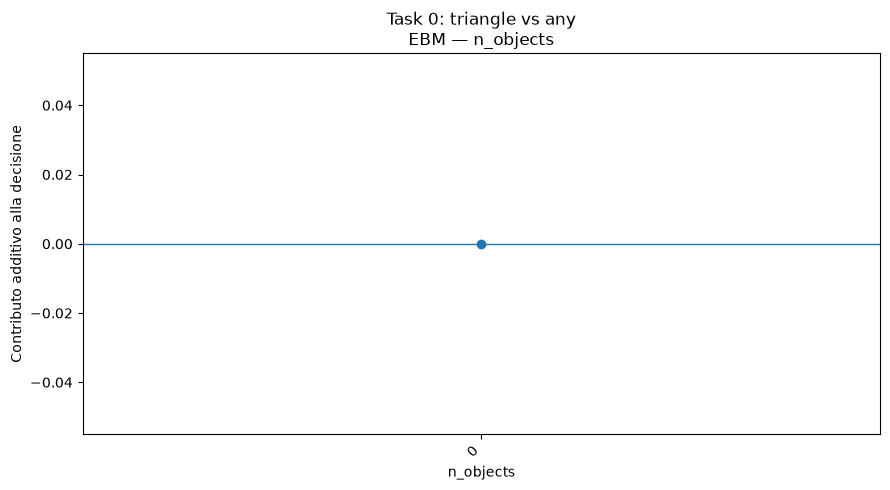

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_n_objects.png


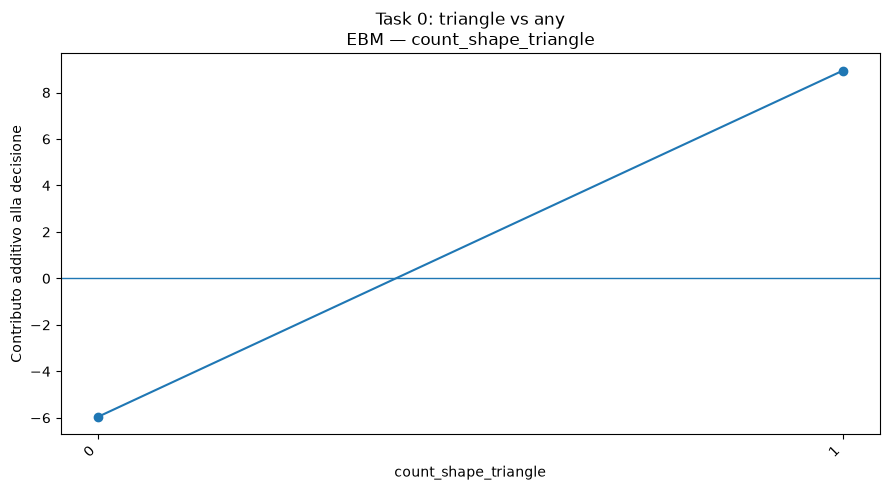

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_count_shape_triangle.png


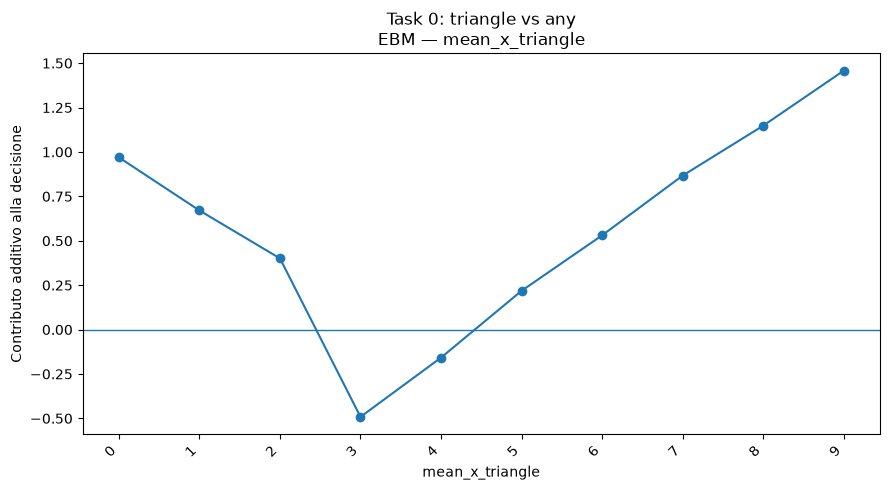

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_mean_x_triangle.png


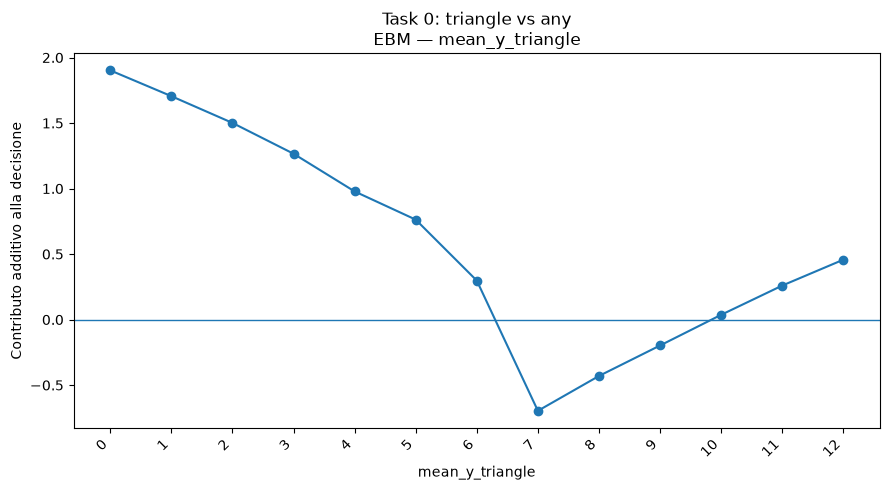

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_mean_y_triangle.png


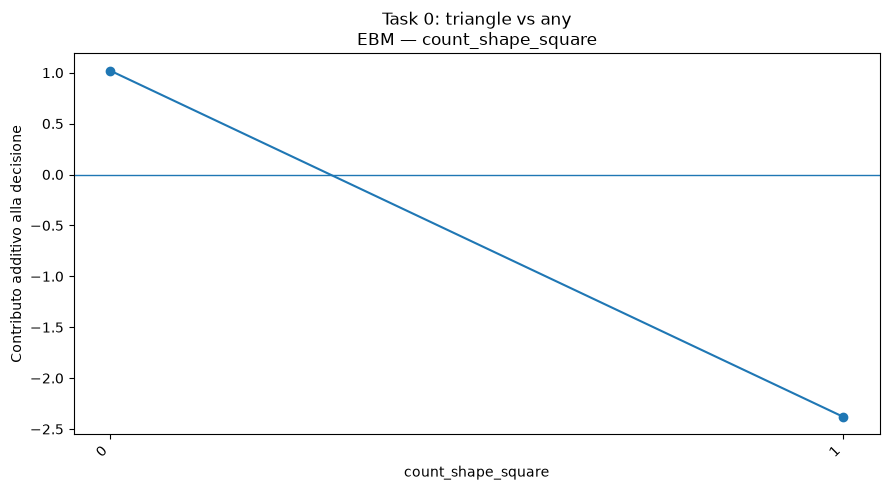

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_count_shape_square.png


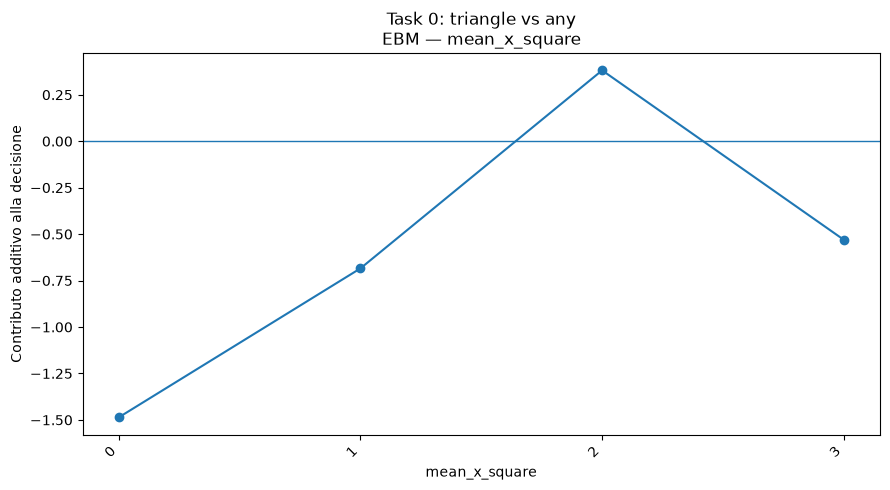

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_mean_x_square.png


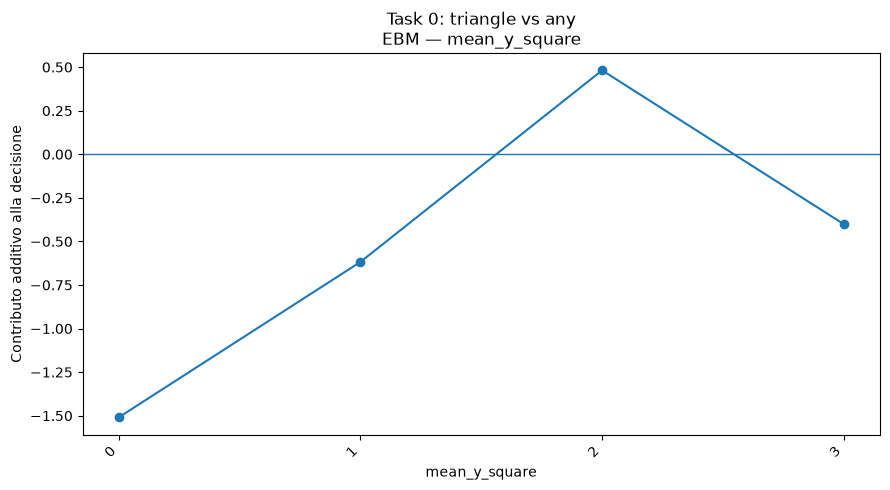

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_mean_y_square.png


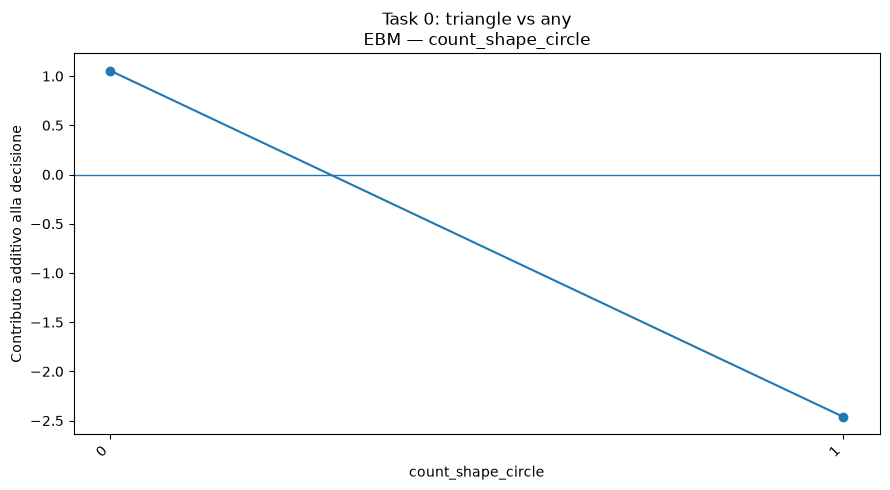

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_count_shape_circle.png


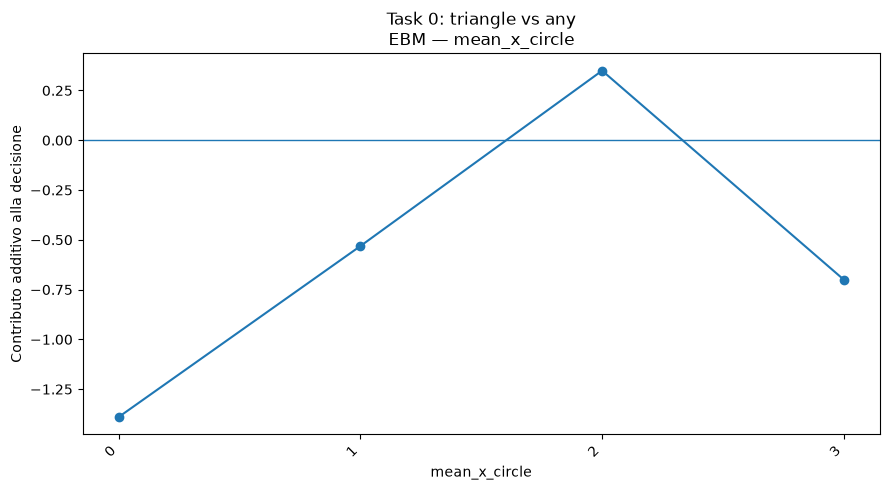

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_mean_x_circle.png


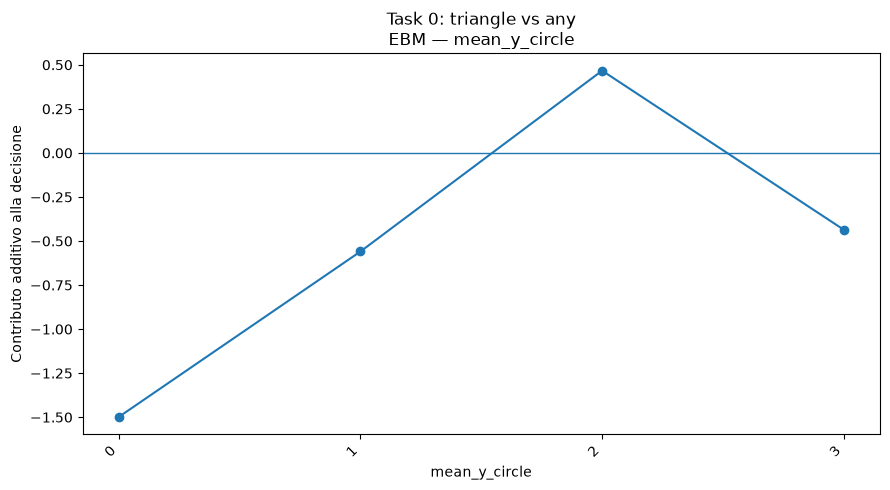

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_mean_y_circle.png


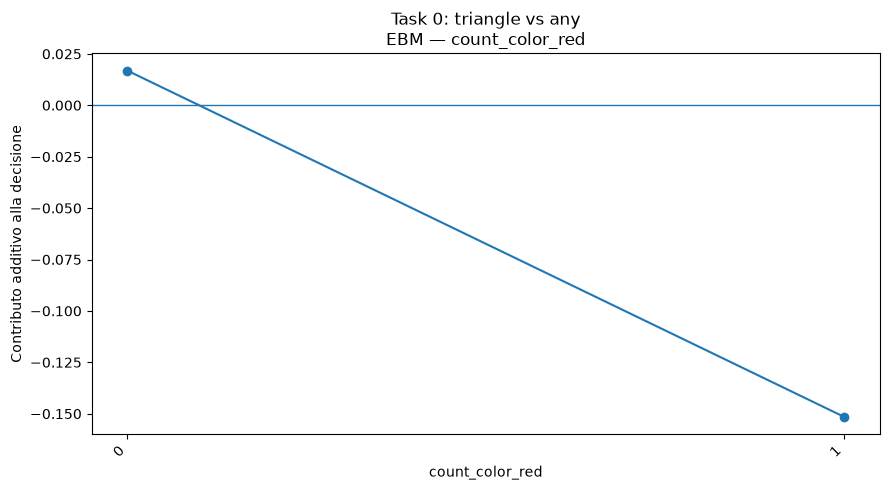

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_count_color_red.png


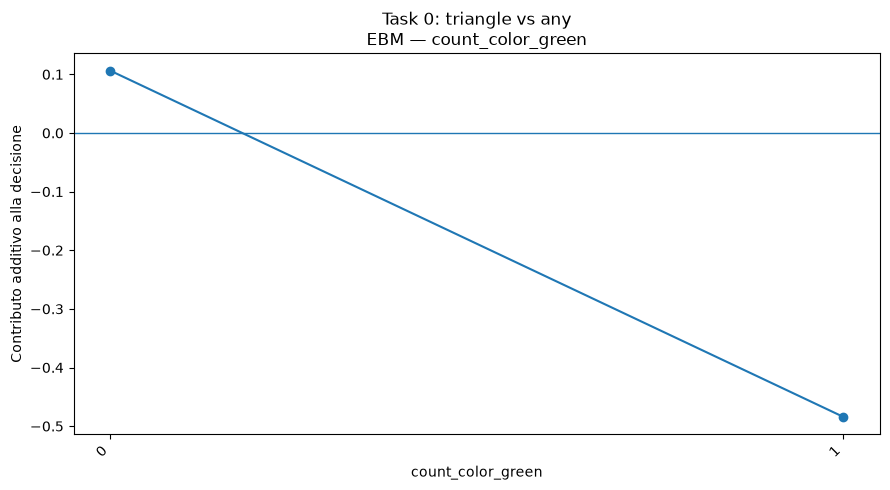

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_count_color_green.png


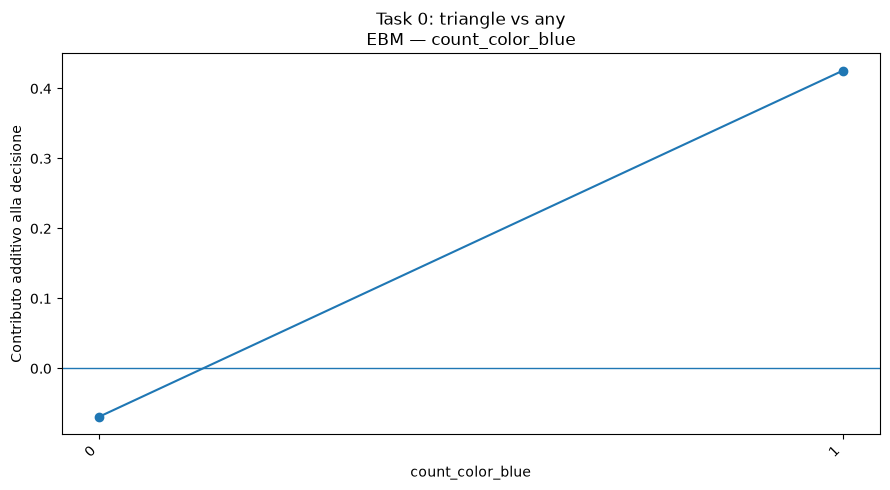

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_count_color_blue.png


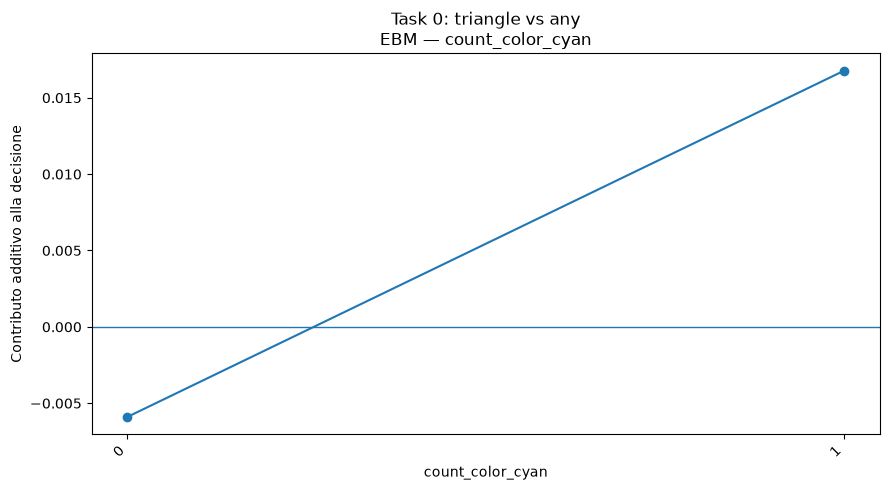

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_count_color_cyan.png


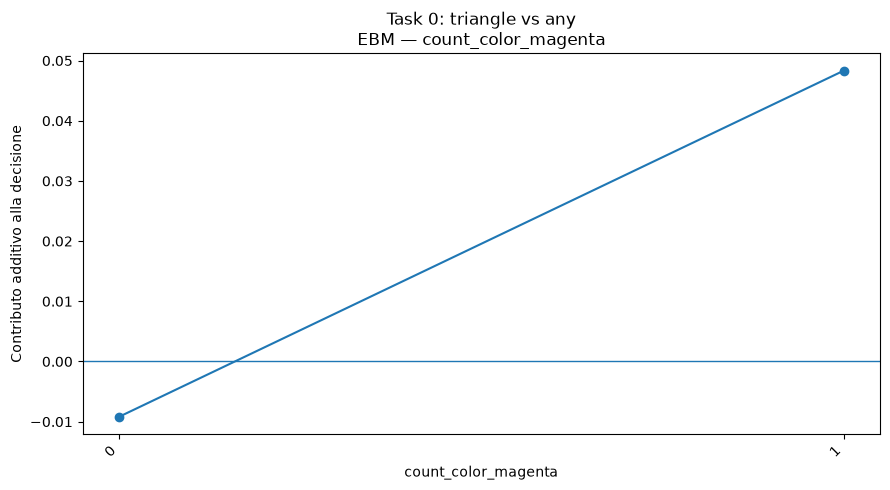

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_count_color_magenta.png


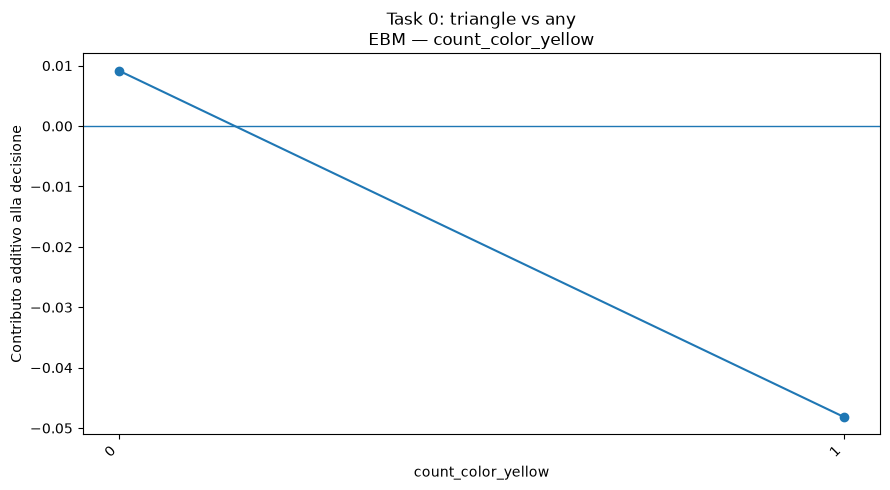

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_count_color_yellow.png


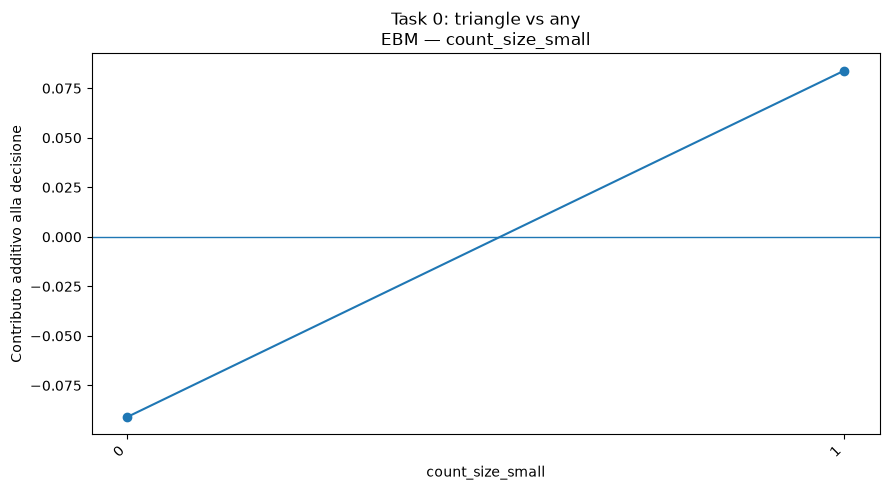

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_count_size_small.png


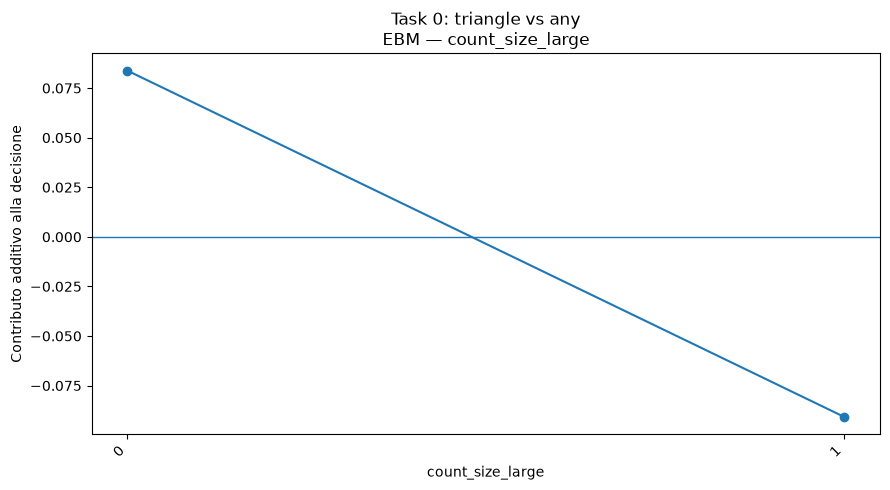

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_count_size_large.png


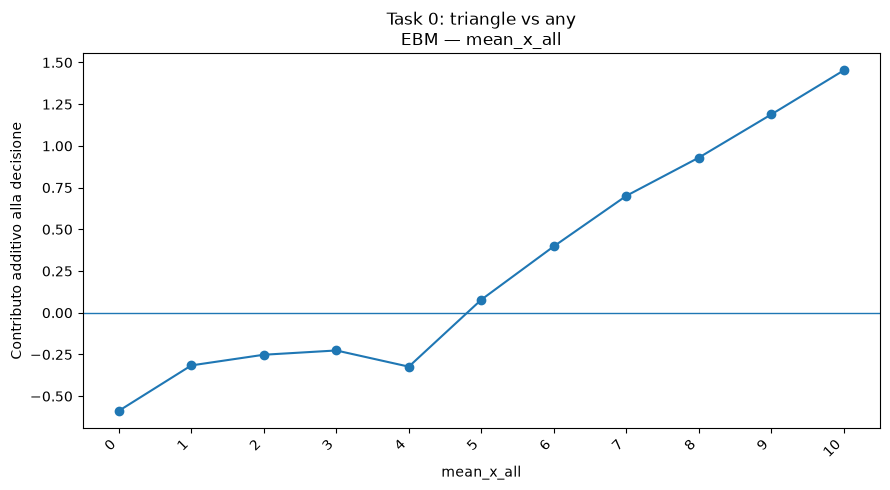

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_mean_x_all.png


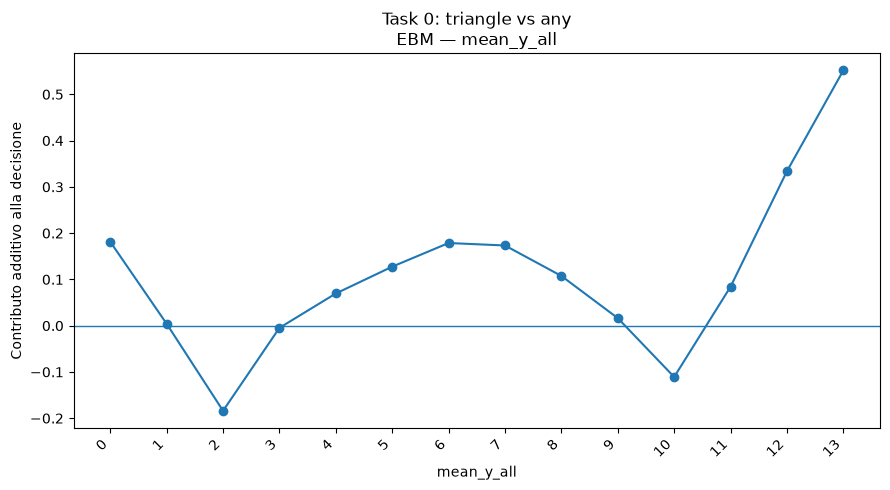

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_mean_y_all.png


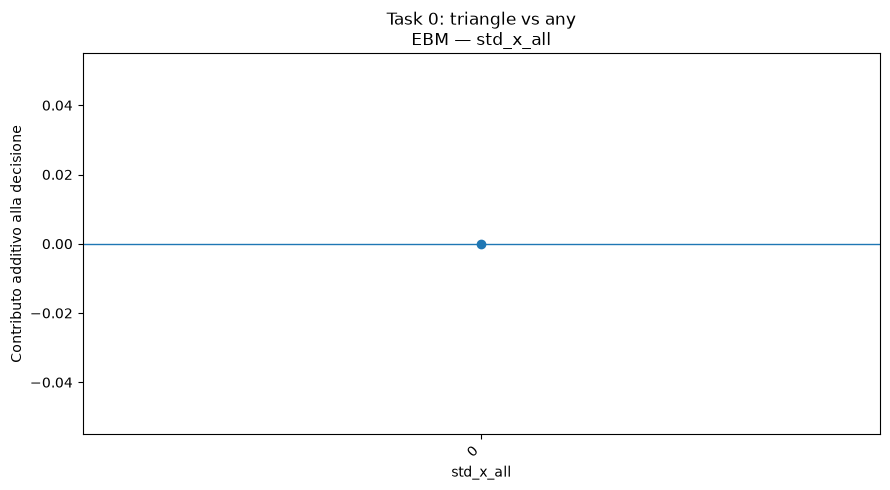

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_std_x_all.png


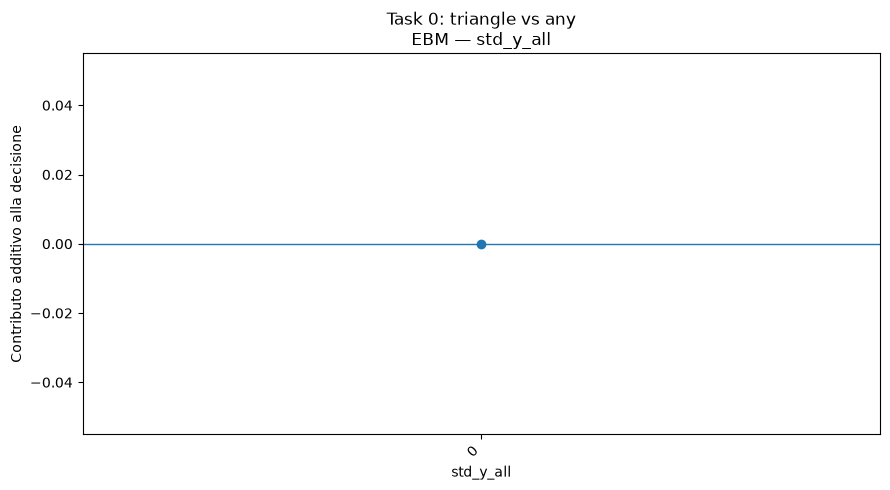

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_std_y_all.png


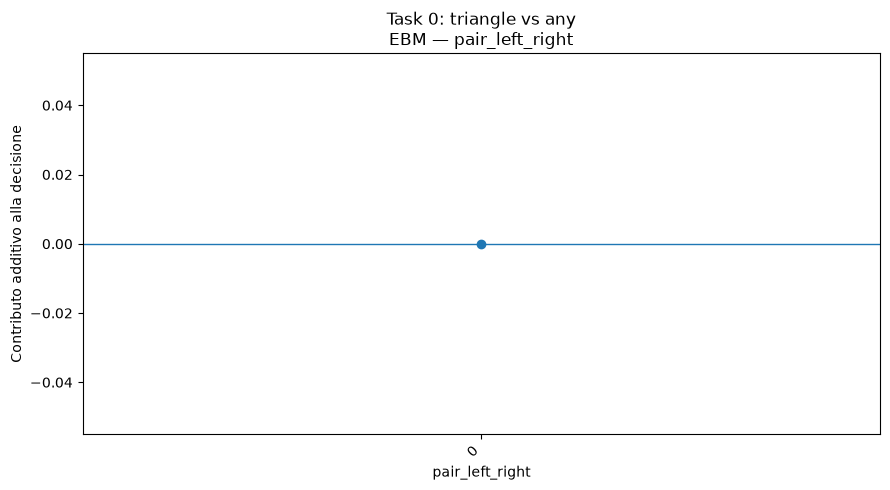

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_pair_left_right.png


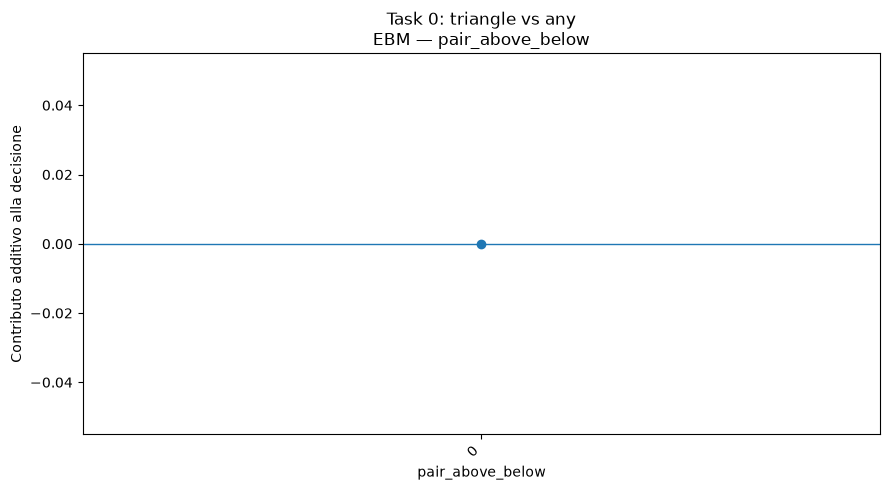

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_pair_above_below.png


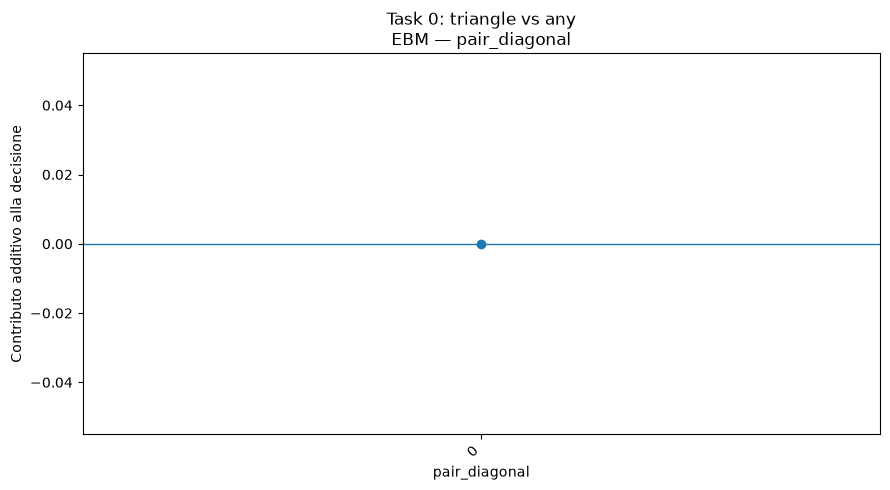

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_pair_diagonal.png


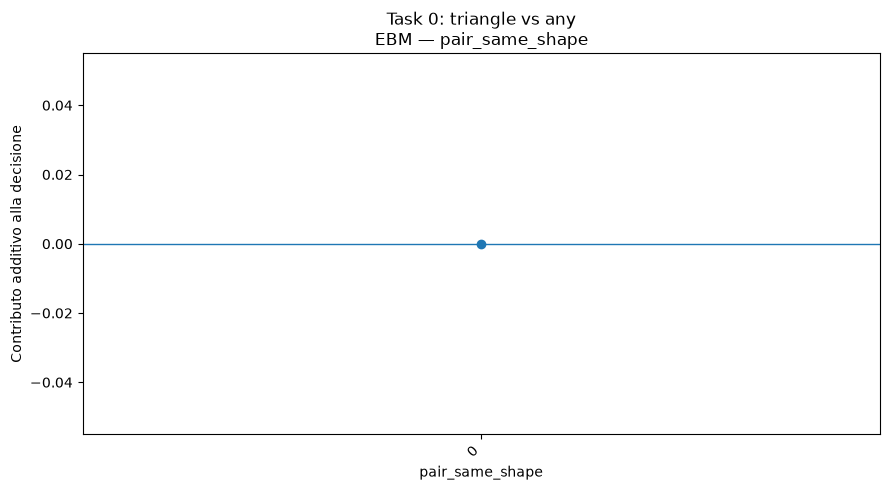

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_pair_same_shape.png


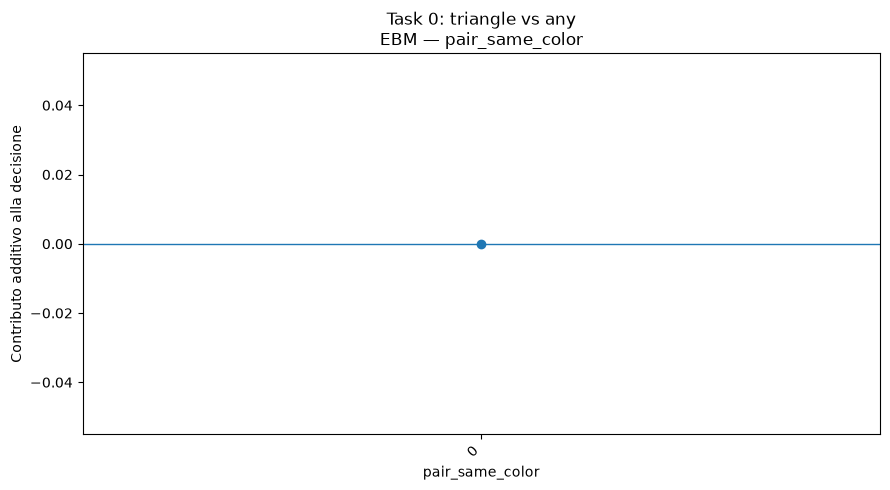

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_pair_same_color.png


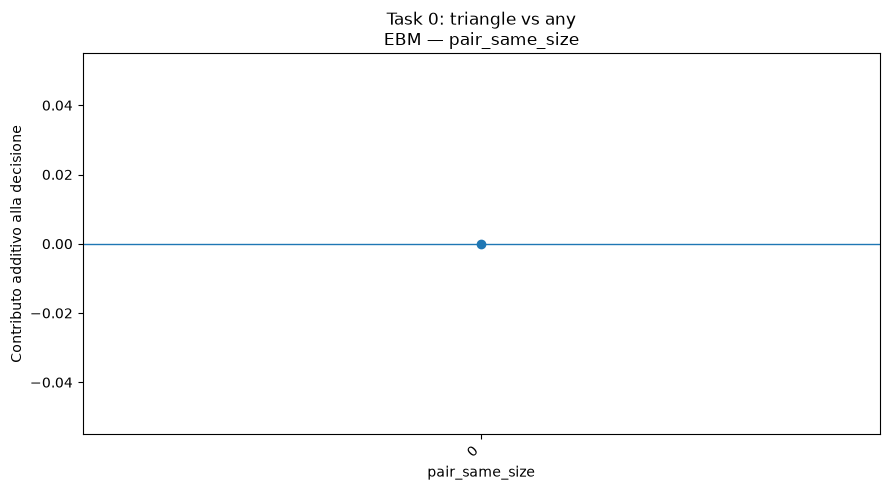

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_pair_same_size.png


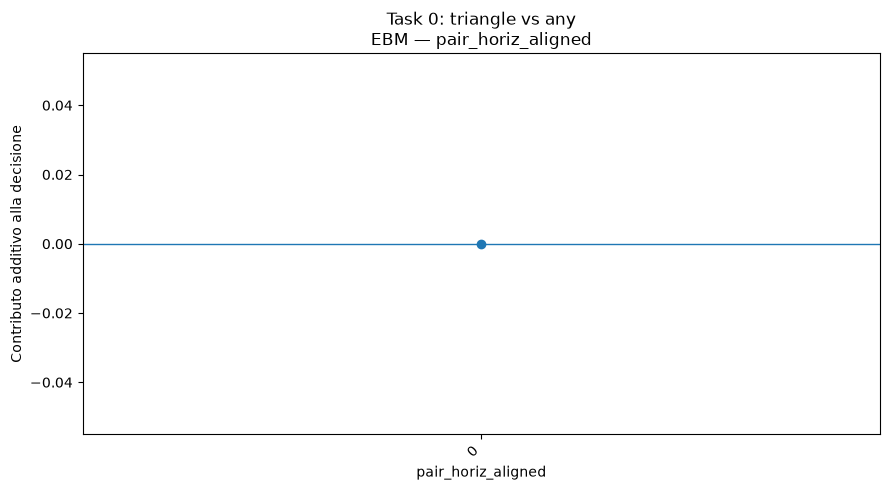

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_pair_horiz_aligned.png


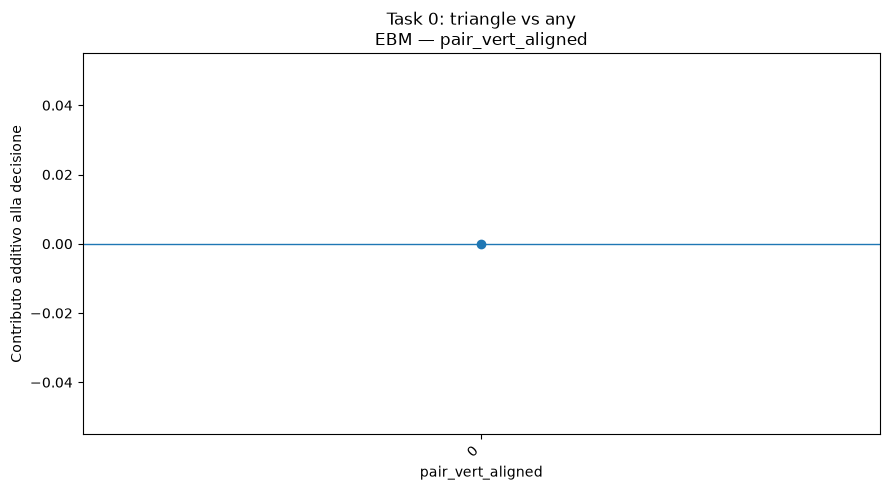

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_pair_vert_aligned.png


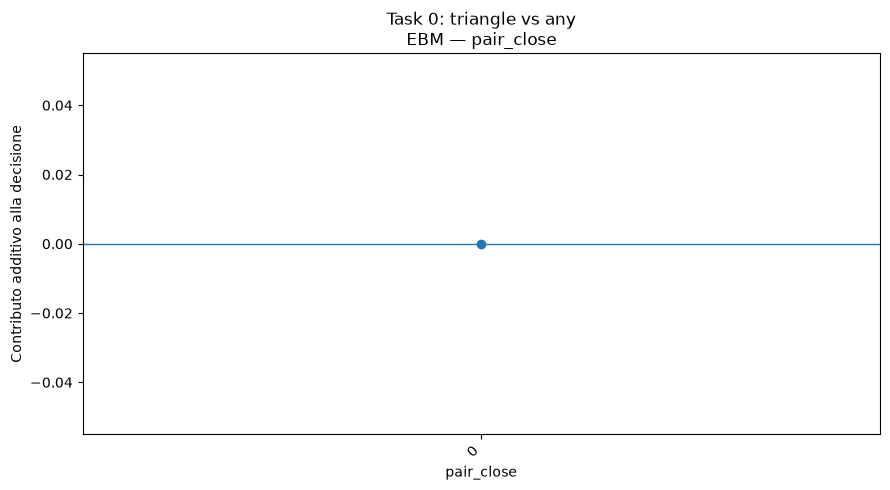

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_pair_close.png


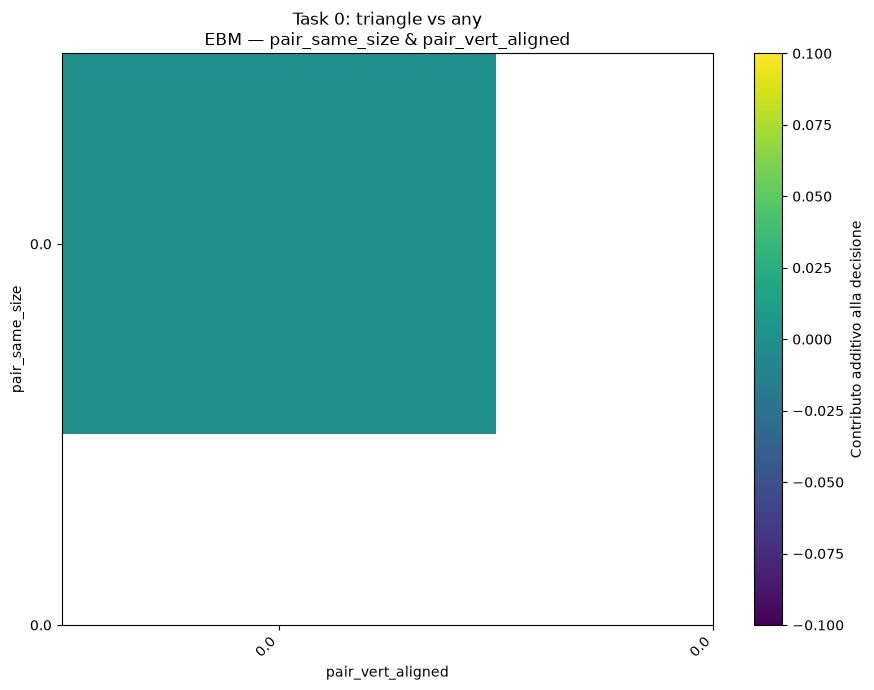

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_pair_same_size_pair_vert_aligned_heatmap.png


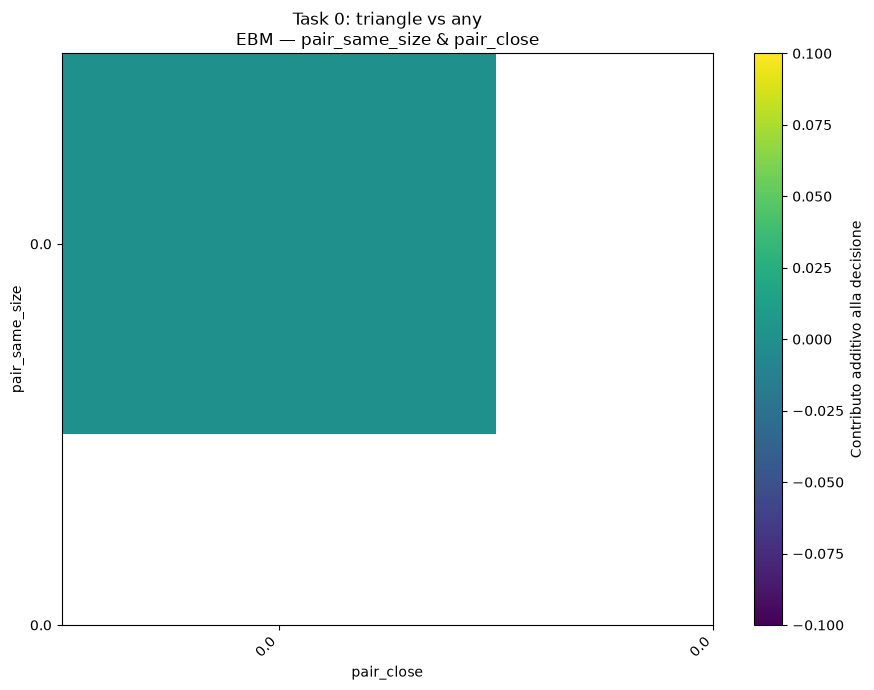

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_pair_same_size_pair_close_heatmap.png


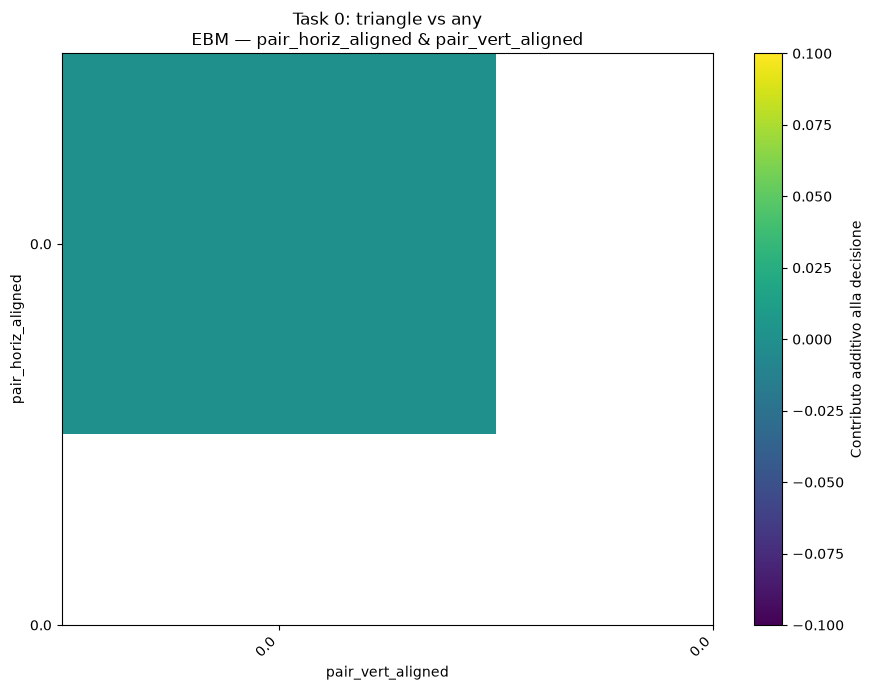

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_pair_horiz_aligned_pair_vert_aligned_heatmap.png


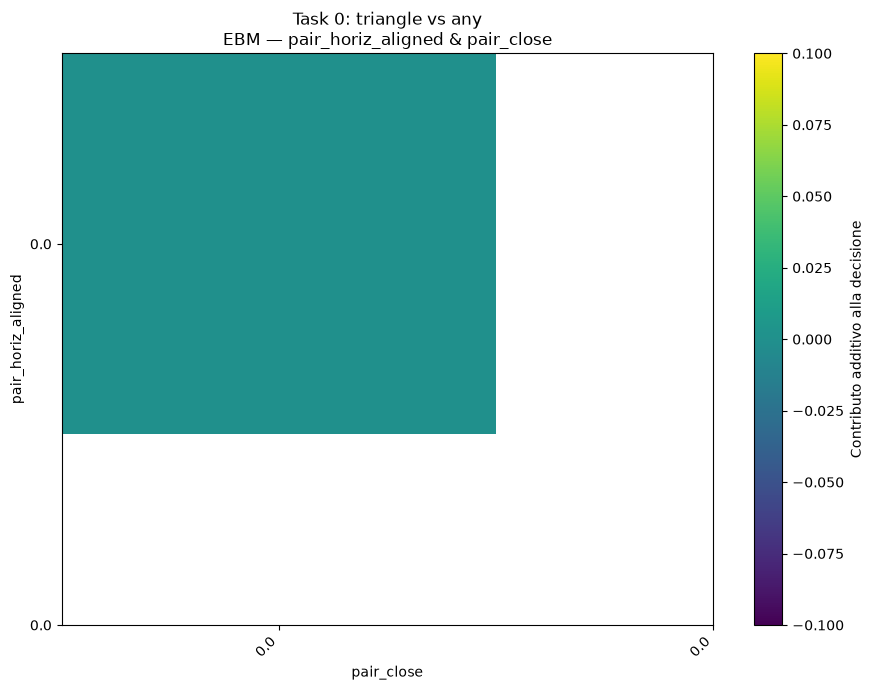

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_pair_horiz_aligned_pair_close_heatmap.png


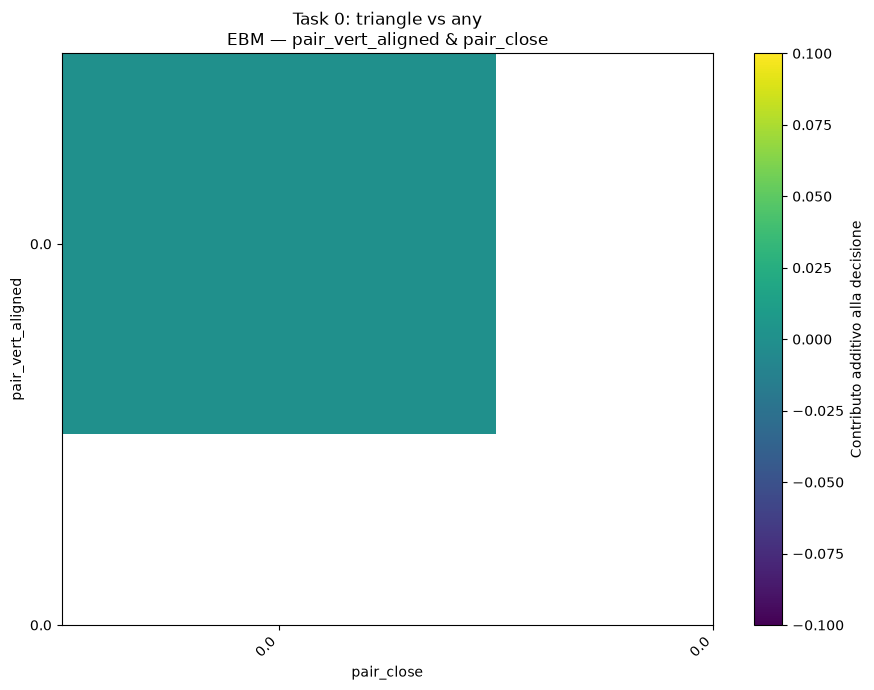

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_pair_vert_aligned_pair_close_heatmap.png


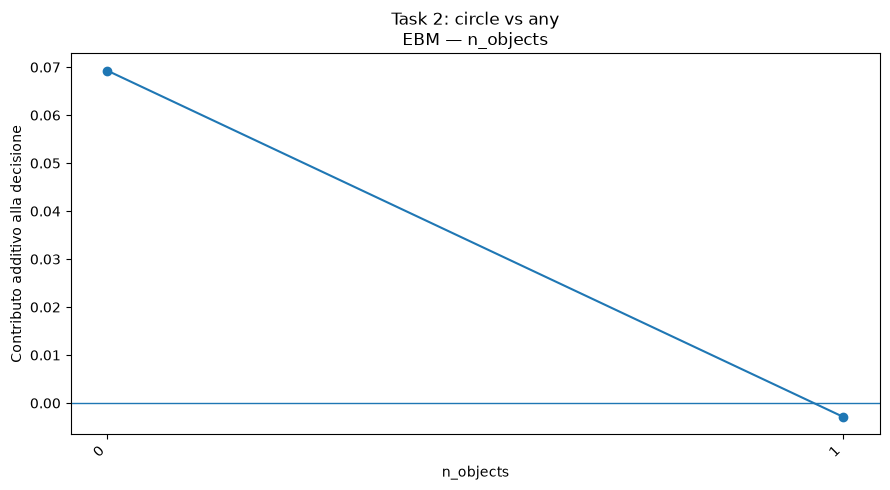

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_n_objects.png


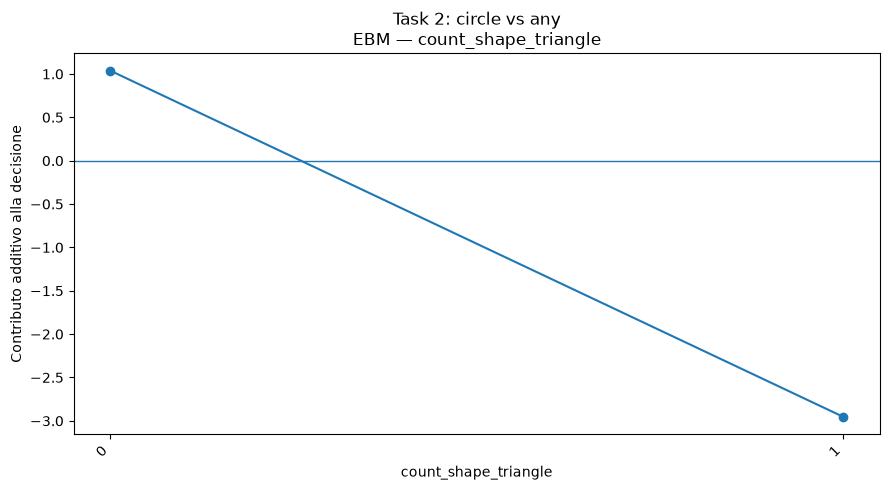

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_count_shape_triangle.png


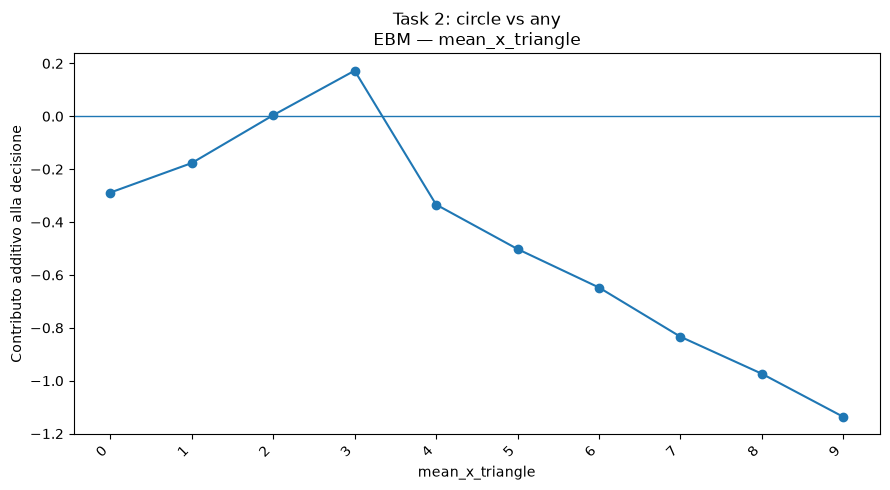

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_mean_x_triangle.png


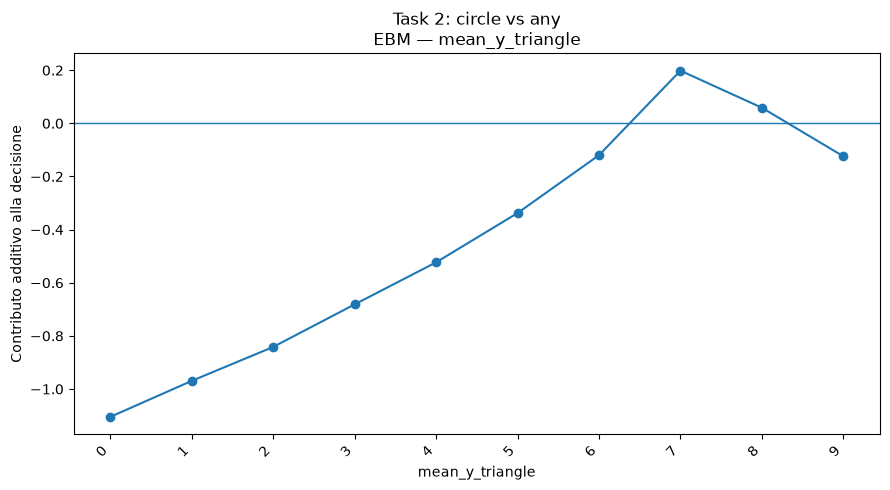

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_mean_y_triangle.png


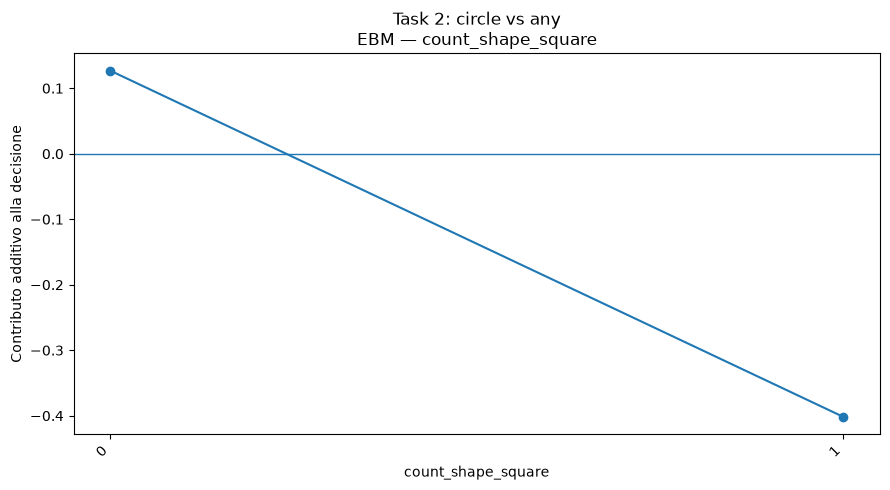

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_count_shape_square.png


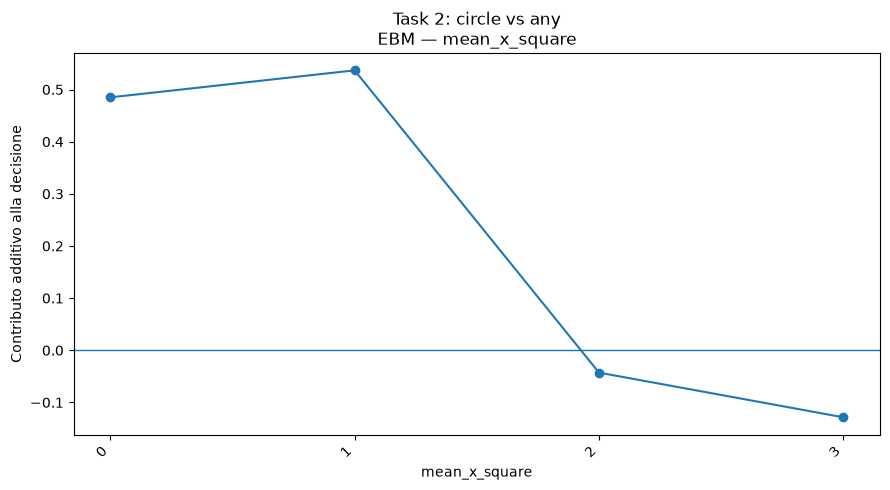

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_mean_x_square.png


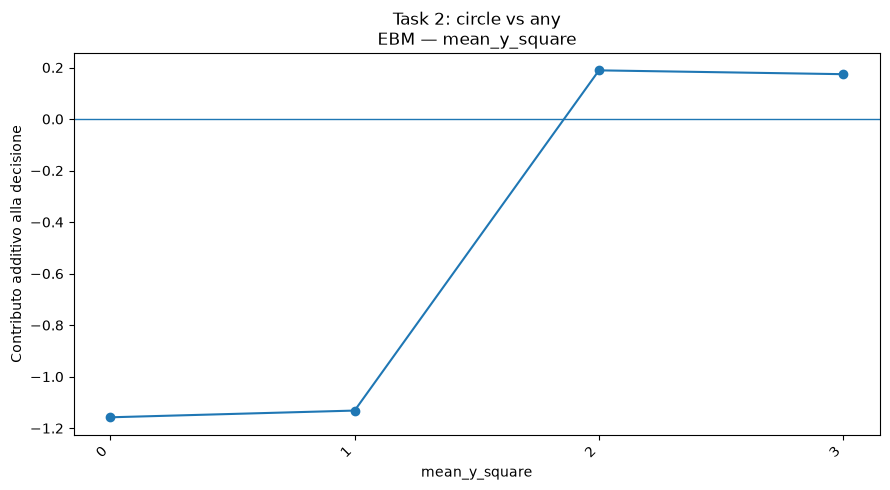

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_mean_y_square.png


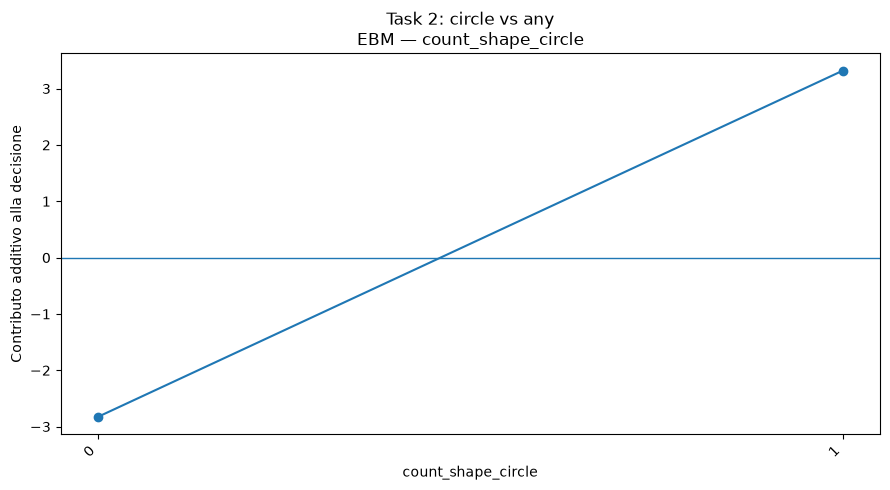

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_count_shape_circle.png


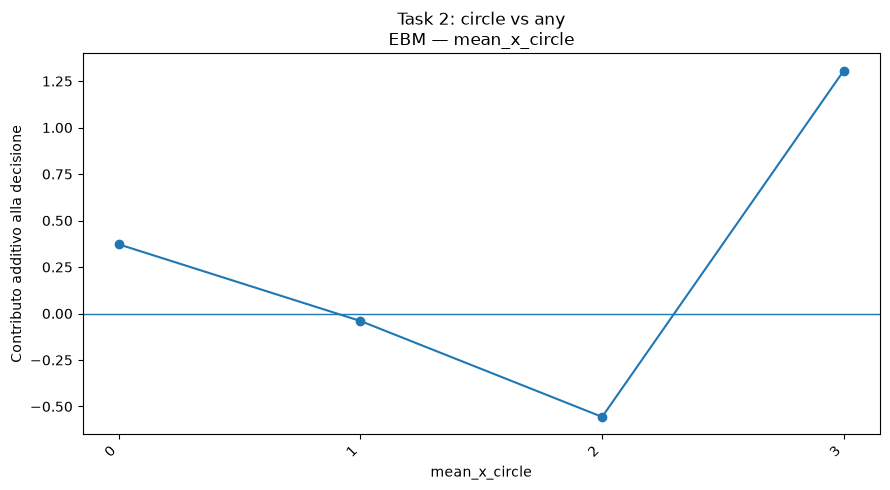

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_mean_x_circle.png


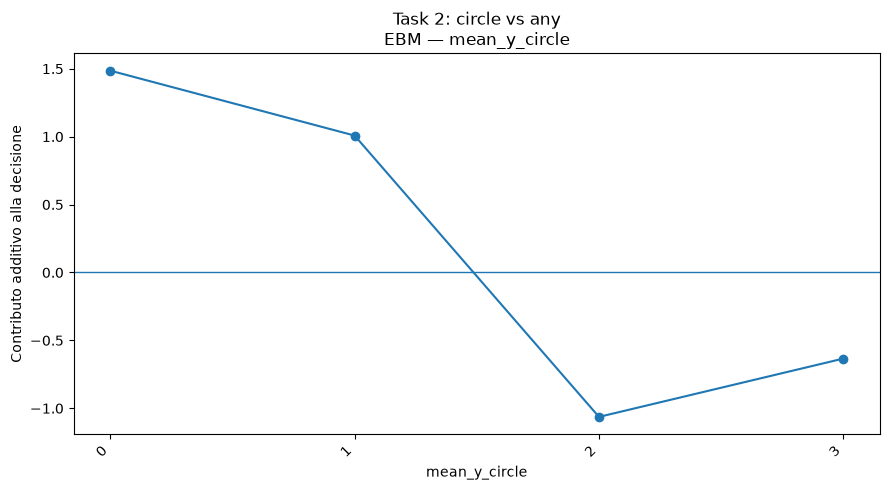

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_mean_y_circle.png


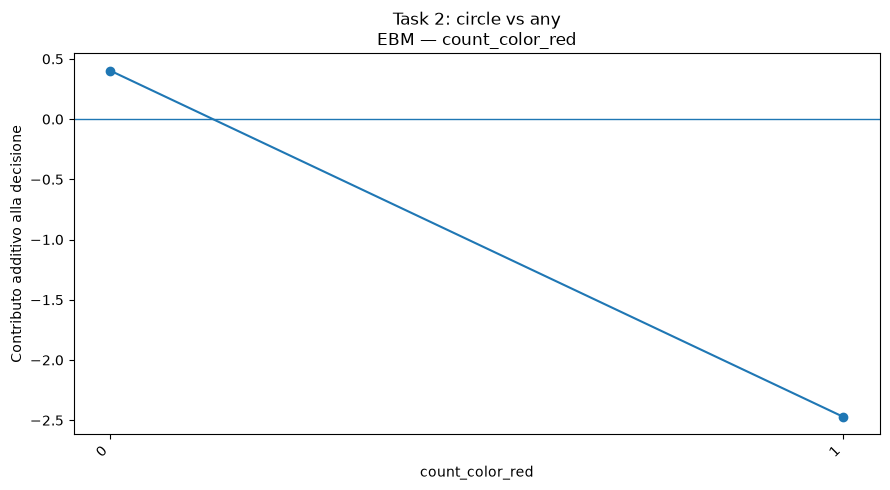

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_count_color_red.png


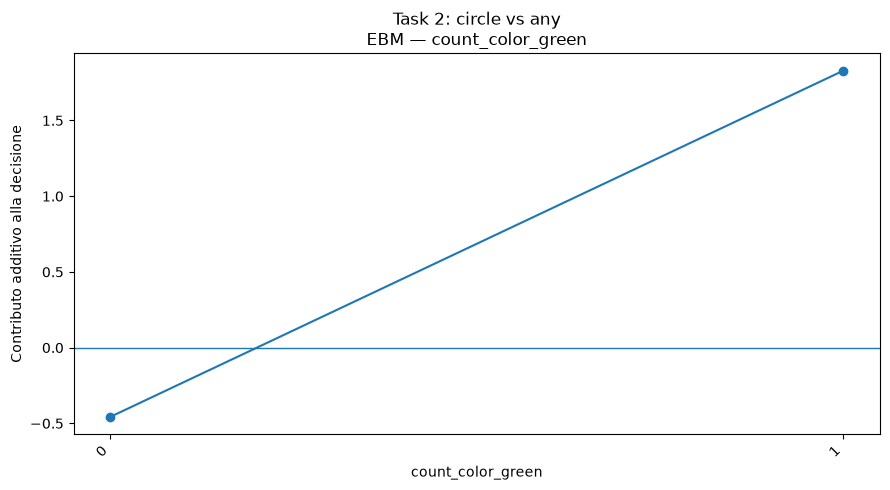

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_count_color_green.png


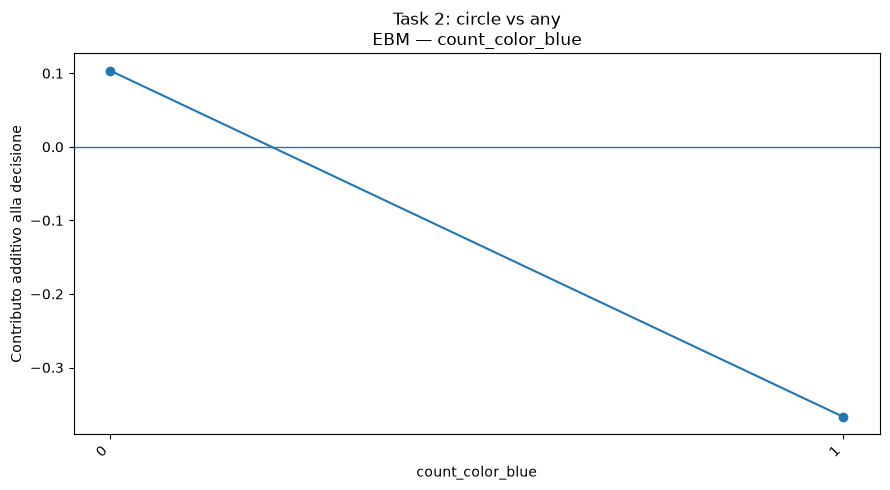

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_count_color_blue.png


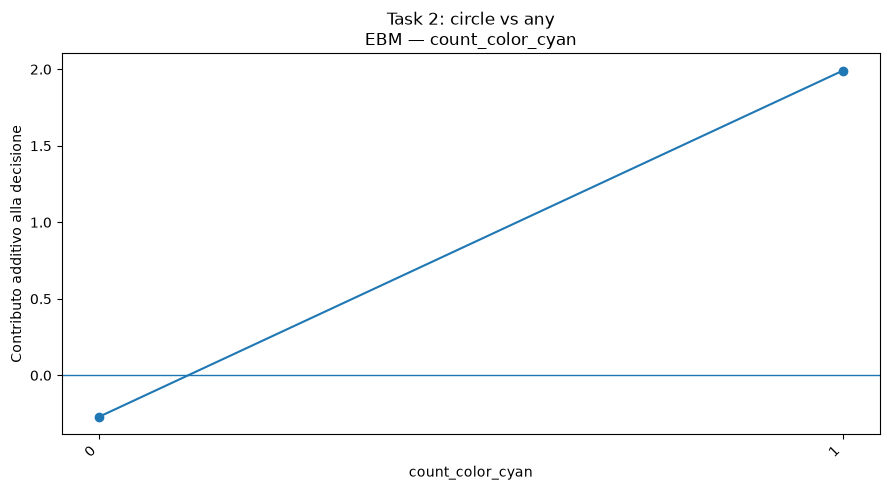

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_count_color_cyan.png


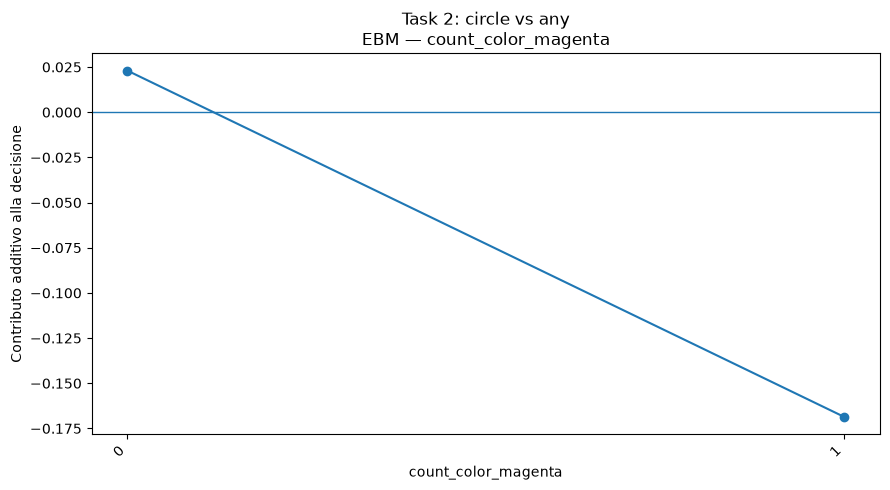

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_count_color_magenta.png


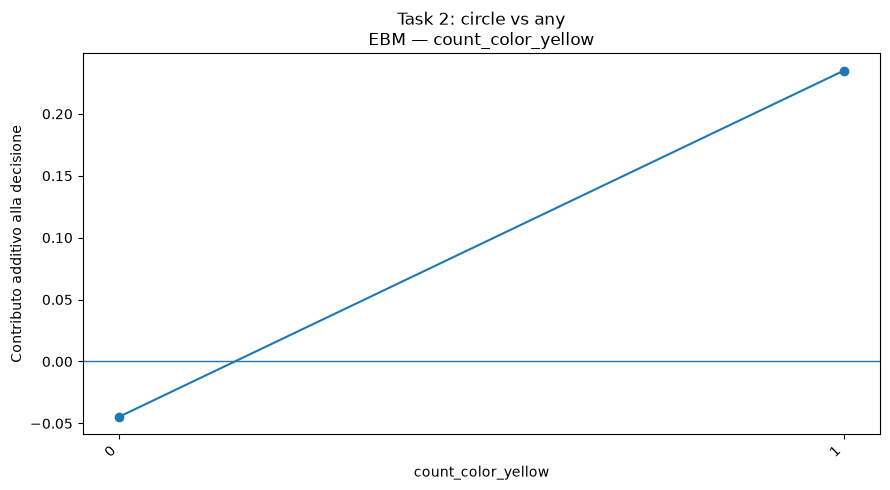

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_count_color_yellow.png


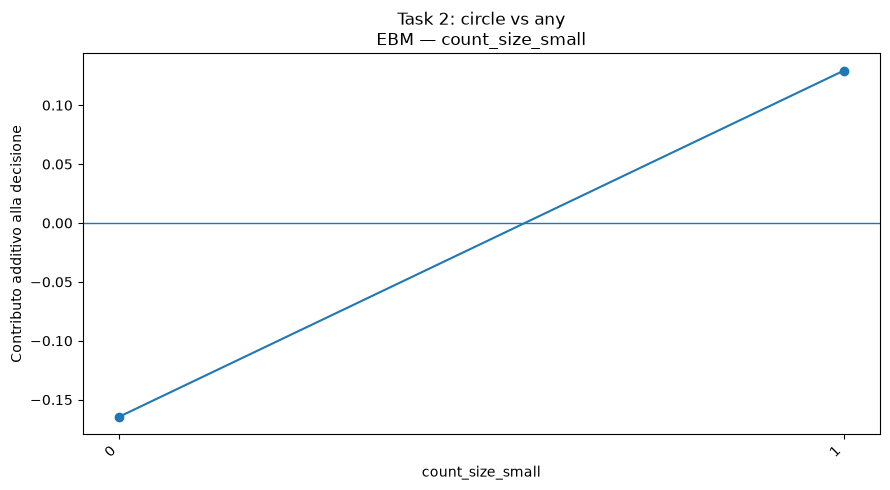

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_count_size_small.png


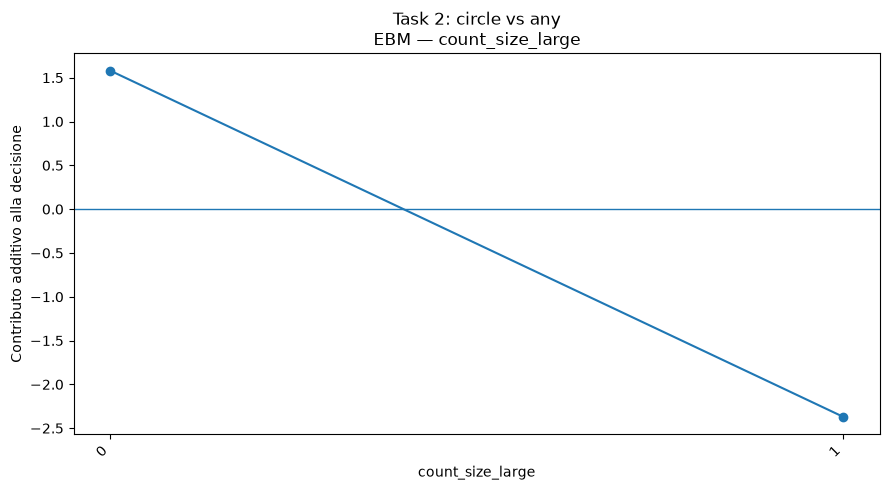

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_count_size_large.png


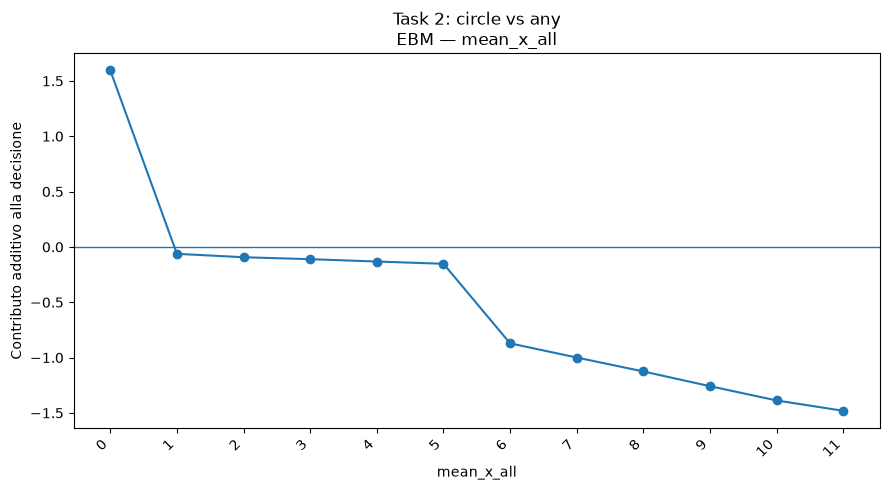

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_mean_x_all.png


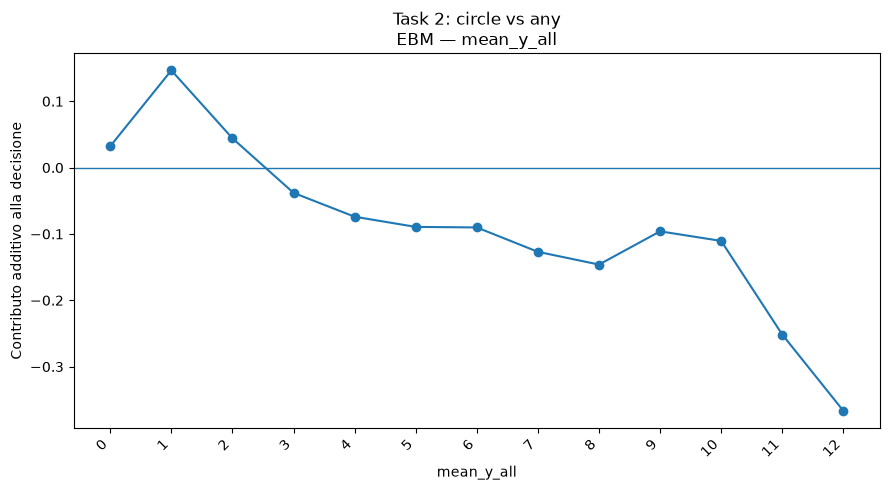

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_mean_y_all.png


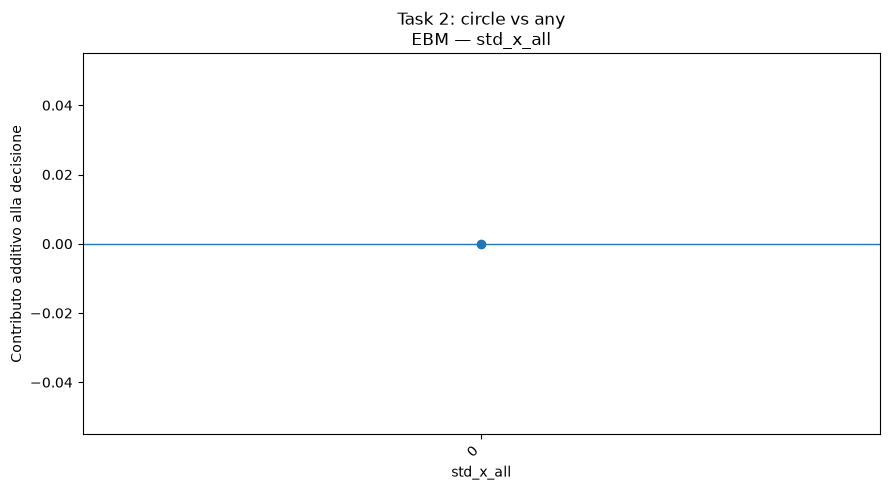

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_std_x_all.png


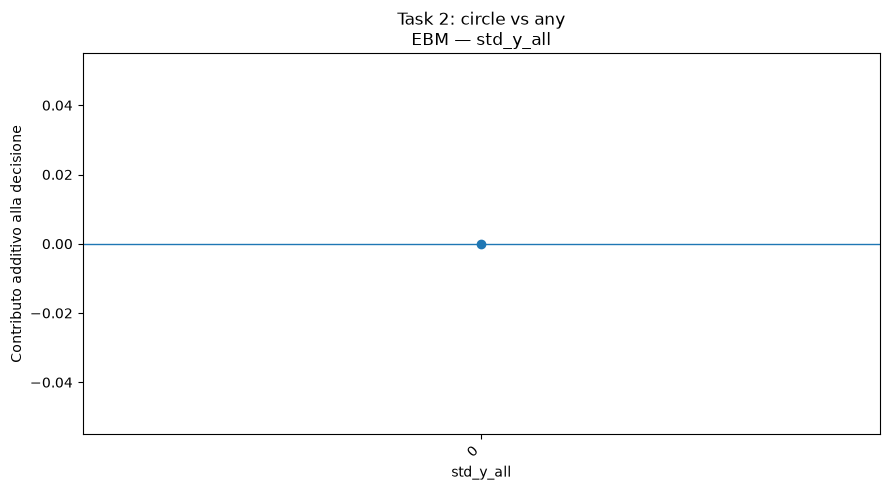

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_std_y_all.png


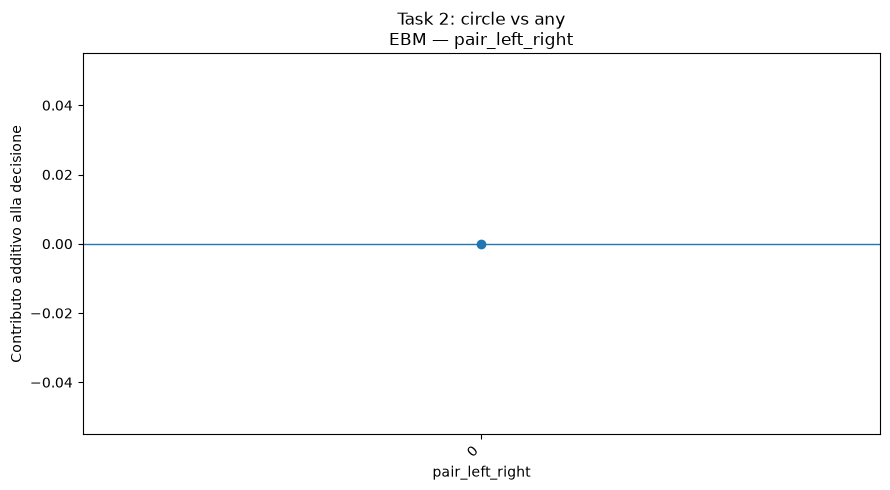

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_pair_left_right.png


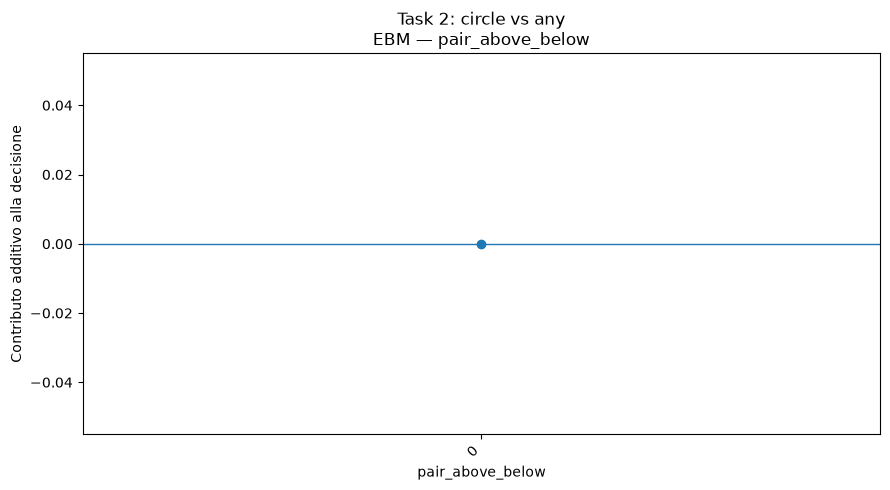

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_pair_above_below.png


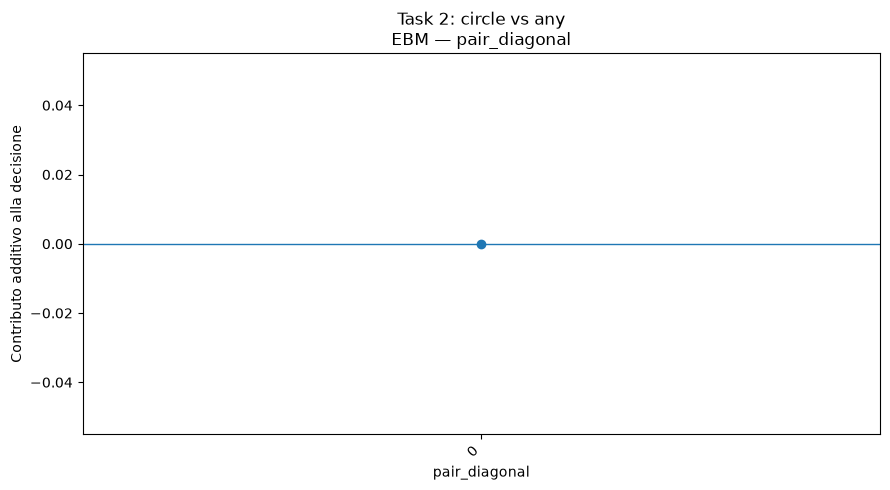

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_pair_diagonal.png


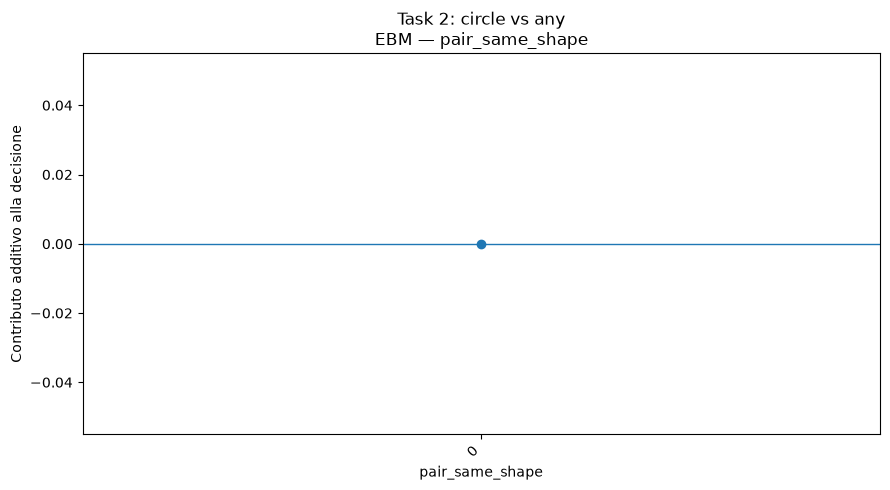

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_pair_same_shape.png


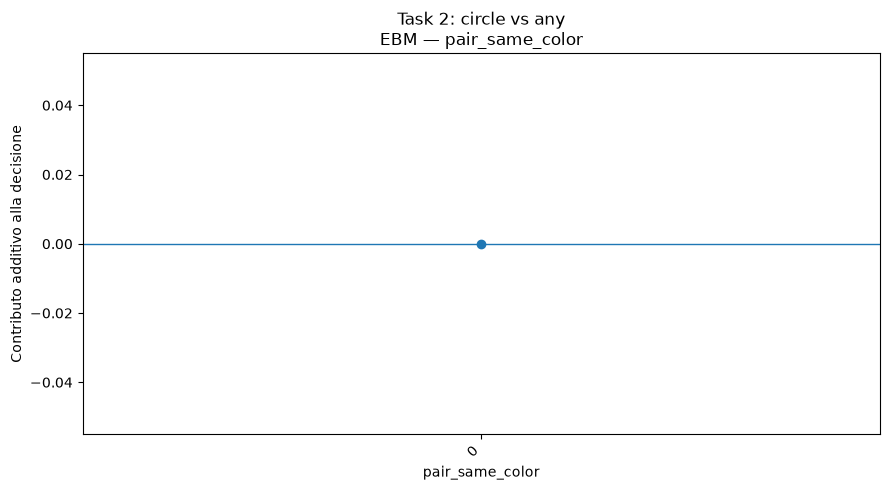

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_pair_same_color.png


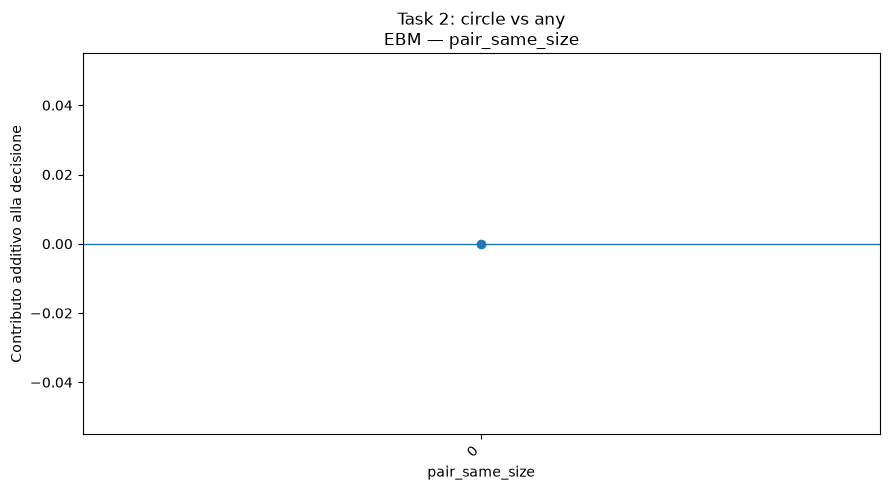

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_pair_same_size.png


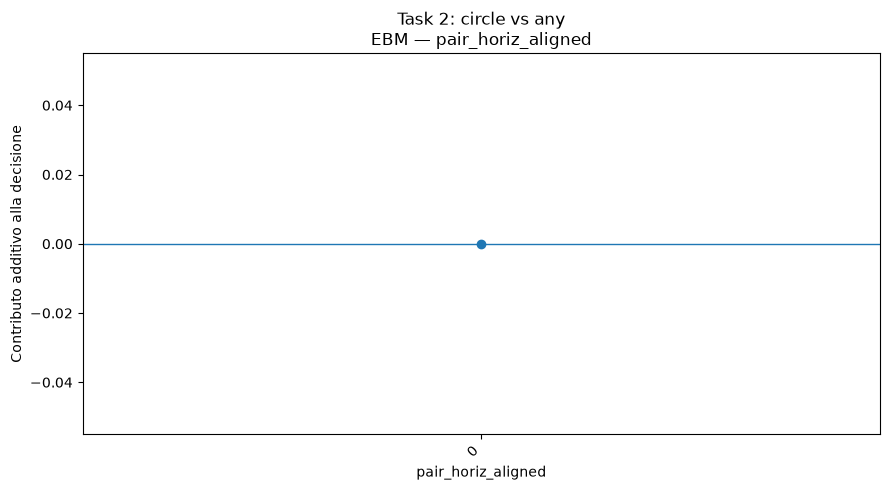

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_pair_horiz_aligned.png


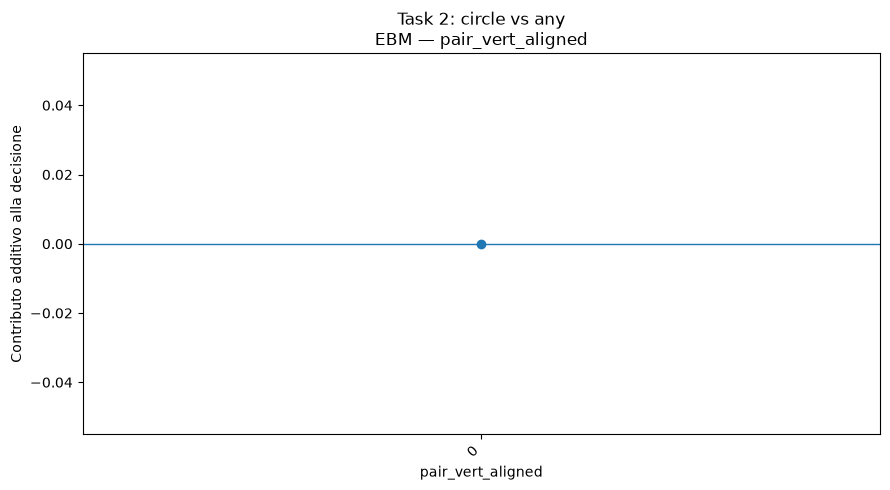

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_pair_vert_aligned.png


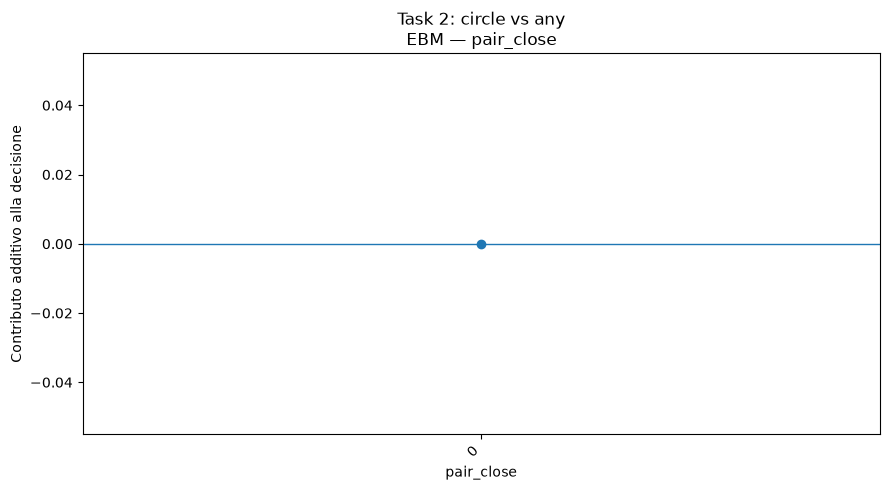

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_pair_close.png


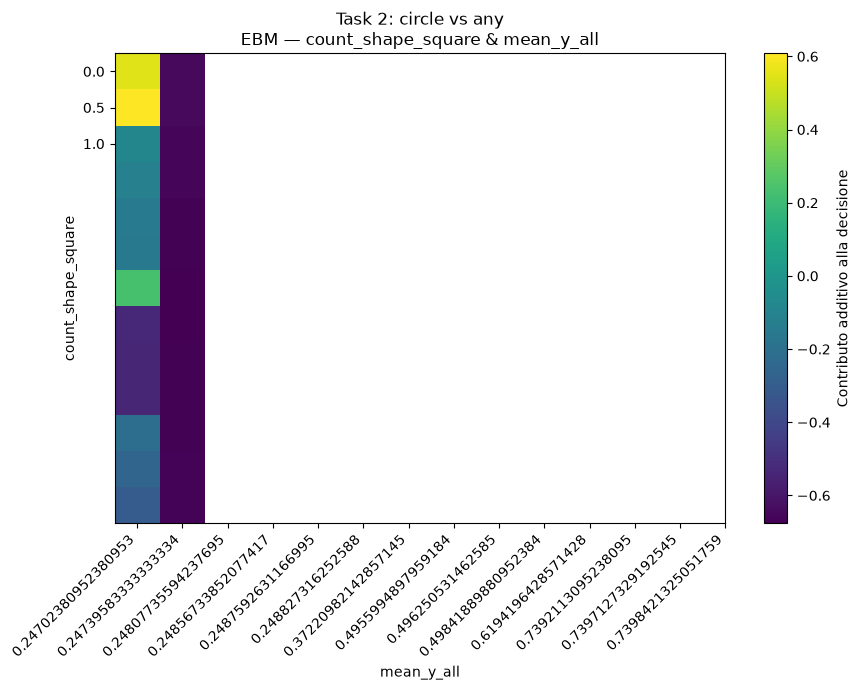

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_count_shape_square_mean_y_all_heatmap.png


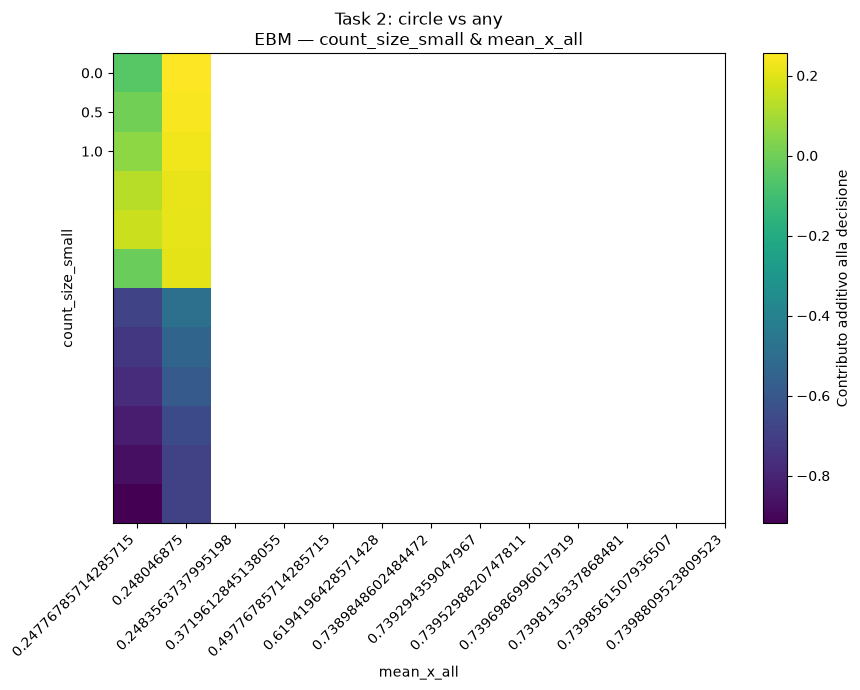

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_count_size_small_mean_x_all_heatmap.png


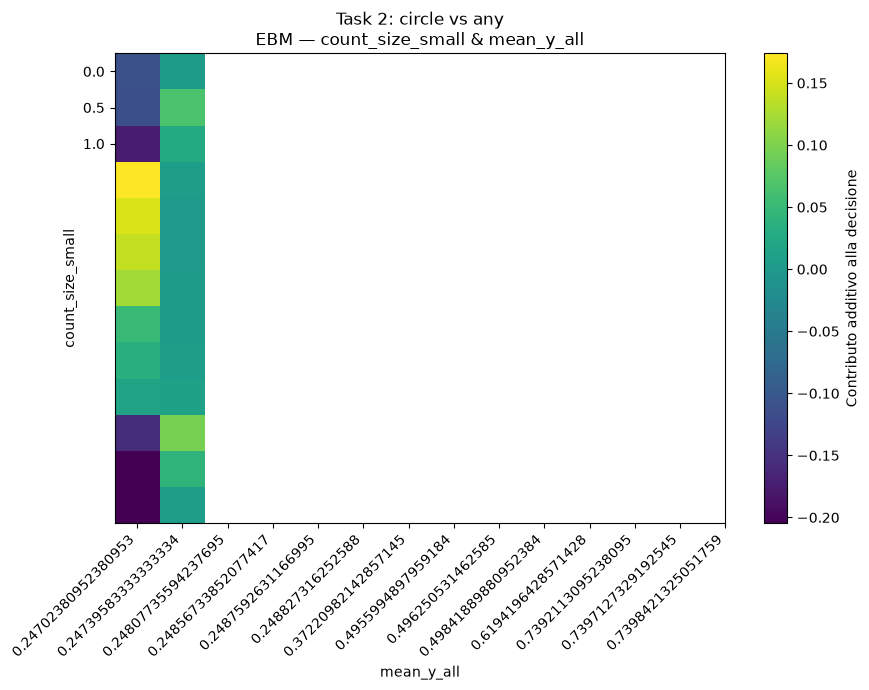

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_count_size_small_mean_y_all_heatmap.png


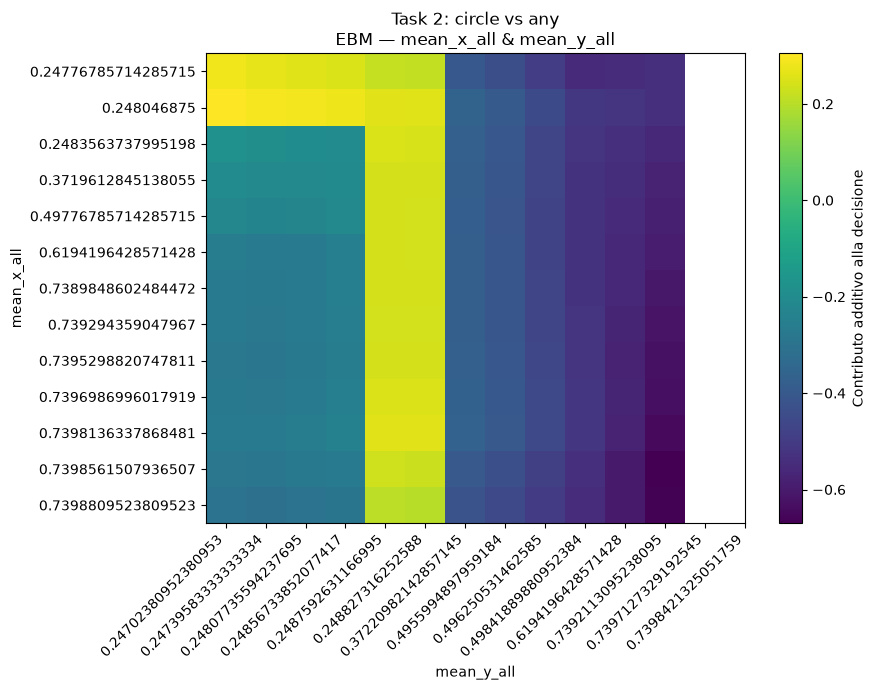

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_mean_x_all_mean_y_all_heatmap.png


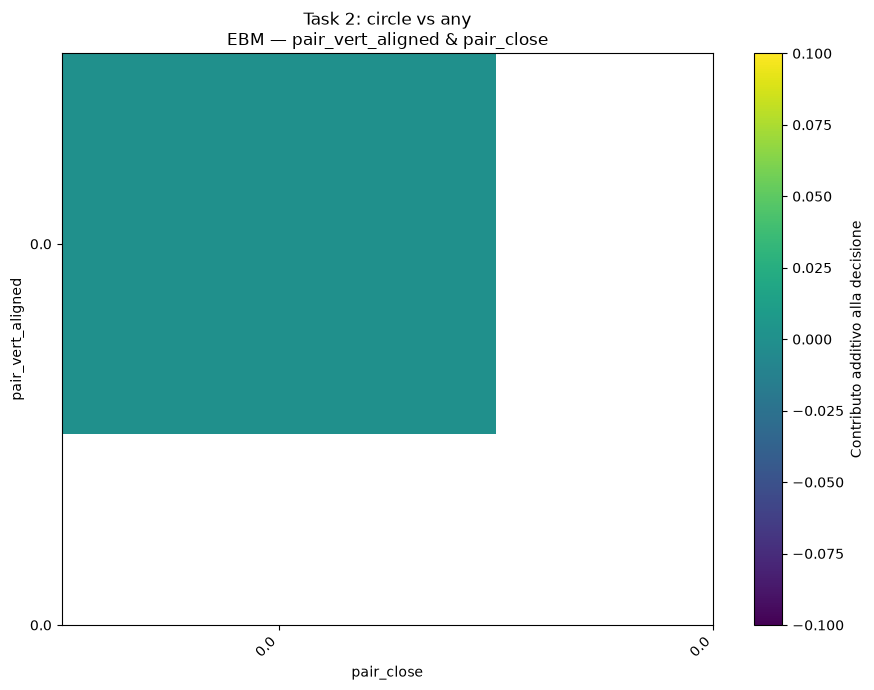

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_pair_vert_aligned_pair_close_heatmap.png


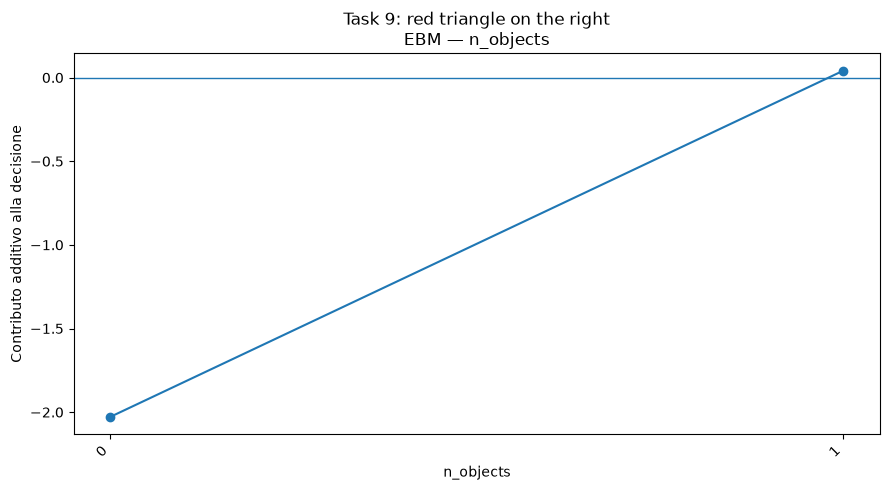

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_n_objects.png


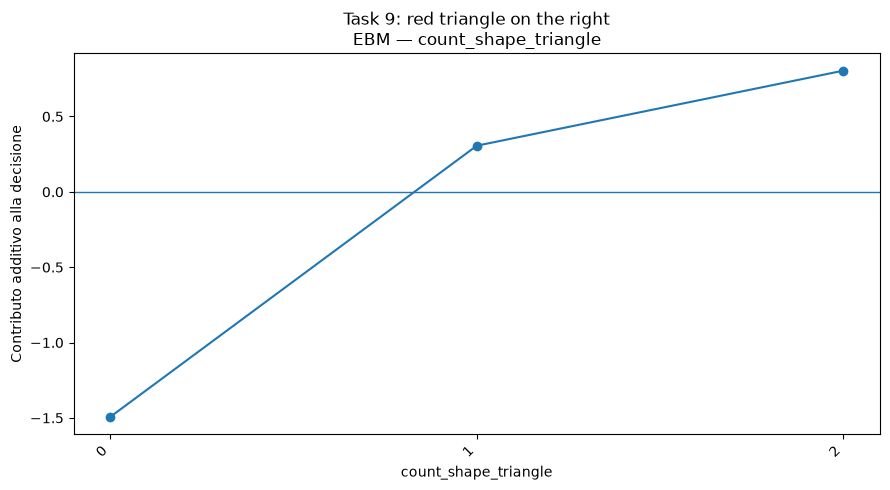

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_count_shape_triangle.png


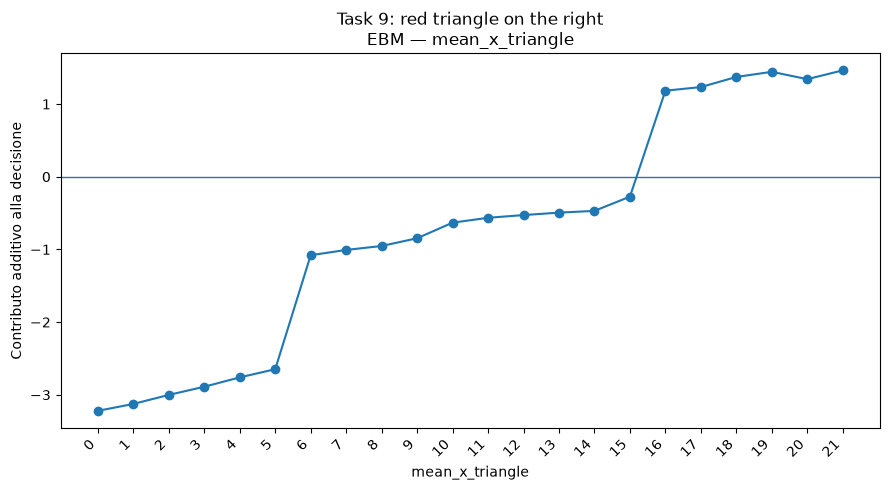

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_mean_x_triangle.png


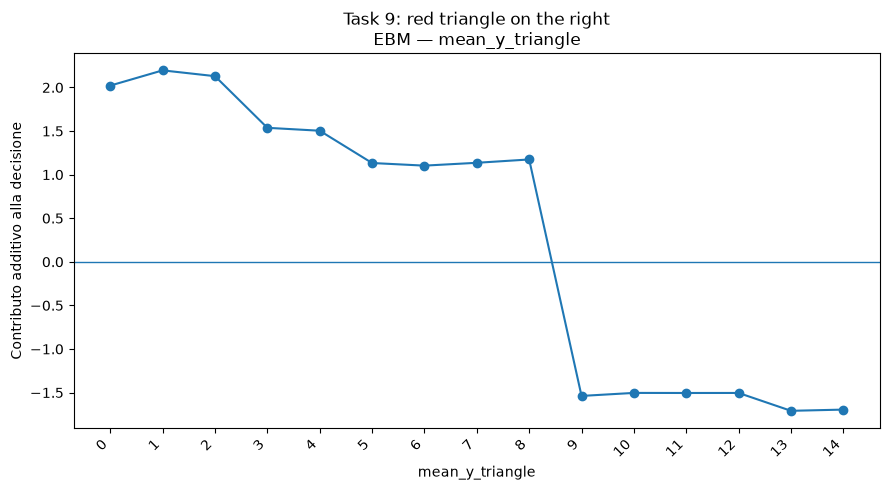

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_mean_y_triangle.png


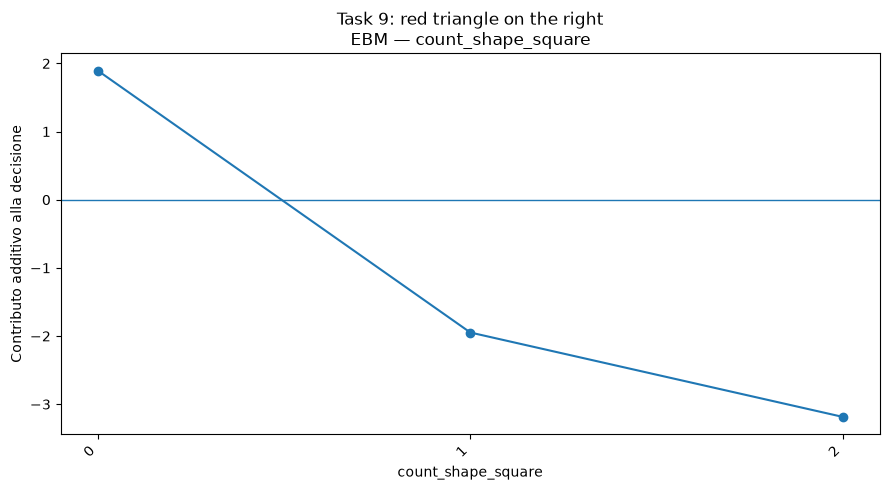

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_count_shape_square.png


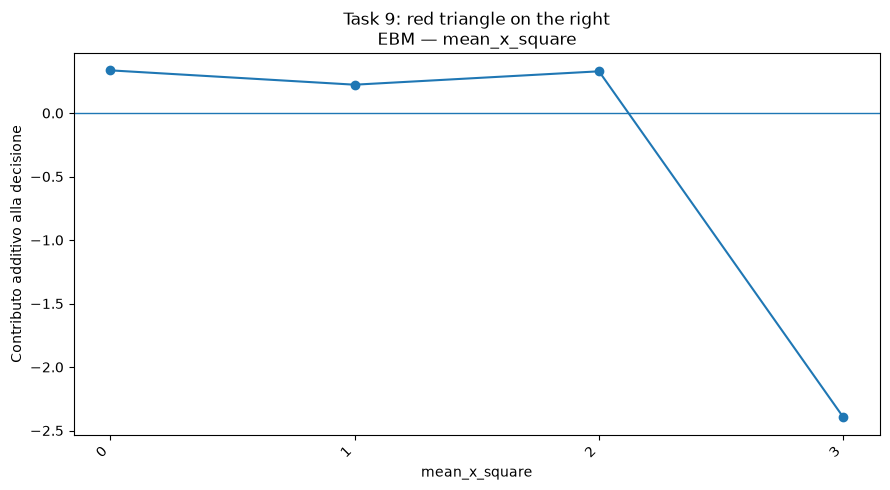

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_mean_x_square.png


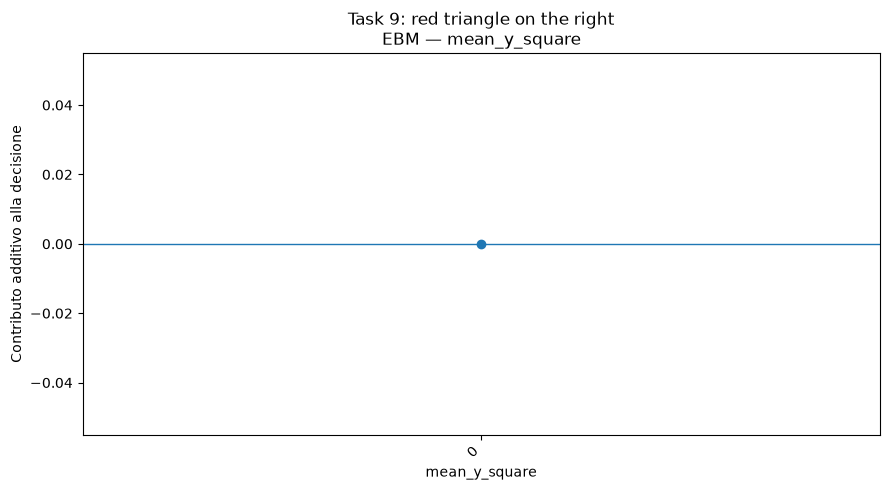

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_mean_y_square.png


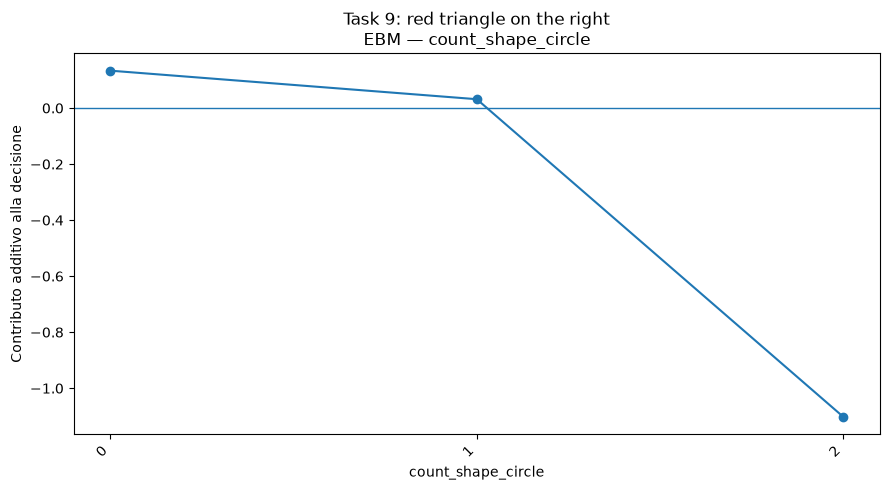

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_count_shape_circle.png


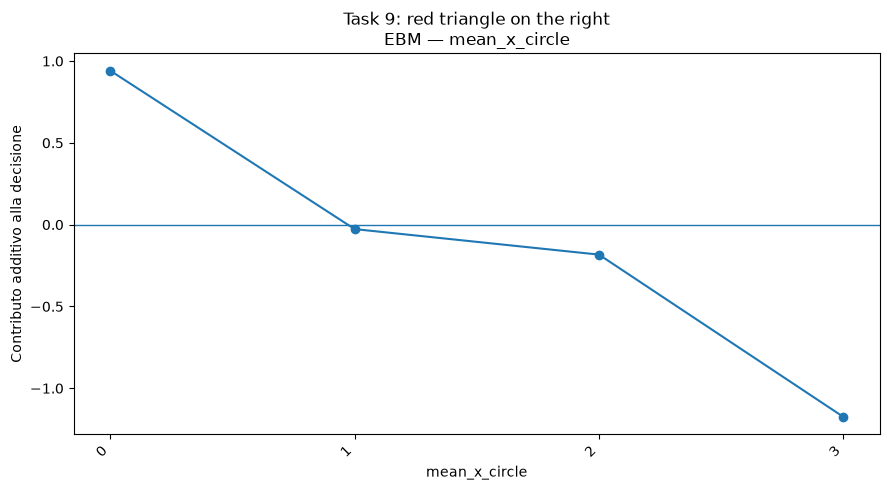

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_mean_x_circle.png


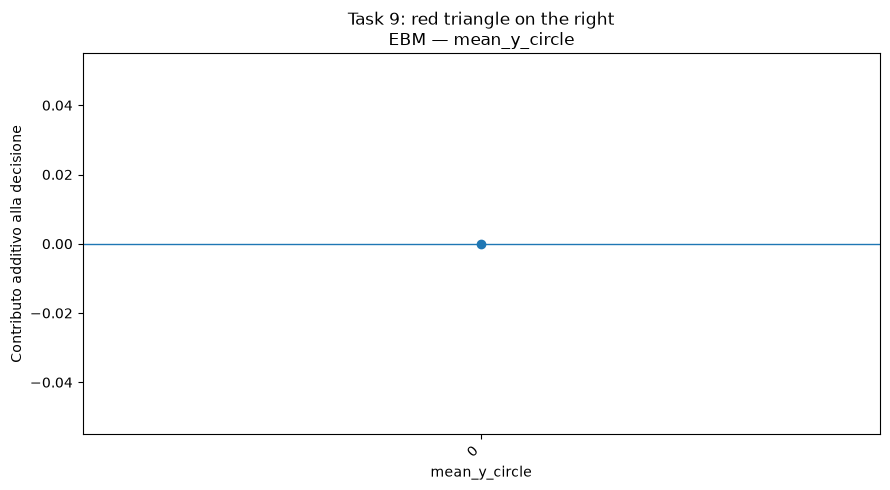

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_mean_y_circle.png


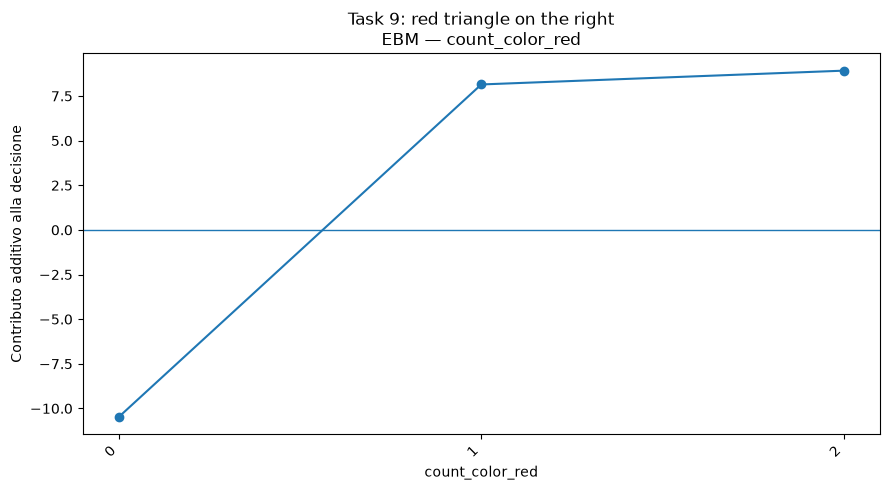

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_count_color_red.png


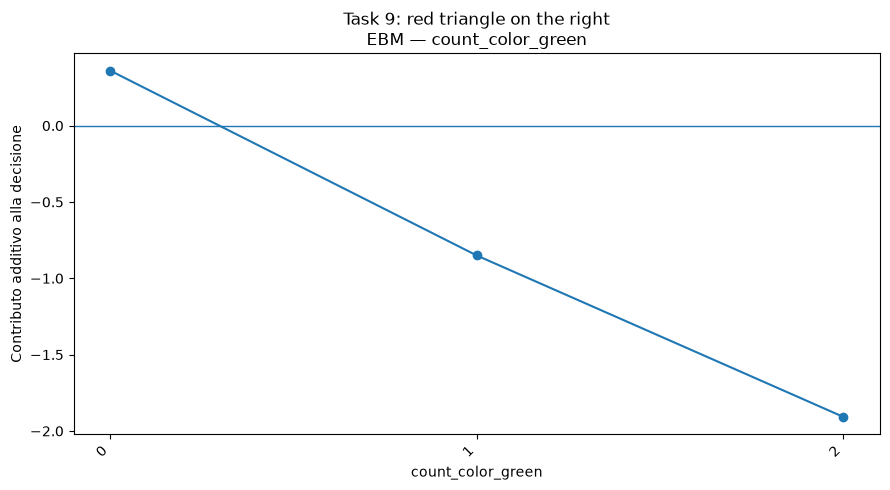

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_count_color_green.png


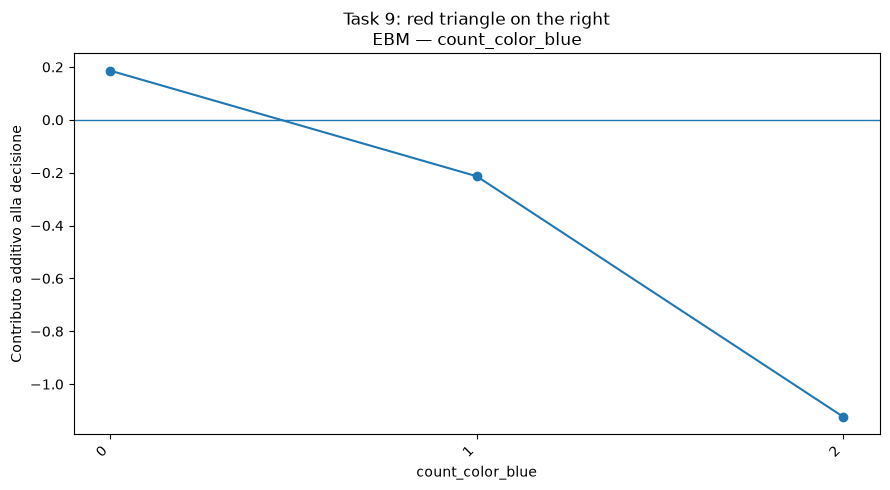

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_count_color_blue.png


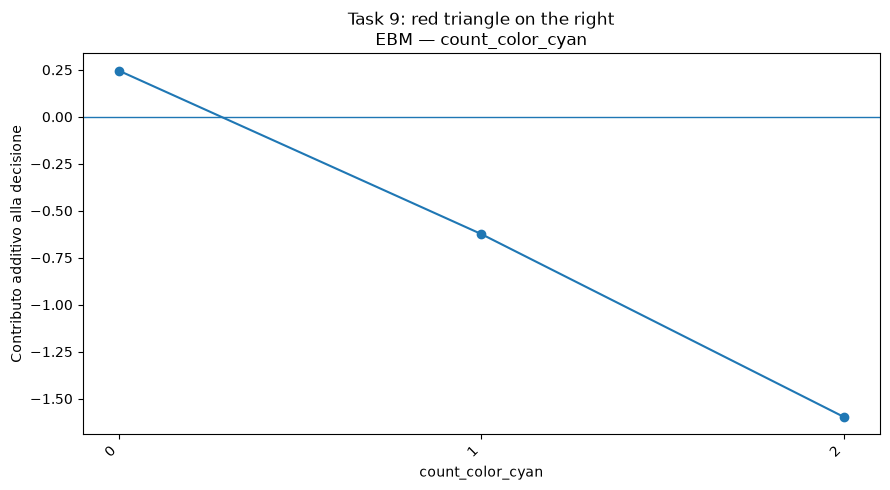

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_count_color_cyan.png


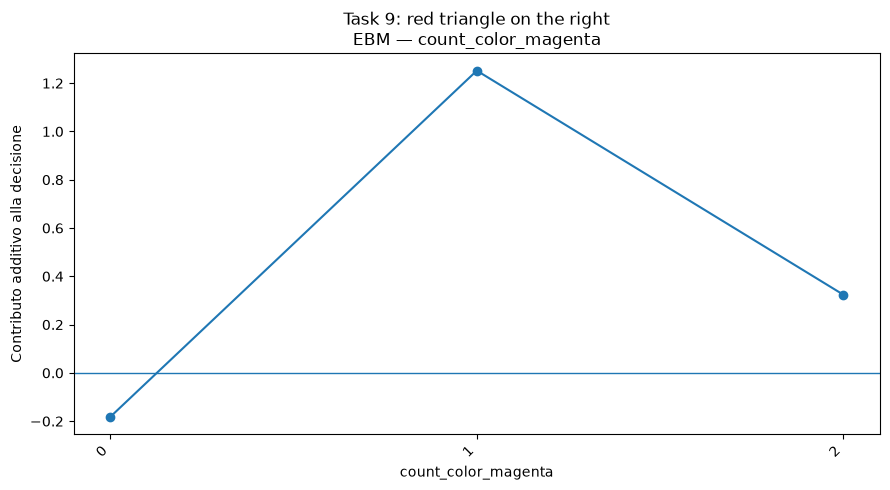

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_count_color_magenta.png


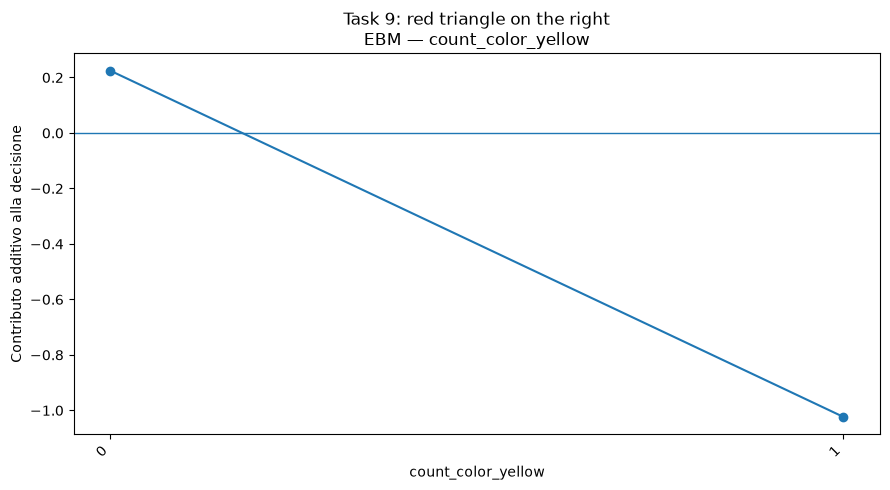

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_count_color_yellow.png


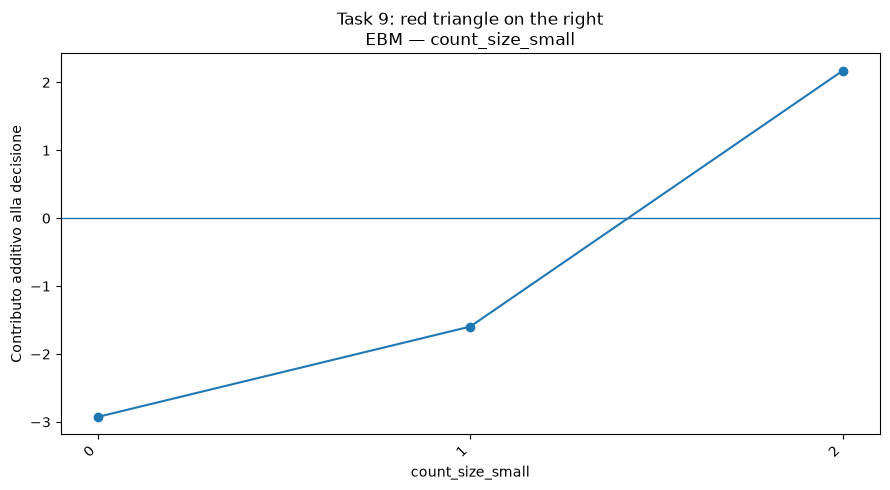

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_count_size_small.png


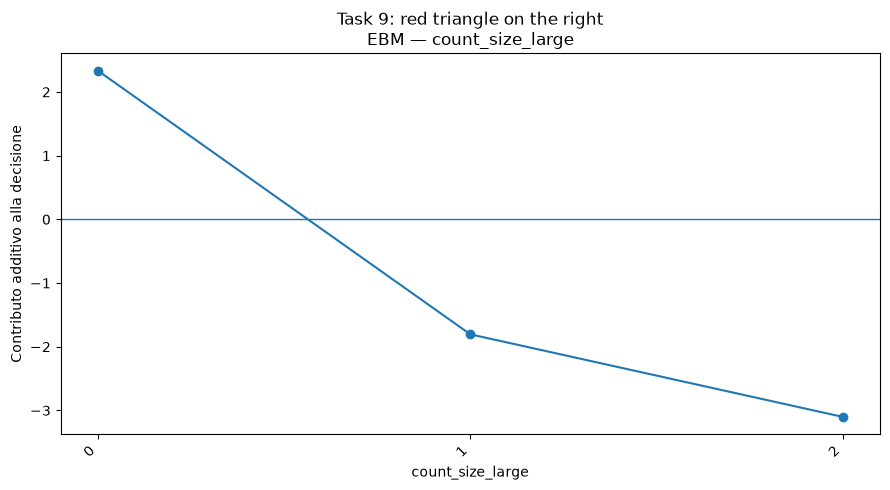

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_count_size_large.png


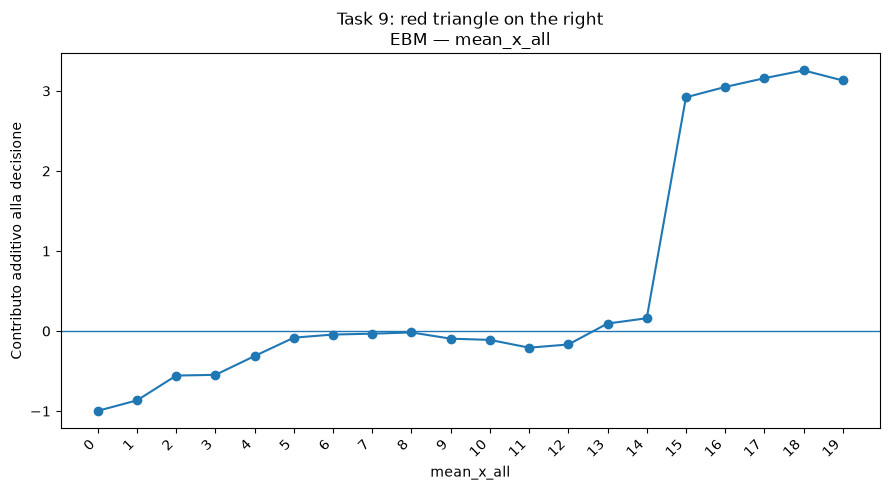

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_mean_x_all.png


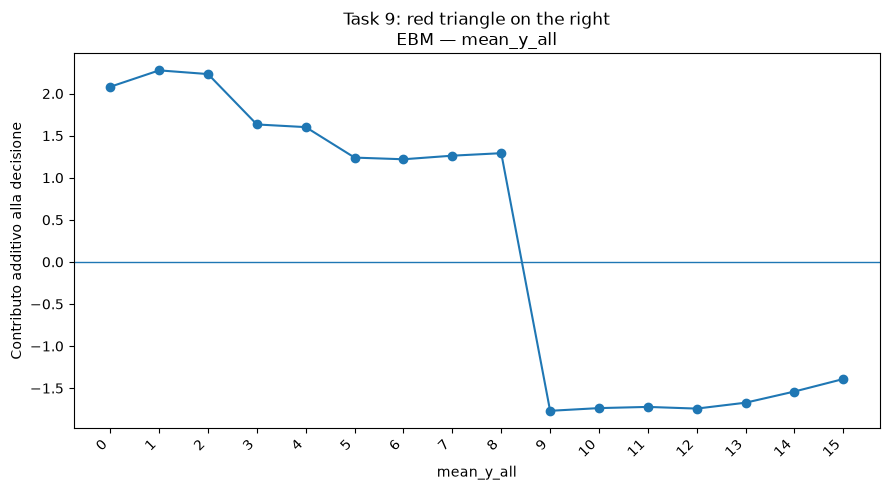

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_mean_y_all.png


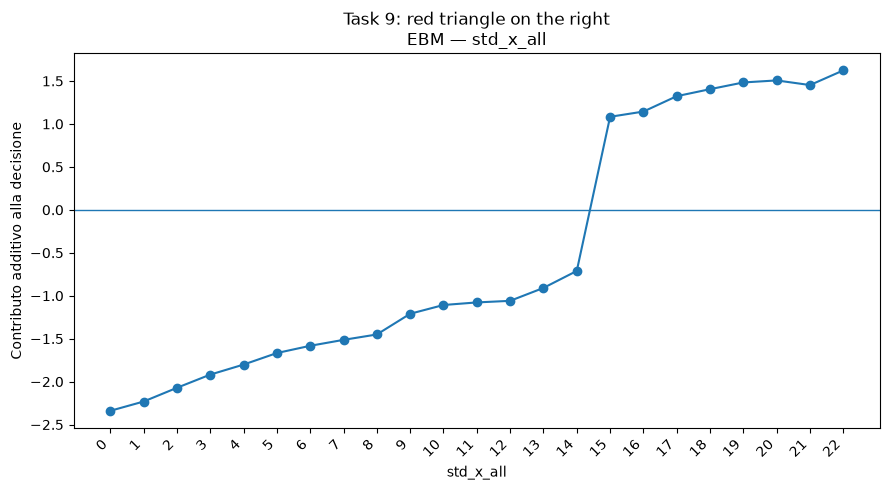

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_std_x_all.png


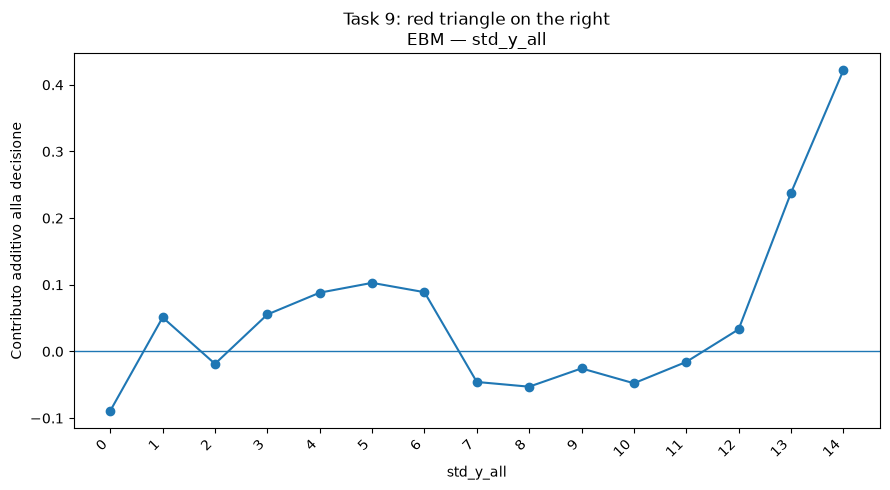

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_std_y_all.png


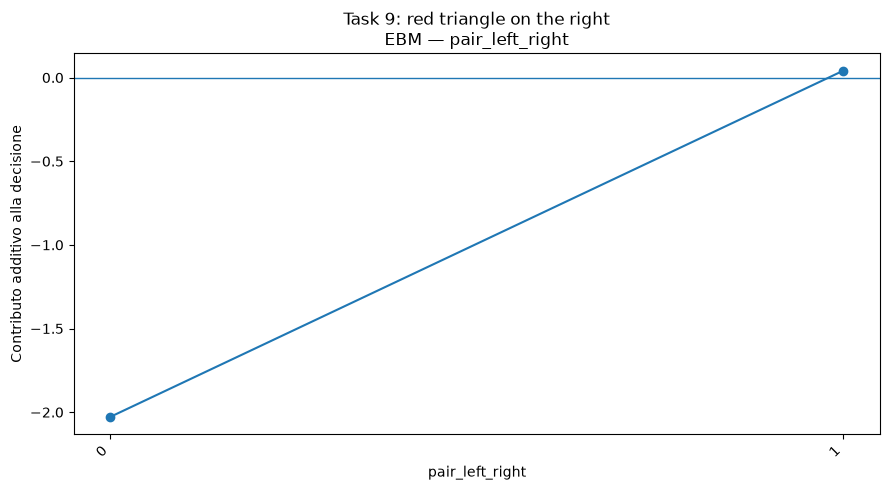

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_pair_left_right.png


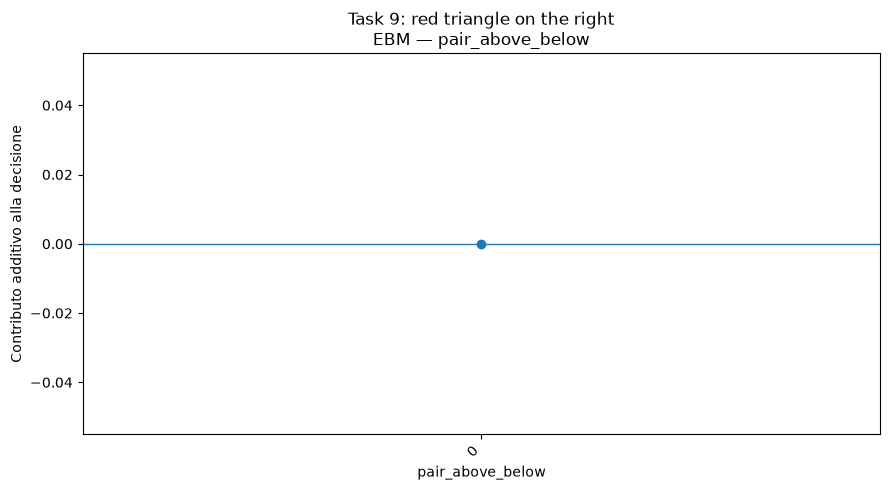

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_pair_above_below.png


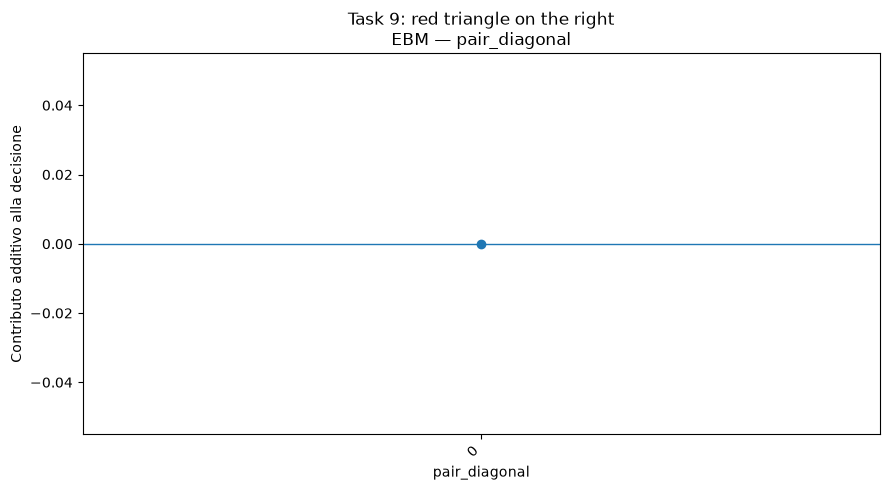

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_pair_diagonal.png


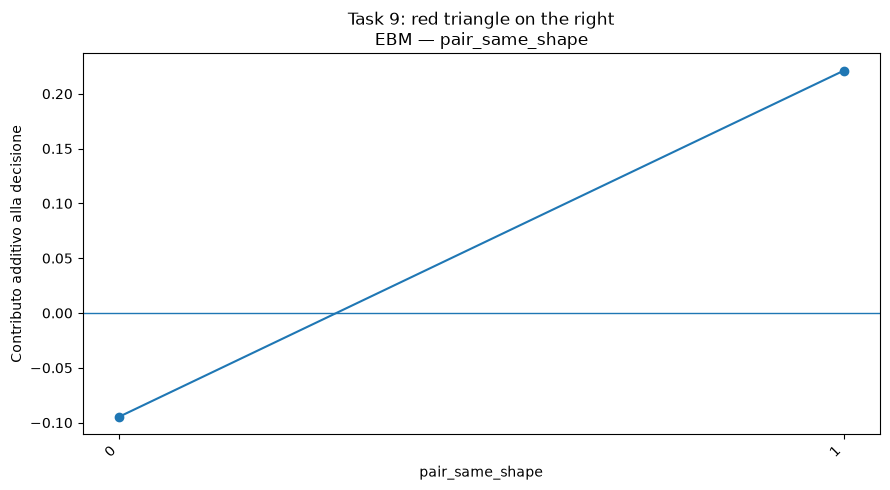

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_pair_same_shape.png


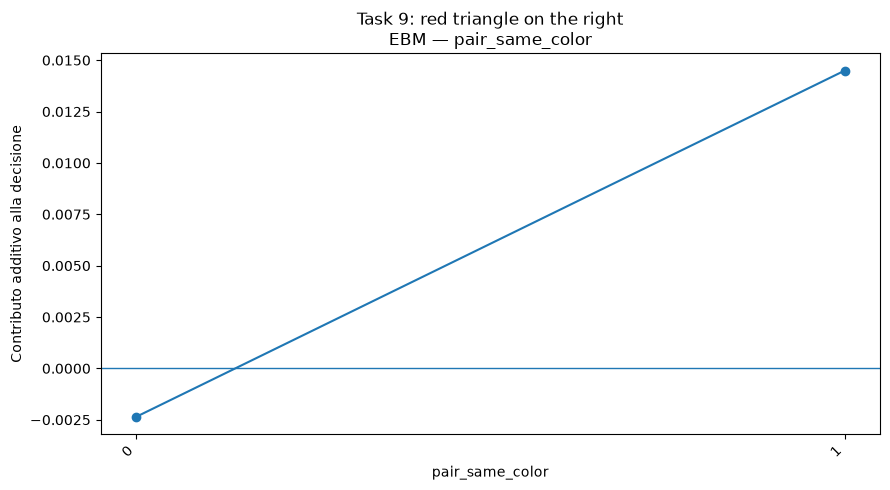

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_pair_same_color.png


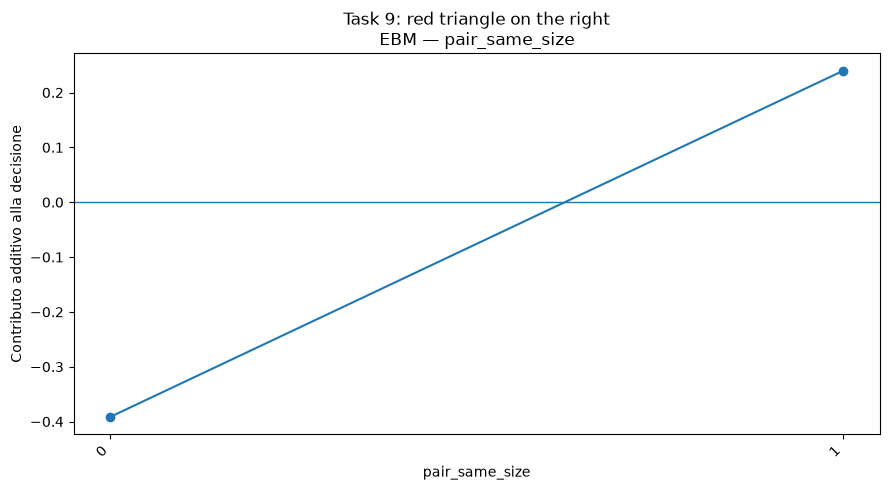

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_pair_same_size.png


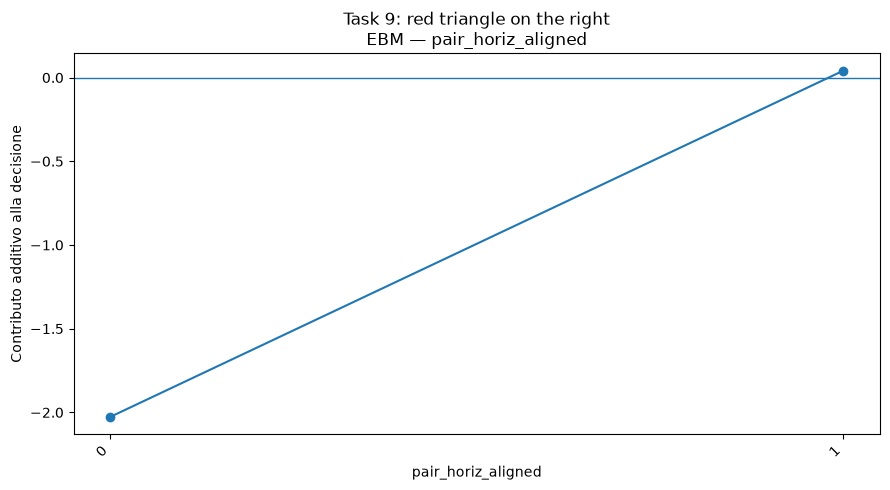

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_pair_horiz_aligned.png


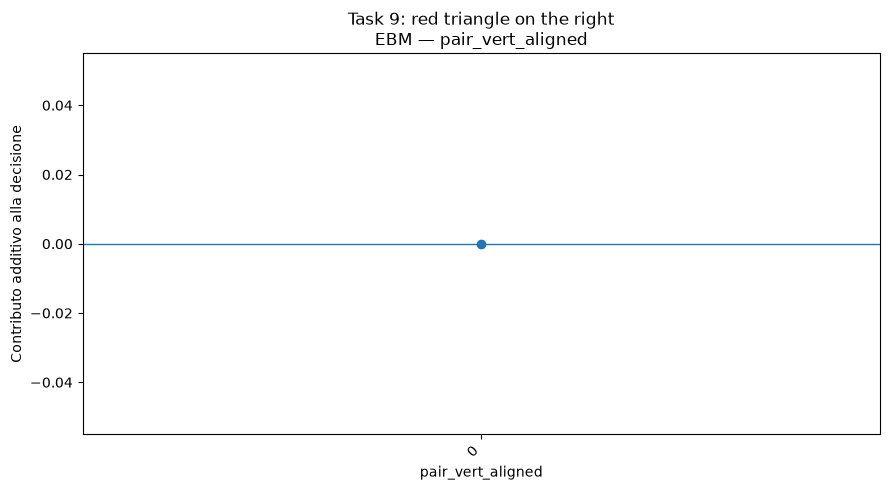

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_pair_vert_aligned.png


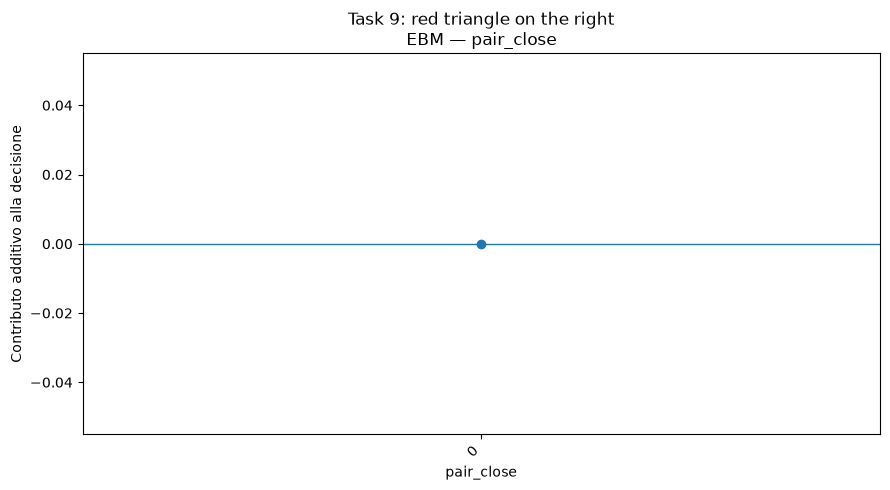

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_pair_close.png


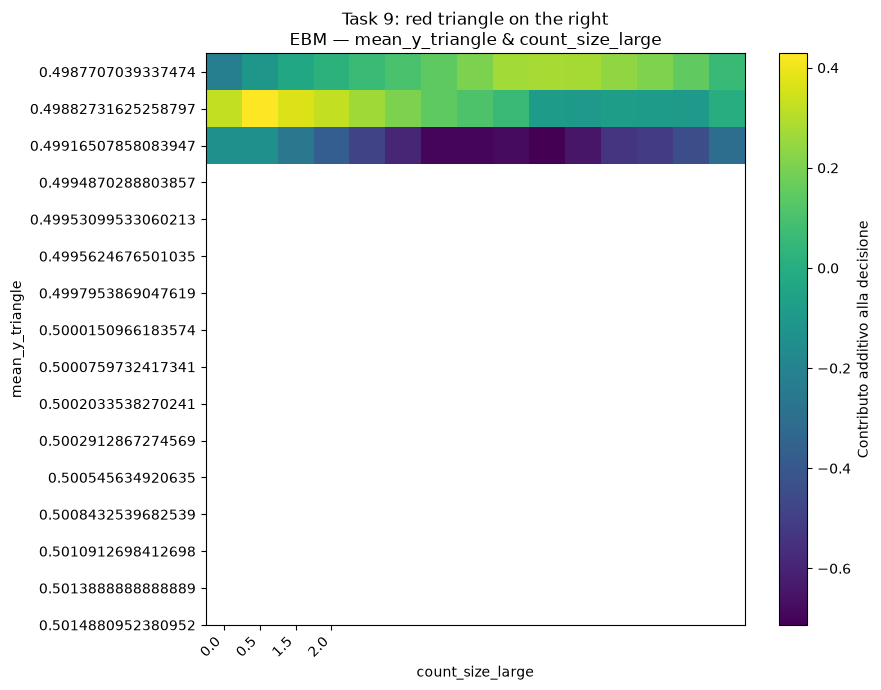

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_mean_y_triangle_count_size_large_heatmap.png


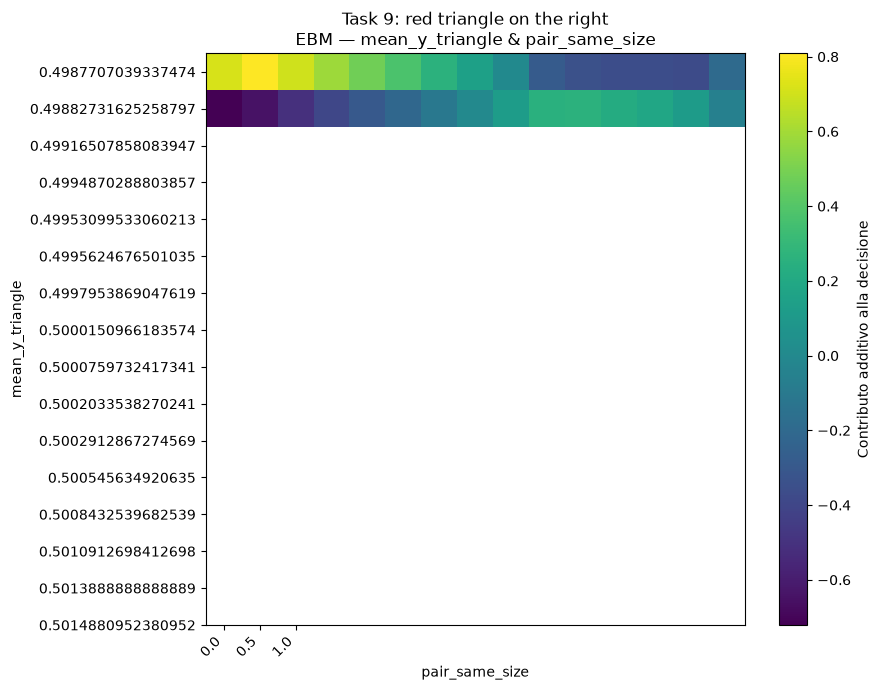

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_mean_y_triangle_pair_same_size_heatmap.png


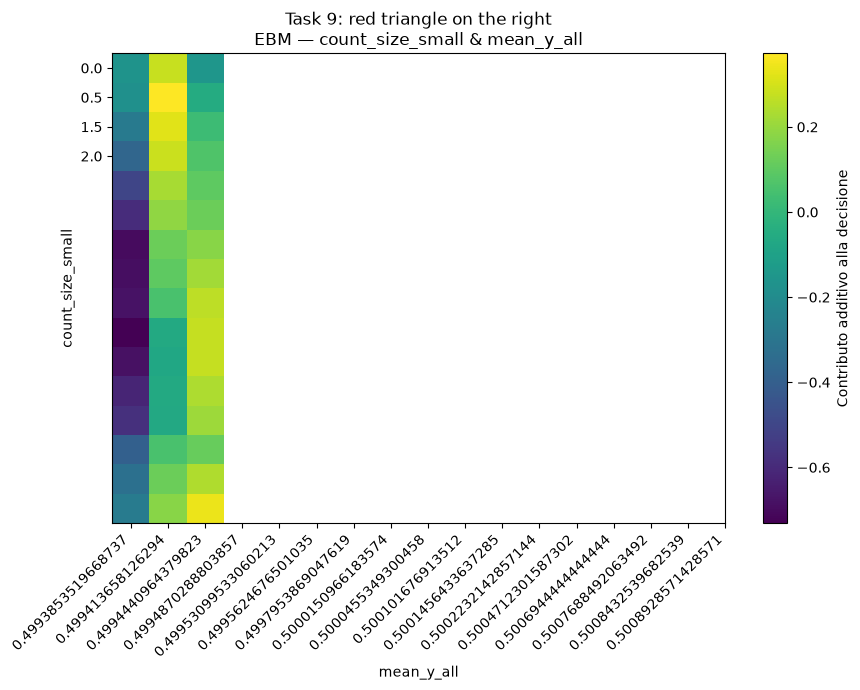

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_count_size_small_mean_y_all_heatmap.png


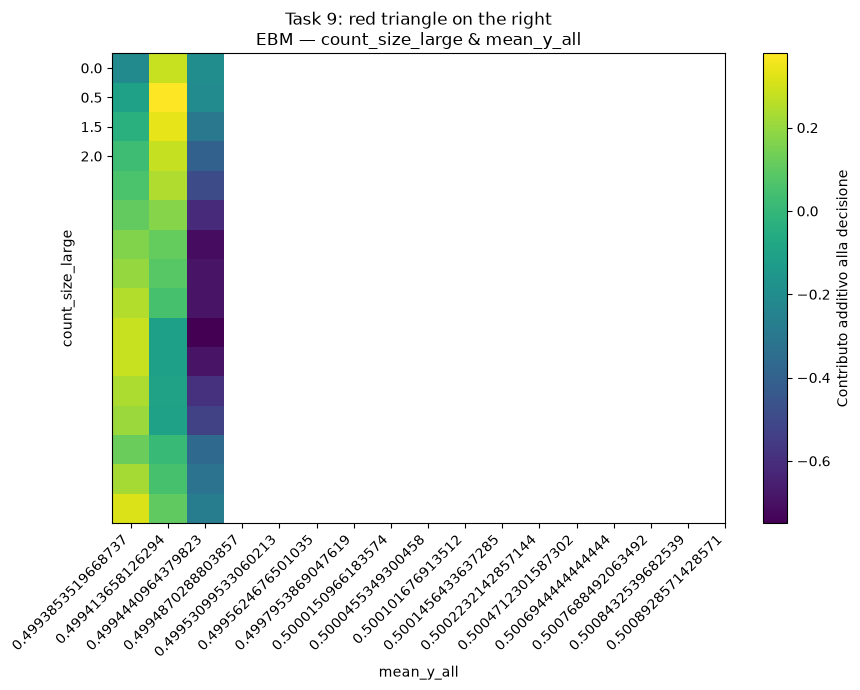

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_count_size_large_mean_y_all_heatmap.png


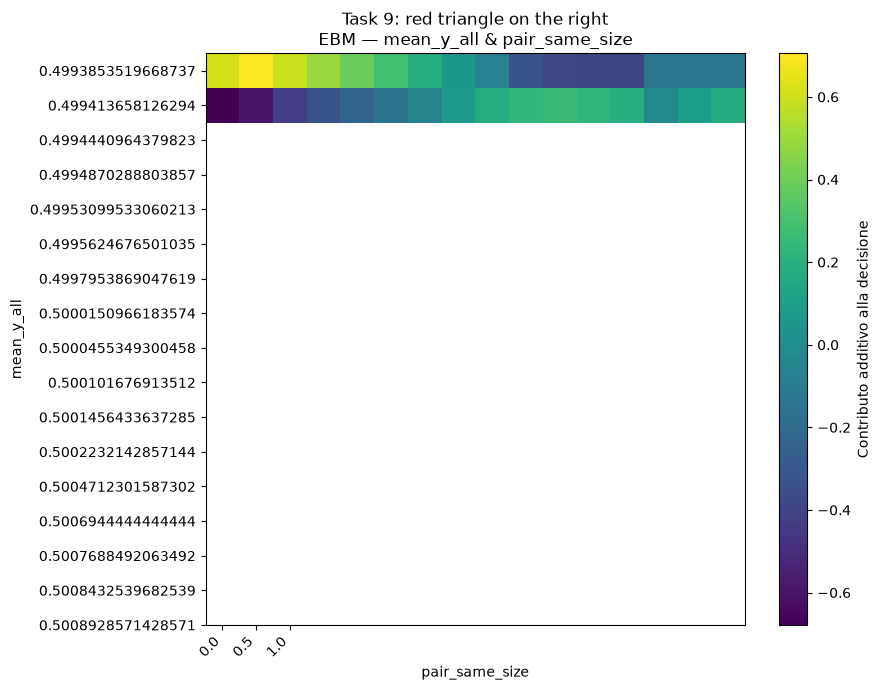

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_mean_y_all_pair_same_size_heatmap.png


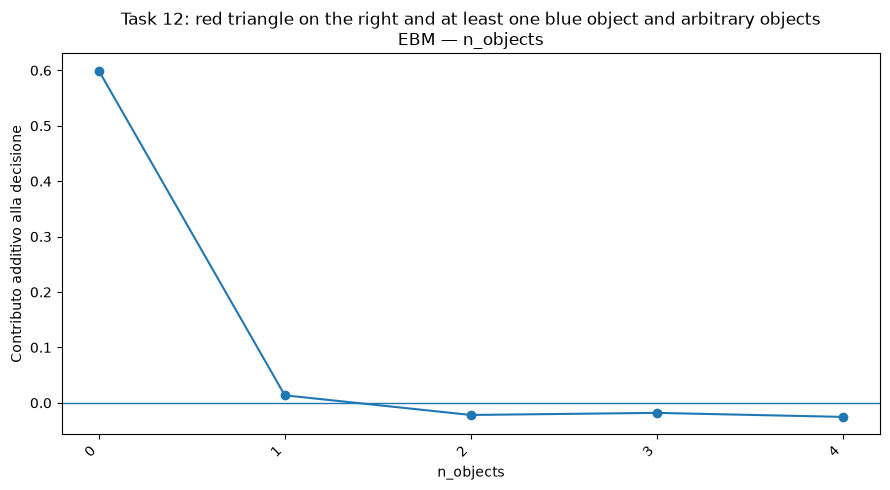

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_n_objects.png


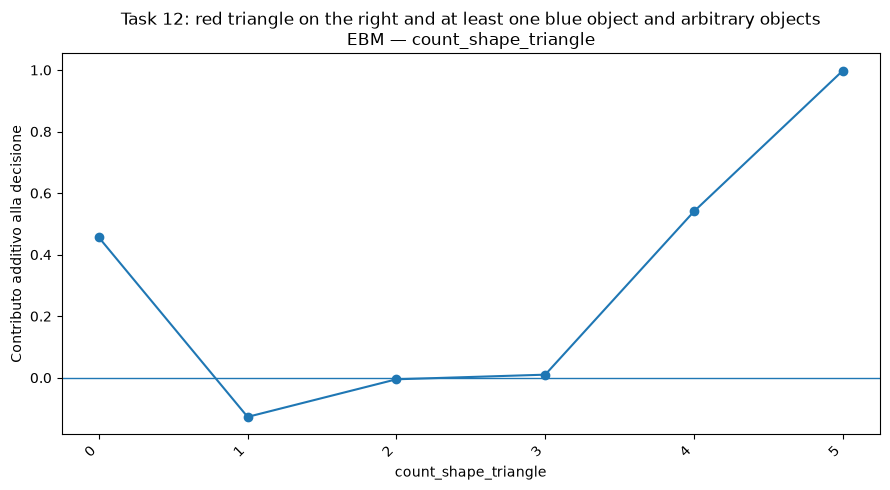

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_shape_triangle.png


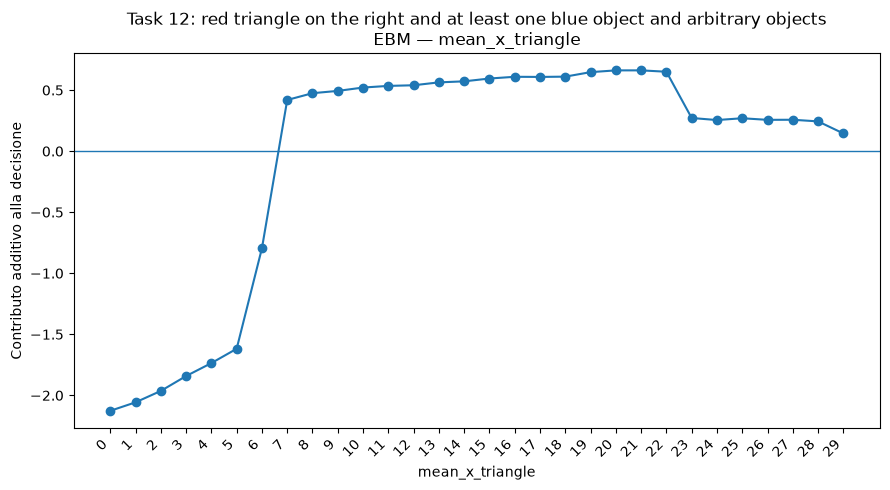

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_mean_x_triangle.png


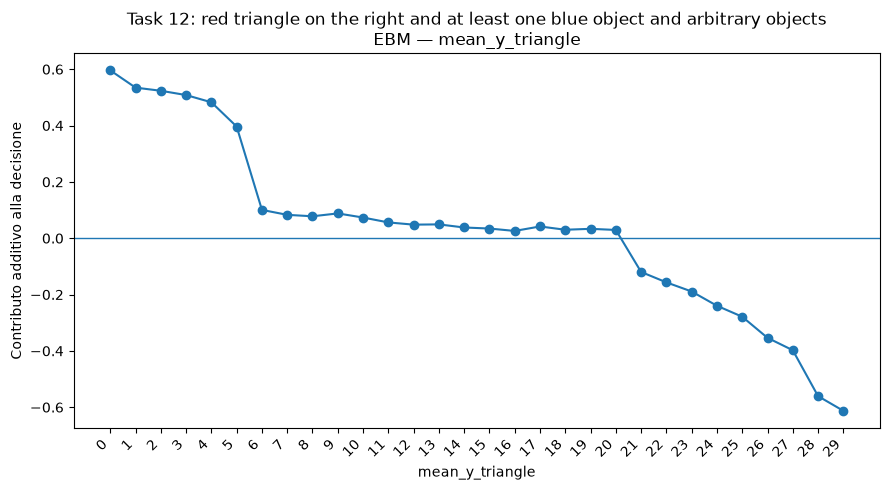

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_mean_y_triangle.png


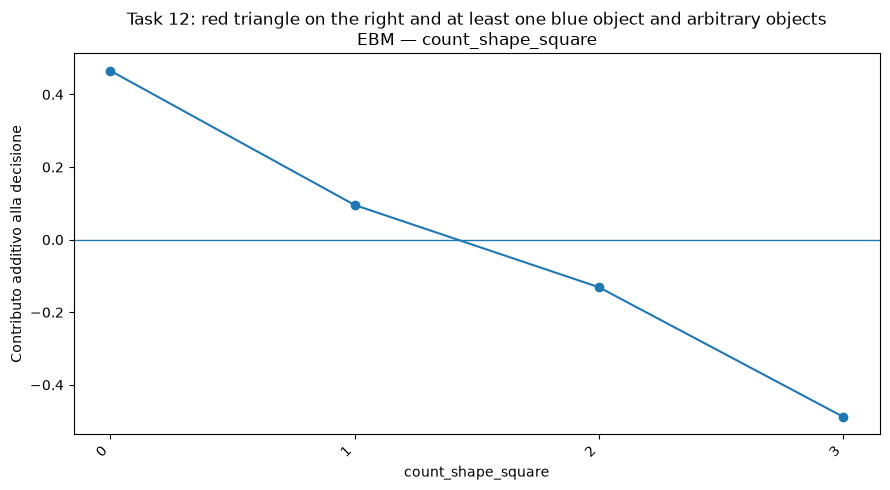

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_shape_square.png


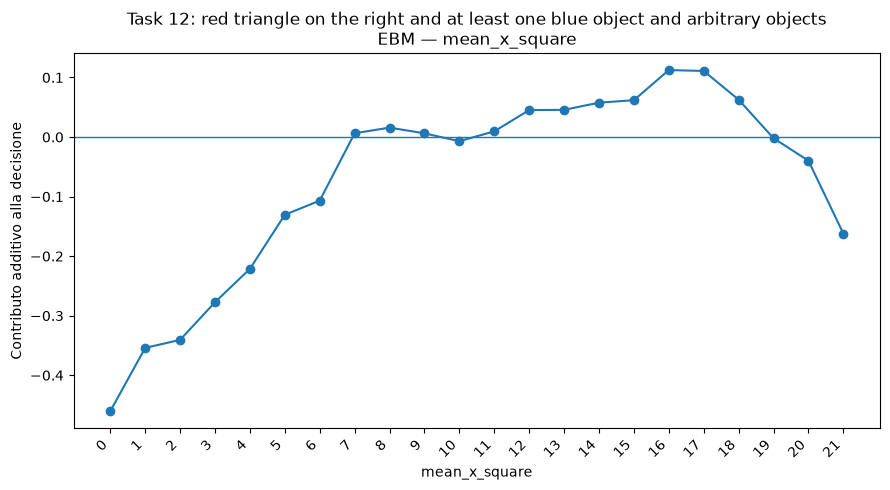

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_mean_x_square.png


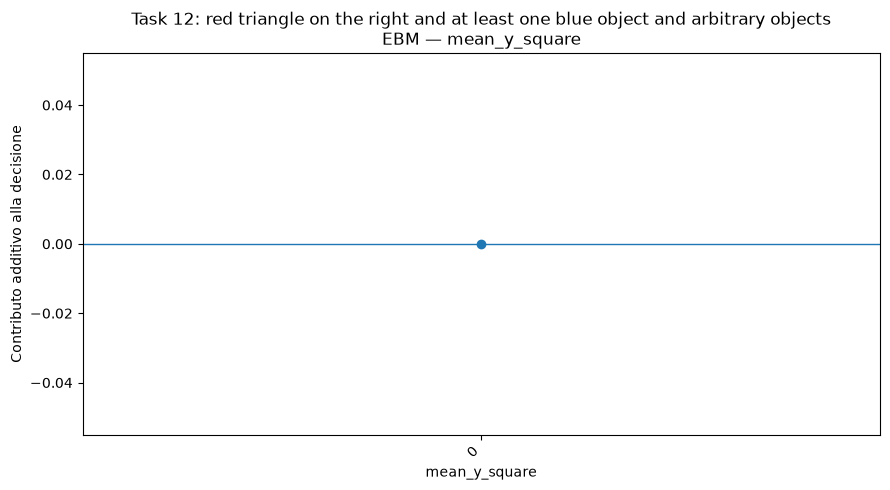

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_mean_y_square.png


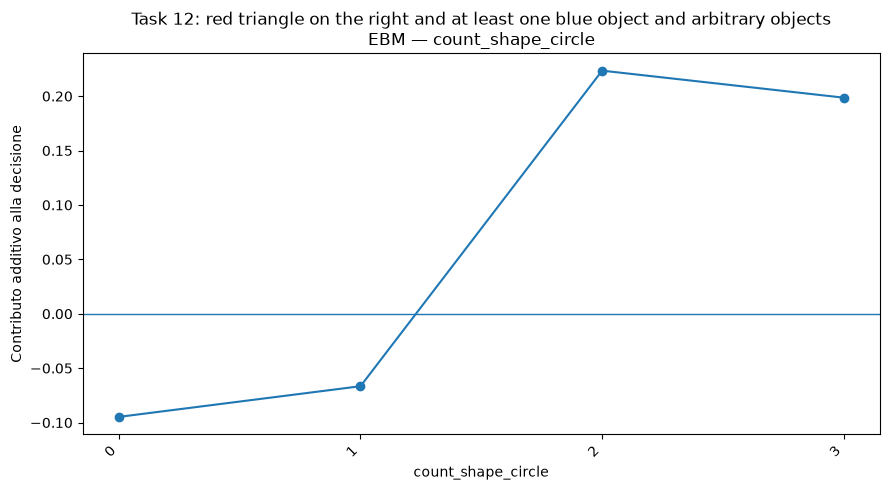

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_shape_circle.png


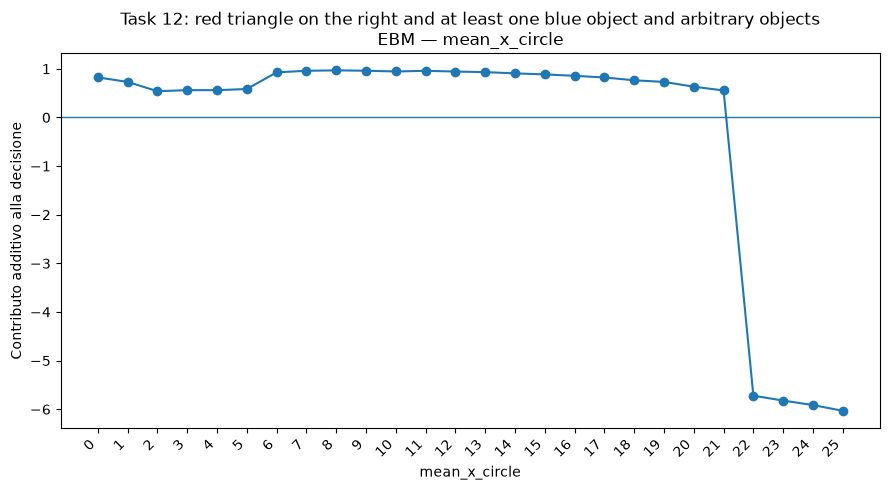

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_mean_x_circle.png


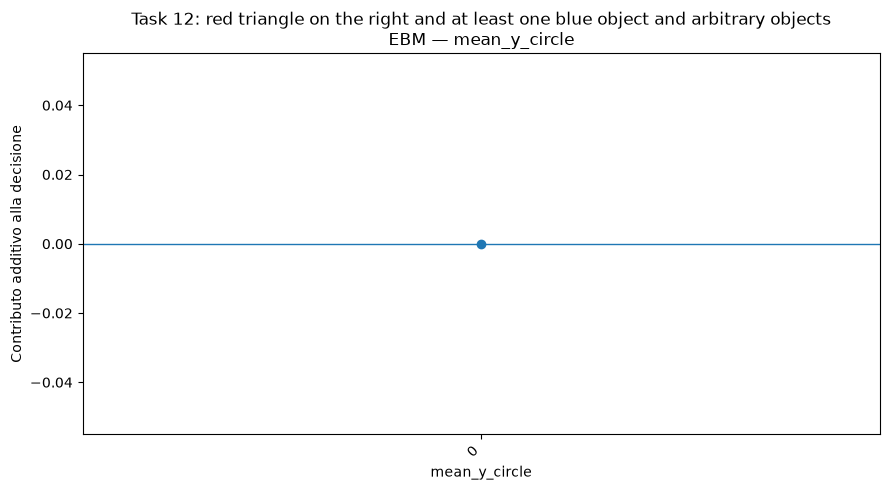

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_mean_y_circle.png


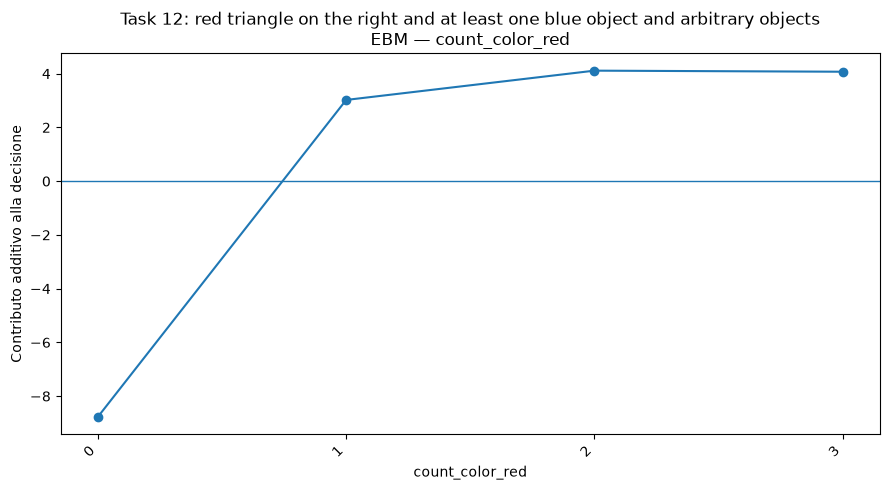

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_color_red.png


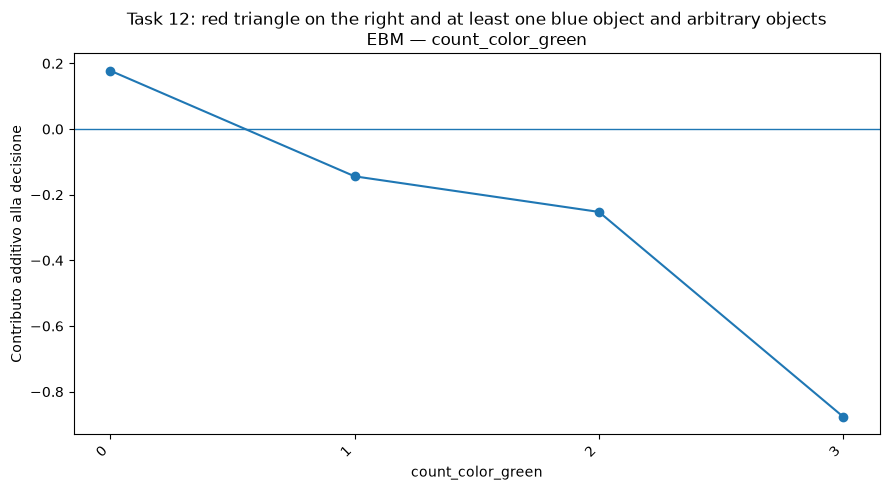

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_color_green.png


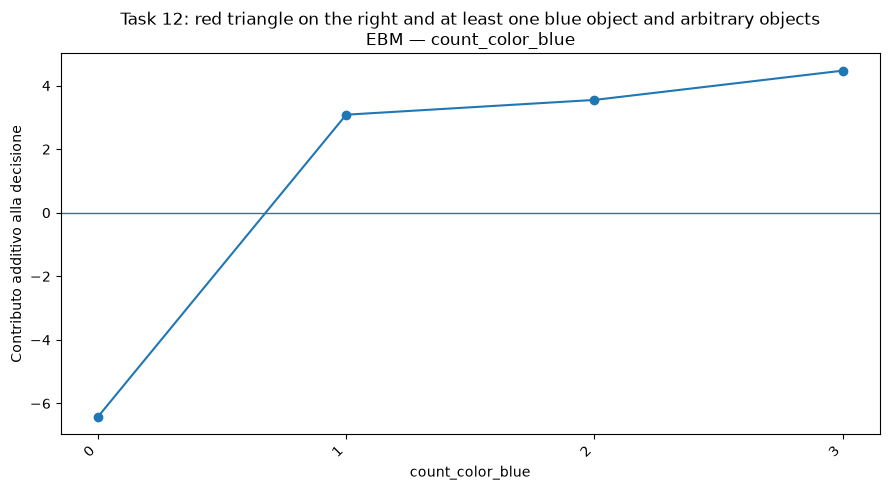

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_color_blue.png


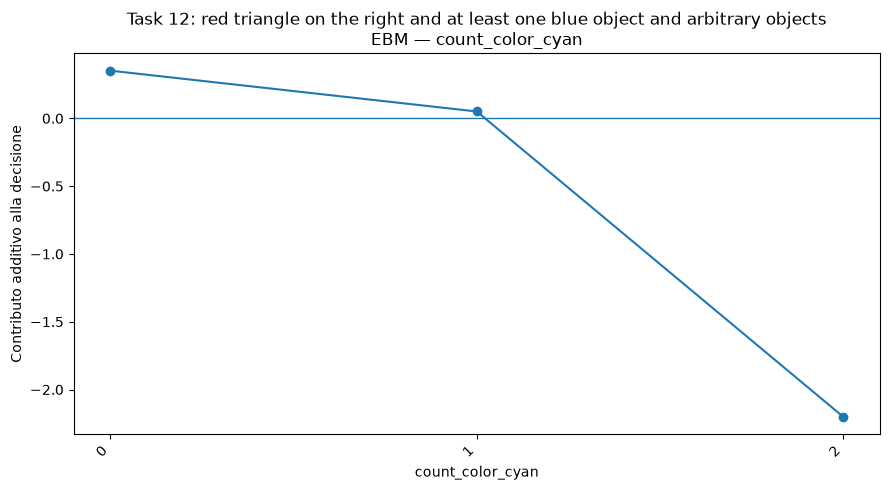

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_color_cyan.png


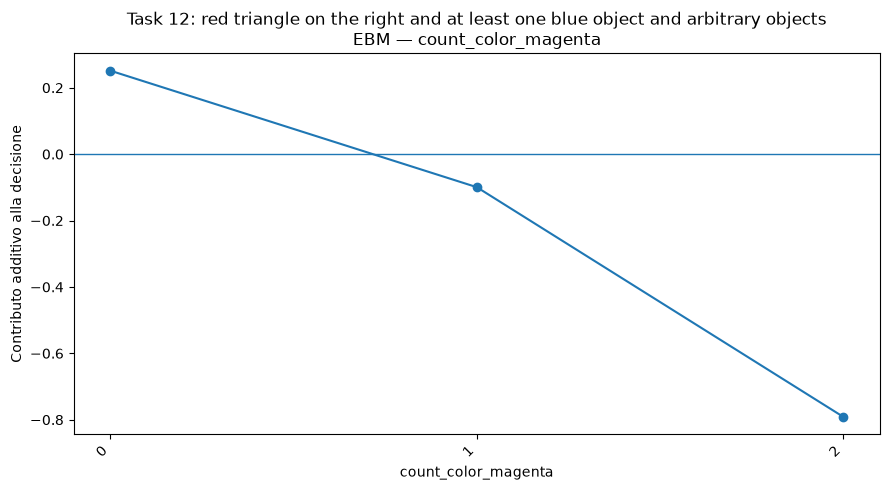

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_color_magenta.png


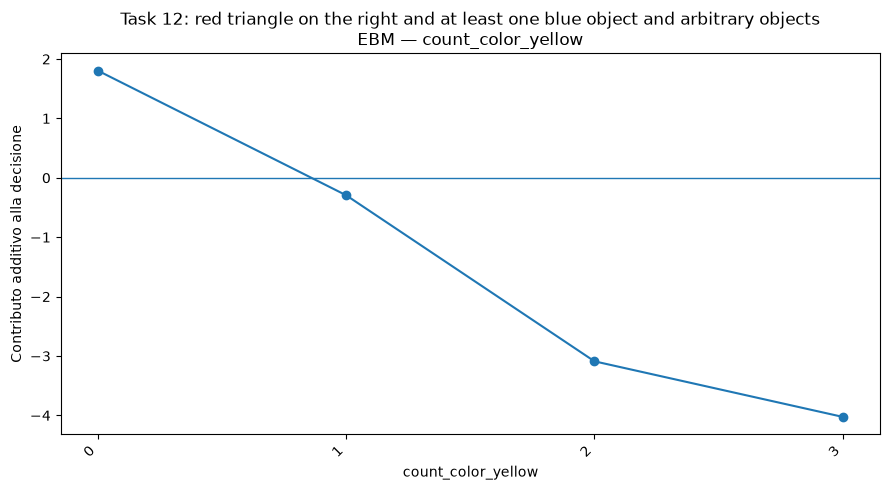

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_color_yellow.png


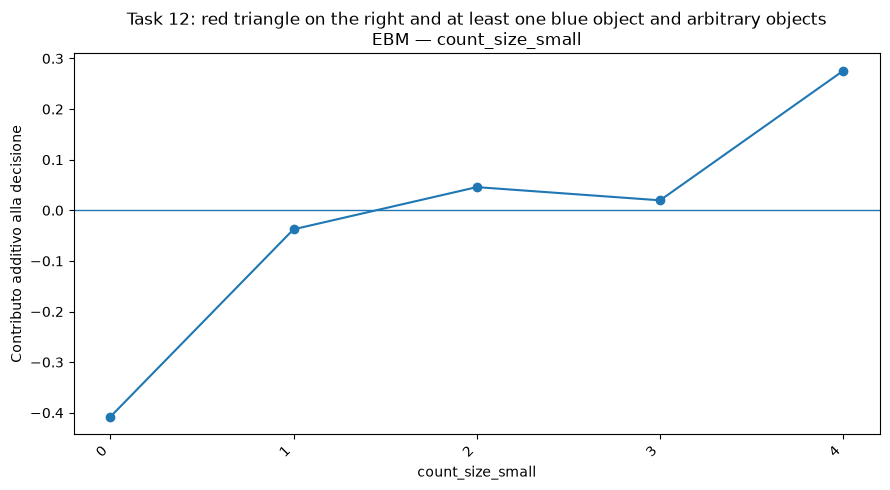

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_size_small.png


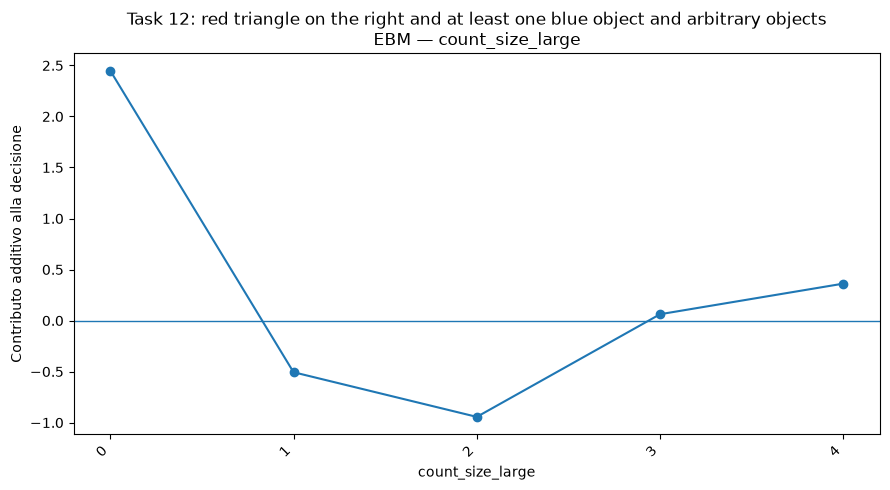

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_size_large.png


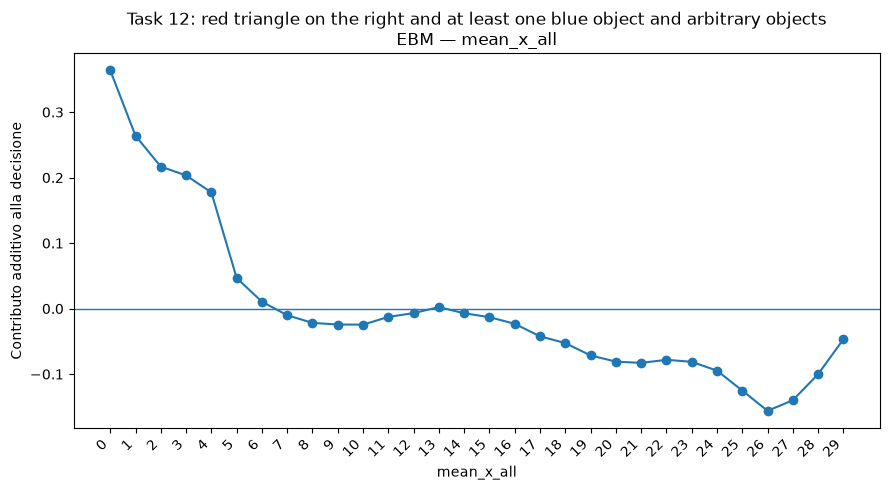

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_mean_x_all.png


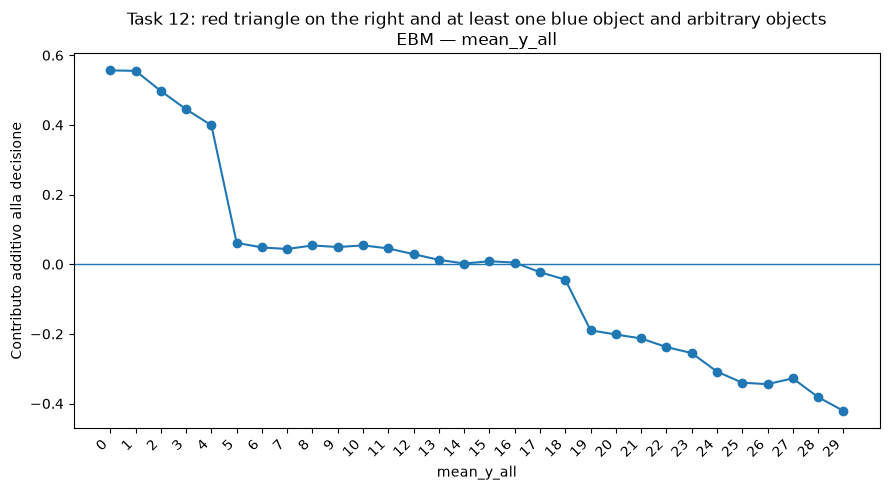

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_mean_y_all.png


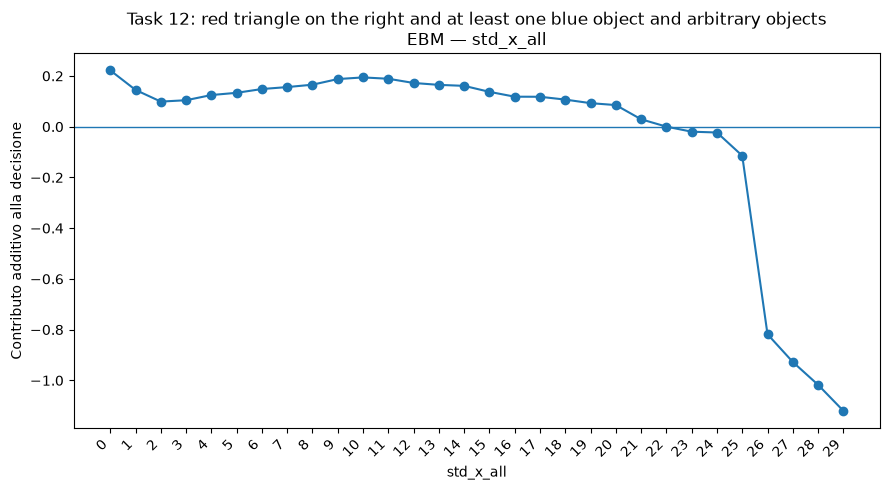

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_std_x_all.png


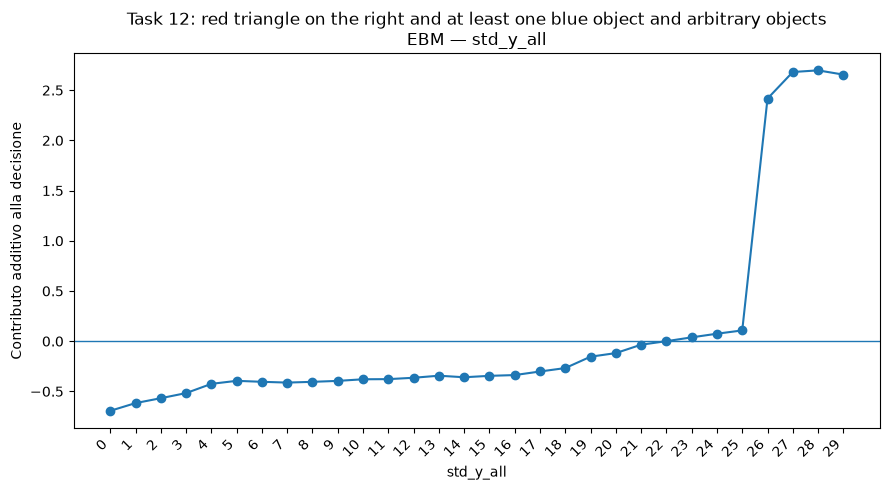

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_std_y_all.png


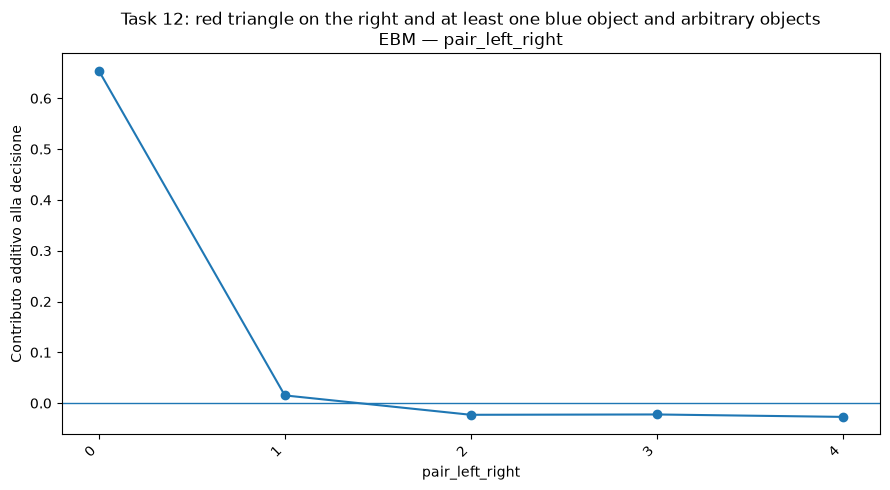

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_pair_left_right.png


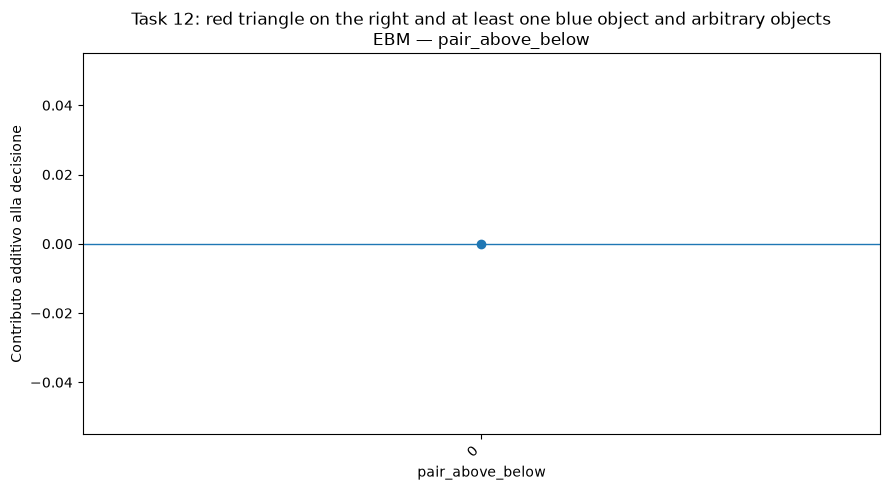

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_pair_above_below.png


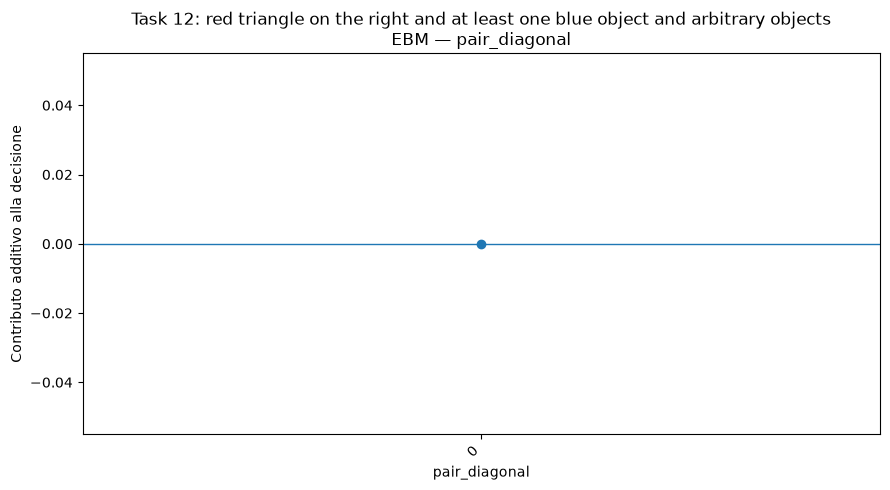

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_pair_diagonal.png


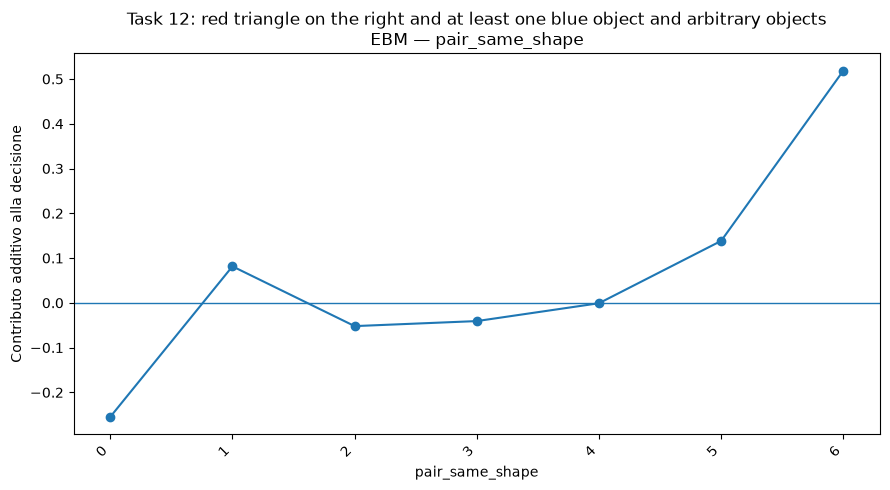

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_pair_same_shape.png


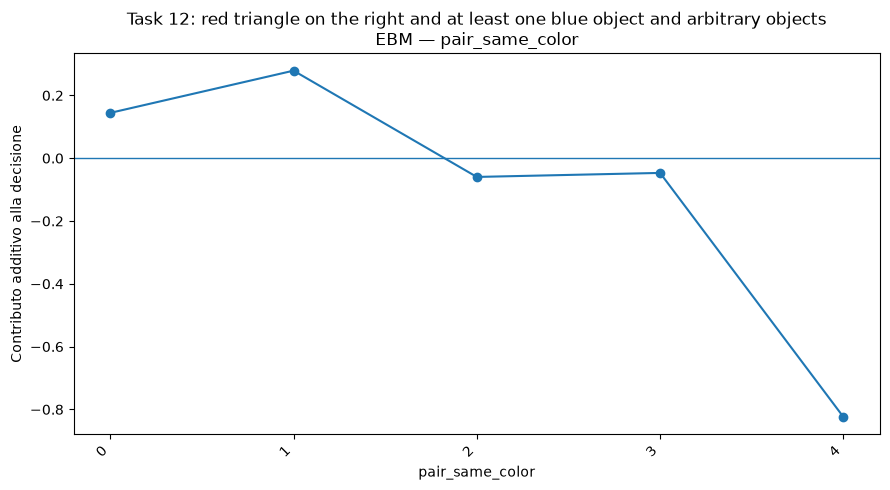

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_pair_same_color.png


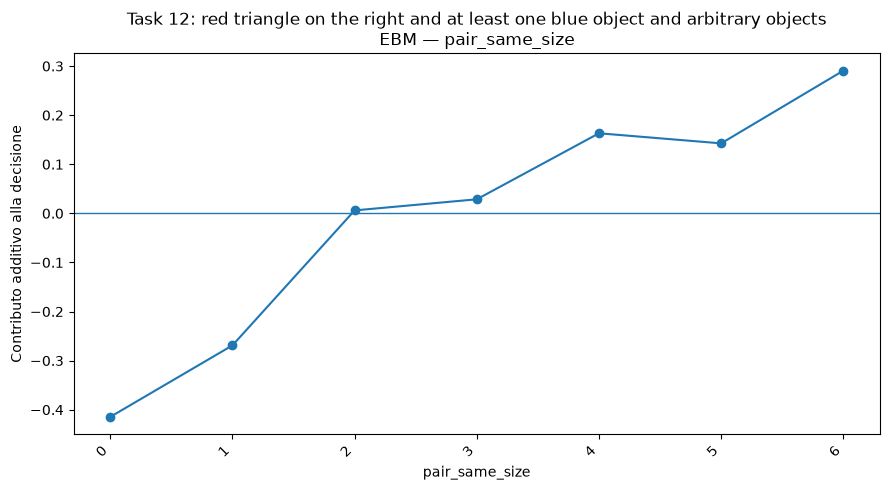

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_pair_same_size.png


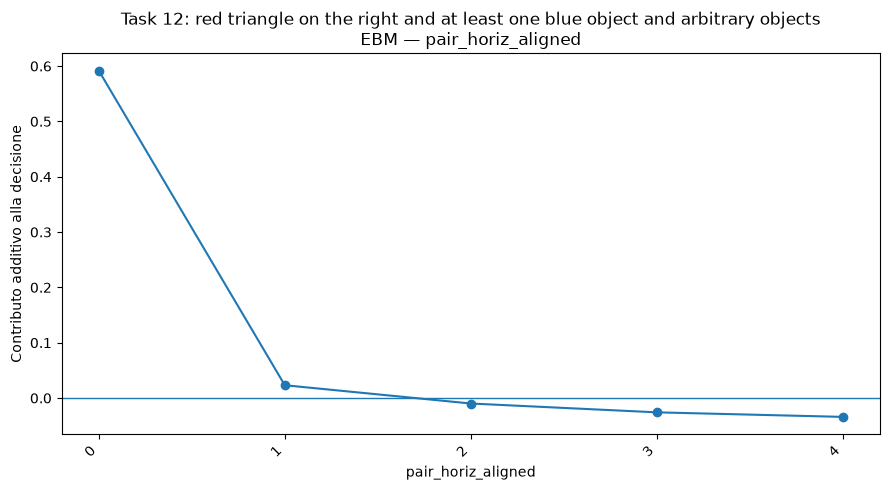

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_pair_horiz_aligned.png


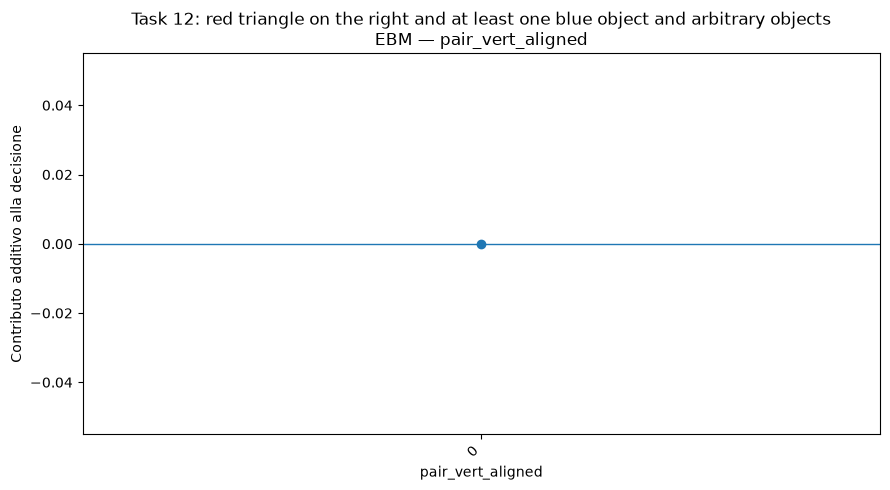

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_pair_vert_aligned.png


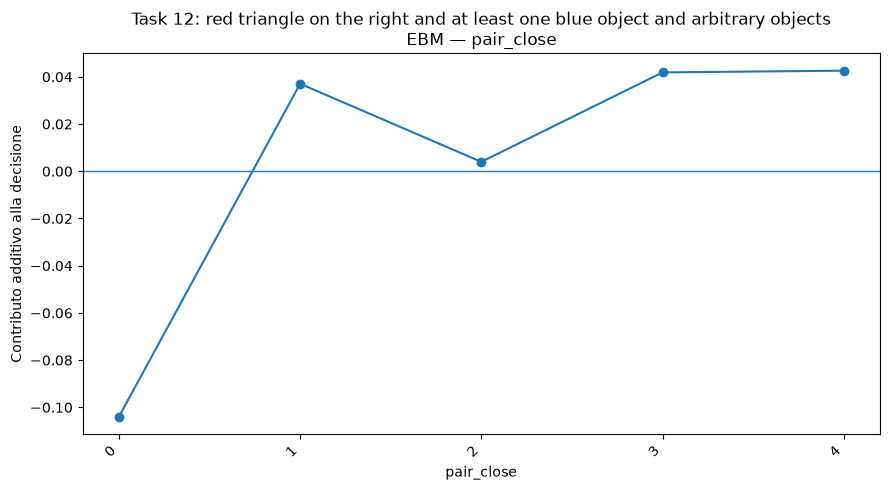

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_pair_close.png


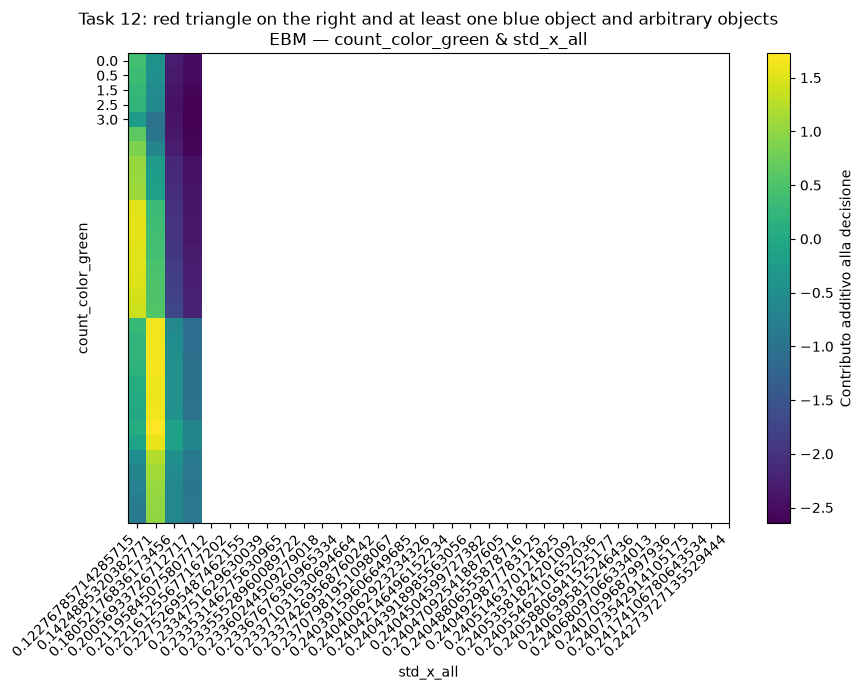

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_color_green_std_x_all_heatmap.png


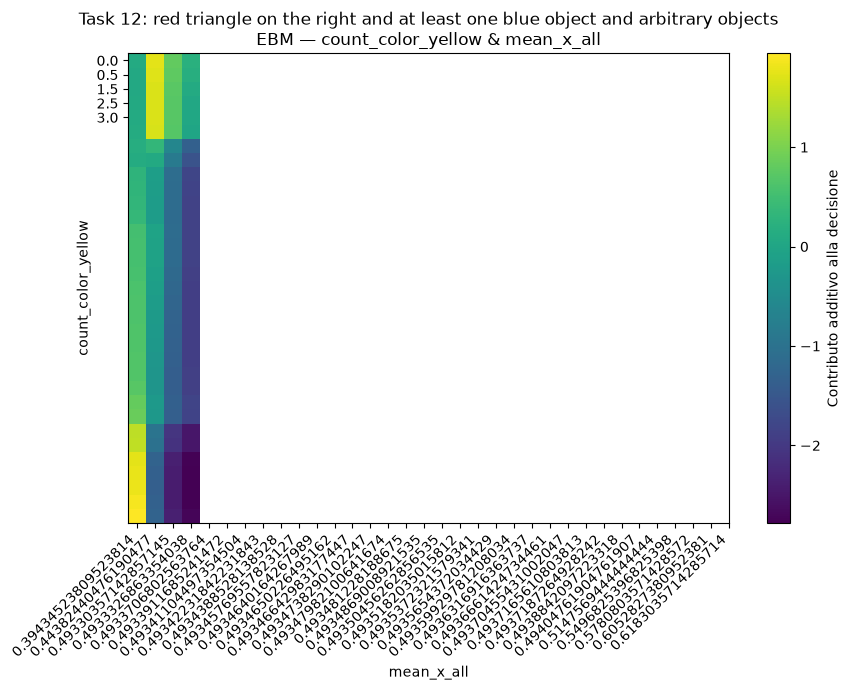

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_color_yellow_mean_x_all_heatmap.png


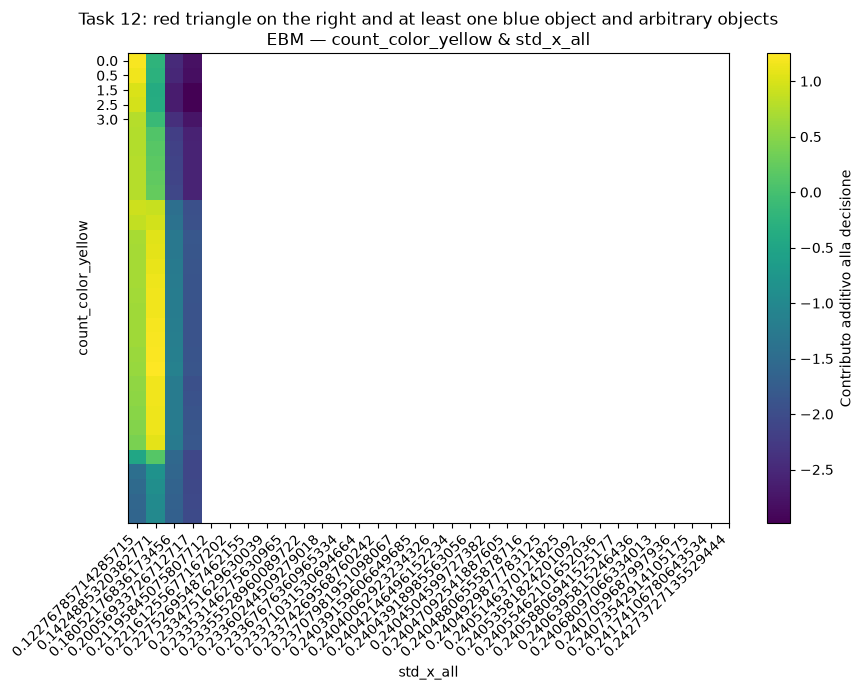

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_color_yellow_std_x_all_heatmap.png


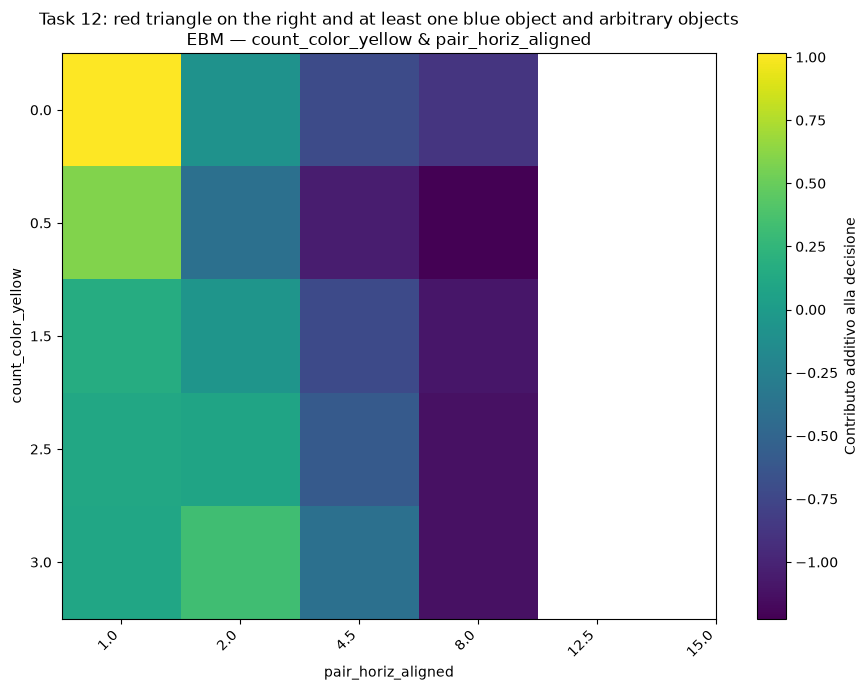

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_color_yellow_pair_horiz_aligned_heatmap.png


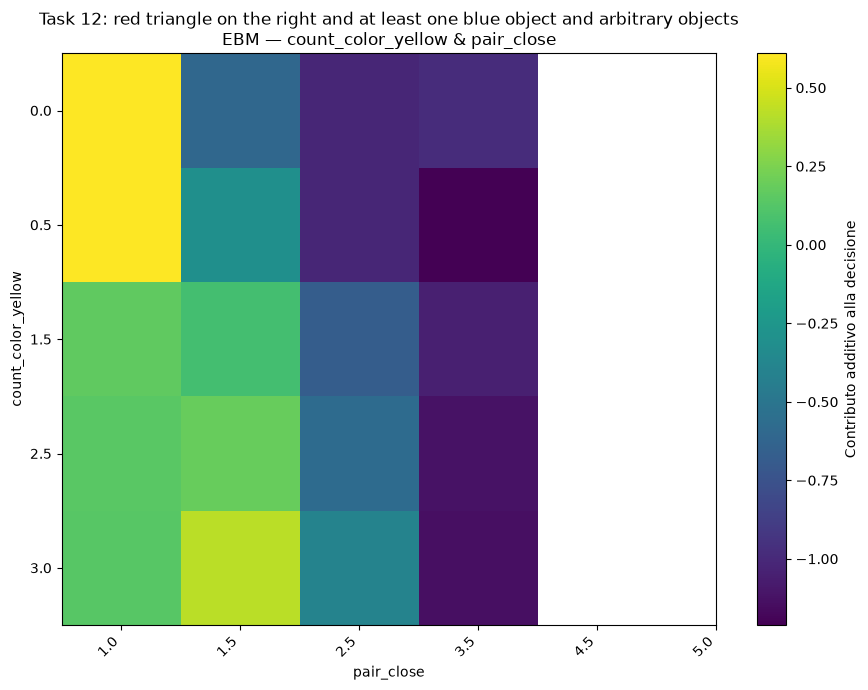

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_count_color_yellow_pair_close_heatmap.png


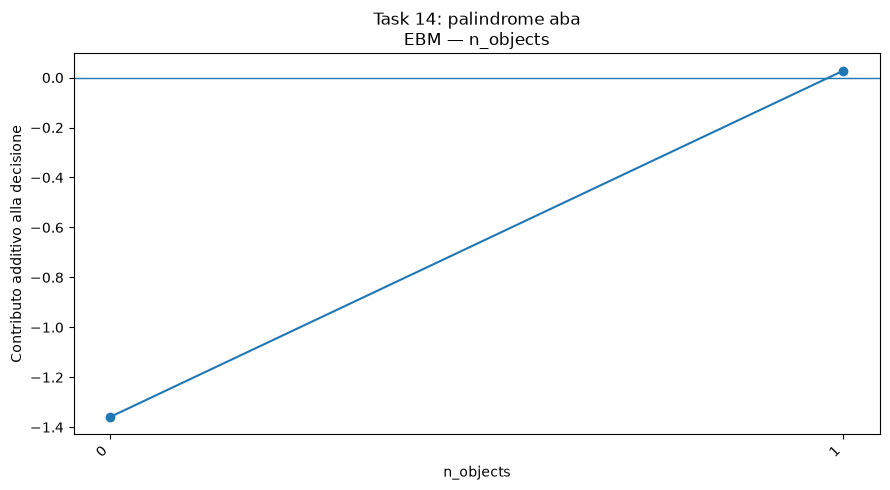

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_n_objects.png


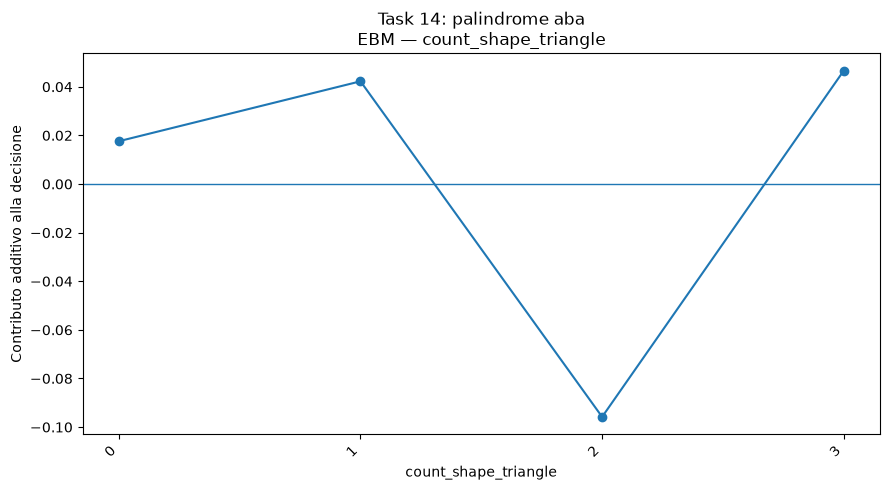

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_count_shape_triangle.png


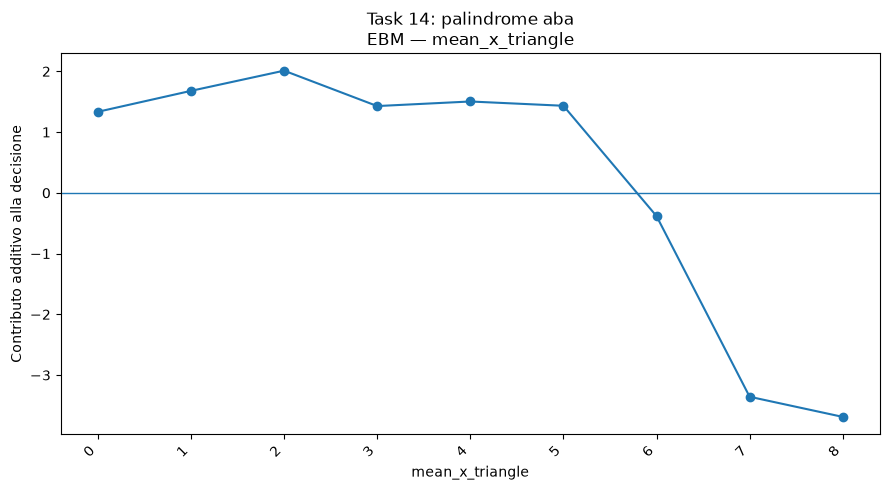

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_mean_x_triangle.png


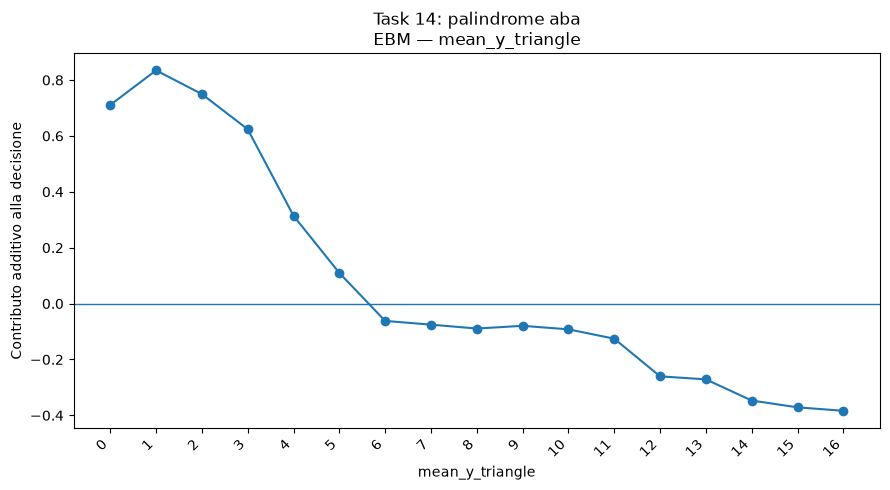

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_mean_y_triangle.png


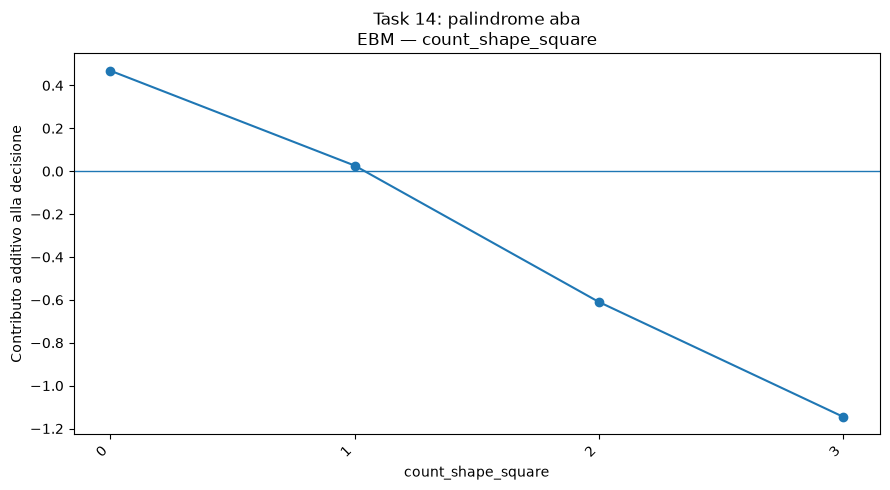

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_count_shape_square.png


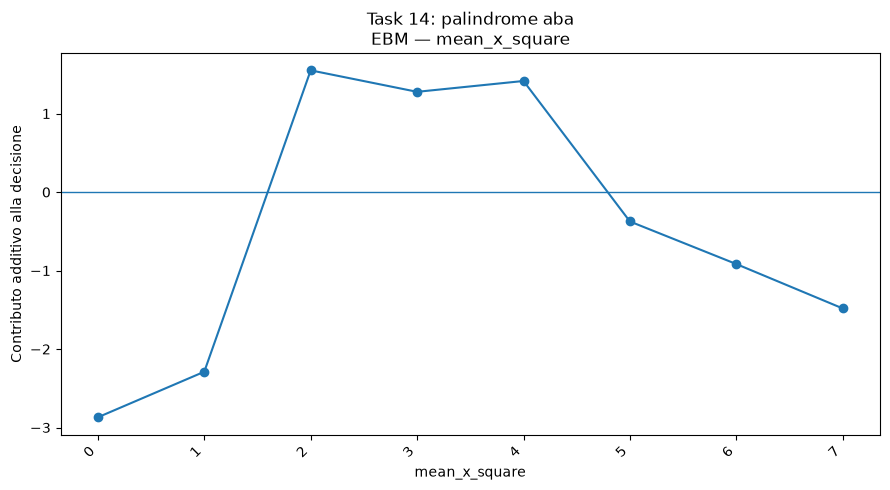

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_mean_x_square.png


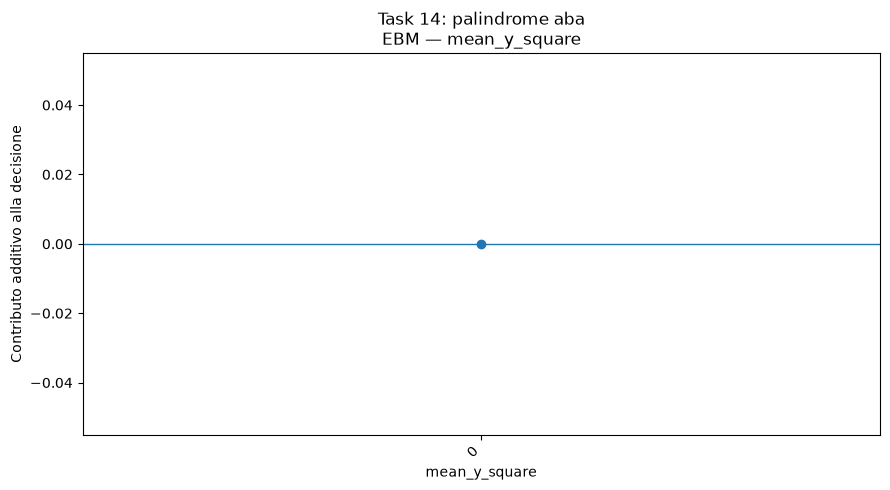

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_mean_y_square.png


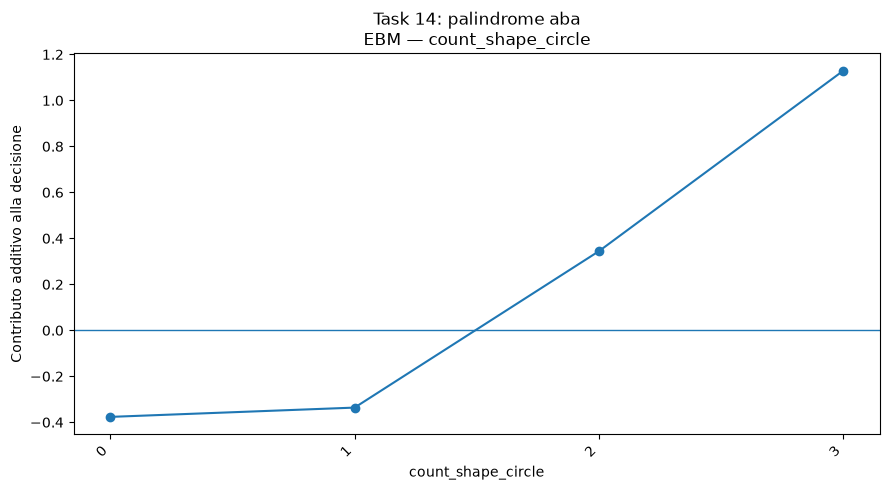

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_count_shape_circle.png


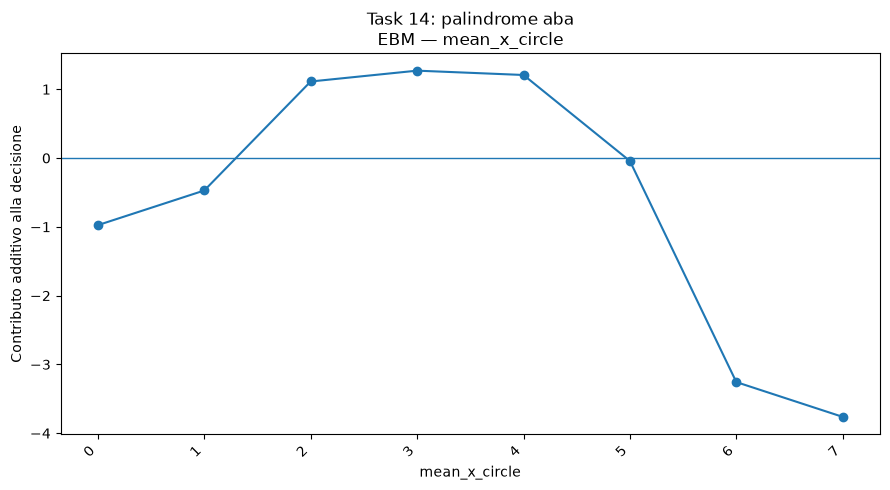

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_mean_x_circle.png


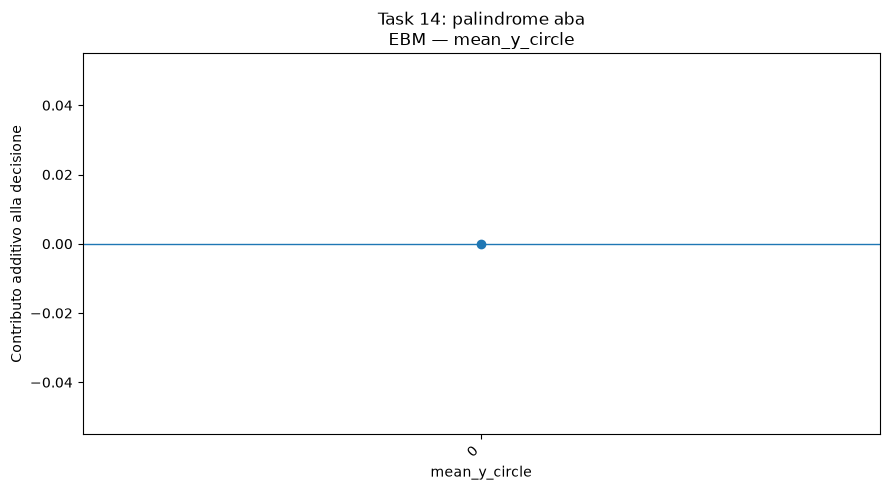

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_mean_y_circle.png


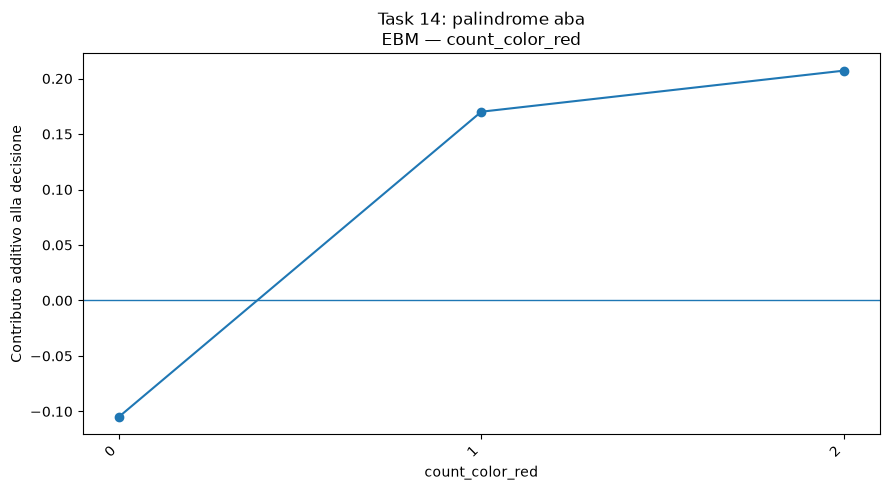

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_count_color_red.png


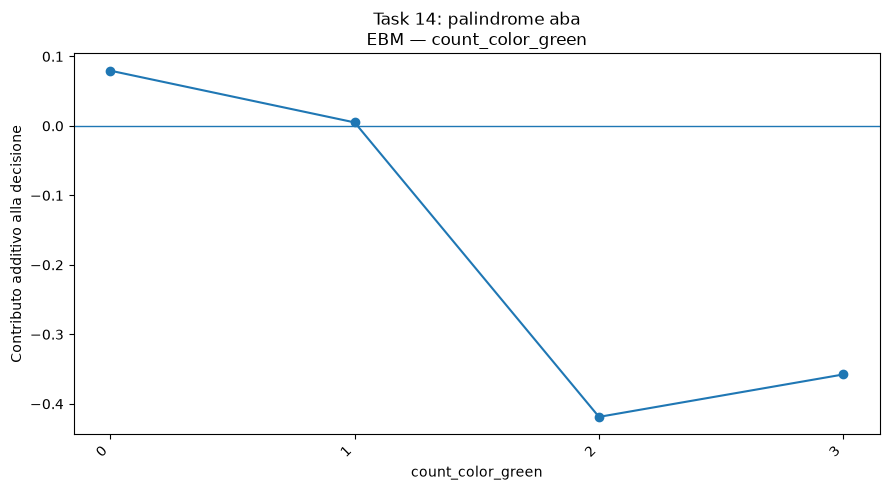

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_count_color_green.png


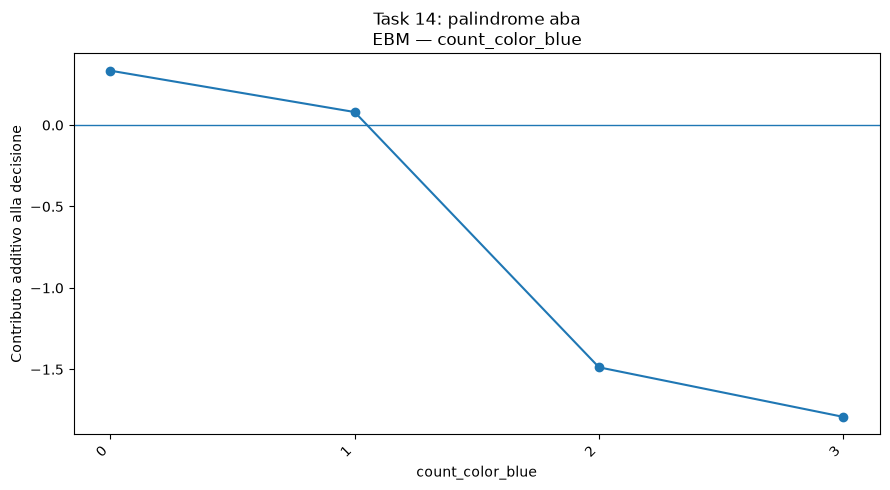

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_count_color_blue.png


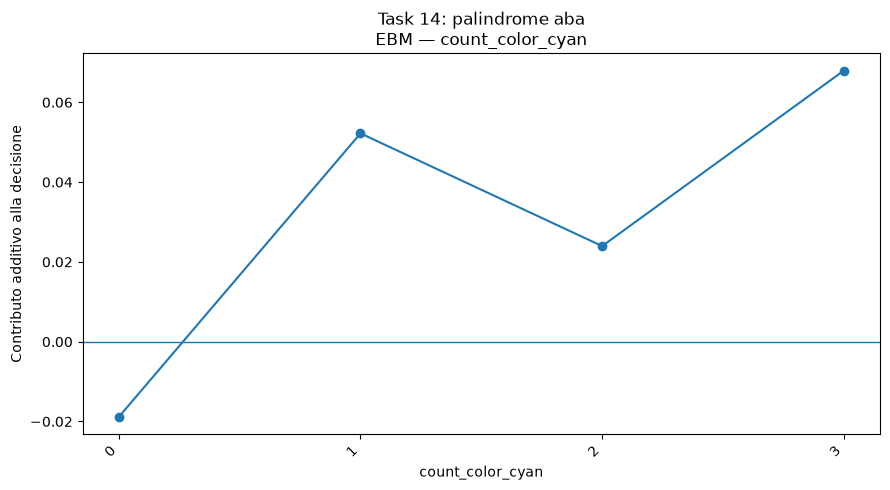

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_count_color_cyan.png


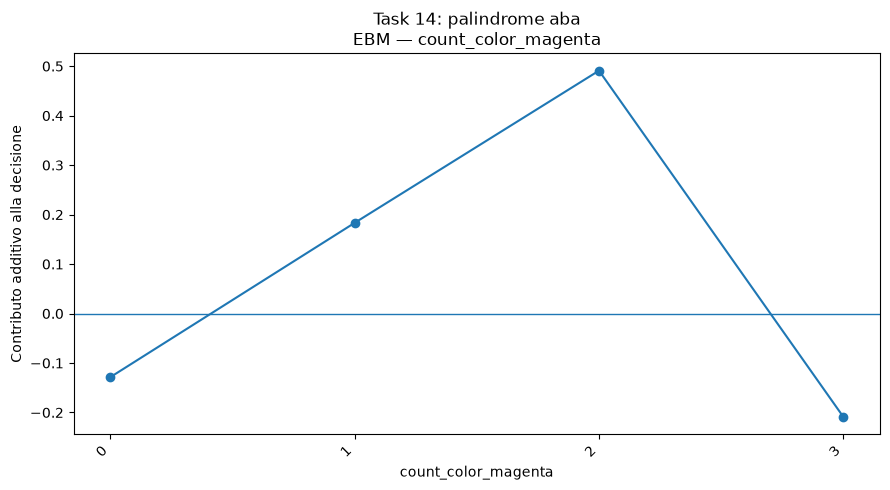

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_count_color_magenta.png


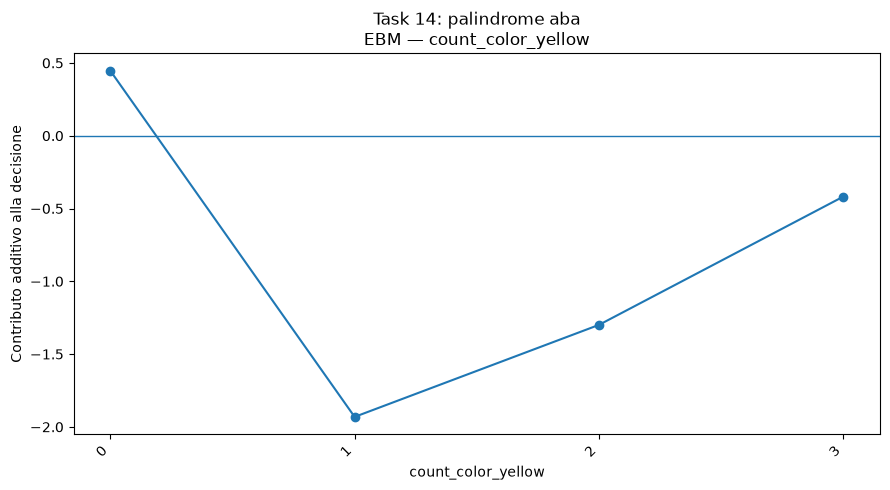

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_count_color_yellow.png


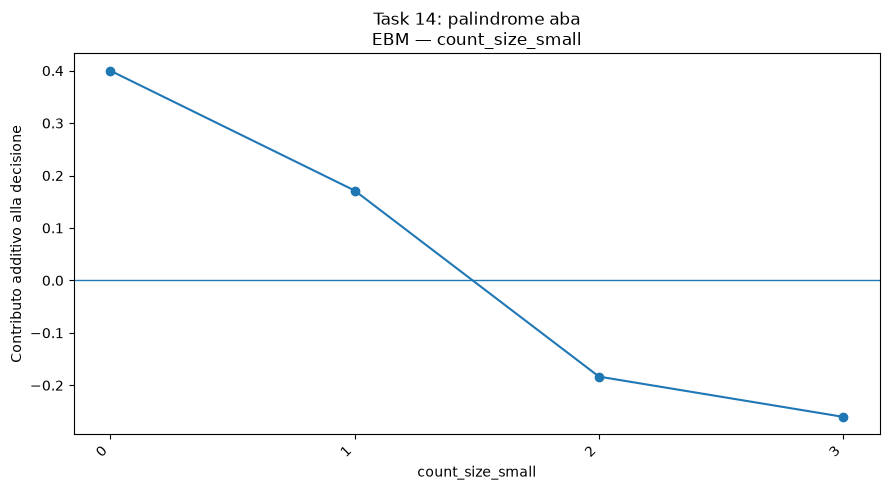

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_count_size_small.png


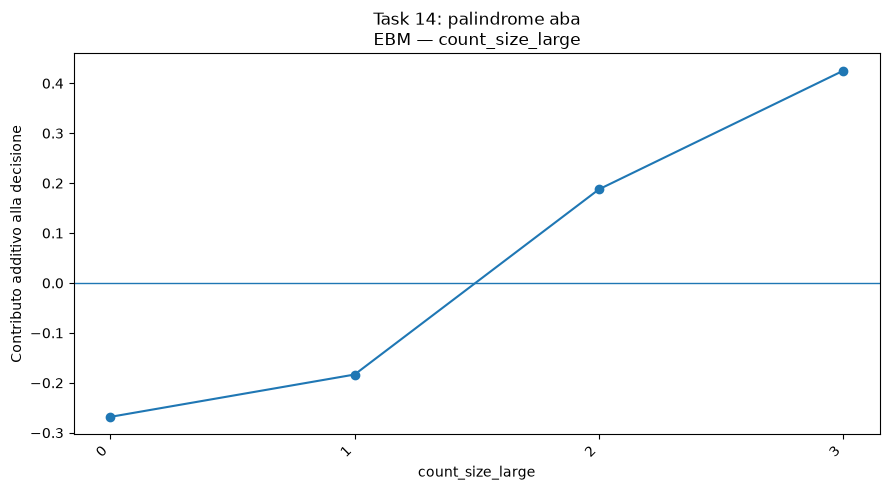

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_count_size_large.png


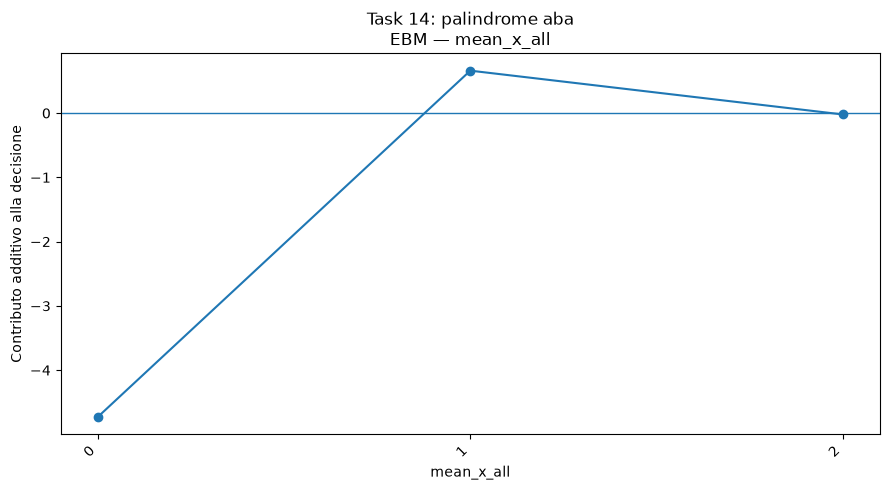

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_mean_x_all.png


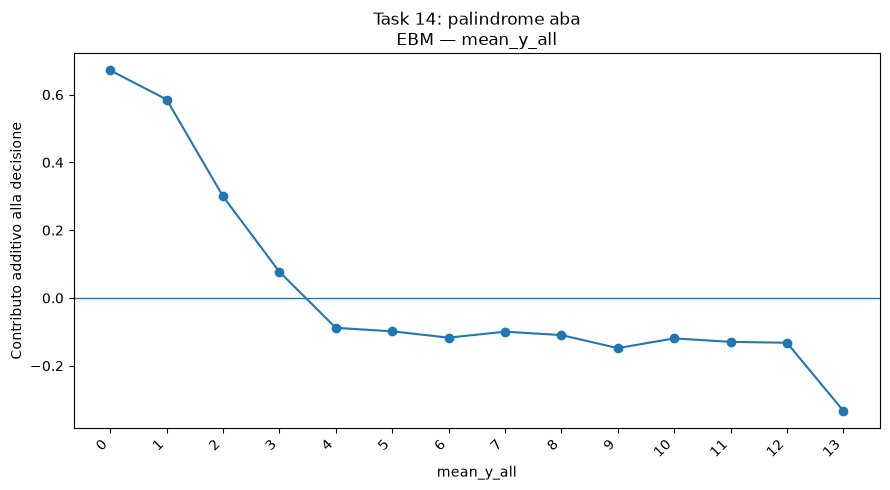

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_mean_y_all.png


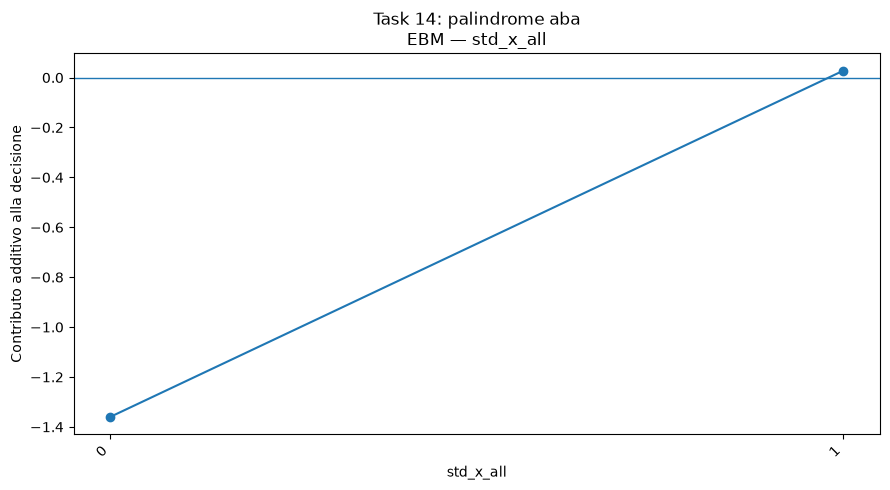

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_std_x_all.png


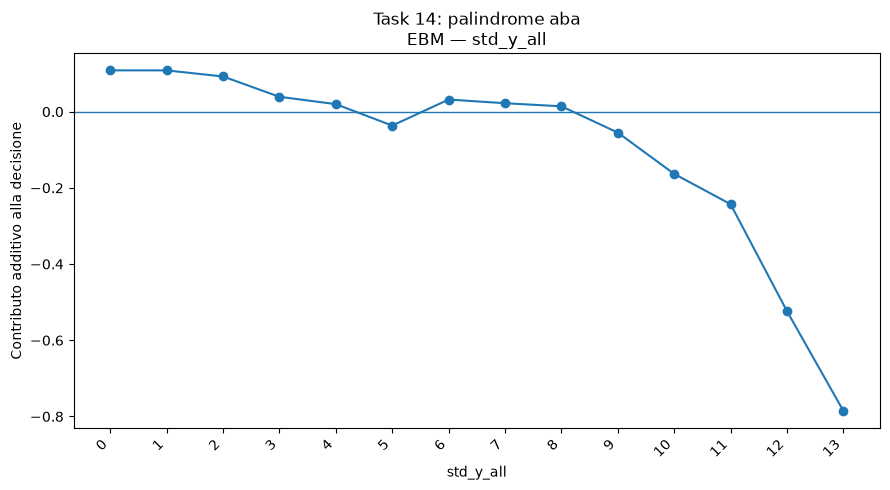

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_std_y_all.png


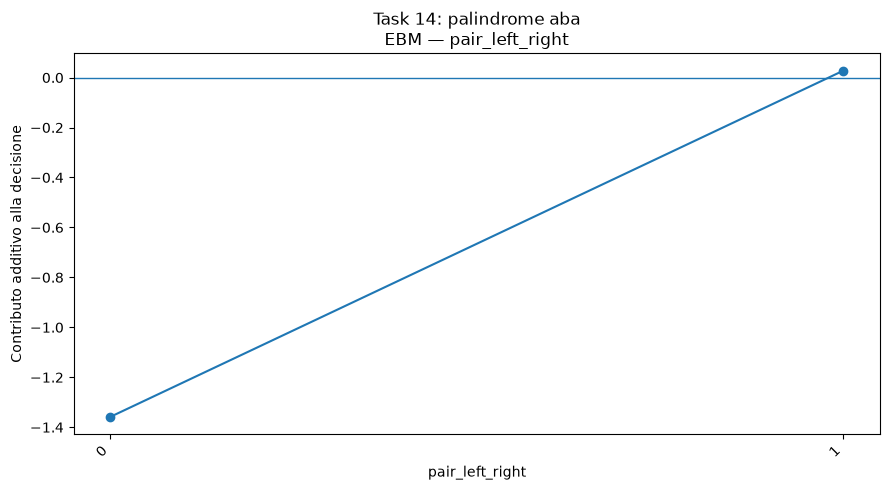

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_pair_left_right.png


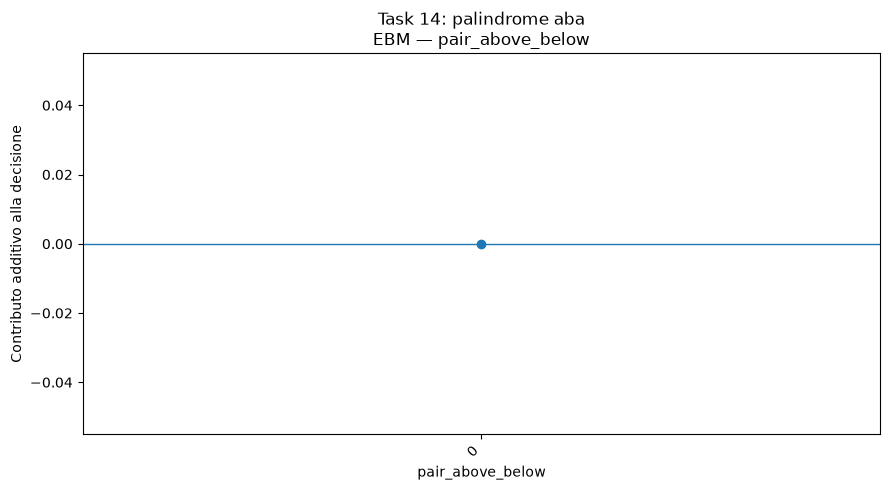

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_pair_above_below.png


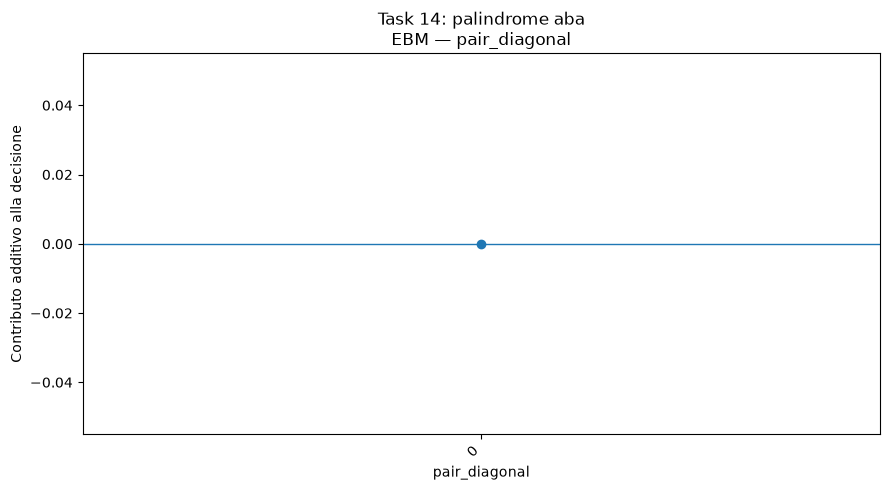

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_pair_diagonal.png


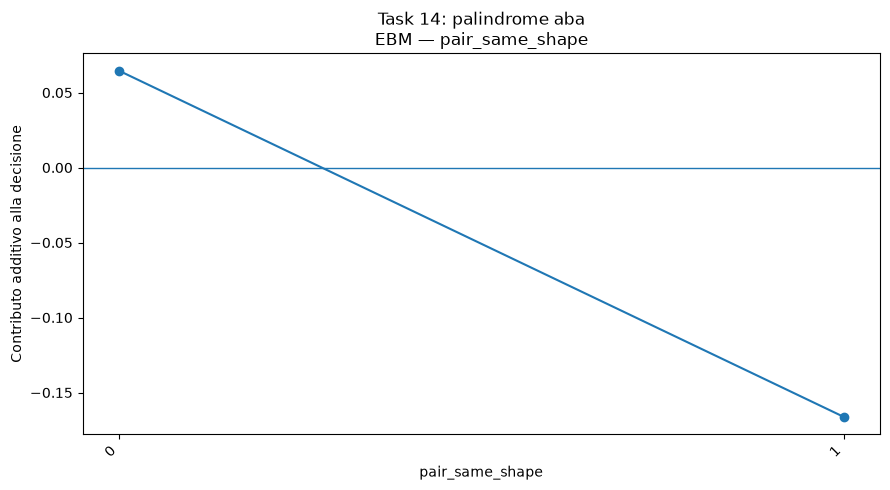

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_pair_same_shape.png


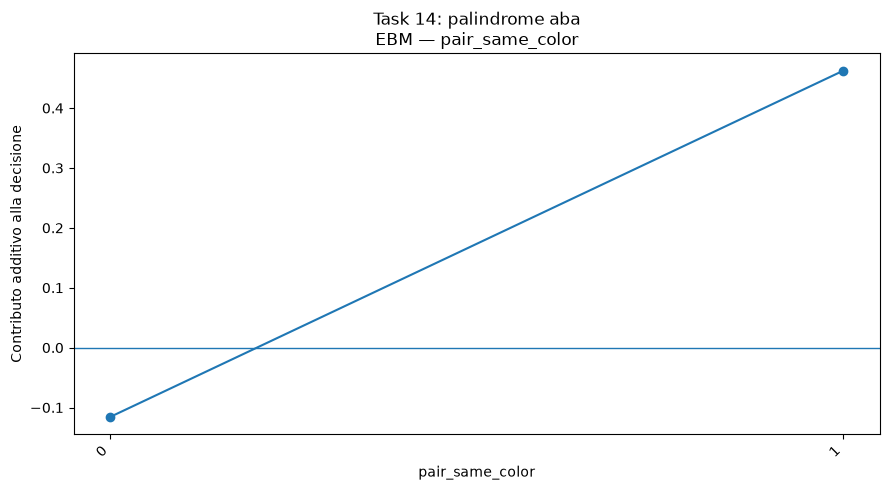

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_pair_same_color.png


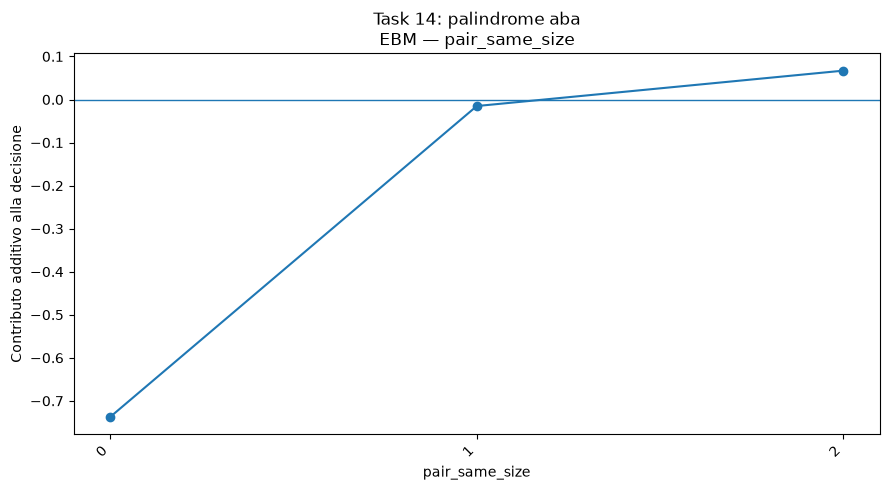

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_pair_same_size.png


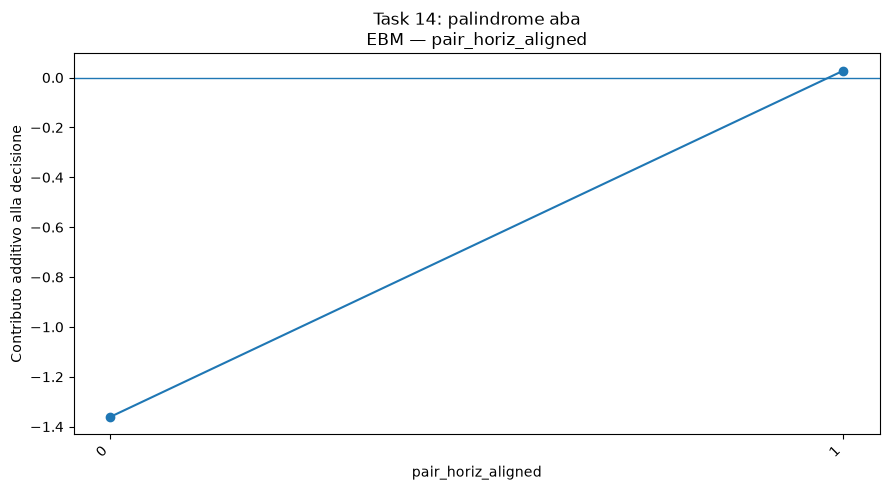

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_pair_horiz_aligned.png


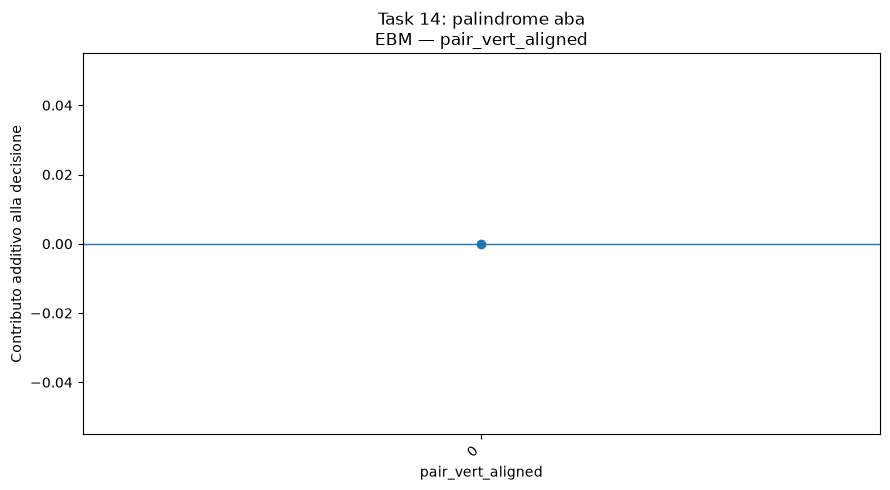

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_pair_vert_aligned.png


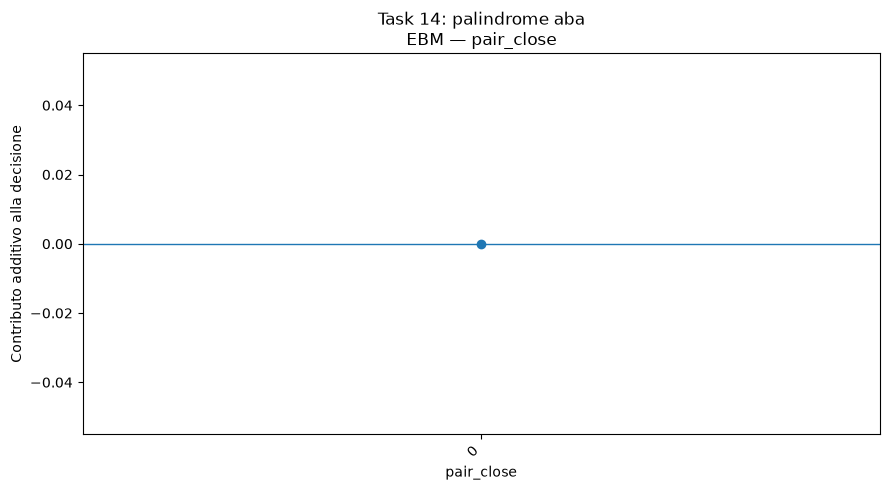

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_pair_close.png


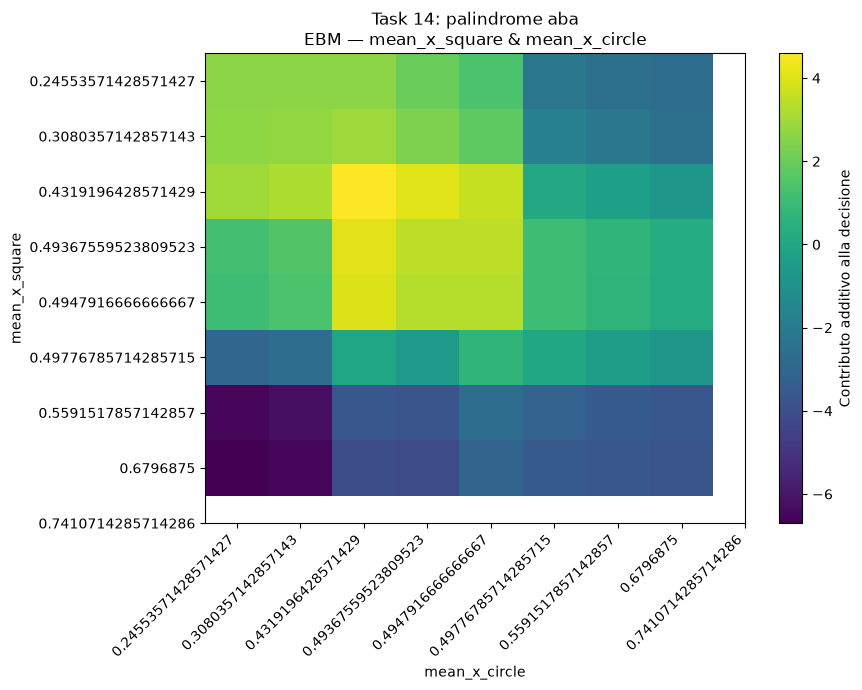

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_mean_x_square_mean_x_circle_heatmap.png


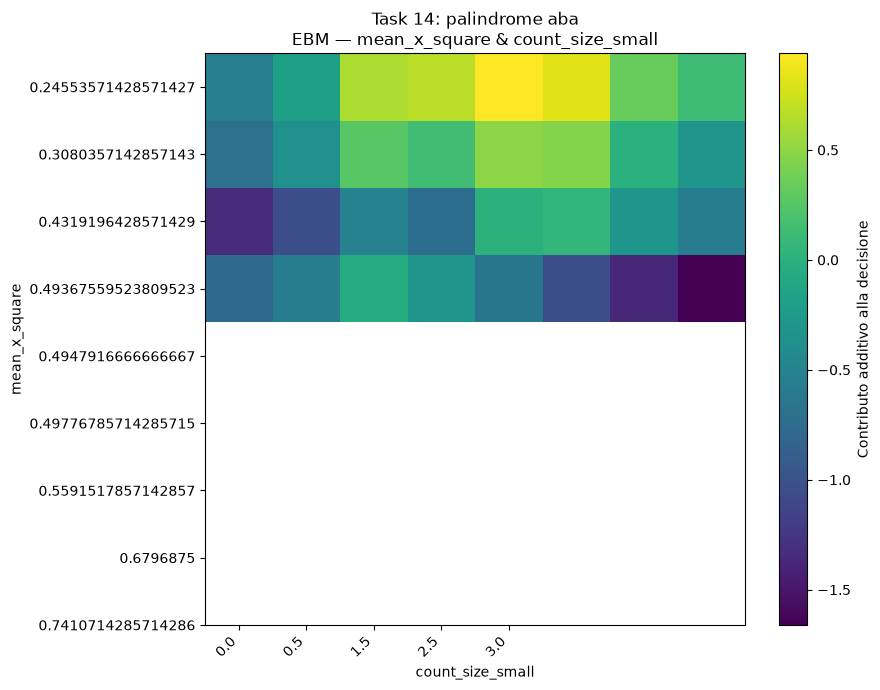

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_mean_x_square_count_size_small_heatmap.png


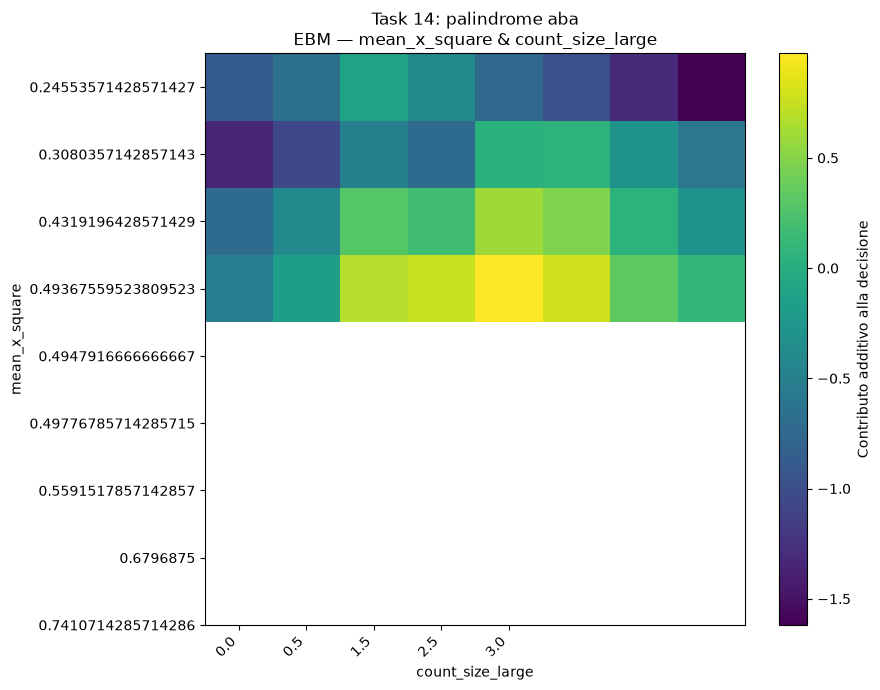

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_mean_x_square_count_size_large_heatmap.png


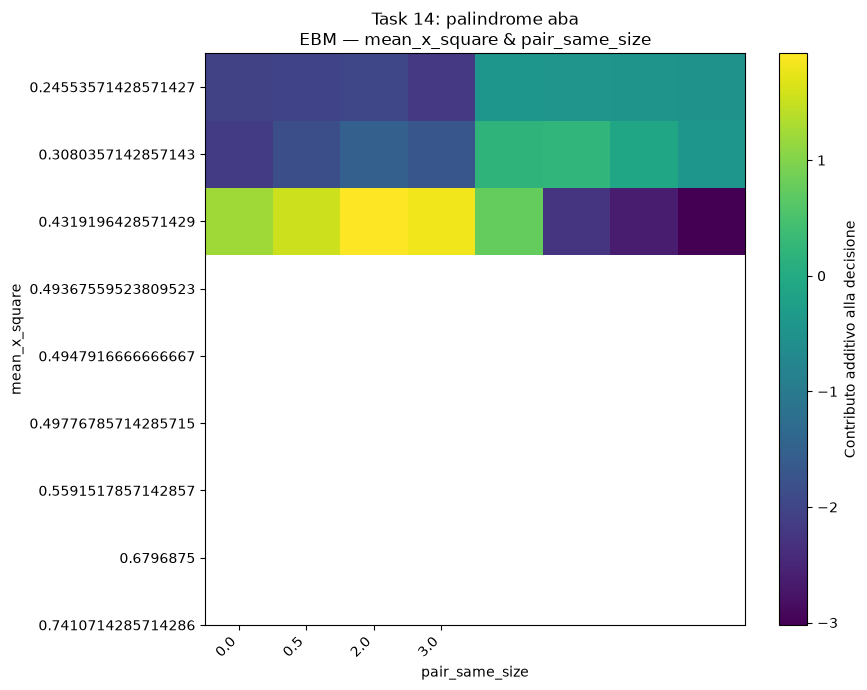

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_mean_x_square_pair_same_size_heatmap.png


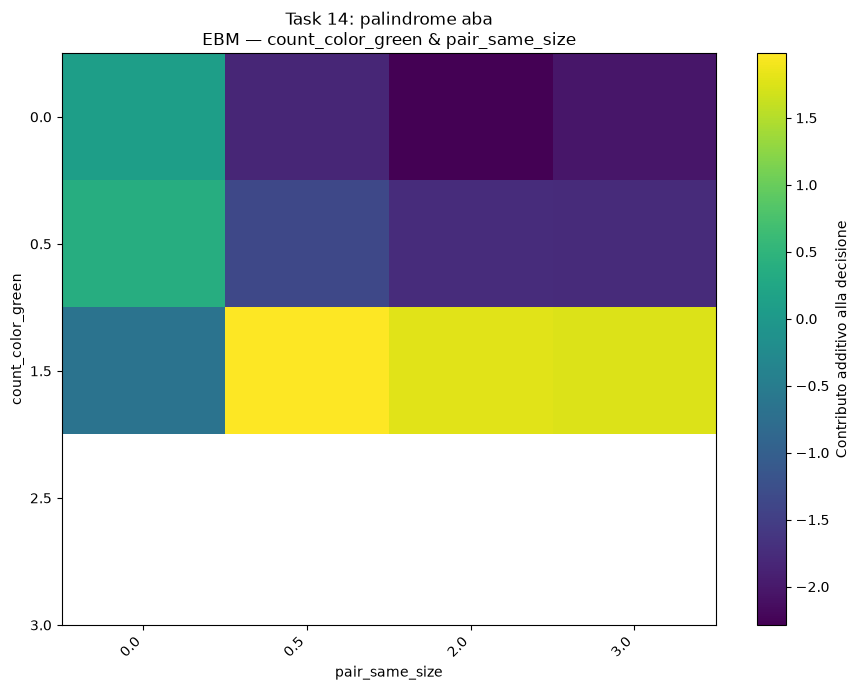

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_count_color_green_pair_same_size_heatmap.png


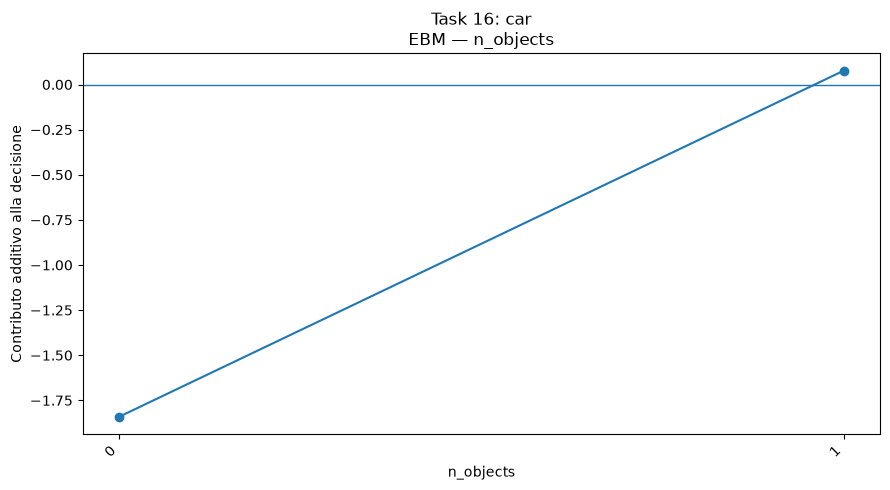

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_n_objects.png


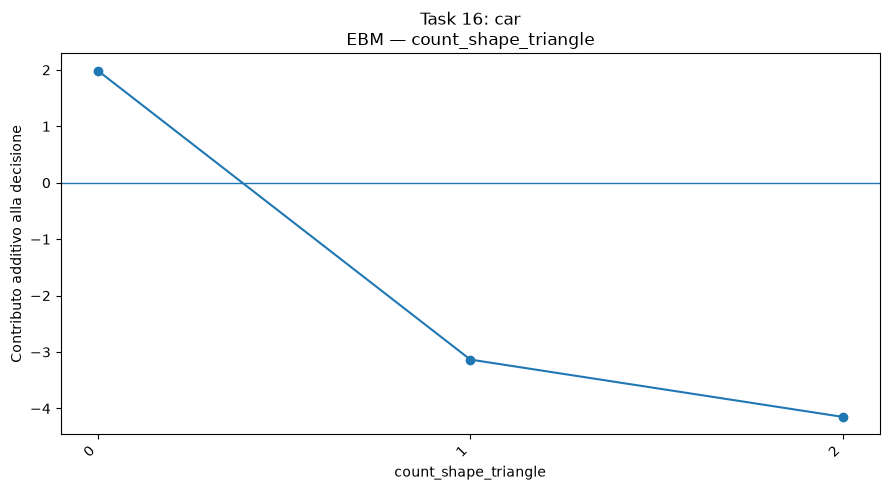

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_count_shape_triangle.png


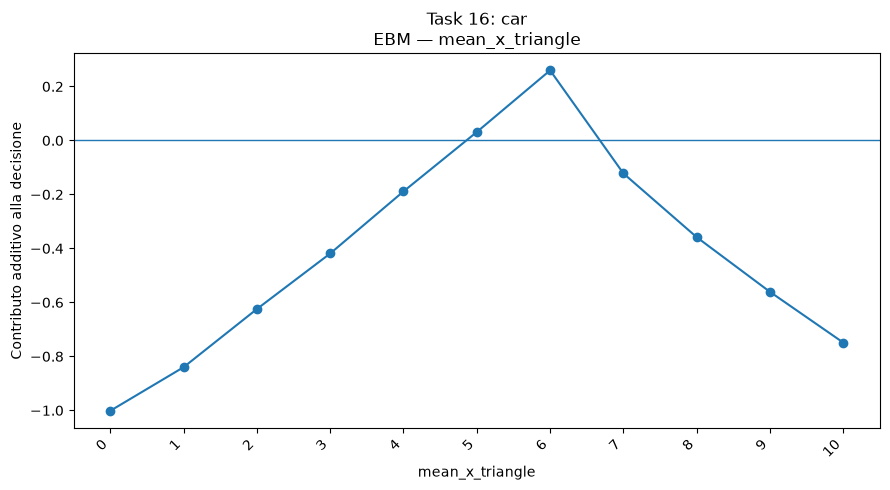

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_mean_x_triangle.png


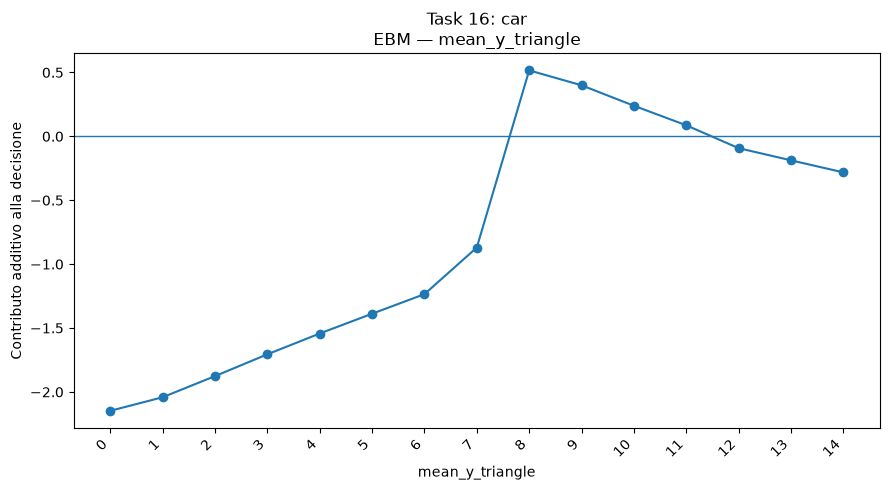

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_mean_y_triangle.png


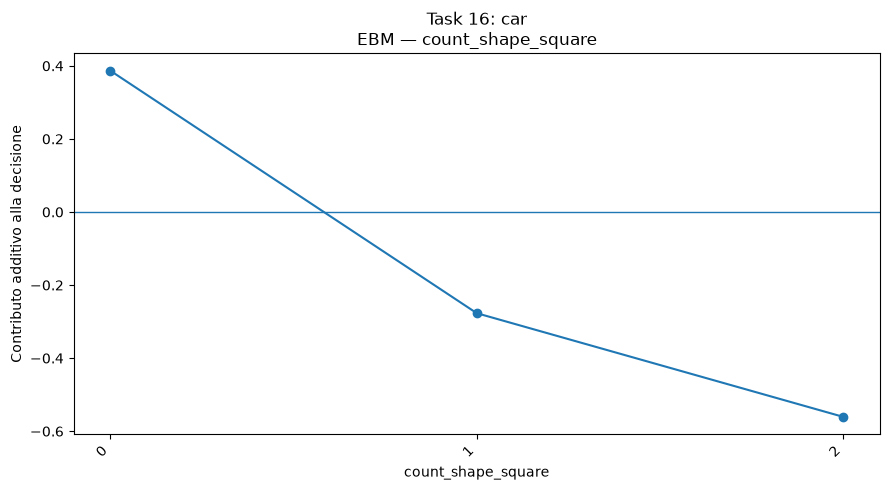

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_count_shape_square.png


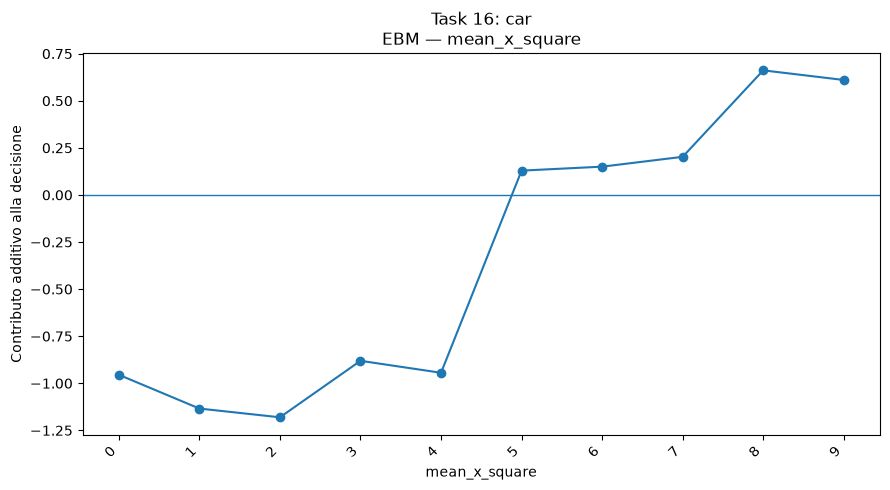

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_mean_x_square.png


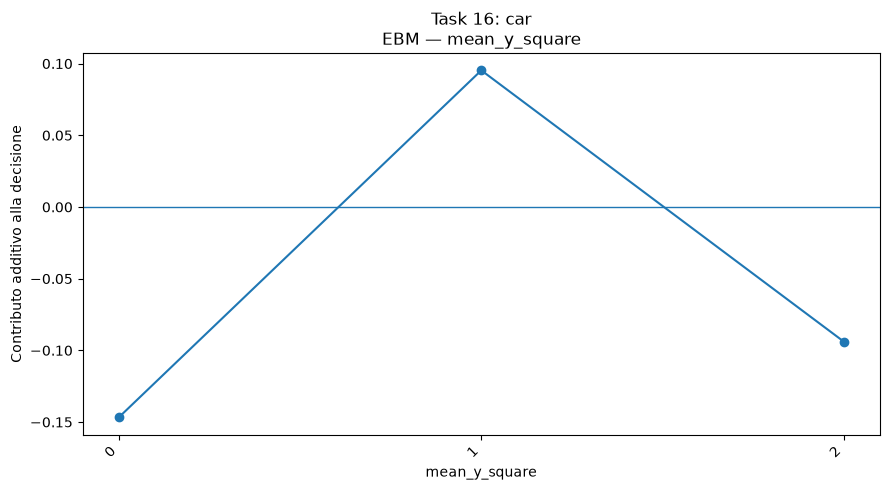

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_mean_y_square.png


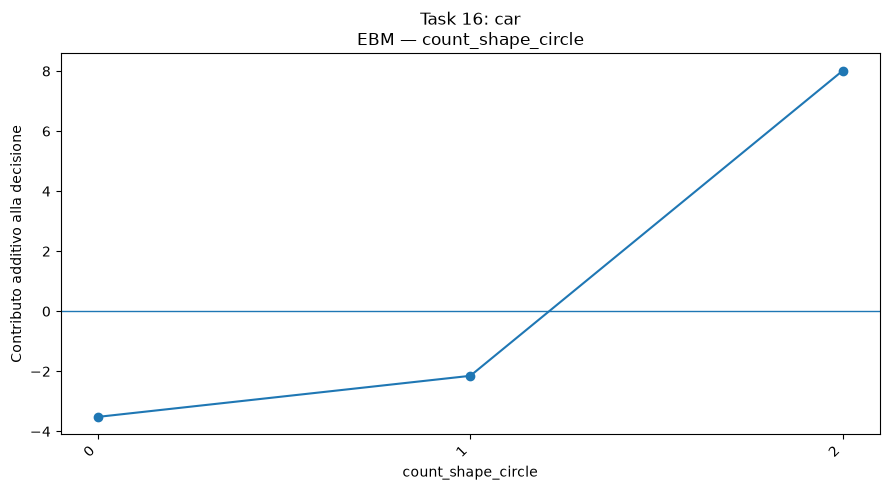

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_count_shape_circle.png


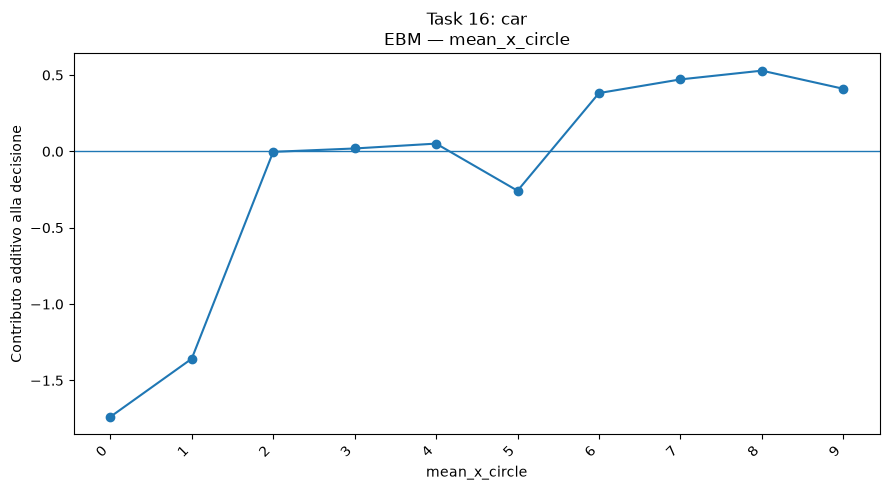

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_mean_x_circle.png


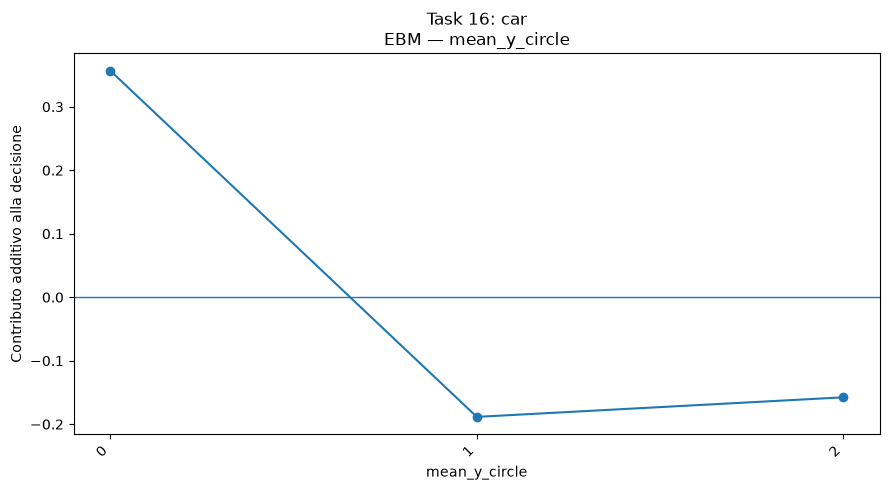

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_mean_y_circle.png


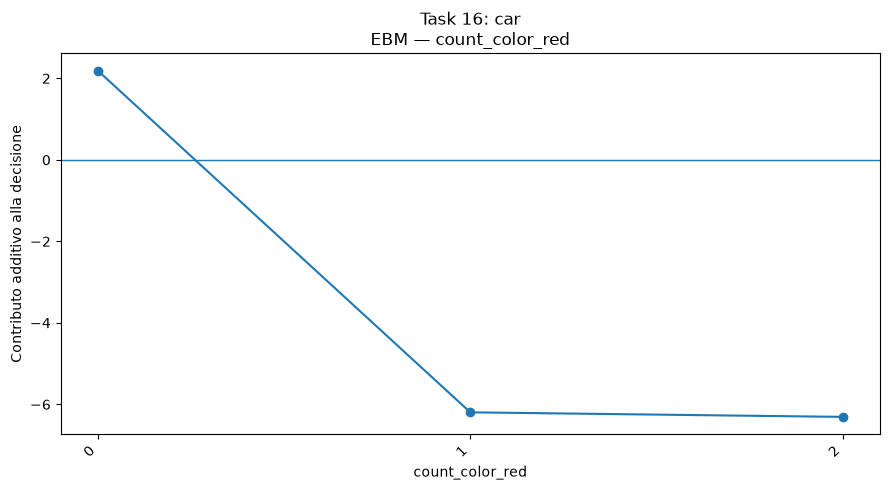

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_count_color_red.png


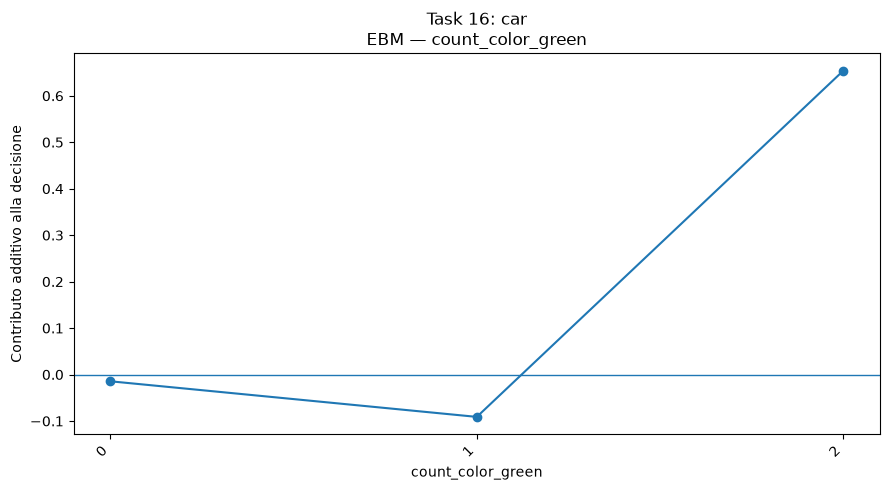

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_count_color_green.png


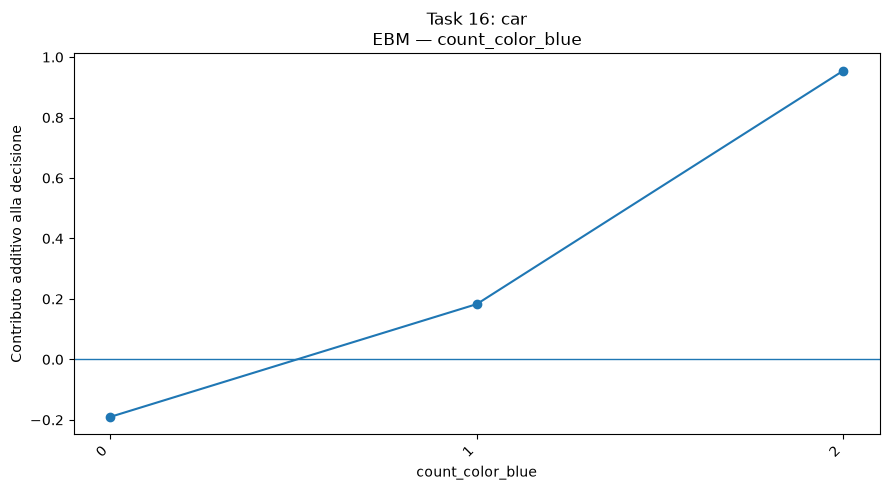

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_count_color_blue.png


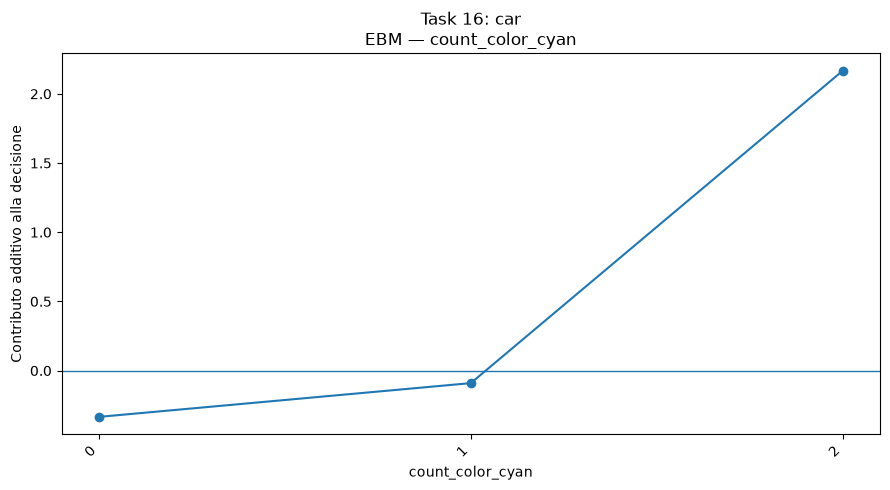

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_count_color_cyan.png


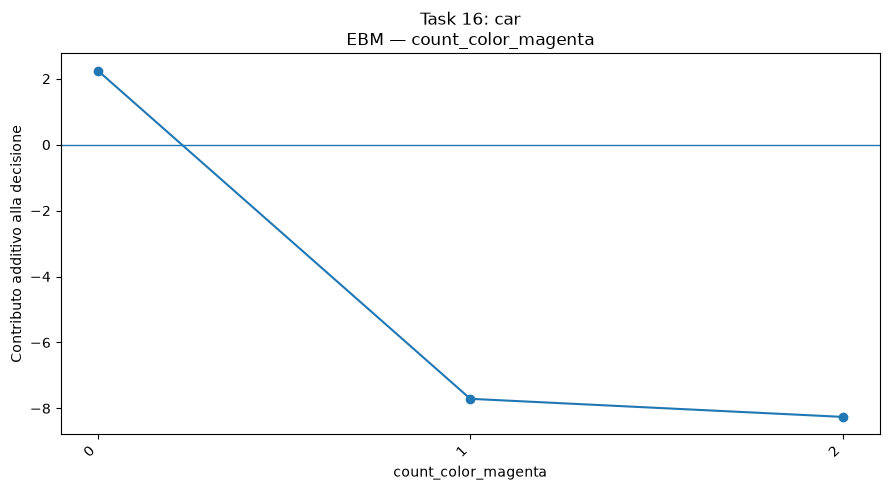

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_count_color_magenta.png


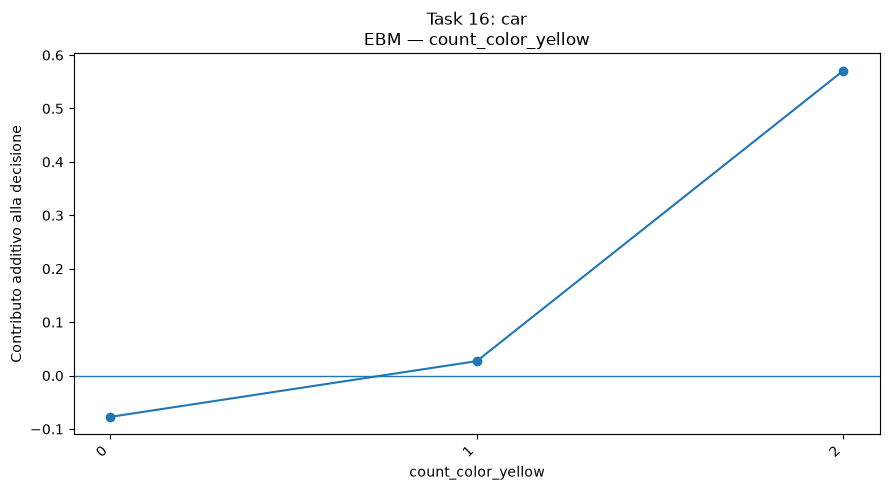

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_count_color_yellow.png


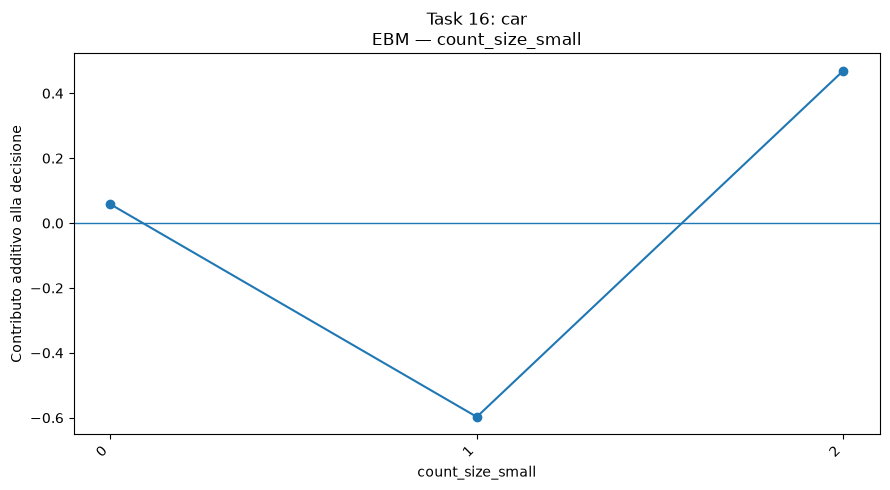

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_count_size_small.png


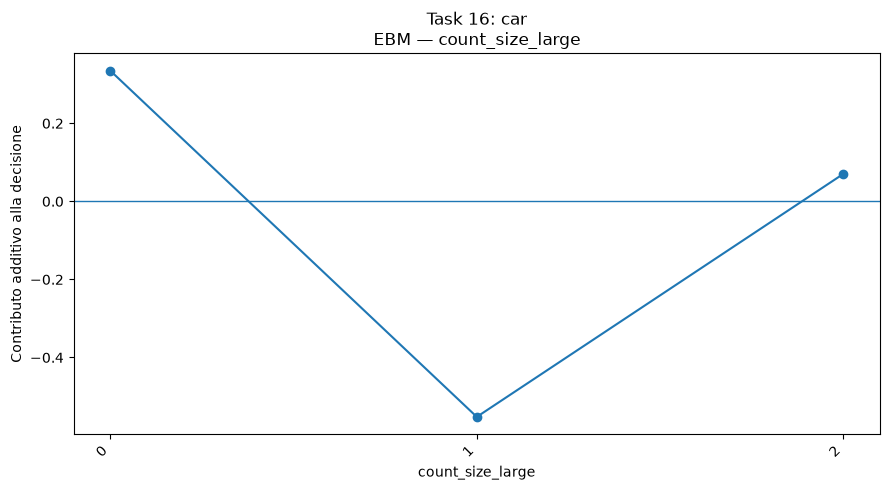

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_count_size_large.png


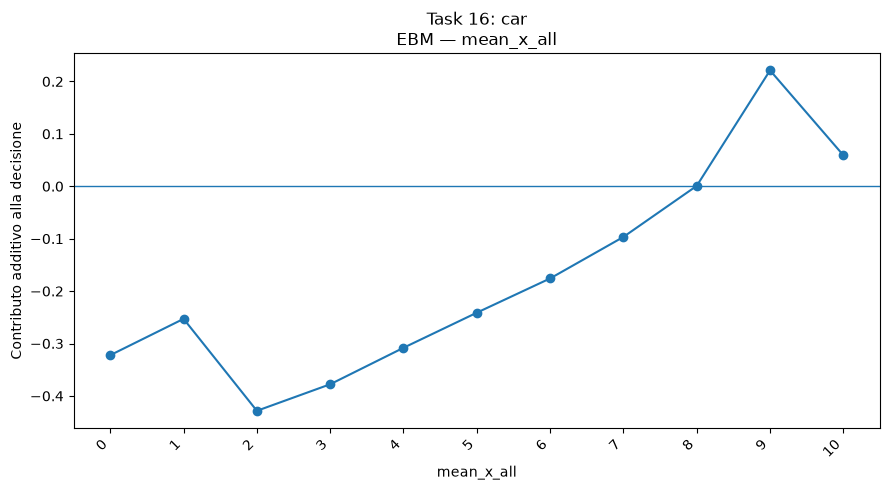

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_mean_x_all.png


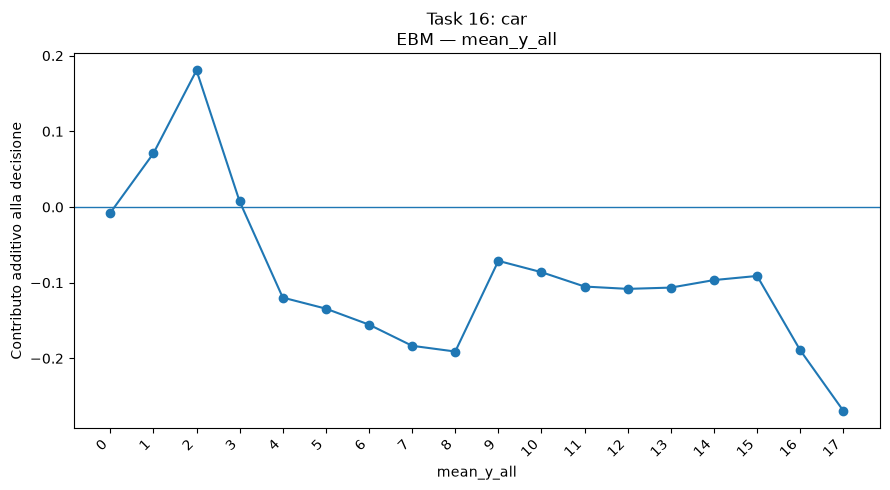

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_mean_y_all.png


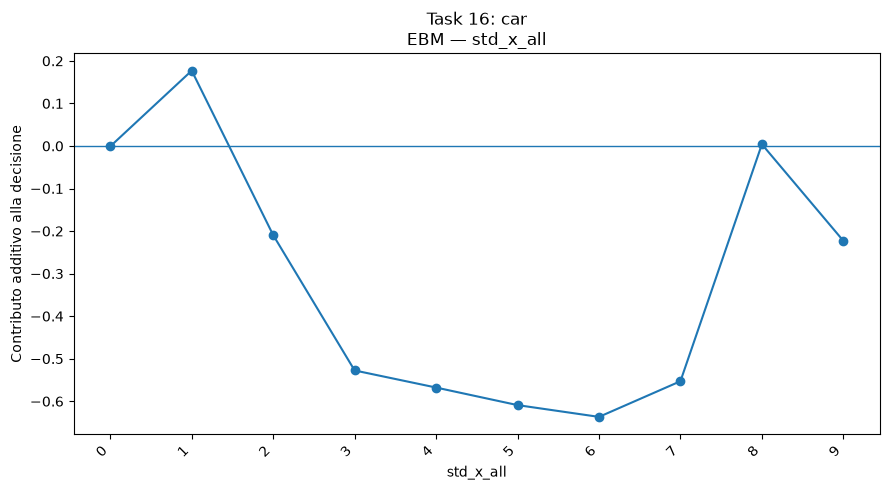

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_std_x_all.png


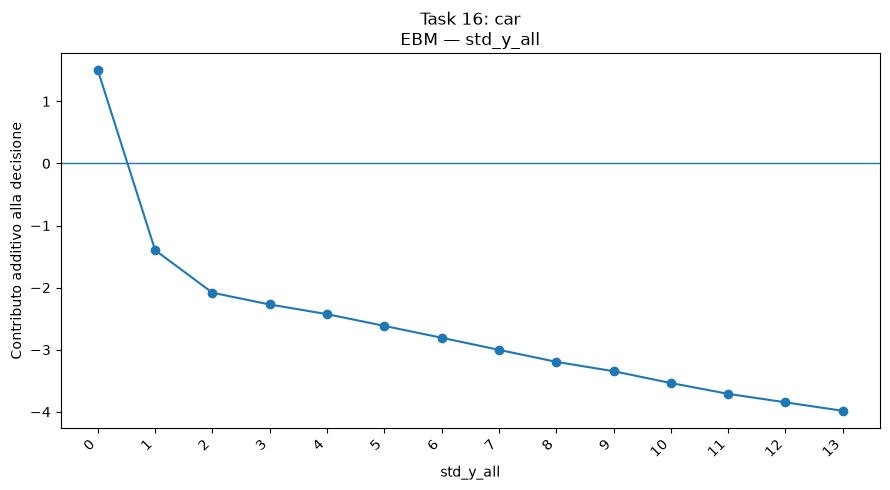

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_std_y_all.png


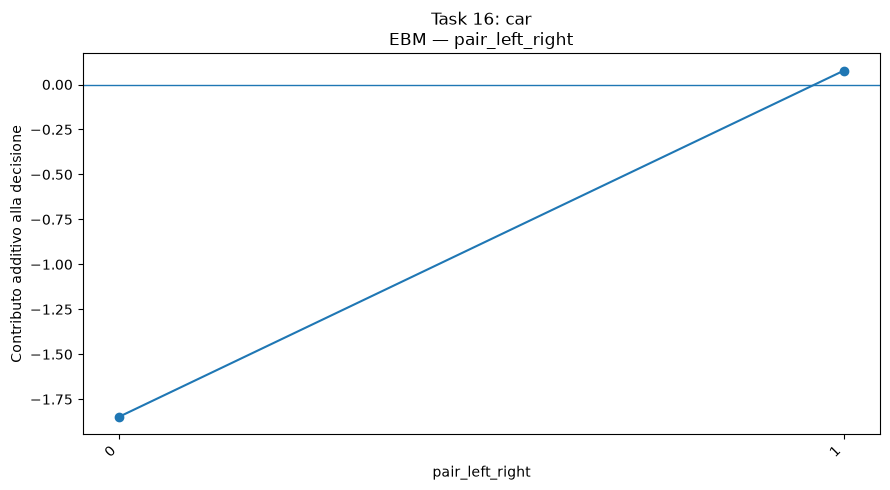

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_pair_left_right.png


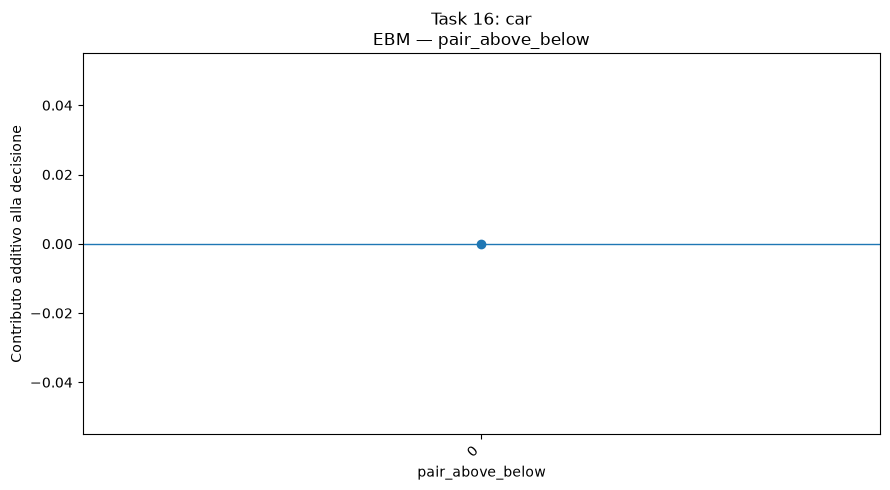

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_pair_above_below.png


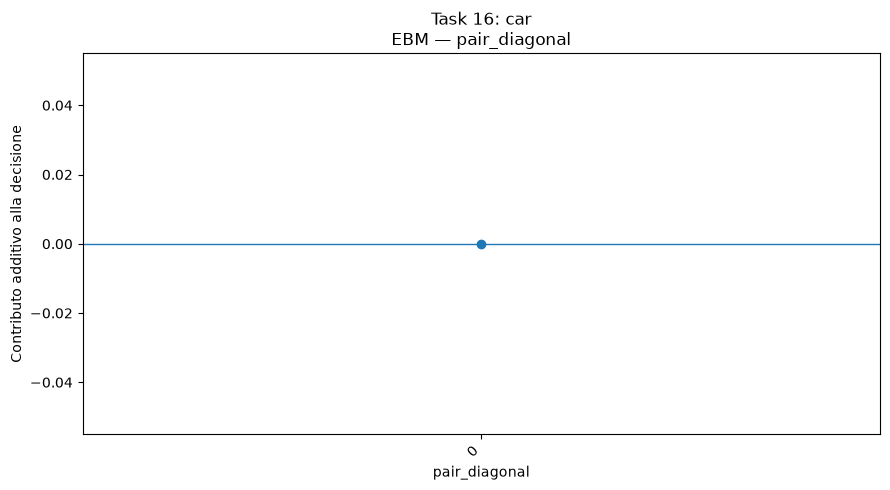

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_pair_diagonal.png


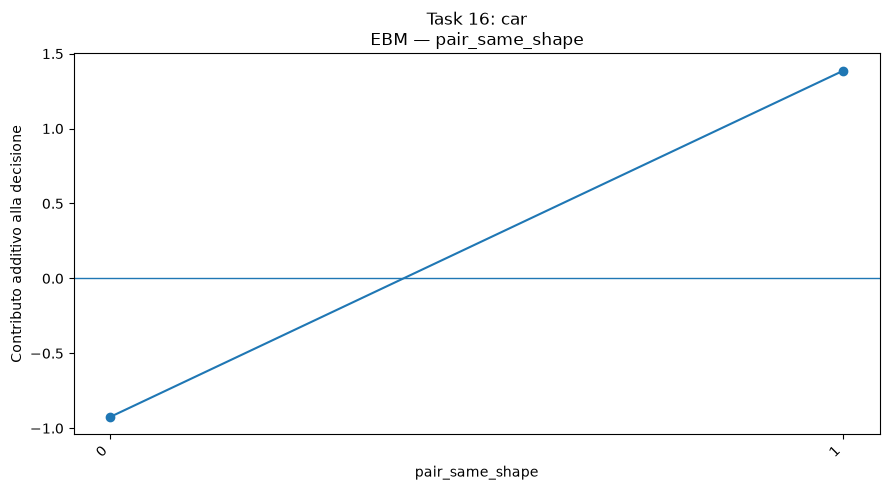

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_pair_same_shape.png


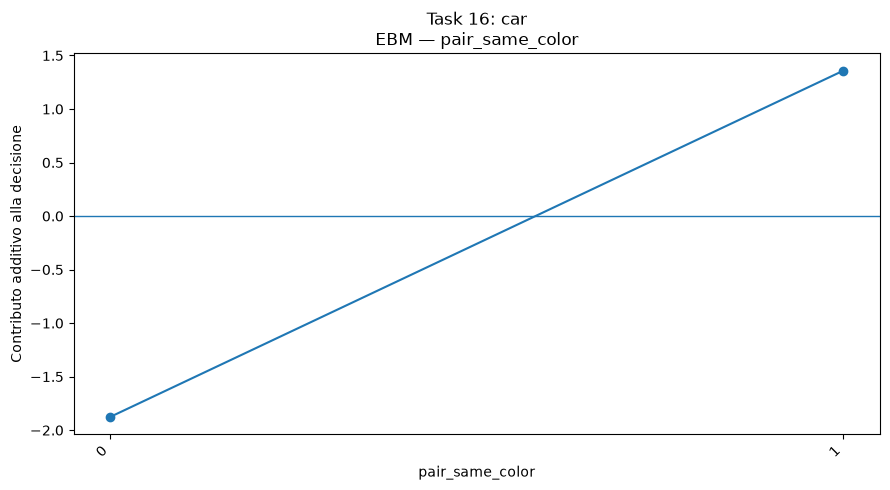

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_pair_same_color.png


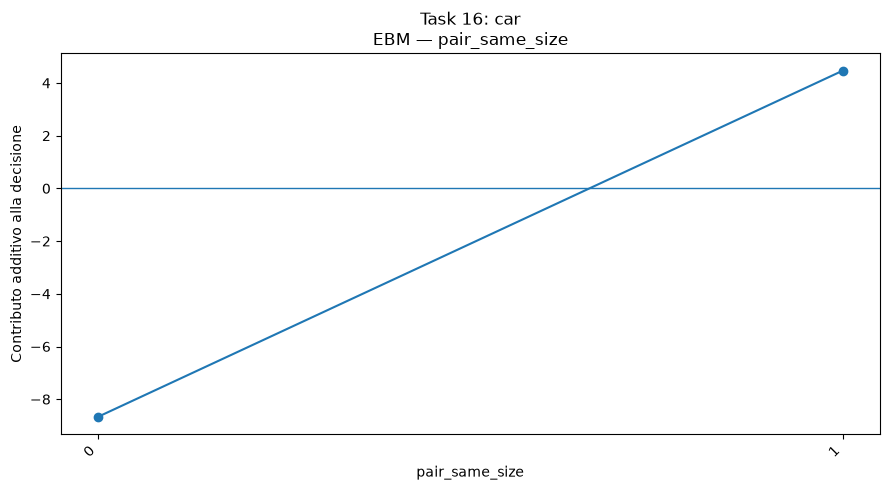

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_pair_same_size.png


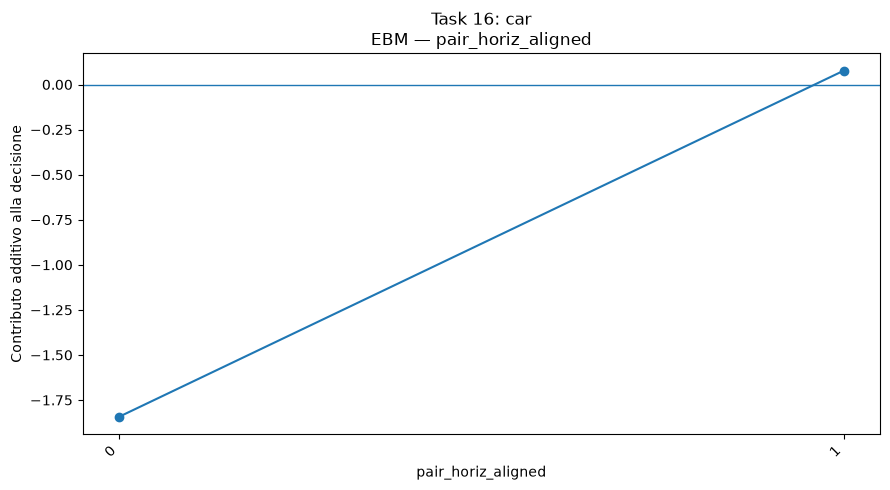

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_pair_horiz_aligned.png


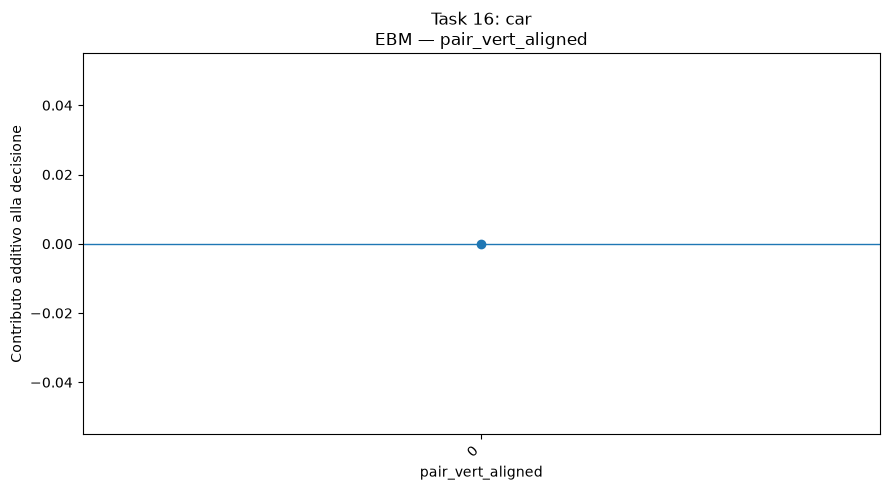

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_pair_vert_aligned.png


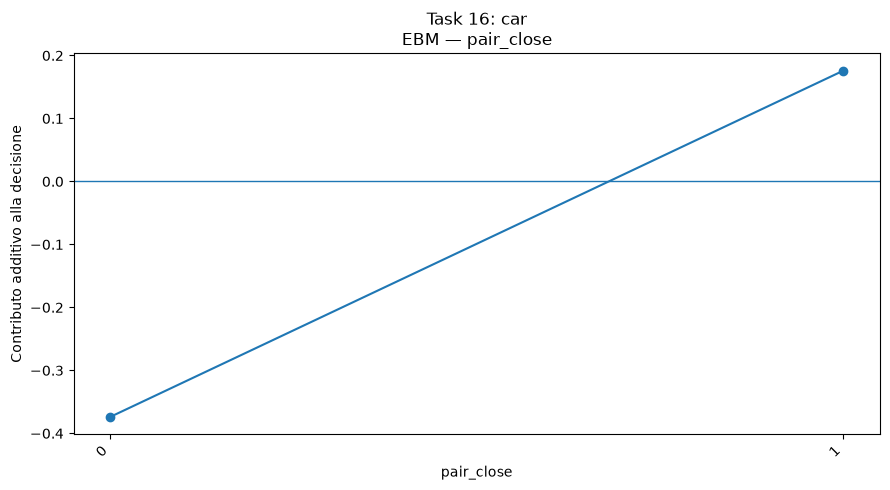

Curva salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_pair_close.png


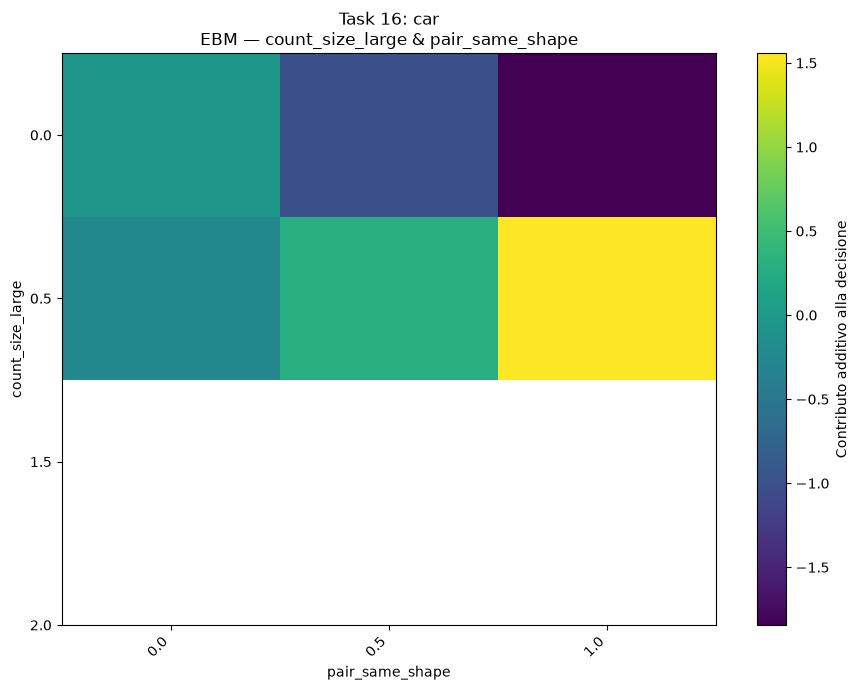

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_count_size_large_pair_same_shape_heatmap.png


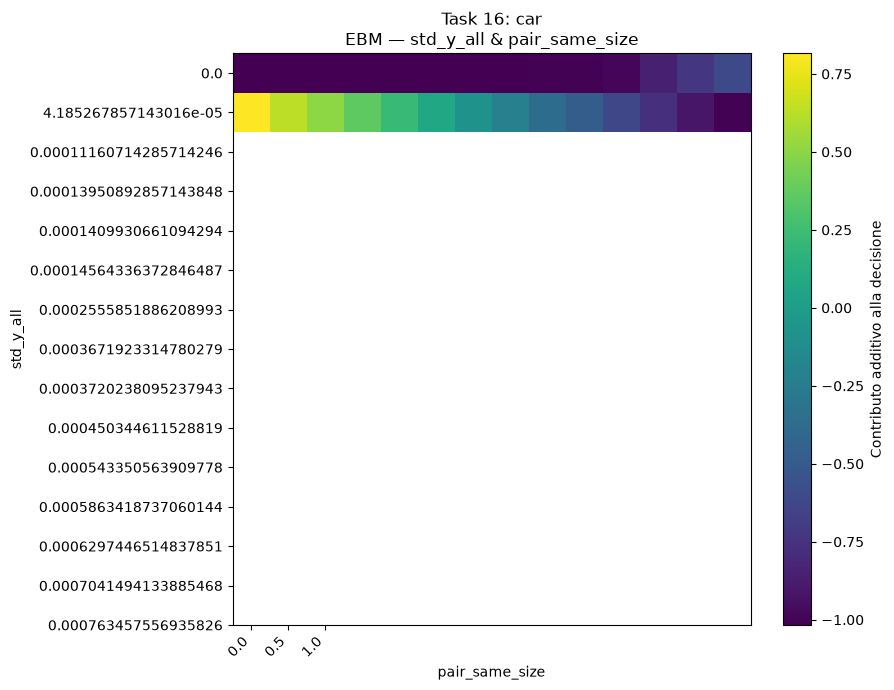

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_std_y_all_pair_same_size_heatmap.png


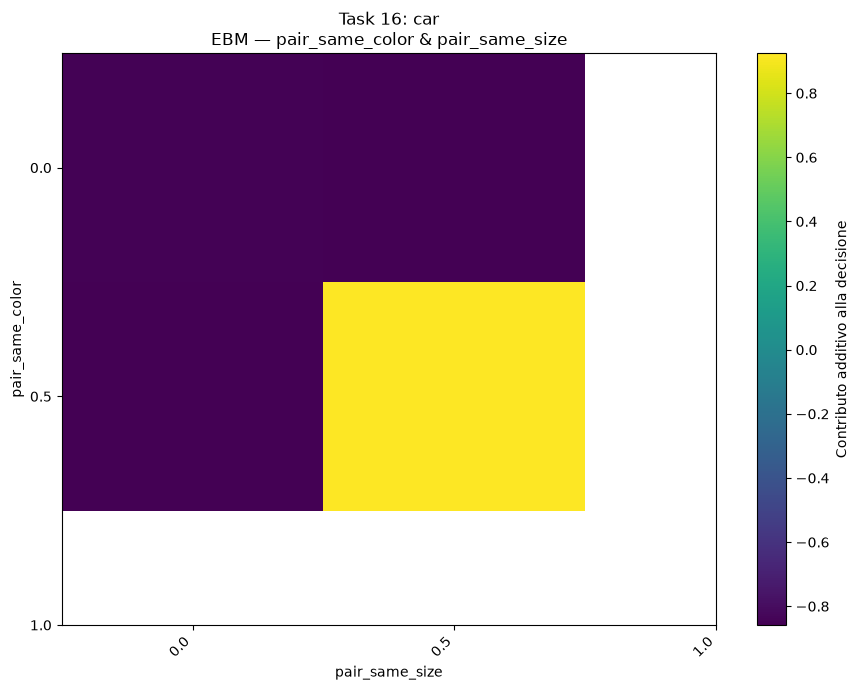

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_pair_same_color_pair_same_size_heatmap.png


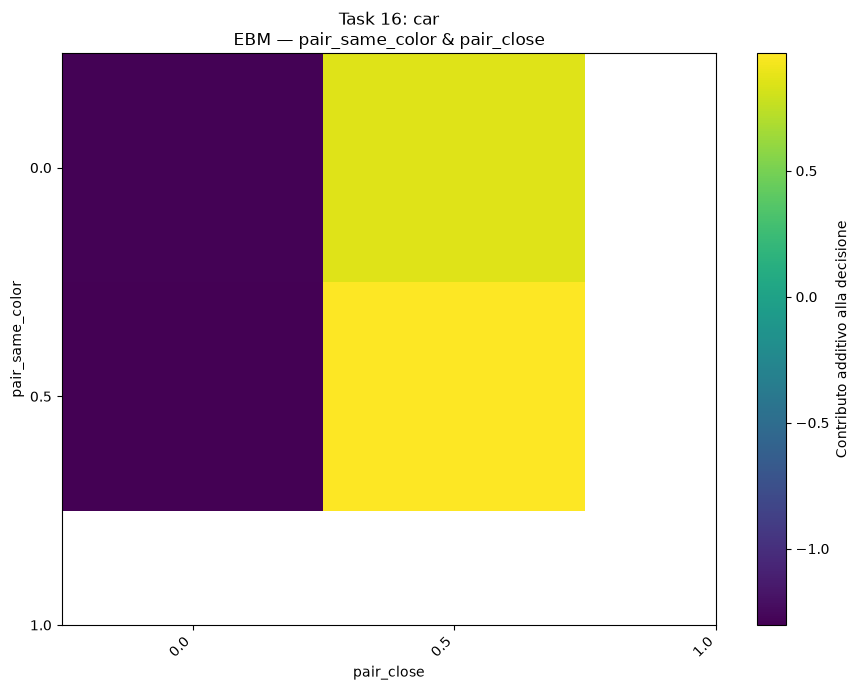

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_pair_same_color_pair_close_heatmap.png


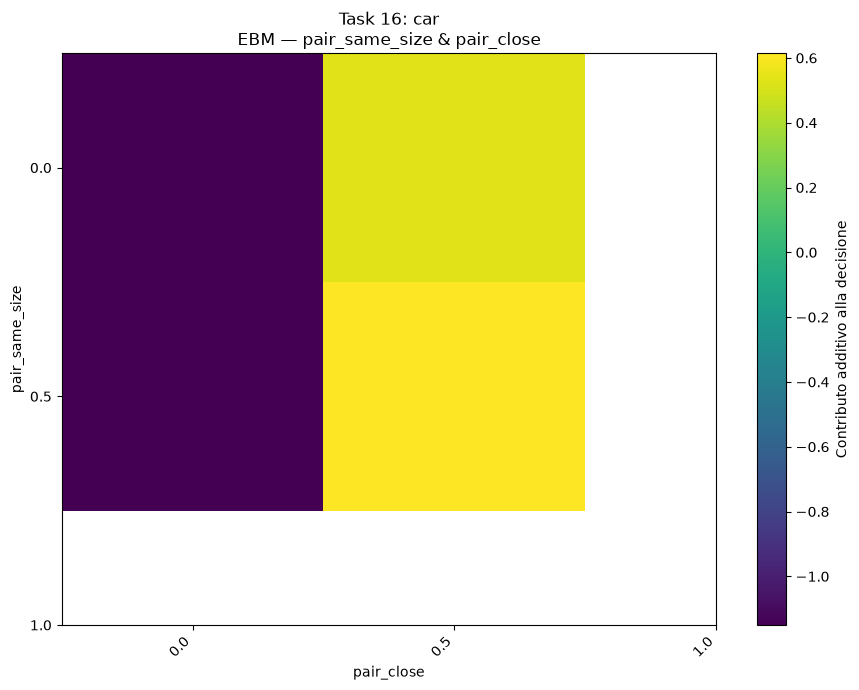

Heatmap salvata: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_pair_same_size_pair_close_heatmap.png

Operazione completata.
Cartella finale:
/home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots


In [17]:
#PLOT DELLE CURVE E DELLE INTERAZIONI
def safe_filename(name):
    name = str(name)
    name = re.sub(r"[^\w\-]+", "_", name)
    return name.strip("_")


def save_ebm_plots(model, task_id, save_dir):
    explanation = model.explain_global()

    for term_idx, term_name in enumerate(model.term_names_):

        data = explanation.data(term_idx)

        term_type = data.get("type", "univariate")
        
        if term_type != "interaction":
            #se stiamo andando a considerare il contributo 
            #della singola feature, salviamo la curva

            names = data.get("names", [])
            scores = data.get("scores", [])

            if scores is None or len(scores) == 0:
                continue

            scores = np.asarray(scores, dtype=float).ravel()

            if names is None or len(names) != len(scores):
                names = np.arange(len(scores))

            x = np.arange(len(scores))

            fig, ax = plt.subplots(figsize=tuple(CONFIG["experiment"]["plots"]["ebm_curve_figsize"]))

            ax.plot(
                x,
                scores,
                marker=CONFIG["experiment"]["plots"]["ebm_curve_marker"],
            )

            ax.axhline(
                0,
                linewidth=int(CONFIG["experiment"]["plots"]["zero_line_width"]),
            )

            ax.set_xticks(x)
            ax.set_xticklabels(
                [str(v) for v in names],
                rotation=45,
                ha="right",
            )

            ax.set_title(
                f"Task {task_id}: {TASK_NAMES[task_id]}\n"
                f"EBM — {term_name}"
            )

            ax.set_xlabel(str(term_name))
            ax.set_ylabel(
                "Contributo additivo alla decisione"
            )

            plt.tight_layout()

            clean_name = safe_filename(term_name)

            path = save_dir / (
                f"task_{task_id}_ebm_{clean_name}.png"
            )

            plt.savefig(
                path,
                dpi=int(CONFIG["experiment"]["plots"]["dpi"]),
                bbox_inches="tight",
            )

            plt.show()
            plt.close(fig)

            print(f"Curva salvata: {path}")

        else:
            #altrimenti se stiamo parlando dell'interazione tra due feature
            #usiamo una heatmap

            left_names = data.get("left_names", [])
            right_names = data.get("right_names", [])
            scores = data.get("scores", None)

            if (
                scores is None
                or len(left_names) == 0
                or len(right_names) == 0
            ):
                continue

            scores = np.asarray(scores, dtype=float)

            if scores.shape != (
                len(left_names),
                len(right_names),
            ):
                scores = scores.T

            fig, ax = plt.subplots(
                figsize=tuple(
                    CONFIG["experiment"]["plots"]["ebm_heatmap_figsize"]
                )
            )

            image = ax.imshow(
                scores,
                aspect="auto",
            )

            ax.set_xticks(
                np.arange(len(right_names))
            )
            ax.set_yticks(
                np.arange(len(left_names))
            )

            ax.set_xticklabels(
                [str(v) for v in right_names],
                rotation=45,
                ha="right",
            )

            ax.set_yticklabels(
                [str(v) for v in left_names]
            )

            ax.set_xlabel(
                term_name.split(" & ")[-1]
            )

            ax.set_ylabel(
                term_name.split(" & ")[0]
            )

            ax.set_title(
                f"Task {task_id}: {TASK_NAMES[task_id]}\n"
                f"EBM — {term_name}"
            )

            fig.colorbar(
                image,
                ax=ax,
                label="Contributo additivo alla decisione",
            )

            plt.tight_layout()

            clean_name = safe_filename(term_name)

            path = save_dir / (
                f"task_{task_id}_ebm_{clean_name}_heatmap.png"
            )

            plt.savefig(
                path,
                dpi=int(CONFIG["experiment"]["plots"]["dpi"]),
                bbox_inches="tight",
            )

            plt.show()
            plt.close(fig)

            print(f"Heatmap salvata: {path}")

for task_id in EXPLAIN_TASKS:

    ebm = models_ebm[task_id]
    #recuperiamo l'ebm addestrato per il task

    save_ebm_plots(
        model=ebm,
        task_id=task_id,
        save_dir=PLOT_DIR,
    )

print("\nOperazione completata.")
print("Cartella finale:")
print(PLOT_DIR.resolve())

## Analisi dei risultati

Guardando le curve dell'EBM sui cinque task analizzati, si vede come il contributo delle feature cambi in modo coerente con la complessità del problema. Nel task 0, che richiede semplicemente la presenza di un triangolo, la curva più evidente è quella del numero di triangoli: passare da nessun triangolo alla presenza di un triangolo cambia nettamente il contributo verso la classe positiva, mentre la presenza di cerchi o quadrati lo spinge nella direzione opposta. Nei task più strutturati le curve diventano più articolate: nel task 9 il conteggio del rosso ha un contributo sempre più positivo, mentre la posizione del triangolo mostra una tendenza crescente con valori più alti verso destra, coerente con la natura del task; compaiono inoltre diversi contributi non monotoni, segno che la posizione e le altre caratteristiche vengono combinate in modo più complesso. Nel task 13 è particolarmente interessante pair_same_color, il cui contributo cresce nettamente quando aumenta il numero di coppie dello stesso colore, mentre pair_same_shape tende nella direzione opposta. Nel task 15, relativo alla casa, le curve sono ancora più irregolari: posizione media, conteggio dei colori e relazioni tra forme producono contributi che cambiano in modo non lineare, mostrando quanto sia difficile rappresentare una struttura complessa con sole feature generiche. Infine, nel task 19 emergono contributi molto marcati per i colori: il giallo tende a spingere verso la classe positiva, mentre blu e ciano verso quella negativa; anche pair_same_size mostra un forte aumento del contributo.

Per quanto riguarda le heatmap, e quindi le interazioni tra le variabili, notiamo che è difficile interpretarle in modo altrettanto immediato. Le combinazioni tra due feature producono infatti contributi che possono variare molto tra una zona e l'altra della matrice e, con il numero limitato di esempi disponibili per ogni task, alcune combinazioni risultano poco rappresentate. Per questo motivo le heatmap sono utili soprattutto come indicazione qualitativa delle interazioni apprese dal modello, mentre le curve delle singole feature rimangono più semplici da leggere e da collegare alla struttura delle task.


## Ulteriori visualizzazioni

Per rendere più leggibile il confronto tra i tre modelli, mostriamo alcune visualizzazioni sulle feature utilizzate nella decisione dei modelli precedentemente ottenuti.

Per la regressione logistica visualizziamo i 10 coefficienti con valore assoluto maggiore. Il segno del coefficiente indica la direzione del contributo: valori positivi spingono verso la classe positiva, mentre valori negativi verso quella negativa.

Per l'albero di decisione mostriamo sia la struttura completa dell'albero sia le 10 feature con maggiore feature importance, calcolata in base alla riduzione dell'impurità.

Per l'EBM visualizziamo invece i 10 termini con maggiore contributo assoluto medio, in questo caso non abbiamo un singolo coefficiente per feature: il contributo può variare in modo non lineare al variare del valore della feature, quindi consideriamo quanto è grande mediamente il suo contributo in valore assoluto.

In questo modo possiamo confrontare non solo le prestazioni dei tre modelli, ma anche quali informazioni della rappresentazione vengono utilizzate per arrivare alla decisione e con quale comportamento.

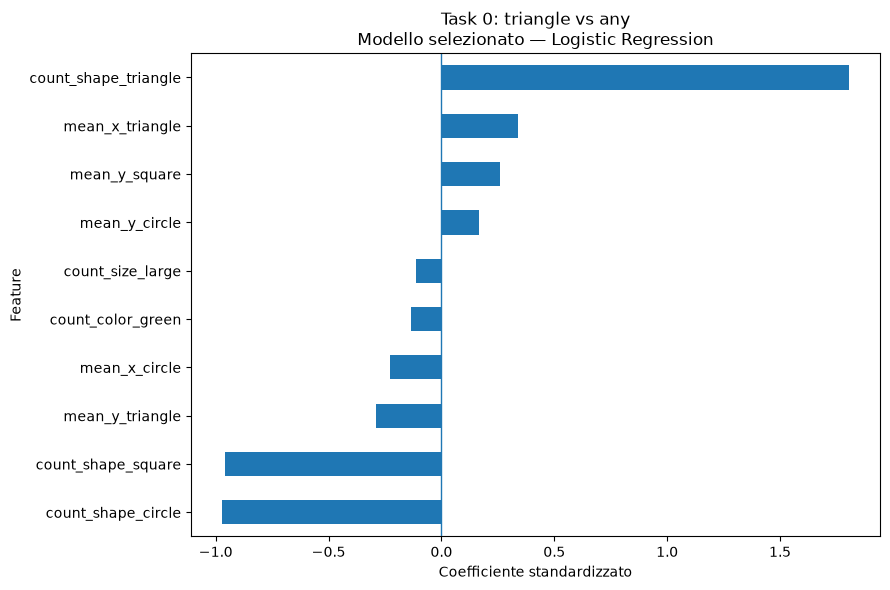

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_selected_logistic.png


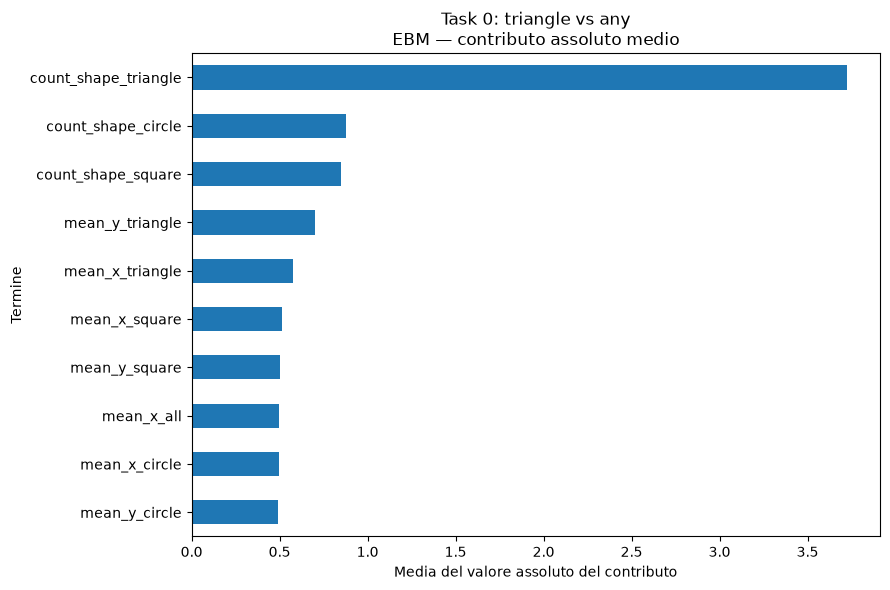

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_0_ebm_importance.png


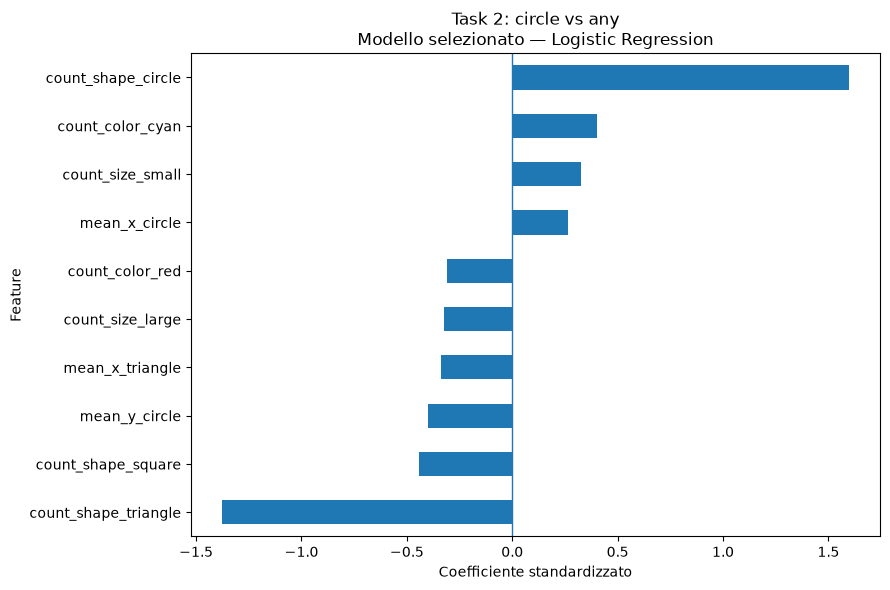

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_selected_logistic.png


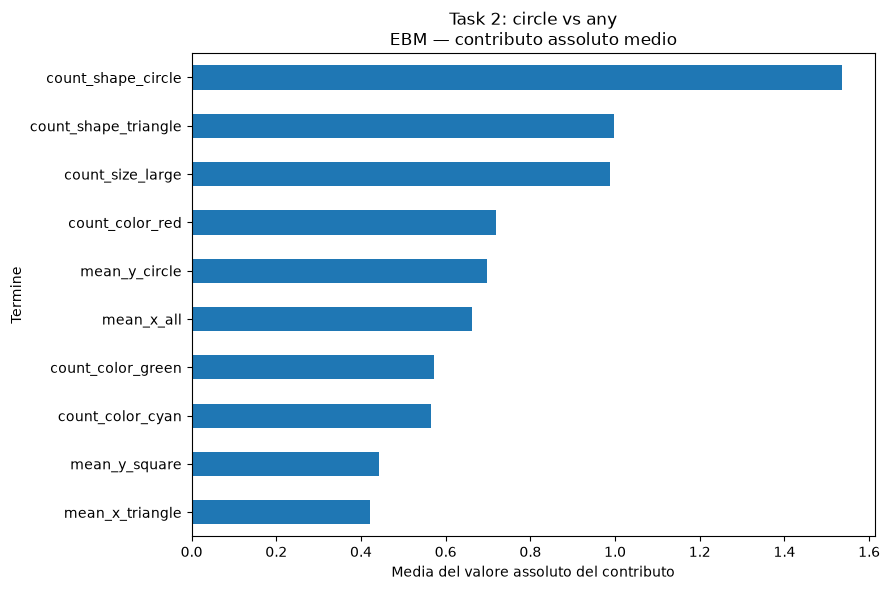

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_2_ebm_importance.png


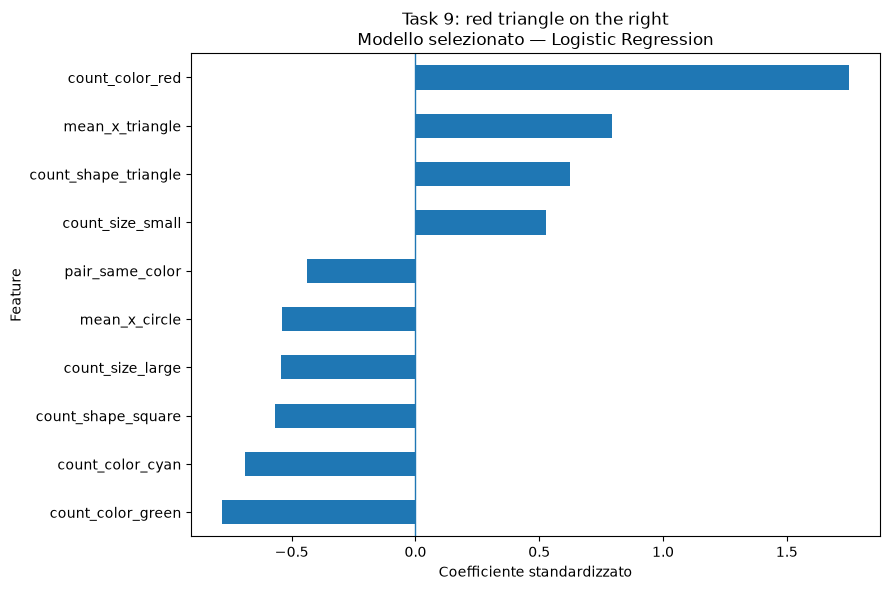

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_selected_logistic.png


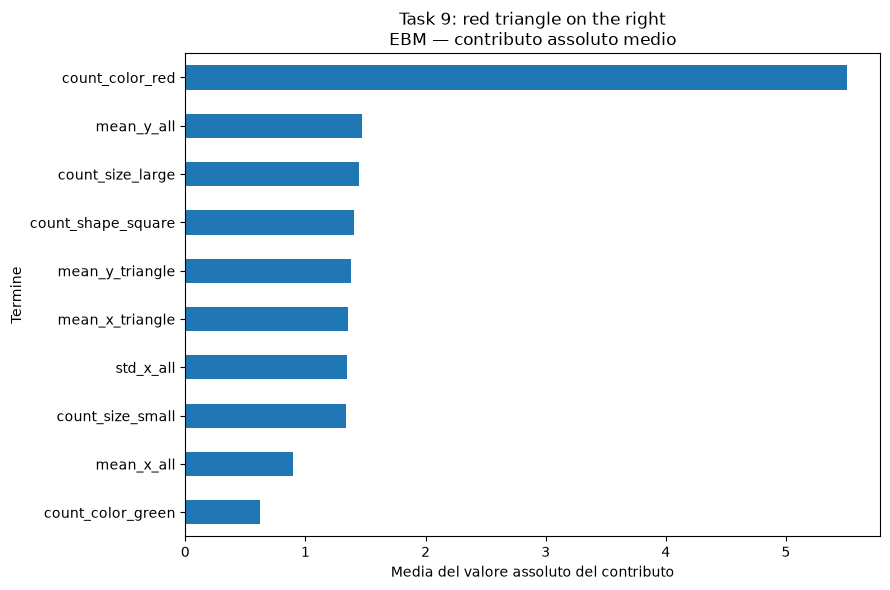

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_9_ebm_importance.png


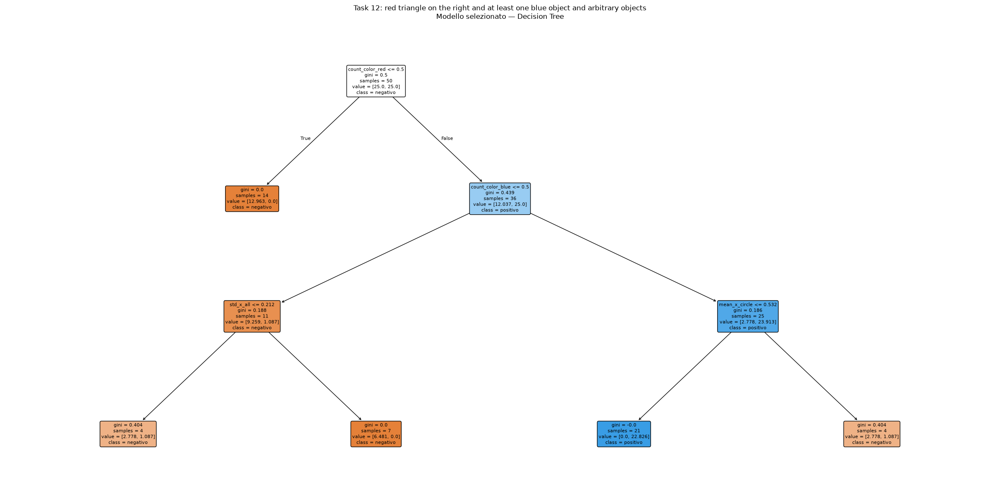

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_selected_tree.png


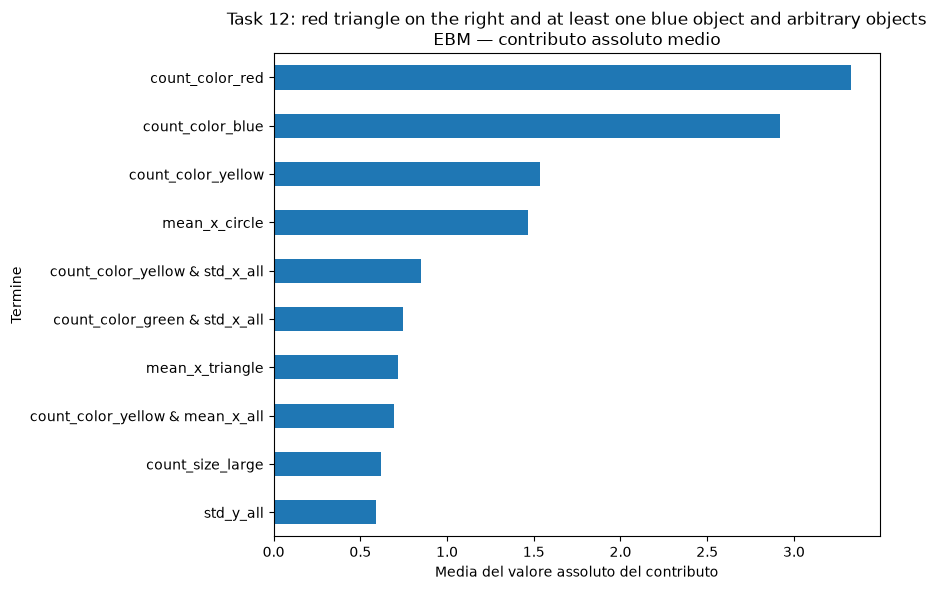

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_12_ebm_importance.png


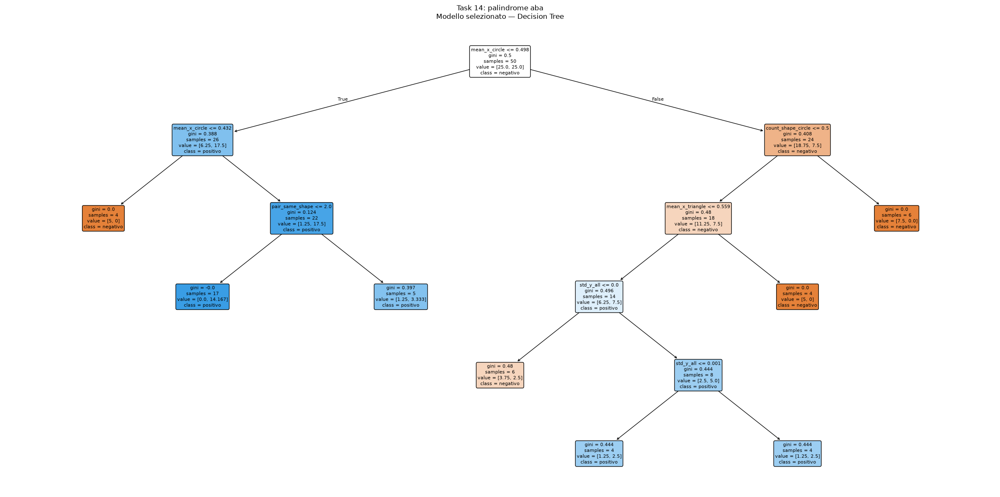

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_selected_tree.png


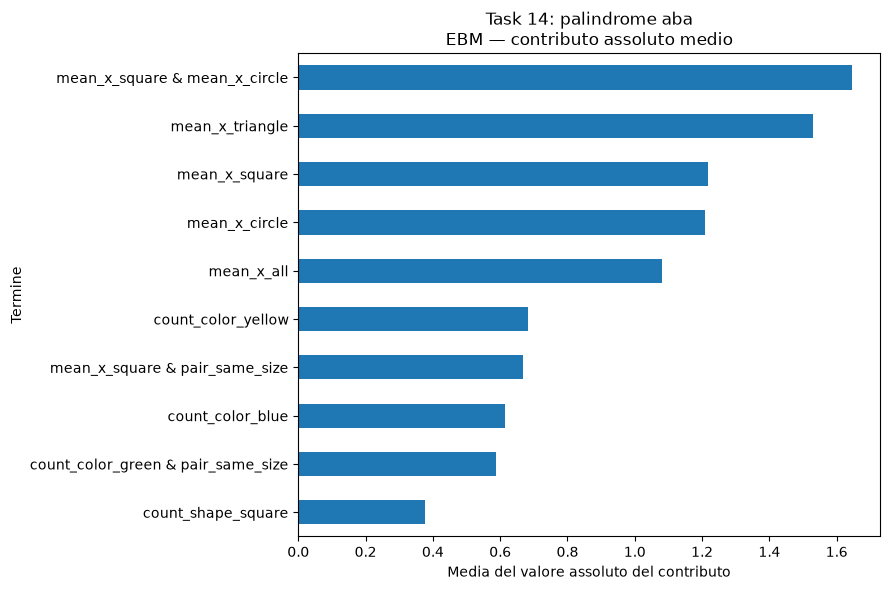

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_14_ebm_importance.png


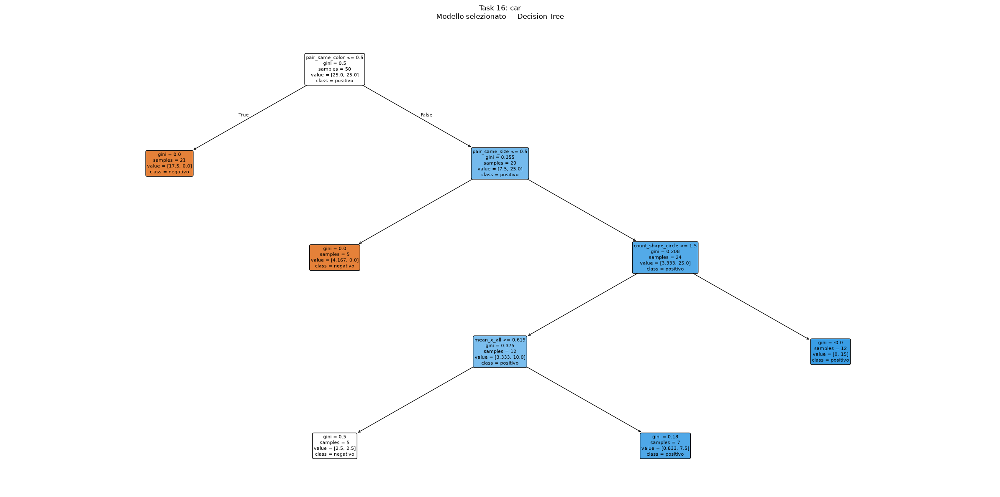

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_selected_tree.png


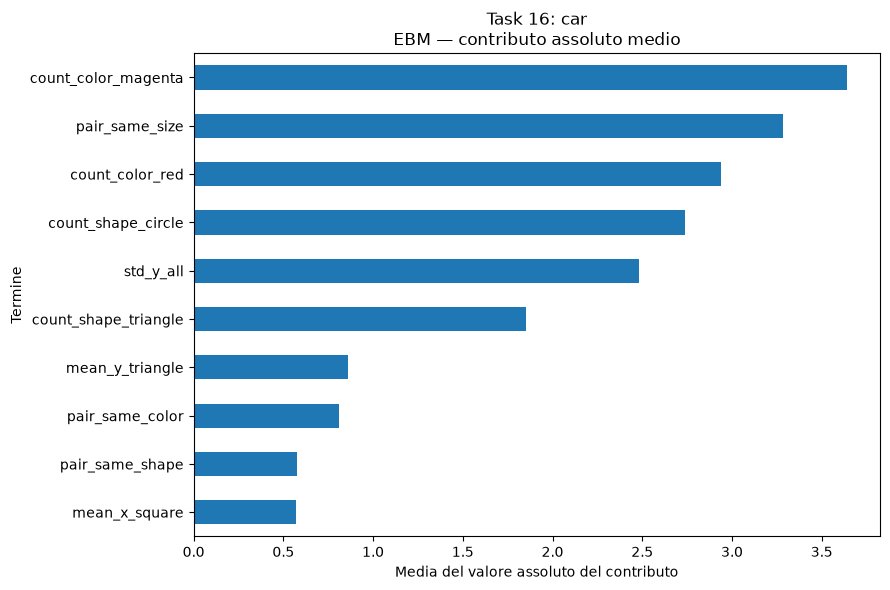

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots/task_16_ebm_importance.png

Grafici salvati in:
/home/cosimo/Downloads/kandy-xai/results/interpretable_models/plots


In [18]:
#ULTERIORI VISUALIZZAZIONI

EXPLAIN_TASKS = list(
    CONFIG["experiment"]["explain_tasks"]
)
#task selezionati per le visualizzazioni interpretabili

TOP_N = int(
    CONFIG["experiment"]["top_n"]
)
#numero massimo di feature mostrate nei grafici delle importanze

PLOT_DIR = os.fspath(
    ROOT
    / CONFIG["paths"]["plots_dir"]
)
os.makedirs(
    PLOT_DIR,
    exist_ok=True,
)


def ebm_term_importance(model):
    if model is None:
        return pd.Series(dtype=float)

    term_scores = getattr(
        model,
        "term_scores_",
        None,
    )

    term_names = getattr(
        model,
        "term_names_",
        None,
    )

    if term_scores is not None and term_names is not None:
        values = []

        for name, score in zip(
            term_names,
            term_scores,
        ):
            arr = np.asarray(
                score,
                dtype=float,
            )

            values.append(
                (
                    str(name),
                    float(
                        np.mean(
                            np.abs(arr)
                        )
                    ),
                )
            )

        return (
            pd.Series(
                dict(values),
                dtype=float,
            )
            .sort_values(
                ascending=False
            )
        )

    try:
        data = model.explain_global().data()

        names = data.get(
            "names",
            [],
        )

        scores = data.get(
            "scores",
            [],
        )

        values = []

        for name, score in zip(
            names,
            scores,
        ):
            arr = np.asarray(
                score,
                dtype=float,
            )

            values.append(
                (
                    str(name),
                    float(
                        np.mean(
                            np.abs(arr)
                        )
                    ),
                )
            )

        return (
            pd.Series(
                dict(values),
                dtype=float,
            )
            .sort_values(
                ascending=False
            )
        )

    except Exception:
        return pd.Series(dtype=float)


for task_id in EXPLAIN_TASKS:

    # Recuperiamo il modello già selezionato
    # durante l'esperimento precedente.
    model = models_all.get(task_id)

    # Recuperiamo l'EBM già addestrato.
    ebm = models_ebm.get(task_id)

    if model is None:
        print(
            f"Task {task_id}: "
            "modello non disponibile."
        )
        continue

    task_name = TASK_NAMES[task_id]

    if isinstance(
        model,
        Pipeline,
    ):
        #se il modello scelto è la regressione,
        #mostriamo i coefficienti

        coef = pd.Series(
            model.named_steps["clf"].coef_[0],
            index=ALL_FEATURES,
        )

        coef = (
            coef.loc[
                coef.abs()
                .sort_values(
                    ascending=False
                )
                .head(TOP_N)
                .index
            ]
            .sort_values()
        )

        fig, ax = plt.subplots(
            figsize=tuple(CONFIG["experiment"]["plots"]["logistic_figsize"])
        )

        coef.plot(
            kind="barh",
            ax=ax,
        )

        ax.axvline(
            0,
            linewidth=1,
        )

        ax.set_title(
            f"Task {task_id}: {task_name}\n"
            "Modello selezionato — Logistic Regression"
        )

        ax.set_xlabel(
            "Coefficiente standardizzato"
        )

        ax.set_ylabel(
            "Feature"
        )

        plt.tight_layout()

        path = os.path.join(
            PLOT_DIR,
            f"task_{task_id}_selected_logistic.png",
        )

        plt.savefig(
            path,
            dpi=int(CONFIG["experiment"]["plots"]["dpi"]),
            bbox_inches="tight",
        )

        plt.show()
        plt.close(fig)

        print(
            f"Salvato: {path}"
        )

    elif isinstance(
        model,
        DecisionTreeClassifier,
    ):
        #se il modello scelto è l'albero
        #ne mostriamo direttamente la struttura

        fig, ax = plt.subplots(
            figsize=tuple(CONFIG["experiment"]["plots"]["tree_figsize"])
        )

        plot_tree(
            model,
            feature_names=ALL_FEATURES,
            class_names=[
                "negativo",
                "positivo",
            ],
            filled=True,
            rounded=True,
            fontsize=int(CONFIG["experiment"]["plots"]["tree_fontsize"]),
            impurity=True,
            proportion=False,
            node_ids=False,
            ax=ax,
        )

        ax.set_title(
            f"Task {task_id}: {task_name}\n"
            "Modello selezionato — Decision Tree"
        )

        plt.tight_layout()

        path = os.path.join(
            PLOT_DIR,
            f"task_{task_id}_selected_tree.png",
        )

        plt.savefig(
            path,
            dpi=int(CONFIG["experiment"]["plots"]["dpi"]),
            bbox_inches="tight",
        )

        plt.show()
        plt.close(fig)

        print(
            f"Salvato: {path}"
        )

    #ebm

    if ebm is not None:

        ebm_imp = (
            ebm_term_importance(ebm)
            .head(TOP_N)
            .sort_values()
        )

        fig, ax = plt.subplots(
            figsize=tuple(CONFIG["experiment"]["plots"]["ebm_importance_figsize"])
        )

        if len(ebm_imp):

            ebm_imp.plot(
                kind="barh",
                ax=ax,
            )

            ax.set_title(
                f"Task {task_id}: {task_name}\n"
                "EBM — contributo assoluto medio"
            )

            ax.set_xlabel(
                "Media del valore assoluto del contributo"
            )

            ax.set_ylabel(
                "Termine"
            )

        else:

            ax.text(
                0.5,
                0.5,
                "EBM non disponibile",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )

            ax.set_axis_off()

        plt.tight_layout()

        path = os.path.join(
            PLOT_DIR,
            f"task_{task_id}_ebm_importance.png",
        )

        plt.savefig(
            path,
            dpi=int(CONFIG["experiment"]["plots"]["dpi"]),
            bbox_inches="tight",
        )

        plt.show()
        plt.close(fig)

        print(
            f"Salvato: {path}"
        )


print()
print("Grafici salvati in:")
print(os.path.abspath(PLOT_DIR))

## Diagnostica post-hoc e analisi degli errori

Prima di andare avanti, facciamo un ultimo controllo per assicurarci che symbol non sia mai stato usato direttamente come feature dai classificatori; successivamente guardiamo più da vicino gli errori commessi sui dati di test, questo per capire quali task risultano ancora più difficili e dove i modelli iniziano a mostrare i loro limiti.


In [19]:
print(
    "symbol presente nel dataset:",
    "symbol" in splits["train"].columns,
)

print(
    "symbol usato come feature:",
    "symbol" in ALL_FEATURES,
)

assert "symbol" not in ALL_FEATURES

symbol presente nel dataset: True
symbol usato come feature: False


Numero totale di errori: 96

Errori per modello e task:


,model,task_id,n_errors
7,ebm,15,9
3,ebm,10,5
5,ebm,12,5
6,ebm,14,4
8,ebm,16,4
10,ebm,19,4
1,ebm,2,3
4,ebm,11,3
9,ebm,18,2
0,ebm,1,1



Tabella salvata in: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/test_errors_by_model.csv

MODELLO: ebm


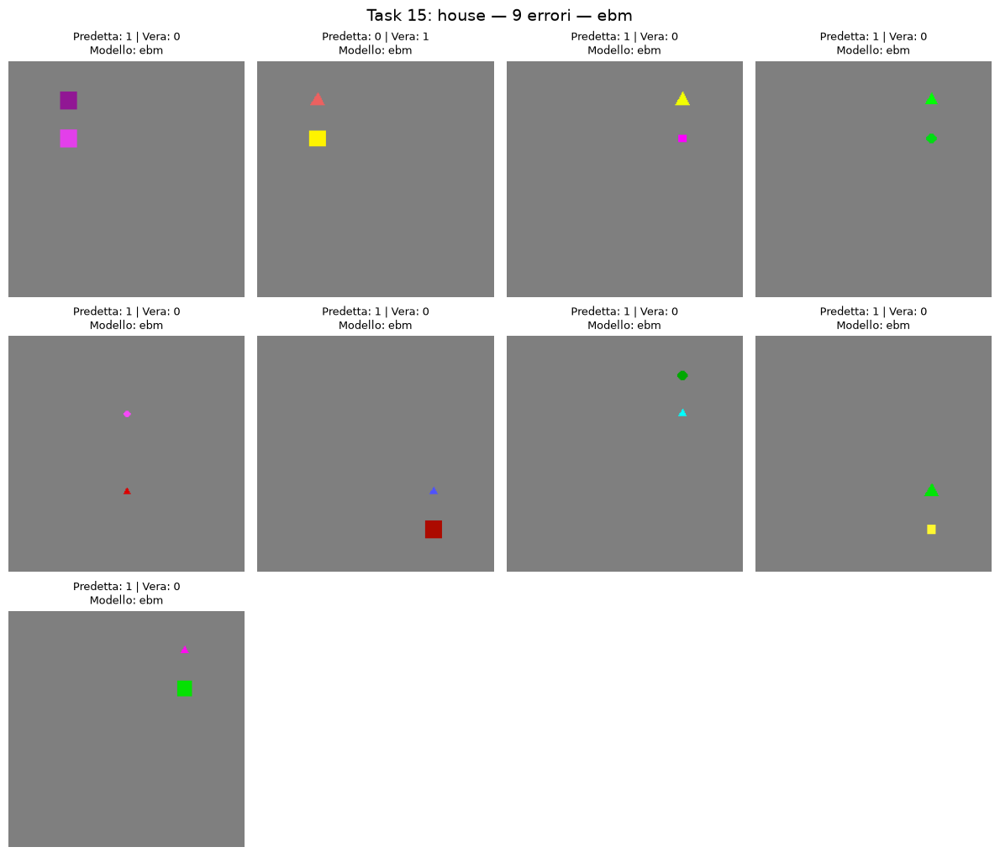

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/ebm/task_15_errors.png


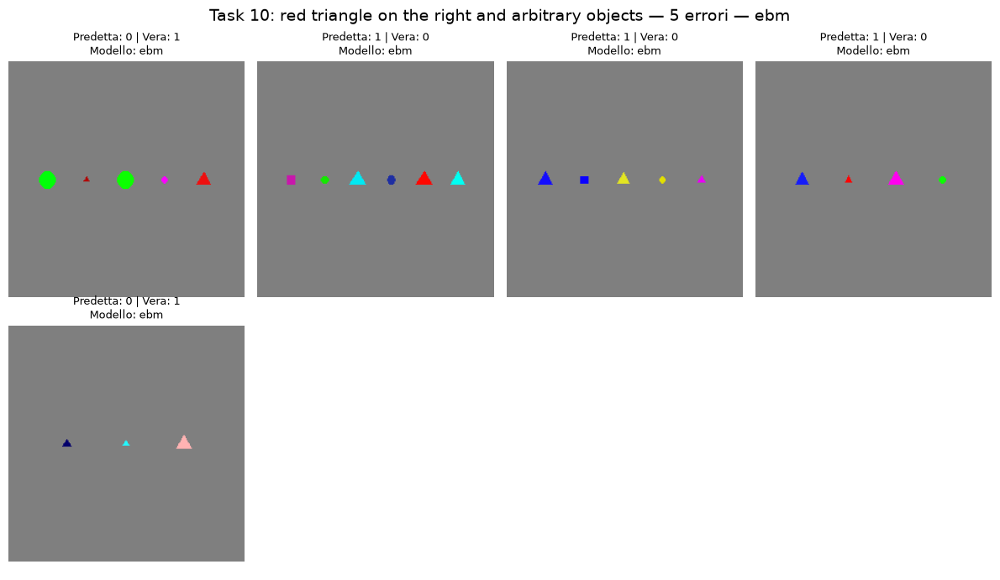

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/ebm/task_10_errors.png


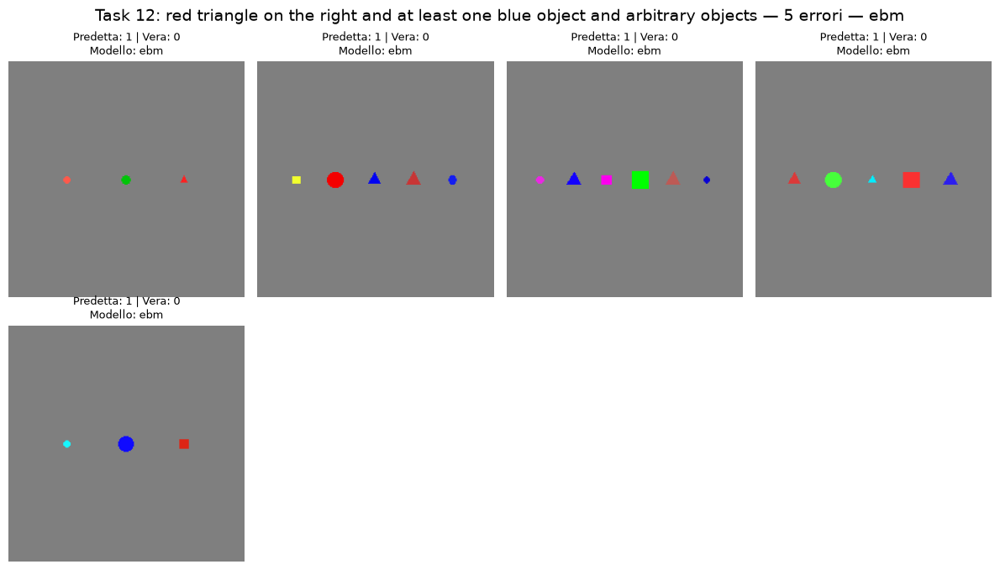

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/ebm/task_12_errors.png


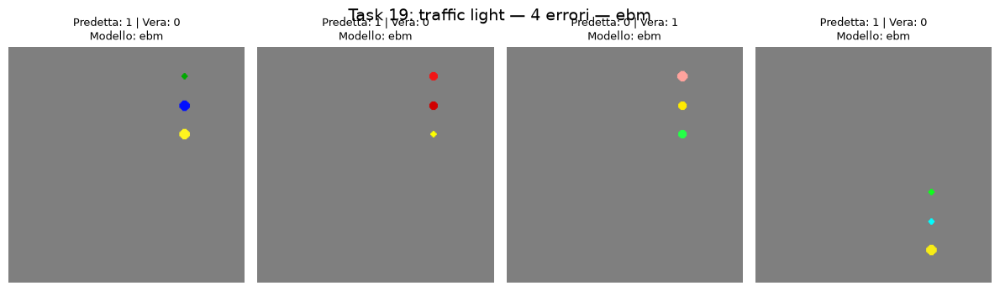

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/ebm/task_19_errors.png


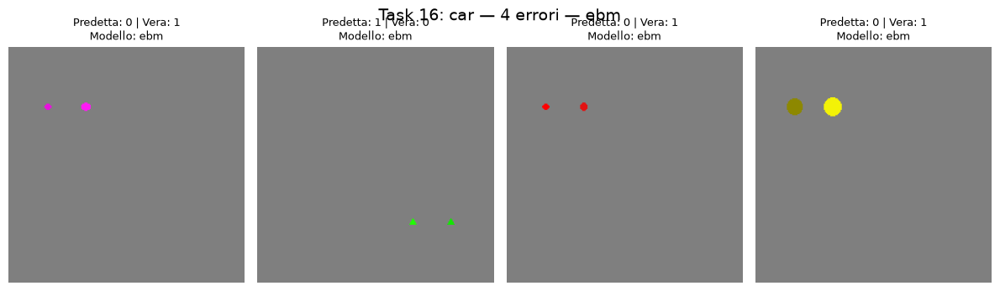

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/ebm/task_16_errors.png


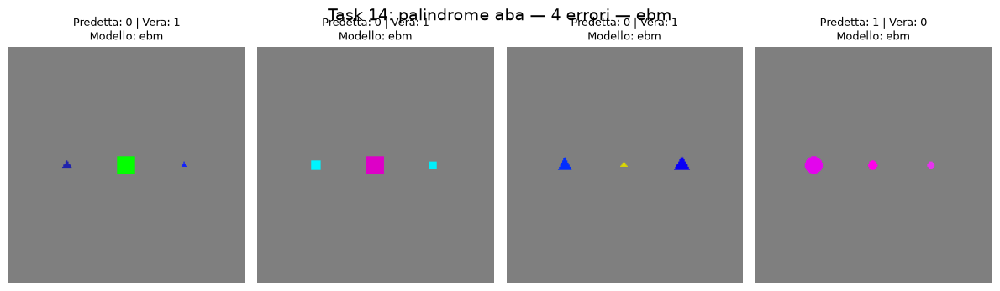

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/ebm/task_14_errors.png


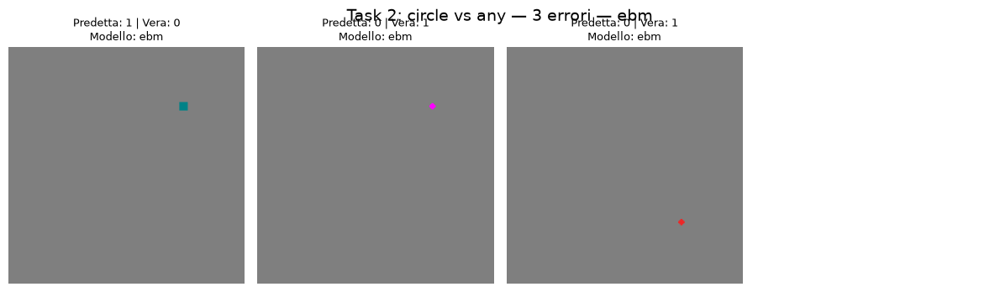

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/ebm/task_2_errors.png


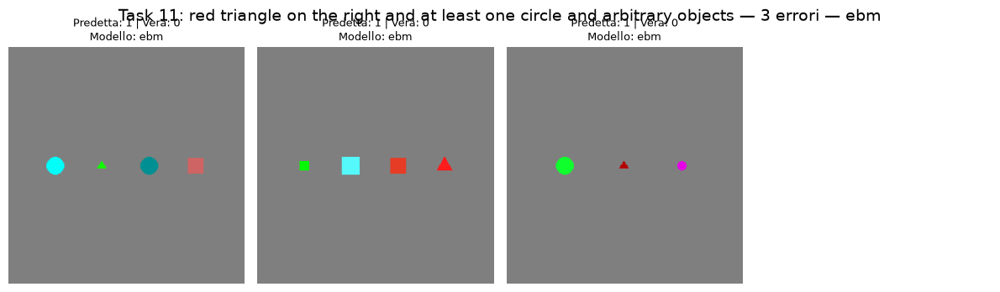

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/ebm/task_11_errors.png


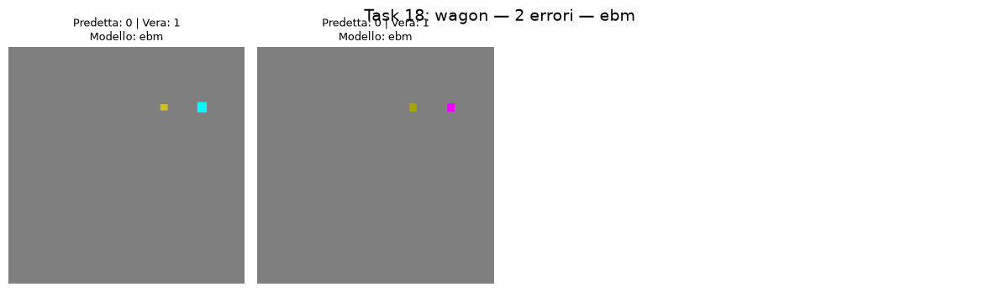

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/ebm/task_18_errors.png


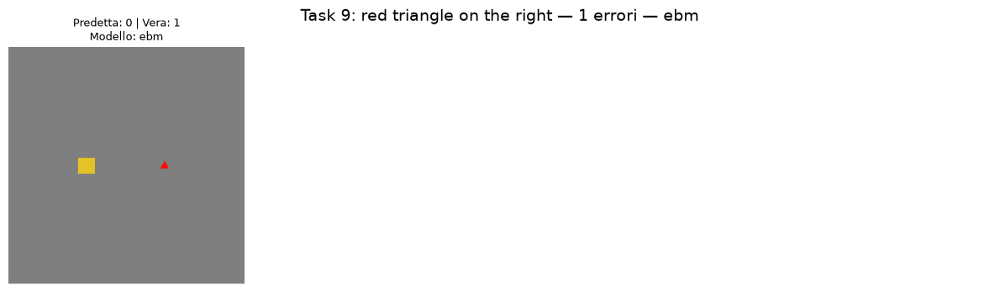

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/ebm/task_9_errors.png


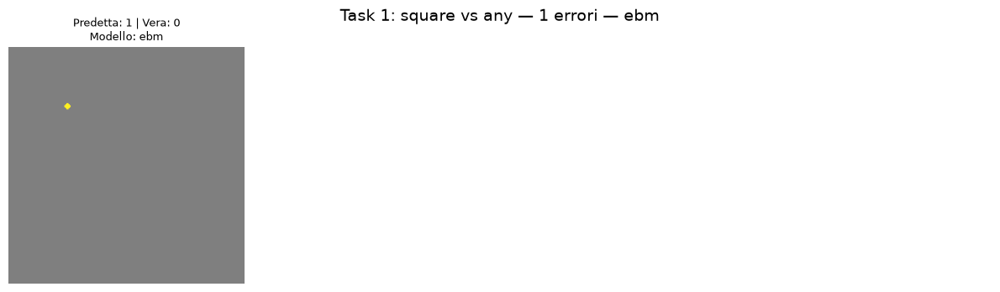

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/ebm/task_1_errors.png

MODELLO: logistic


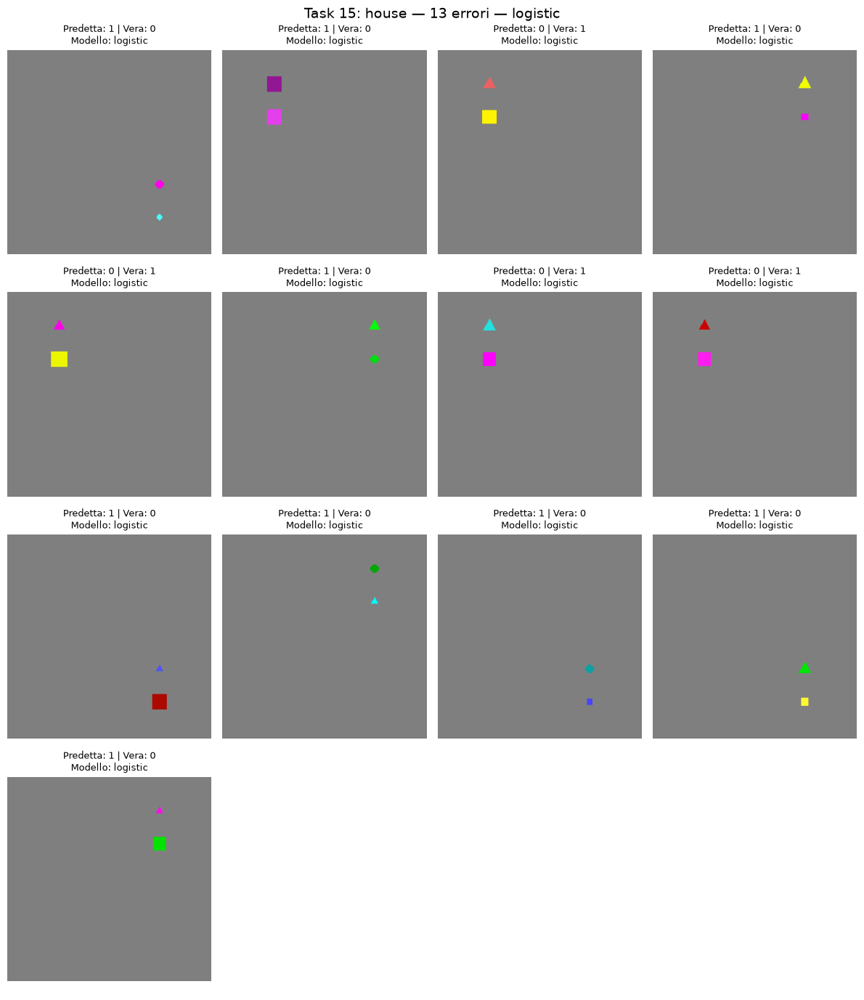

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/logistic/task_15_errors.png


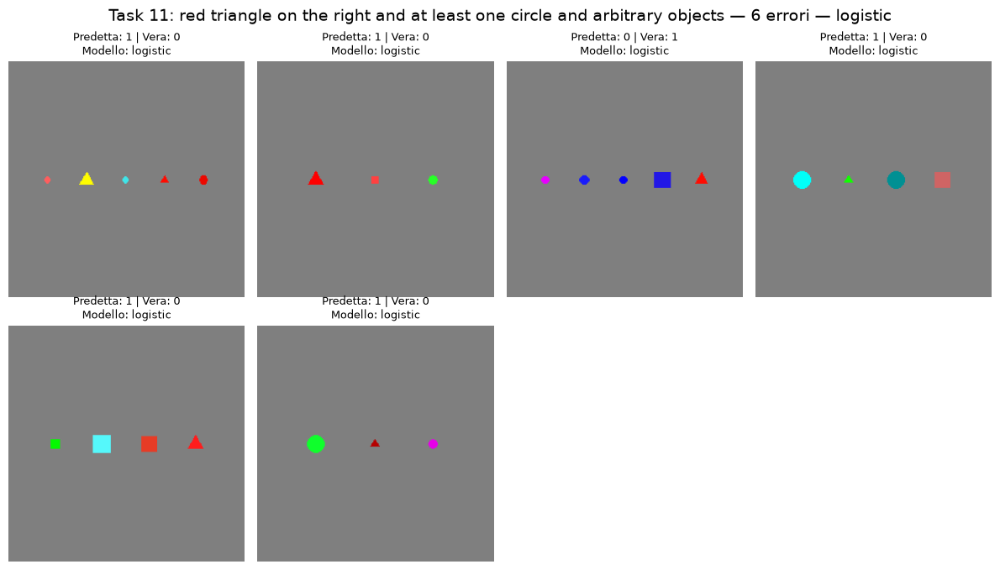

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/logistic/task_11_errors.png


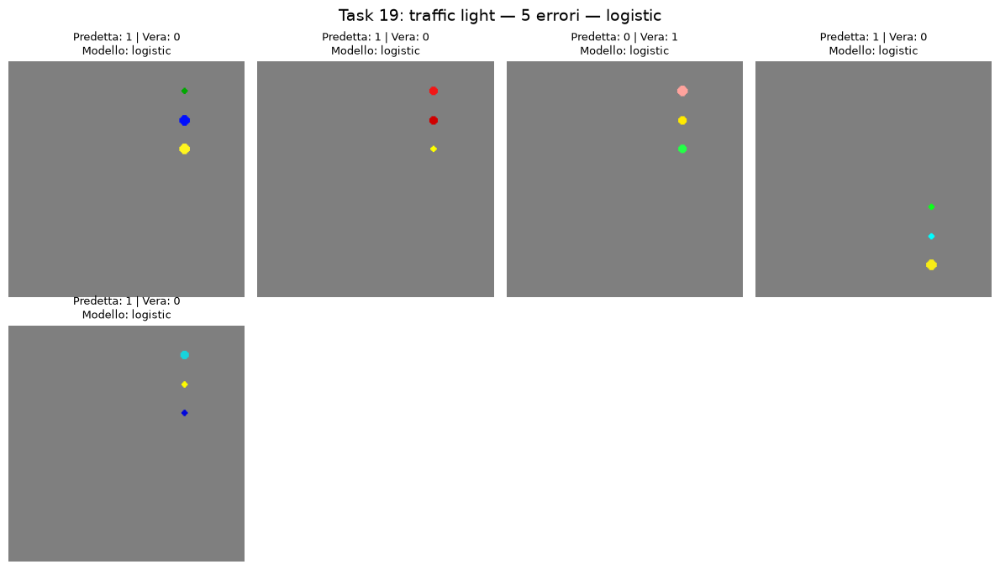

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/logistic/task_19_errors.png


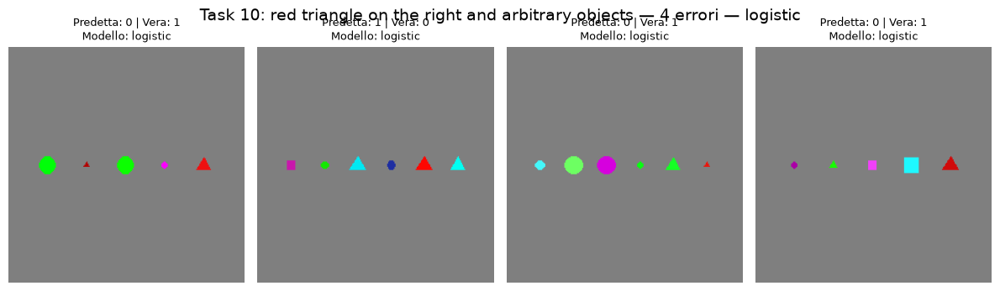

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/logistic/task_10_errors.png


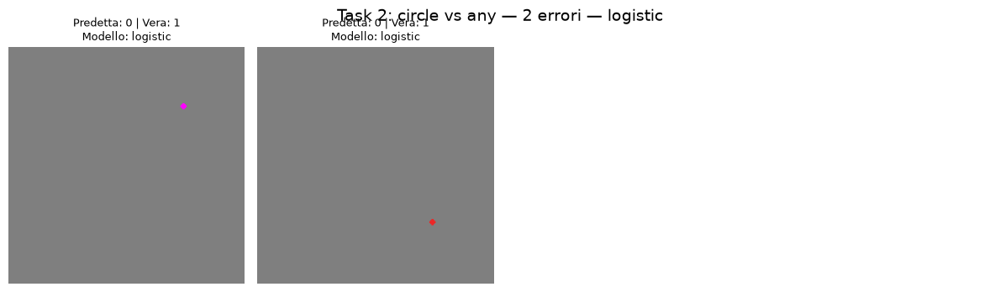

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/logistic/task_2_errors.png


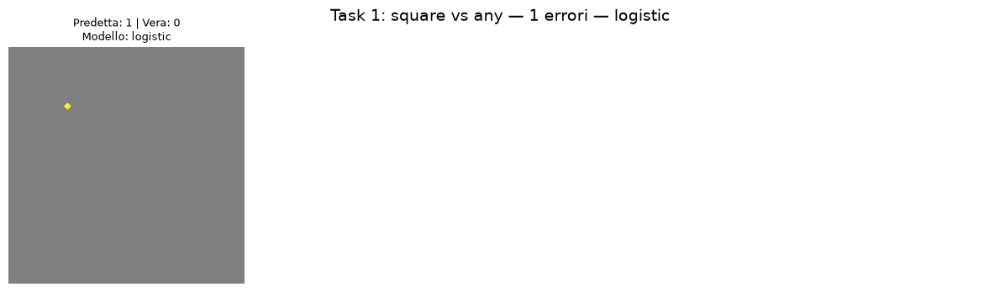

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/logistic/task_1_errors.png


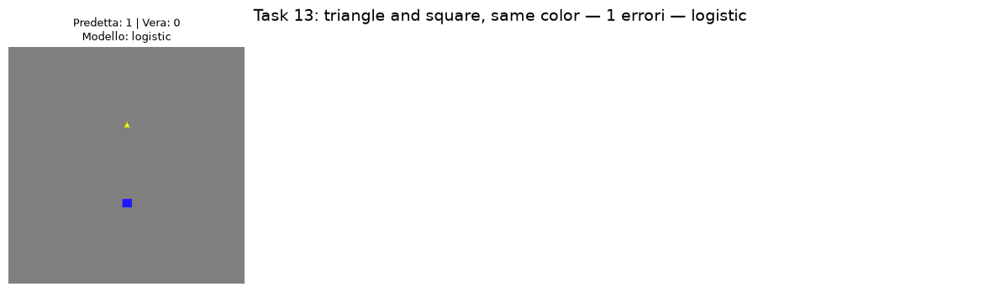

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/logistic/task_13_errors.png


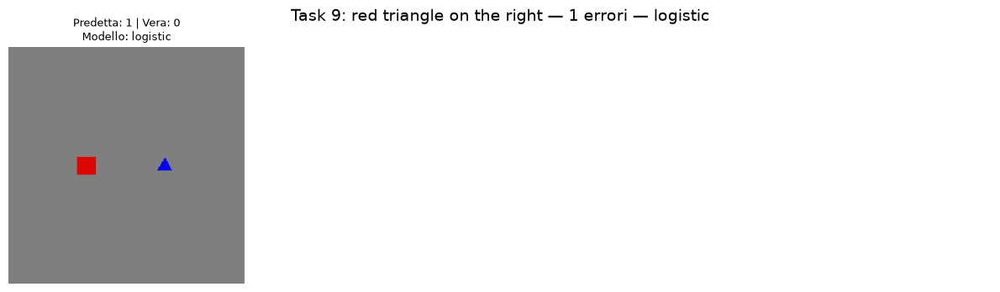

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/logistic/task_9_errors.png


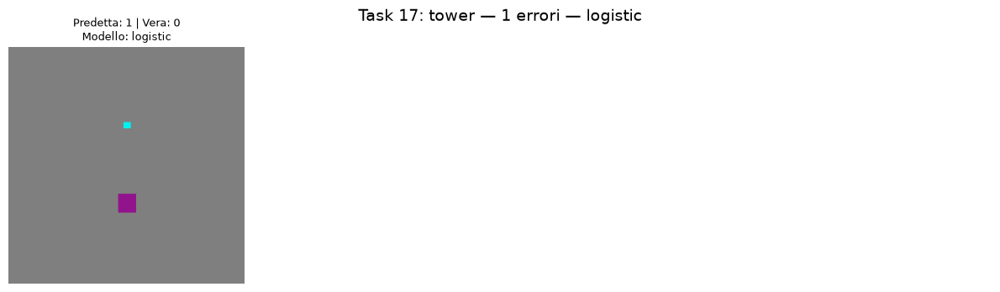

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/logistic/task_17_errors.png


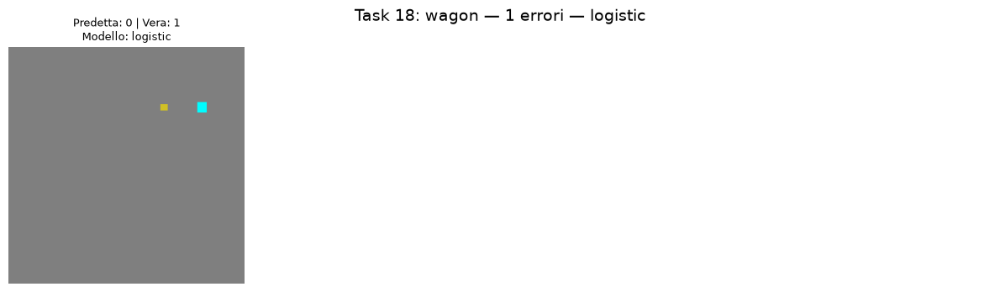

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/logistic/task_18_errors.png

MODELLO: tree


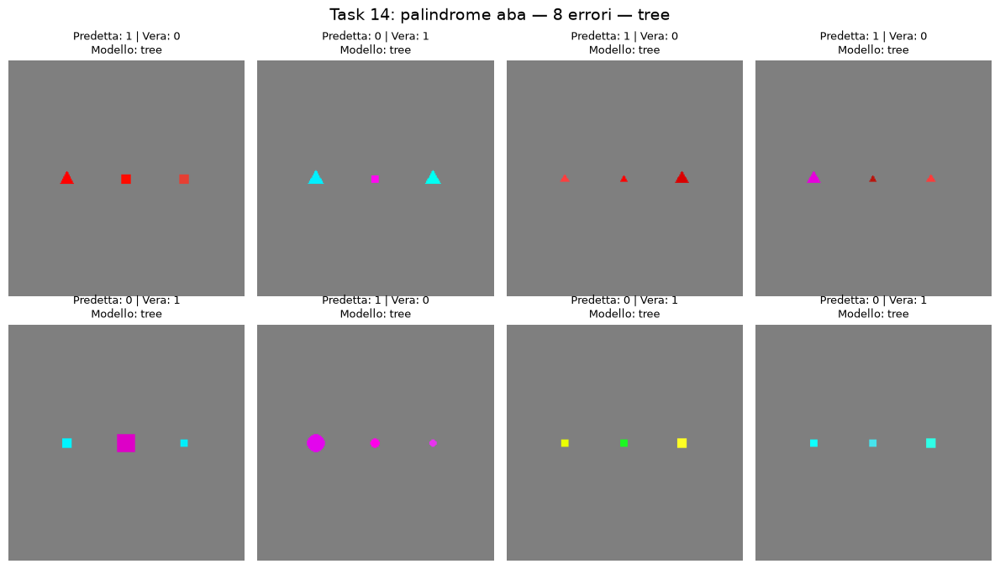

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/tree/task_14_errors.png


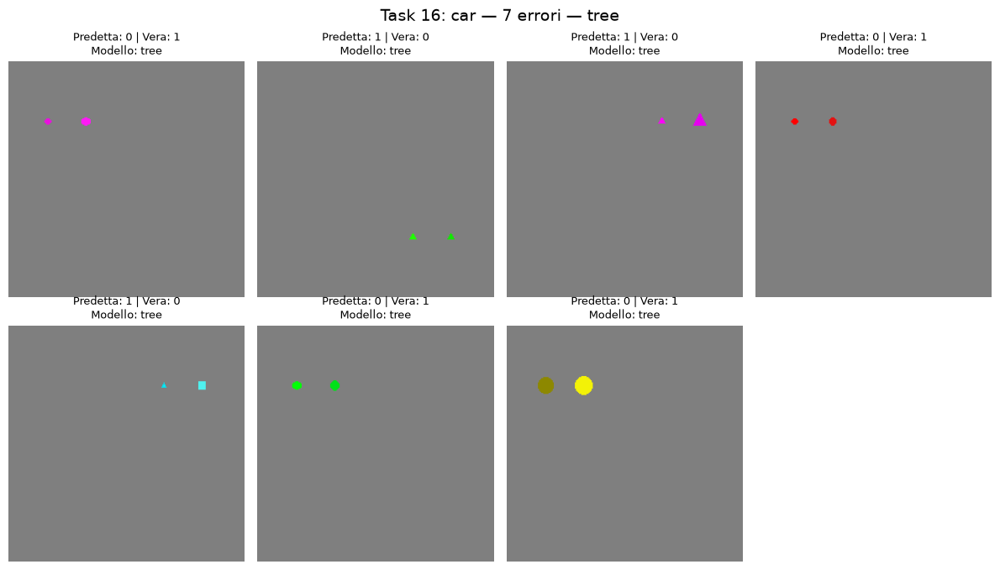

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/tree/task_16_errors.png


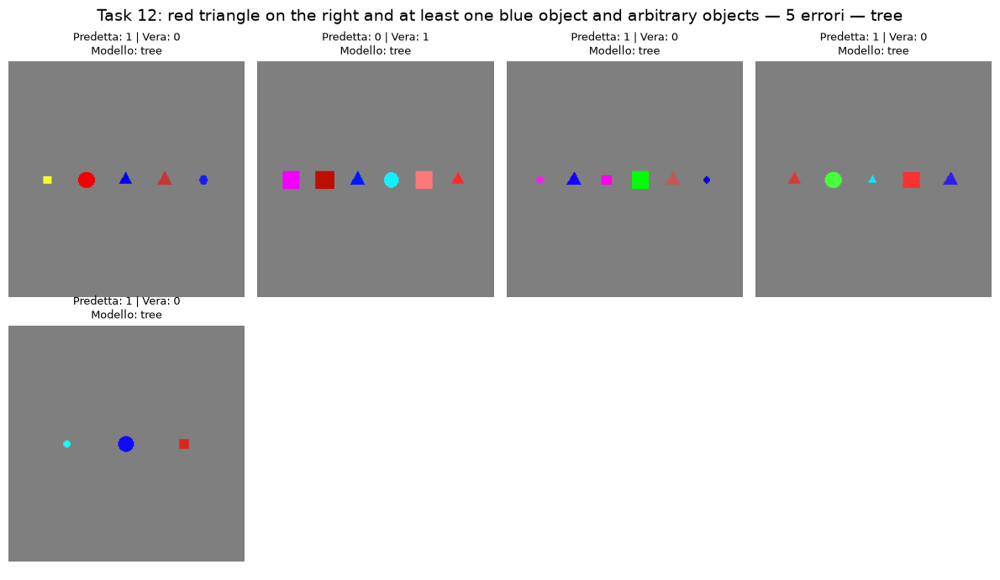

Salvato: /home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors/tree/task_12_errors.png

Visualizzazione degli errori completata.
Cartella finale:
/home/cosimo/Downloads/kandy-xai/results/interpretable_models/errors


In [20]:
#CONTEGGIO E VISUALIZZAZIONE DEGLI ERRORI PER MODELLO

ERROR_DIR = (
    ROOT
    / CONFIG["paths"]["errors_dir"]
)
ERROR_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

errors = []

#errori modelli regressione e alberi

for task_id, model in models_all.items():

    test = features_df[
        (features_df["split"] == "test")
        & (features_df["task_id"] == task_id)
    ].copy()

    test["prediction"] = model.predict(
        test[ALL_FEATURES]
    )

    if isinstance(model, Pipeline):
        model_name = "logistic"

    elif isinstance(
        model,
        DecisionTreeClassifier,
    ):
        model_name = "tree"

    else:
        model_name = type(model).__name__

    task_errors = test.loc[
        test["label"] != test["prediction"],
        [
            "_path",
            "filename",
            "task_id",
            "label",
            "prediction",
        ],
    ].copy()

    task_errors["model"] = model_name

    errors.append(task_errors)

#errori ebm

for task_id, model in models_ebm.items():

    test = features_df[
        (features_df["split"] == "test")
        & (features_df["task_id"] == task_id)
    ].copy()

    test["prediction"] = model.predict(
        test[ALL_FEATURES]
    )

    task_errors = test.loc[
        test["label"] != test["prediction"],
        [
            "_path",
            "filename",
            "task_id",
            "label",
            "prediction",
        ],
    ].copy()

    task_errors["model"] = "ebm"

    errors.append(task_errors)

errors_df = (
    pd.concat(
        errors,
        ignore_index=True,
    )
    if errors
    else pd.DataFrame()
)


print(
    "Numero totale di errori:",
    len(errors_df),
)


if len(errors_df):

   
    error_counts = (
        errors_df
        .groupby(
            [
                "model",
                "task_id",
            ]
        )
        .size()
        .reset_index(
            name="n_errors"
        )
        .sort_values(
            [
                "model",
                "n_errors",
                "task_id",
            ],
            ascending=[
                True,
                False,
                True,
            ],
        )
    )
    #contiamo gli errori separatamente per modello e task

    print(
        "\nErrori per modello e task:"
    )

    display(
        error_counts
    )

    error_csv = (
        ERROR_DIR
        / "test_errors_by_model.csv"
    )

    errors_df.to_csv(
        error_csv,
        index=False,
    )

    print(
        f"\nTabella salvata in: {error_csv}"
    )

    for model_name in sorted(
        errors_df["model"].unique()
    ):

        model_errors = errors_df[
            errors_df["model"] == model_name
        ]

        model_dir = (
            ERROR_DIR
            / model_name
        )

        model_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        print(
            f"\nMODELLO: {model_name}"
        )

        task_counts = (
            model_errors
            .groupby("task_id")
            .size()
            .sort_values(
                ascending=False
            )
        )

        for task_id in task_counts.index:

            task_errors = model_errors[
                model_errors["task_id"] == task_id
            ].copy()

            task_name = TASK_NAMES[
                task_id
            ]

            n_images = len(
                task_errors
            )

            n_cols = int(CONFIG["experiment"]["errors"]["n_cols"])
            n_rows = math.ceil(
                n_images / n_cols
            )

            fig, axes = plt.subplots(
                n_rows,
                n_cols,
                figsize=(
                    12,
                    float(CONFIG["experiment"]["errors"]["row_height"]) * n_rows,
                ),
            )

            axes = np.array(
                axes
            ).reshape(-1)

            for ax, (_, row) in zip(
                axes,
                task_errors.iterrows(),
            ):

                image = Image.open(
                    row["_path"]
                ).convert("RGB")

                ax.imshow(
                    image
                )

                ax.set_title(
                    f"Predetta: {row['prediction']} | "
                    f"Vera: {row['label']}\n"
                    f"Modello: {model_name}",
                    fontsize=9,
                )

                ax.axis("off")

            for ax in axes[
                n_images:
            ]:
                ax.axis("off")

            fig.suptitle(
                f"Task {task_id}: "
                f"{task_name} — "
                f"{n_images} errori — "
                f"{model_name}",
                fontsize=int(CONFIG["experiment"]["errors"]["title_fontsize"]),
            )

            plt.tight_layout()

            task_path = (
                model_dir
                / f"task_{task_id}_errors.png"
            )

            plt.savefig(
                task_path,
                dpi=int(CONFIG["experiment"]["errors"]["dpi"]),
                bbox_inches="tight",
            )

            plt.show()
            plt.close(fig)

            print(
                f"Salvato: {task_path}"
            )


print(
    "\nVisualizzazione degli errori completata."
)

print(
    "Cartella finale:"
)

print(
    ERROR_DIR.resolve()
)

## Salvataggio dei risultati

I risultati vengono salvati nella cartella `results/interpretable_models`, in modo da poter rendere possibili confronti futuri.

In [21]:
OUT = (
    ROOT
    / CONFIG["paths"]["results_dir"]
)

OUT.mkdir(
    parents=True,
    exist_ok=True,
)


results_perc.to_csv(
    OUT / "kandy_interpretable_perceptual_final.csv",
    index=False,
)

results_all.to_csv(
    OUT / "kandy_interpretable_generic_relations_final.csv",
    index=False,
)

comparison.to_csv(
    OUT / "kandy_interpretable_comparison_final.csv",
    index=False,
)

diagnostic_summary.to_csv(
    OUT / "kandy_detector_diagnostic_final.csv",
    index=False,
)

if len(results_ebm):
    results_ebm.to_csv(
        OUT / "kandy_ebm_final.csv",
        index=False,
    )



importance_rows = []

for task_id in EXPLAIN_TASKS:

    ebm = models_ebm.get(task_id)

    logistic = None
    tree = None

    if "explanation_models" in globals():
        models = explanation_models.get(
            task_id,
            (None, None, None),
        )

        if len(models) == 3:
            logistic, tree, ebm_from_dict = models

            if ebm_from_dict is not None:
                ebm = ebm_from_dict


    if logistic is not None:

        coef = pd.Series(
            logistic.named_steps["clf"].coef_[0],
            index=ALL_FEATURES,
        )

        for feature, value in coef.items():

            importance_rows.append({
                "task_id": task_id,
                "task": TASK_NAMES[task_id],
                "model": "logistic",
                "term": feature,
                "importance_signed": float(value),
                "importance_abs": float(abs(value)),
            })

    if tree is not None:

        tree_importance = pd.Series(
            tree.feature_importances_,
            index=ALL_FEATURES,
        )

        for feature, value in tree_importance.items():

            if value <= 0:
                continue

            importance_rows.append({
                "task_id": task_id,
                "task": TASK_NAMES[task_id],
                "model": "tree",
                "term": feature,
                "importance_signed": float(value),
                "importance_abs": float(value),
            })

    if ebm is not None:

        for term, value in ebm_term_importance(ebm).items():

            importance_rows.append({
                "task_id": task_id,
                "task": TASK_NAMES[task_id],
                "model": "ebm",
                "term": term,
                "importance_signed": np.nan,
                "importance_abs": float(value),
            })


importance_df = pd.DataFrame(
    importance_rows
)

if not importance_df.empty:

    importance_df.to_csv(
        OUT / "kandy_interpretable_feature_importances_final.csv",
        index=False,
    )


print(
    "Risultati salvati in:",
    OUT.resolve(),
)

Risultati salvati in: /home/cosimo/Downloads/kandy-xai/results/interpretable_models


## Conclusione

In questo notebook abbiamo costruito una baseline interpretabile che parte direttamente dall'immagine, senza usare le annotazioni simboliche come input del modello. Prima cerchiamo quindi di trasformare l'immagine in una rappresentazione comprensibile, descrivendo gli oggetti attraverso forma, colore, dimensione, posizione e relazioni spaziali generiche.

A questo punto possiamo separare meglio due aspetti del problema: da una parte quanto è buona la percezione degli oggetti, che analizziamo con la diagnostica dedicata, e dall'altra quanto i modelli riescono a sfruttare questa rappresentazione per risolvere i diversi task, usando regressione logistica, alberi decisionali ed EBM.

Quello che emerge è che le proprietà più semplici degli oggetti vengono gestite abbastanza bene, mentre i task che richiedono di combinare più informazioni o riconoscere strutture più complesse rimangono più difficili. Questo risultato ci instrada naturalmente verso i modelli neuro-simbolici, dove cerchiamo di separare in modo più esplicito la percezione visiva dalla parte di ragionamento; i prossimi notebook serviranno appunto a costruire la strada per l'utilizzo del CBM, ovvero il Concept Bottleneck Model.